# Arabic Deepfake Detection - YouTube Execution Notebook


## Setup and Configuration


### Environment and Imports


In [2]:
import os
os.kill(os.getpid(), 9)

In [3]:
# Install dependencies (runtime restart required after this cell)
!pip -q install --no-cache-dir \
    "transformers==4.43.3" \
    "datasets==2.19.1" \
    "accelerate==0.30.1" \
    "evaluate==0.4.2" \
    "scikit-learn==1.5.1" \
    "scipy>=1.10,<1.14" \
    "openpyxl==3.1.2" \
    "emoji>=2.0.0" \
    "arabert" \
    "plotly==5.24.1" \
    "kaleido==0.2.1" \
    "gensim==4.3.3" \
    "joblib>=1.4.0" \
    "tabulate>=0.9.0"

In [4]:
import gc
import importlib
import json
import os
import random
import re
import string
import sys
import time
import unicodedata
import warnings
from datetime import datetime
from pathlib import Path

import emoji
import joblib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict, concatenate_datasets
from gensim.models import FastText, Word2Vec
from IPython.display import Image, Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader, Dataset as TorchDataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore", category=UserWarning)


### Paths, Seeds, and Dataset Roots


In [5]:
# Fix the random state once so every model family is compared under the same seed.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def _detect_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


_IN_COLAB = _detect_colab()
_DRIVE_ROOT = Path("/content/drive/MyDrive")
_COLAB_PROJECT_CANDIDATES = [Path("/content/GADD_Project"), Path("/content/drive/MyDrive/GADD_Project")]


def _drive_is_mounted():
    return _DRIVE_ROOT.exists()


def _maybe_mount_drive():
    if not _IN_COLAB or _drive_is_mounted():
        return _drive_is_mounted()
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print(f"Google Drive mount skipped: {exc}")
    return _drive_is_mounted()


def _candidate_project_roots():
    cwd = Path.cwd().resolve()
    seen = set()
    for candidate in [cwd, *cwd.parents, *_COLAB_PROJECT_CANDIDATES]:
        candidate = Path(candidate).resolve(strict=False)
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        yield candidate


def _resolve_project_root():
    for candidate in _candidate_project_roots():
        if (candidate / "Final_Pipeline").exists() and (candidate / "Dataset").exists():
            return candidate
    for candidate in _candidate_project_roots():
        if (candidate / "Final_Pipeline").exists():
            return candidate
    if _IN_COLAB:
        _maybe_mount_drive()
        for candidate in _candidate_project_roots():
            if (candidate / "Final_Pipeline").exists():
                return candidate
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "Final_Pipeline" else cwd


PIPELINE_NAME = "youtube"
PIPELINE = PIPELINE_NAME
DISPLAY_NAME = "YouTube"
OTHER_PIPELINE_NAME = "twitter"
OTHER_DISPLAY_NAME = "Twitter"
PROJECT_ROOT = _resolve_project_root()
PROJECT_DIR = PROJECT_ROOT
FINAL_PIPELINE_ROOT = PROJECT_ROOT / "Final_Pipeline"
RESEARCH_DESIGN_PATH = FINAL_PIPELINE_ROOT / "docs" / "research_design.md"

if str(FINAL_PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(FINAL_PIPELINE_ROOT))


def resolve_output_root():
    candidates = []
    if FINAL_PIPELINE_ROOT.exists():
        candidates.append(FINAL_PIPELINE_ROOT / "Output")
    if _IN_COLAB:
        if not _drive_is_mounted() and not FINAL_PIPELINE_ROOT.exists():
            _maybe_mount_drive()
        if _drive_is_mounted():
            candidates.append(Path("/content/drive/MyDrive/GADD_Project/Final_Pipeline/Output"))
    if not candidates:
        candidates.append(PROJECT_ROOT / "Final_Pipeline" / "Output")
    root = next((candidate for candidate in candidates if candidate.exists()), candidates[0])
    root.mkdir(parents=True, exist_ok=True)
    return root


def resolve_dataset_paths(pipeline_name: str):
    specs = {
        "twitter": {
            "local": PROJECT_ROOT / "Dataset" / "Twitter_data" / "Twitter_data" / "splits_rebuilt_v4",
            "colab": Path("/content/drive/MyDrive/GADD_Project/Dataset/Twitter_data/Twitter_data/splits_rebuilt_v4"),
        },
        "youtube": {
            "local": PROJECT_ROOT / "Dataset" / "Youtube_data" / "Youtube_data" / "splits_rebuilt",
            "colab": Path("/content/drive/MyDrive/GADD_Project/Dataset/Youtube_data/Youtube_data/splits_rebuilt"),
        },
    }
    spec = specs[pipeline_name]
    candidates = [spec["local"]]
    if _IN_COLAB:
        if not spec["local"].exists():
            _maybe_mount_drive()
        candidates.append(spec["colab"])
    base = next((candidate for candidate in candidates if candidate.exists()), None)
    if base is None:
        checked = "".join(f"- {candidate}" for candidate in candidates)
        raise FileNotFoundError(f"Could not locate the {pipeline_name} dataset splits. Checked: {checked}")
    paths = {"train_meta": base / "train_with_meta.csv", "val_meta": base / "val_with_meta.csv", "test_meta": base / "test_with_meta.csv"}
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Dataset split files are missing:\n" + "\n".join(f"- {path}" for path in missing))
    return paths


print(f"Colab runtime detected: {_IN_COLAB}")
print(f"Google Drive mounted: {_drive_is_mounted()}")
print(f"Resolved project root: {PROJECT_ROOT}")
print(f"Resolved output root: {resolve_output_root()}")


Colab runtime detected: True
Google Drive mounted: True
Resolved project root: /content/drive/MyDrive/GADD_Project
Resolved output root: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output


In [6]:
import importlib
import exact_model_preprocessing_figures_helpers
import deceptive_type_error_analysis_helpers

# Force Python to re-read the files from disk
importlib.reload(exact_model_preprocessing_figures_helpers)
importlib.reload(deceptive_type_error_analysis_helpers)

<module 'deceptive_type_error_analysis_helpers' from '/content/drive/MyDrive/GADD_Project/Final_Pipeline/deceptive_type_error_analysis_helpers.py'>

In [7]:
from exact_model_preprocessing_figures_helpers import FigureRenderContext, render_exact_model_preprocessing_figure_set
from deceptive_type_error_analysis_helpers import run_deceptive_type_analysis

### Output Directories and Run Paths


In [8]:
CANONICAL_OUTPUT_ROOT = resolve_output_root()
PIPELINE_ROOT = CANONICAL_OUTPUT_ROOT / PIPELINE_NAME
RUN_ROOT = PIPELINE_ROOT
RUN_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = RUN_ROOT
RESULTS = RUN_ROOT
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
LOG_DIR = OUTPUT_DIR / "logs"
CACHE_DIR = OUTPUT_DIR / "cache"
MODELS_DIR = OUTPUT_DIR / "models"
EMBEDDINGS_DIR = OUTPUT_DIR / "embeddings"
PREPROCESSED_CACHE_DIR = CACHE_DIR / "preprocessed"

ARABERT_RESULTS = RESULTS / "arabert"
MARBERT_RESULTS = RESULTS / "marbert"
CAMELBERT_RESULTS = RESULTS / "camelbert"
ML_RESULTS = RESULTS / "ml_classifiers"
MISCLASS_BASE = RESULTS / "misclass_analysis"

for dir_path in [
    OUTPUT_DIR,
    FIG_DIR,
    TABLE_DIR,
    LOG_DIR,
    CACHE_DIR,
    MODELS_DIR,
    EMBEDDINGS_DIR,
    PREPROCESSED_CACHE_DIR,
]:
    dir_path.mkdir(parents=True, exist_ok=True)
for model_dir in [ARABERT_RESULTS, MARBERT_RESULTS, CAMELBERT_RESULTS]:
    (model_dir / "confusion_matrices").mkdir(parents=True, exist_ok=True)
    (model_dir / "plots").mkdir(parents=True, exist_ok=True)
for subdir in ["plots", "classification_reports", "tables", "per_classifier", "comparative", "misclass_analysis_ml"]:
    (ML_RESULTS / subdir).mkdir(parents=True, exist_ok=True)
for subdir in ["arabert", "marbertv2", "camelbert", "comparative"]:
    (MISCLASS_BASE / subdir).mkdir(parents=True, exist_ok=True)

P_TWT = resolve_dataset_paths("twitter")
P_YTB = resolve_dataset_paths("youtube")
CURRENT_DATASET_PATHS = P_YTB
DATASET_ROOT = CURRENT_DATASET_PATHS["train_meta"].parent


### Shared Labels and Utilities


In [9]:
def require_globals(required_vars, mode="raise", context=""):
    missing = [var for var in required_vars if var not in globals()]
    if not missing:
        return True
    prefix = f"{context}: " if context else ""
    msg = f"{prefix}missing globals: {missing}"
    if mode == "raise":
        raise NameError(msg)
    print(f"[SKIP] {msg}")
    return False


LOG_FILE = LOG_DIR / "run_log.txt"


def log(msg: str, also_print: bool = True):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted = f"[{timestamp}] {msg}"
    if also_print:
        print(msg)
    with open(LOG_FILE, "a", encoding="utf-8") as fh:
        fh.write(formatted + "\n")


PALETTE = ["#4C72B0", "#55A868", "#8172B2"]
PREPROCESSING_ORDER = ["original", "manual", "deepfake_aware"]
PREPROCESSING_PAPER_LABELS = {
    "original": "Raw Text Baseline",
    "manual": "Strong Cleaning Baseline",
    "deepfake_aware": "EDA-Guided Signal-Preserving Normalization",
}
PREPROCESSING_LABELS = PREPROCESSING_PAPER_LABELS.copy()
PREPROCESSING_SHORT_LABELS = {
    "original": "Original",
    "manual": "Manual",
    "deepfake_aware": "Deepfake-aware",
}
CORE_PREPROCESSING = PREPROCESSING_ORDER.copy()
METHOD_ORDER = PREPROCESSING_ORDER.copy()
METHODS_NO_ORIGINAL = [m for m in METHOD_ORDER if m != "original"]
PREPROCESSING_COLORS = {
    "original": "#4C72B0",
    "manual": "#55A868",
    "deepfake_aware": "#8172B2",
}
METHOD_LABELS = PREPROCESSING_LABELS.copy()
METHOD_COLORS = PREPROCESSING_COLORS.copy()
LABEL_COLORS = {"Real": "#55A868", "Fake": "#C44E52"}

PLOT_FONT_PRIORITY = [
    "Latin Modern Roman",
    "Latin Modern Sans",
    "Computer Modern Roman",
    "CMU Serif",
    "CMU Sans Serif",
    "cmr10",
]
PLOT_FONT_FALLBACKS = ["DejaVu Serif"]


def resolve_publication_font():
    available_fonts = {font.name for font in fm.fontManager.ttflist}
    for font_name in PLOT_FONT_PRIORITY:
        if font_name in available_fonts:
            return {
                "font_name": font_name,
                "family_label": "Latin Modern" if "Latin Modern" in font_name else "Computer Modern",
                "fallback_used": font_name not in {"Latin Modern Roman", "Latin Modern Sans", "Computer Modern Roman"},
            }
    return {"font_name": PLOT_FONT_FALLBACKS[0], "family_label": "Fallback serif", "fallback_used": True}


PUBLICATION_FONT = resolve_publication_font()
PUBLICATION_FONT_STACK = [PUBLICATION_FONT["font_name"], "cmr10", *PLOT_FONT_FALLBACKS]
PUBLICATION_FONT_NOTES = (
    f"Resolved plotting font: {PUBLICATION_FONT['font_name']} ({PUBLICATION_FONT['family_label']}). "
    f"Fallback used: {PUBLICATION_FONT['fallback_used']}"
)
BASE_PLOT_RCPARAMS = {
    "figure.figsize": (7.5, 4.5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": PUBLICATION_FONT_STACK,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.edgecolor": "black",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "mathtext.fontset": "cm",
    "mathtext.default": "regular",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}


def apply_shared_plot_style(*, overrides=None, reset=False):
    if reset:
        plt.rcParams.update(plt.rcParamsDefault)
    sns.set_theme(style="whitegrid")
    rc = BASE_PLOT_RCPARAMS.copy()
    if overrides:
        rc.update(overrides)
    plt.rcParams.update(rc)
    globals()["_PLOT_STYLE_CONTRACT_ACTIVE"] = True
    return rc


apply_shared_plot_style()
print(PUBLICATION_FONT_NOTES)


def to_paper_label(method_key):
    return PREPROCESSING_PAPER_LABELS.get(method_key, method_key)

Resolved plotting font: cmr10 (Computer Modern). Fallback used: True


### Persistence and Plot Helpers


In [10]:
def save_figure(fig, path_stem, formats=("png", "pdf"), dpi=300):
    path_stem = Path(path_stem)
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    for fmt in formats:
        fig.savefig(path_stem.with_suffix(f".{fmt}"), dpi=dpi, bbox_inches="tight")


def save_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")



def write_dataframe_with_markdown(df, csv_path, md_path, *, index=False):
    csv_path = Path(csv_path)
    md_path = Path(md_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    md_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(csv_path, index=index, encoding="utf-8")
    md_text = "_No rows available._\n" if df.empty else df.to_markdown(index=index) + "\n"
    md_path.write_text(md_text, encoding="utf-8")

def load_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return {} if default is None else default
    with open(path, "r", encoding="utf-8") as fh:
        return json.load(fh)


_PLOTLY_READY = False


def ensure_plotly_backend():
    global _PLOTLY_READY
    if _PLOTLY_READY:
        return True
    import plotly  # noqa: F401
    import plotly.io._kaleido as _pk
    import plotly.graph_objects as go  # noqa: F401
    from plotly.subplots import make_subplots  # noqa: F401

    importlib.reload(_pk)
    if _pk.scope is None:
        raise RuntimeError("kaleido backend not available; restart the runtime after installation")
    _PLOTLY_READY = True
    return True


def save_figure_plotly(fig, path_stem, scale=3):
    ensure_plotly_backend()
    path_stem = Path(path_stem)
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(str(path_stem.with_suffix(".png")), engine="kaleido", scale=scale)
    fig.write_image(str(path_stem.with_suffix(".pdf")), engine="kaleido")


def _df_from_ds(ds):
    return pd.DataFrame(ds)


## Data Loading and Split Validation


### Load Split Files


In [11]:
# Load the split files into one clean schema for every downstream branch.
def _norm_ws(s):
    return re.sub(r'\s+', ' ', str(s or '')).strip()

def _read(path):
    df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
    df.columns = [str(c).strip() for c in df.columns]
    return df

def _mk_ds(paths):
    tr = _read(paths['train_meta'])
    va = _read(paths['val_meta'])
    te = _read(paths['test_meta'])

    # Standardize the text/label schema once so leakage checks and all model families see the same inputs.
    def prep(df):
        # text
        tcol = 'text' if 'text' in df.columns else next(c for c in df.columns if c.lower() in ('text','content','body'))
        # label
        lcol = 'label' if 'label' in df.columns else next(c for c in df.columns if c.lower() in ('label','type','class'))
        out = df[[tcol, lcol]].copy().rename(columns={tcol:'text', lcol:'label'})
        out['text'] = out['text'].map(_norm_ws)
        out['label'] = out['label'].map({'fake':0,'deepfake':0,'real':1,'true':1,'false':0}).fillna(out['label'])
        out['label'] = pd.to_numeric(out['label'], errors='coerce')
        out = out.dropna(subset=['text','label']).reset_index(drop=True)
        out['label'] = out['label'].astype(int)
        return out[['text','label']]

    return DatasetDict({
        'train': Dataset.from_pandas(prep(tr), preserve_index=False),
        'val': Dataset.from_pandas(prep(va), preserve_index=False),
        'test': Dataset.from_pandas(prep(te), preserve_index=False),
    })

ds_ytb  = _mk_ds(P_YTB)
def _sz(d):
    return {s: (len(d[s]) if s in d else 0) for s in ['train','val','test']}

RAW_SPLIT_SIZES = _sz(ds_ytb)

print("sizes:", {
    'youtube': RAW_SPLIT_SIZES,
})

sizes: {'youtube': {'train': 19790, 'val': 2828, 'test': 5654}}


### Leakage Audit


In [12]:
# Run an exact-text leakage audit before any feature fitting or model training.
def _to_set(ds, split):
    return set([_norm_ws(t) for t in ds[split]['text']]) if split in ds else set()

tests = {
  'youtube': _to_set(ds_ytb,'test'),
}

def check(name, s):
    leak = {}
    for k,te in tests.items():
        inter = s & te
        if inter:
            leak[k] = len(inter)
    print(f"{name}: {'OK' if not leak else 'LEAK ' + str(leak)}")

for nm,ds in [('youtube',ds_ytb)]:
    check(f"{nm}/train", set(ds['train']['text']))
    check(f"{nm}/val",   set(ds['val']['text']))

youtube/train: LEAK {'youtube': 3944}
youtube/val: LEAK {'youtube': 563}


### De-leak Training and Validation Splits


In [13]:
# Remove exact test duplicates from train/val so the held-out split stays clean.
def _sanitize_deleak(dsd: DatasetDict) -> DatasetDict:
    import pandas as pd
    te = pd.DataFrame({'text': dsd['test']['text'], 'label': dsd['test']['label']})
    te_texts = set(te['text'].astype(str))
    def _clean(split):
        df = pd.DataFrame({'text': dsd[split]['text'], 'label': dsd[split]['label']})
        df = df[~df['text'].astype(str).isin(te_texts)].reset_index(drop=True)
        return Dataset.from_pandas(df, preserve_index=False)
    out = {}
    out['test'] = dsd['test']
    out['train'] = _clean('train')
    out['val'] = _clean('val')
    return DatasetDict(out)

# Apply to each domain
ds_ytb = _sanitize_deleak(ds_ytb)

# quick check
def _sz(d): return {s: len(d[s]) for s in ['train','val','test']}
FINAL_SPLIT_SIZES = _sz(ds_ytb)
print("after de-leak:", {'youtube': FINAL_SPLIT_SIZES,})

after de-leak: {'youtube': {'train': 15846, 'val': 2265, 'test': 5654}}


### Final Split Summary


In [14]:
# LOAD DATA (YOUTUBE ONLY - FROM PIPELINE SPLITS)

# Use the pipeline DatasetDict to avoid leakage and keep splits aligned.
if 'ds_ytb' not in globals():
    raise NameError("ds_ytb not found. Run the Loaders cell above first.")

def _df_from_ds(ds):
    return pd.DataFrame({'text': ds['text'], 'label': ds['label']})

youtube_train = _df_from_ds(ds_ytb['train'])
youtube_val = _df_from_ds(ds_ytb['val'])
youtube_test = _df_from_ds(ds_ytb['test'])

print(f"YouTube Training: {len(youtube_train):,} samples")
print(f"YouTube Validation: {len(youtube_val):,} samples")
print(f"YouTube Test: {len(youtube_test):,} samples")


split_summary_rows = []
final_total = max(1, sum(FINAL_SPLIT_SIZES.values()))
for split in ["train", "val", "test"]:
    raw_n = int(RAW_SPLIT_SIZES.get(split, 0))
    final_n = int(FINAL_SPLIT_SIZES.get(split, 0))
    split_summary_rows.append(
        {
            "platform": PIPELINE_NAME,
            "split": split,
            "n_samples": final_n,
            "pct_of_total": round((final_n / final_total) * 100, 2),
            "raw_n_samples": raw_n,
            "n_removed_by_deleak": int(raw_n - final_n),
        }
    )

dataset_split_summary_df = pd.DataFrame(split_summary_rows)
dataset_split_summary_csv_path = TABLE_DIR / f"dataset_split_summary_{PIPELINE_NAME}.csv"
dataset_split_summary_md_path = TABLE_DIR / f"dataset_split_summary_{PIPELINE_NAME}.md"
write_dataframe_with_markdown(dataset_split_summary_df, dataset_split_summary_csv_path, dataset_split_summary_md_path)

print(f"Saved dataset split summary CSV: {dataset_split_summary_csv_path}")
print(f"Saved dataset split summary markdown: {dataset_split_summary_md_path}")
display(dataset_split_summary_df)


YouTube Training: 15,846 samples
YouTube Validation: 2,265 samples
YouTube Test: 5,654 samples
Saved dataset split summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/dataset_split_summary_youtube.csv
Saved dataset split summary markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/dataset_split_summary_youtube.md


,platform,split,n_samples,pct_of_total,raw_n_samples,n_removed_by_deleak
0,youtube,train,15846,66.68,19790,3944
1,youtube,val,2265,9.53,2828,563
2,youtube,test,5654,23.79,5654,0


Total examples = 23,765 = training + validation + testing


,split,n_samples,pct_of_total
0,Train,15846,66.68
1,Val,2265,9.53
2,Test,5654,23.79


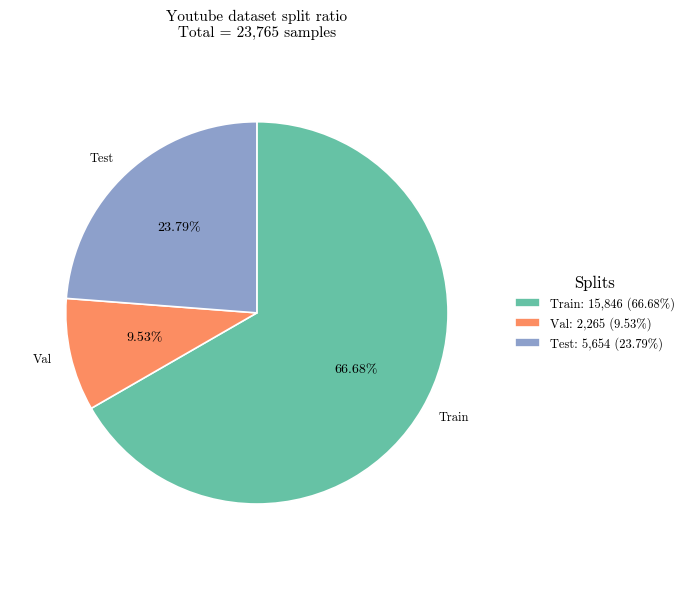

In [15]:
# SPLIT RATIO OVERVIEW

split_ratio_df = dataset_split_summary_df[['split', 'n_samples']].copy()
split_ratio_total = int(split_ratio_df['n_samples'].sum())
split_ratio_df['pct_of_total'] = (split_ratio_df['n_samples'] / max(1, split_ratio_total) * 100).round(2)
split_ratio_df['split'] = split_ratio_df['split'].str.title()

print(f"Total examples = {split_ratio_total:,} = training + validation + testing")
display(split_ratio_df)

fig, ax = plt.subplots(figsize=(7, 6))
split_colors = sns.color_palette('Set2', n_colors=len(split_ratio_df))
legend_labels = [
    f"{split}: {int(n):,} ({pct:.2f}%)"
    for split, n, pct in zip(split_ratio_df['split'], split_ratio_df['n_samples'], split_ratio_df['pct_of_total'])
]
wedges, texts, autotexts = ax.pie(
	split_ratio_df['n_samples'],
	labels=split_ratio_df['split'],
	colors=split_colors,
	startangle=90,
	counterclock=False,
	autopct=lambda pct: f'{pct:.2f}%',
	wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
)
ax.set_title(f"{PIPELINE_NAME.title()} dataset split ratio\nTotal = {split_ratio_total:,} samples")
ax.legend(wedges, legend_labels, title='Splits', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
ax.axis('equal')
plt.tight_layout()
save_figure(fig, FIG_DIR / f'dataset_split_ratio_pie_{PIPELINE_NAME}')
plt.show()
plt.close(fig)


## Preprocessing Definitions


### Character and Script Helpers


In [16]:
# SPECIAL TOKEN REGISTRATION AND SIGNAL PATTERNS

SPECIAL_TOKENS = {
    "url": "<URL>",
    "mention": "<MENTION>",
    "hashtag": "<HASHTAG>",
    "number": "<NUMBER>",
    "latin": "<LATIN>",
}
ALL_SPECIAL_TOKENS_LIST = [SPECIAL_TOKENS[key] for key in ("url", "mention", "hashtag", "number", "latin")]
TOKENIZER_LEVEL_SPECIAL_TOKENS = {"<UNK>", "<pad>"}
SPECIAL_TOKEN_PATTERN = re.compile(r"(<URL>|<MENTION>|<HASHTAG>|<NUMBER>|<LATIN>)")
ARABIC_DIACRITICS_PATTERN = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_CHAR = "\u0640"
ARABIC_INDIC_DIGITS = "٠١٢٣٤٥٦٧٨٩"
EASTERN_ARABIC_DIGITS = "۰۱۲۳۴۵۶۷۸۹"
ALEF_VARIANTS = {"أ": "ا", "إ": "ا", "آ": "ا", "ٱ": "ا"}
YEH_VARIANTS = {"ى": "ي", "ی": "ي"}
HAMZA_VARIANTS = {"ؤ": "و", "ئ": "ي"}
URL_PATTERN = re.compile(r"(?:https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_PATTERN = re.compile(r"(?<!\w)@[A-Za-z0-9_]+")
HASHTAG_PATTERN = re.compile(r"(?<!\w)#[\w\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF_]+")
ENGLISH_PATTERN = re.compile(r"[A-Za-z]+(?:[A-Za-z0-9_./+-]*[A-Za-z0-9])?")
NUMBER_SPAN_PATTERN = re.compile(r"(?<!\w)[\d\u0660-\u0669\u06F0-\u06F9]+(?:[.,:/\-][\d\u0660-\u0669\u06F0-\u06F9]+)*(?:[%٪])?")
HTML_TAG_PATTERN = re.compile(r"</?[^>\n]+>")
HTML_ENTITY_PATTERN = re.compile(r"&(?:[A-Za-z]+|#\d+|#x[0-9A-Fa-f]+);")
INVISIBLE_FORMATTING_PATTERN = re.compile(r"[\u200b-\u200f\u202a-\u202e\u2060-\u206f\ufeff]")
REPEATED_SEPARATOR_PATTERN = re.compile(r"([\-_=+~*#|/\\])\1+")
MINIMAL_PUNCT = "\u060C.\u061F"
ASCII_PUNCT = string.punctuation


def get_required_special_tokens(preprocessing_method):
    if preprocessing_method == "deepfake_aware":
        return [SPECIAL_TOKENS["number"]]
    return []


print("YouTube special-token registry defined.")

YouTube special-token registry defined.


In [17]:
# CHARACTER CLASSIFICATION HELPERS

def is_arabic_char(ch):
    """Check if character is Arabic (including extended ranges)."""
    code = ord(ch)
    return (
        (0x0600 <= code <= 0x06FF) or  # Arabic
        (0x0750 <= code <= 0x077F) or  # Arabic Supplement
        (0x08A0 <= code <= 0x08FF) or  # Arabic Extended-A
        (0xFB50 <= code <= 0xFDFF) or  # Arabic Presentation Forms-A
        (0xFE70 <= code <= 0xFEFF)     # Arabic Presentation Forms-B
    )

def is_english_char(ch):
    """Check if character is English letter."""
    return ('A' <= ch <= 'Z') or ('a' <= ch <= 'z')

print("Character classification helpers defined!")


Character classification helpers defined!


### Normalization and Replacement Helpers


In [18]:
# BASIC PREPROCESSING FUNCTIONS


def safe_str(text):
    if pd.isna(text):
        return ""
    return str(text)


def strip_html_like(text):
    text = safe_str(text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    return HTML_ENTITY_PATTERN.sub(" ", text)


def remove_invisible_and_control_chars(text):
    cleaned = []
    for ch in safe_str(text):
        if INVISIBLE_FORMATTING_PATTERN.match(ch):
            continue
        if unicodedata.category(ch) in {"Cf", "Cc", "Cs"} and ch not in {"\n", "\t", "\r"}:
            continue
        cleaned.append(ch)
    return "".join(cleaned)


def normalize_alef(text):
    text = safe_str(text)
    for variant, normalized in ALEF_VARIANTS.items():
        text = text.replace(variant, normalized)
    return text


def normalize_yeh(text):
    text = safe_str(text)
    for variant, normalized in YEH_VARIANTS.items():
        text = text.replace(variant, normalized)
    return text


def normalize_hamza(text):
    text = safe_str(text)
    for variant, normalized in HAMZA_VARIANTS.items():
        text = text.replace(variant, normalized)
    return text


def remove_diacritics(text):
    return ARABIC_DIACRITICS_PATTERN.sub("", safe_str(text))


def remove_tatweel(text):
    return safe_str(text).replace(TATWEEL_CHAR, "")


def normalize_repetition(text, max_repeat=2):
    text = safe_str(text)
    pattern = r"(.)\1{" + str(max_repeat) + r",}"
    return re.sub(pattern, r"\1" * max_repeat, text)


def apply_outside_special_tokens(text, transform):
    text = safe_str(text)
    parts = SPECIAL_TOKEN_PATTERN.split(text)
    out = []
    for part in parts:
        if not part:
            continue
        if SPECIAL_TOKEN_PATTERN.fullmatch(part):
            out.append(part)
        else:
            out.append(transform(part))
    return "".join(out)


def normalize_repetition_keep_tokens(text, max_repeat=2):
    return apply_outside_special_tokens(text, lambda part: normalize_repetition(part, max_repeat=max_repeat))


PUNCT_TRANSLATION = str.maketrans({
    ",": "\u060C",
    ";": "\u060C",
    "\u061b": "\u060C",
    "?": "\u061F",
    "!": ".",
    "\u2026": ".",
})


def normalize_punctuation(text):
    text = safe_str(text).translate(PUNCT_TRANSLATION)
    text = re.sub(r"\u060C{2,}", "\u060C", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r"\u061F{2,}", "\u061F", text)
    return text


def normalize_whitespace(text):
    return re.sub(r"\s+", " ", safe_str(text)).strip()


def normalize_token_spacing(text):
    text = SPECIAL_TOKEN_PATTERN.sub(lambda m: f" {m.group(1)} ", safe_str(text))
    text = re.sub(r"\s+([\u060C.\u061F])", r"\1", text)
    text = re.sub(r"([\u060C.\u061F])(?=\S)", r"\1 ", text)
    return normalize_whitespace(text)


def replace_urls(text):
    return URL_PATTERN.sub(f" {SPECIAL_TOKENS['url']} ", safe_str(text))


def replace_mentions(text):
    return MENTION_PATTERN.sub(f" {SPECIAL_TOKENS['mention']} ", safe_str(text))


def replace_hashtags(text):
    return HASHTAG_PATTERN.sub(f" {SPECIAL_TOKENS['hashtag']} ", safe_str(text))


def remove_urls(text):
    return URL_PATTERN.sub(" ", safe_str(text))


def remove_mentions(text):
    return MENTION_PATTERN.sub(" ", safe_str(text))


def remove_hashtags(text):
    return HASHTAG_PATTERN.sub(" ", safe_str(text))


def replace_number_spans(text):
    return apply_outside_special_tokens(text, lambda part: NUMBER_SPAN_PATTERN.sub(f" {SPECIAL_TOKENS['number']} ", part))


def replace_latin_spans(text):
    return apply_outside_special_tokens(text, lambda part: ENGLISH_PATTERN.sub(f" {SPECIAL_TOKENS['latin']} ", part))


def remove_latin_spans(text):
    return apply_outside_special_tokens(text, lambda part: ENGLISH_PATTERN.sub(" ", part))


def replace_emojis_with_library(text, replacement=" "):
    return emoji.replace_emoji(safe_str(text), replace=replacement)


def remove_emojis(text):
    return replace_emojis_with_library(text, " ")


def collapse_visual_separators(text):
    return apply_outside_special_tokens(text, lambda part: REPEATED_SEPARATOR_PATTERN.sub(" ", part))


def filter_text_chars(text, *, keep_tokens=False):
    text = safe_str(text)
    parts = SPECIAL_TOKEN_PATTERN.split(text) if keep_tokens else [text]
    out = []
    for part in parts:
        if keep_tokens and SPECIAL_TOKEN_PATTERN.fullmatch(part):
            out.append(part)
            continue
        kept = []
        for ch in part:
            if ch.isspace():
                kept.append(ch)
            elif is_arabic_char(ch) or ch.isdigit() or ch in MINIMAL_PUNCT:
                kept.append(ch)
        out.append("".join(kept))
    return "".join(out)

print("YouTube preprocessing helpers defined.")

YouTube preprocessing helpers defined.


In [19]:
# ODD CHARACTER HANDLING

def extract_odd_chars(texts, keep_chars=None):
    """Extract non-Arabic, non-English, non-digit characters from texts."""
    keep = set(keep_chars or [])
    odd = set()
    for text in texts.fillna(''):
        for ch in str(text):
            if ch.isspace() or ch in keep:
                continue
            if is_arabic_char(ch) or is_english_char(ch) or ch.isdigit():
                continue
            odd.add(ch)
    return ''.join(sorted(odd))

def compile_odd_pattern(odd_chars):
    """Compile regex pattern for odd characters."""
    if not odd_chars:
        return None
    return re.compile("[" + re.escape(odd_chars) + "]")

def handle_odd_chars(text, pattern=None):
    """Remove uncommon symbols captured by the dataset-specific odd-char pattern."""
    text = safe_str(text)
    if pattern is None or not pattern.search(text):
        return text
    text = pattern.sub(' ', text)
    return normalize_whitespace(text)

# Build odd-character patterns from datasets
ODD_CHARS_YOUTUBE = extract_odd_chars(youtube_train['text'], keep_chars=ASCII_PUNCT)
ODD_CHARS_YOUTUBE_PATTERN = compile_odd_pattern(ODD_CHARS_YOUTUBE)

print(f"YouTube odd chars ({len(ODD_CHARS_YOUTUBE)}): {ODD_CHARS_YOUTUBE}")

YouTube odd chars (10): «»כל–—“”…🤔


### Manual and Deepfake-Aware Methods

- `manual`: strong-cleaning Arabic baseline. It removes URLs, mentions, hashtags, emojis, HTML-like leftovers, invisible formatting characters, Latin fragments, and symbol clutter; then keeps mainly Arabic text, digits, and minimal punctuation after orthographic normalization.
- `deepfake_aware`: EDA-guided YouTube normalization. It converts digit spans to `<NUMBER>`, preserves Arabic letter variants, normalizes repetition, and removes hashtags, mentions, URLs, emojis, Latin text, diacritics, tatweel, and residual symbol clutter.

In [20]:
# METHOD 1: MANUAL PREPROCESSING

def preprocess_manual_youtube(text):
    text = safe_str(text)
    if not text:
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = strip_html_like(text)
    text = remove_invisible_and_control_chars(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_emojis(text)
    text = remove_diacritics(text)
    text = normalize_alef(text)
    text = normalize_yeh(text)
    text = normalize_hamza(text)
    text = remove_tatweel(text)
    text = normalize_repetition(text, max_repeat=1)
    text = normalize_punctuation(text)
    text = collapse_visual_separators(text)
    text = handle_odd_chars(text, pattern=ODD_CHARS_YOUTUBE_PATTERN)
    text = remove_latin_spans(text)
    text = filter_text_chars(text, keep_tokens=False)
    text = normalize_token_spacing(text)
    return text


print("Manual preprocessing functions defined!")

Manual preprocessing functions defined!


In [21]:
def preprocess_deepfake_aware_youtube(text):
    text = safe_str(text)
    if not text:
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = strip_html_like(text)
    text = remove_invisible_and_control_chars(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_emojis(text)
    text = replace_number_spans(text)
    text = remove_latin_spans(text)
    text = remove_diacritics(text)
    text = remove_tatweel(text)
    text = normalize_repetition_keep_tokens(text, max_repeat=2)
    text = normalize_punctuation(text)
    text = collapse_visual_separators(text)
    text = handle_odd_chars(text, pattern=ODD_CHARS_YOUTUBE_PATTERN)
    text = filter_text_chars(text, keep_tokens=True)
    text = normalize_token_spacing(text)
    return text


print("YouTube deepfake-aware preprocessing defined.")

YouTube deepfake-aware preprocessing defined.


## Apply Preprocessing Variants


### Apply Preprocessing to Each Split


In [22]:
# APPLY ALL PREPROCESSING METHODS (YOUTUBE ONLY)

def apply_all_preprocessing(df, dataset_name, preprocessors):
    # Cache each text view once so the ML, sequence, and transformer branches read the same inputs.
    df = df.copy()
    df["text_original"] = df["text"].fillna("").astype(str)

    print(f"{'=' * 80}")
    print(f"Applying preprocessing to {dataset_name} dataset ({len(df):,} samples)")
    print(f"{'=' * 80}")

    change_rows = []
    for name, fn in preprocessors.items():
        col = f"text_{name}"
        print(f"  Processing with {name.upper()}...", end=" ")
        df[col] = df["text_original"].apply(fn)
        changed = float((df[col] != df["text_original"]).mean() * 100)
        avg_tokens = float(df[col].fillna("").astype(str).str.split().map(len).mean())
        change_rows.append(
            {
                "platform": PIPELINE_NAME,
                "dataset": dataset_name,
                "preprocessing": name,
                "changed_pct": round(changed, 2),
                "avg_tokens": round(avg_tokens, 2),
                "rows": int(len(df)),
            }
        )
        print(f"Done! ({changed:.1f}% texts modified)")

    return df, change_rows


# Keep the controlled preprocessing grid explicit because later comparisons depend on these names staying fixed.
preprocessors_youtube = {
    "manual": preprocess_manual_youtube,
    "deepfake_aware": preprocess_deepfake_aware_youtube,
}


def _df_from_ds(ds):
    return pd.DataFrame({"text": ds["text"], "label": ds["label"]})


YOUTUBE_SPLITS = {
    "train": _df_from_ds(ds_ytb["train"]),
    "val": _df_from_ds(ds_ytb["val"]),
    "test": _df_from_ds(ds_ytb["test"]),
}

youtube_pp = {}
preprocessing_audit_rows = []
for split, df in YOUTUBE_SPLITS.items():
    processed_df, audit_rows = apply_all_preprocessing(df, f"{DISPLAY_NAME}/{split}", preprocessors_youtube)
    youtube_pp[split] = processed_df
    preprocessing_audit_rows.extend(audit_rows)


Applying preprocessing to YouTube/train dataset (15,846 samples)
  Processing with MANUAL... Done! (72.2% texts modified)
  Processing with DEEPFAKE_AWARE... Done! (32.2% texts modified)
Applying preprocessing to YouTube/val dataset (2,265 samples)
  Processing with MANUAL... Done! (72.1% texts modified)
  Processing with DEEPFAKE_AWARE... Done! (33.3% texts modified)
Applying preprocessing to YouTube/test dataset (5,654 samples)
  Processing with MANUAL... Done! (71.6% texts modified)
  Processing with DEEPFAKE_AWARE... Done! (32.0% texts modified)


### Build Dataset Views and Cache Files


In [23]:
def build_ds_from_pp(pp_splits, method):
    out = {}
    for split, df in pp_splits.items():
        text_col = "text_original" if method == "original" else f"text_{method}"
        df_out = df[[text_col, "label"]].rename(columns={text_col: "text"})
        out[split] = Dataset.from_pandas(df_out, preserve_index=False)
    return DatasetDict(out)


PREPROCESSING_METHODS = PREPROCESSING_ORDER.copy()
DS_YTB_BY_PREP = {m: build_ds_from_pp(youtube_pp, m) for m in PREPROCESSING_METHODS}
PREPROCESSING_RUN = PREPROCESSING_METHODS.copy()
ACTIVE_PREPROCESSING = PREPROCESSING_RUN[0] if PREPROCESSING_RUN else "original"
ds_active = DS_YTB_BY_PREP[ACTIVE_PREPROCESSING]

preprocessing_cache_rows = []
for method in PREPROCESSING_METHODS:
    method_dir = PREPROCESSED_CACHE_DIR / method
    method_dir.mkdir(parents=True, exist_ok=True)
    for split, ds_split in DS_YTB_BY_PREP[method].items():
        split_df = pd.DataFrame({"text": ds_split["text"], "label": ds_split["label"]})
        cache_path = method_dir / f"{split}.csv"
        split_df.to_csv(cache_path, index=False, encoding="utf-8")
        preprocessing_cache_rows.append(
            {
                "platform": PIPELINE_NAME,
                "preprocessing": method,
                "split": split,
                "rows": int(len(split_df)),
                "cache_path": str(cache_path),
            }
        )

preprocessing_cache_manifest = pd.DataFrame(preprocessing_cache_rows).sort_values(["preprocessing", "split"]).reset_index(drop=True)
preprocessing_cache_manifest.to_csv(TABLE_DIR / "cached_preprocessed_splits_manifest.csv", index=False)

preprocessing_audit_df = pd.DataFrame(preprocessing_audit_rows).sort_values(["dataset", "preprocessing"]).reset_index(drop=True)
preprocessing_audit_df.to_csv(TABLE_DIR / "preprocessing_change_audit.csv", index=False)


## Preprocessing Summaries and Sanity Checks


### Preprocessing Examples and Cache Audit


In [24]:
LABEL_NAME_MAP = {0: "Fake", 1: "Real"}


def _truncate_example_text(text, max_chars=180):
    text = str(text or "").replace("\n", " ").strip()
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3].rstrip() + "..."


def build_preprocessing_examples_table(pp_splits, split_name="test", n_examples=5):
    example_df = pp_splits[split_name].copy().reset_index().rename(columns={"index": "sample_id"})
    original_text = example_df["text_original"].fillna("").astype(str)
    example_df["label_name"] = example_df["label"].map(LABEL_NAME_MAP).fillna(example_df["label"].astype(str))
    example_df["text_len"] = original_text.str.len()
    example_df["change_score"] = 0

    for method in METHODS_NO_ORIGINAL:
        col = f"text_{method}"
        variant_text = example_df[col].fillna("").astype(str)
        example_df[f"{method}_changed"] = variant_text.ne(original_text).astype(int)
        example_df[f"{method}_delta_chars"] = (variant_text.str.len() - example_df["text_len"]).abs()
        example_df["change_score"] += example_df[f"{method}_changed"] * 10 + example_df[f"{method}_delta_chars"].clip(upper=25)

    ranked = example_df.sort_values(["change_score", "text_len", "sample_id"], ascending=[False, False, True]).copy()
    selected_frames = []
    for label_value in sorted(ranked["label"].dropna().unique().tolist()):
        label_subset = ranked[ranked["label"] == label_value].head(5)
        if not label_subset.empty:
            selected_frames.append(label_subset)

    selected = pd.concat(selected_frames, ignore_index=False) if selected_frames else ranked.head(0)
    if len(selected) < n_examples:
        remaining = ranked.loc[~ranked["sample_id"].isin(selected["sample_id"])].head(n_examples - len(selected))
        selected = pd.concat([selected, remaining], ignore_index=False)

    selected = (
        selected.drop_duplicates(subset=["sample_id"])
        .head(n_examples)
        .sort_values(["label", "change_score", "sample_id"], ascending=[True, False, True])
        .reset_index(drop=True)
    )

    display_df = pd.DataFrame(
        {
            "sample_id": selected["sample_id"].astype(int),
            "label": selected["label_name"],
            "source_split": split_name,
            "original": selected["text_original"].map(_truncate_example_text),
            "manual": selected["text_manual"].map(_truncate_example_text),
            "deepfake_aware": selected["text_deepfake_aware"].map(_truncate_example_text),
        }
    )
    return display_df


preprocessing_examples_df = build_preprocessing_examples_table(youtube_pp, split_name="test", n_examples=10)
preprocessing_examples_csv_path = TABLE_DIR / "preprocessing_examples_table.csv"
preprocessing_examples_md_path = TABLE_DIR / "preprocessing_examples_table.md"
preprocessing_examples_df.to_csv(preprocessing_examples_csv_path, index=False, encoding="utf-8")
preprocessing_examples_md_path.write_text(preprocessing_examples_df.to_markdown(index=False) + "\n", encoding="utf-8")

print(f"Saved preprocessing examples table CSV: {preprocessing_examples_csv_path}")
print(f"Saved preprocessing examples table markdown: {preprocessing_examples_md_path}")
display(preprocessing_examples_df)

print("=" * 80)
print("Available preprocessing:", PREPROCESSING_METHODS)
print("Configured run:", PREPROCESSING_RUN)
print("Default active preprocessing:", ACTIVE_PREPROCESSING)
print(f"Cached split manifest: {TABLE_DIR / 'cached_preprocessed_splits_manifest.csv'}")


Saved preprocessing examples table CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/preprocessing_examples_table.csv
Saved preprocessing examples table markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/preprocessing_examples_table.md


,sample_id,label,source_split,original,manual,deepfake_aware
0,457,Fake,test,ملخص الفيديو ١ - تاج الذكر: لا اله الا الله وح...,ملخص الفيديو ١ تاج الذكر لا اله الا اله وحده، ...,ملخص الفيديو <NUMBER> تاج الذكر لا اله الا الل...
1,513,Fake,test,الذاكرين لله بشكل مستمر والذاكرات، ربي جهز لهم...,الذاكرين له بشكل مستمر والذاكرات، ربي جهز لهم ...,الذاكرين لله بشكل مستمر والذاكرات، ربي جهز لهم...
2,807,Fake,test,صيام العشر الاوائل من ذي الحجه رح يبدا يوم الا...,صيام العشر الاوايل من ذي الحجه رح يبدا يوم الا...,صيام العشر الاوائل من ذي الحجه رح يبدا يوم الا...
3,2064,Fake,test,هههههههههههههههههههههههههههههههههههههههههههههه...,ه ه، فيهم الغش كثير، بس مو كلهم,هه هه، فيهم الغش كثير، بس مو كلهم
4,2498,Fake,test,قسمه ونصيب ههههههههههههههههههههههههههههههههههه...,قسمه ونصيب ه، كل شيء محسوب ومنظم بشكل مدهش.,قسمه ونصيب هه، كل شيء محسوب ومنظم بشكل مدهش.
5,2933,Real,test,افضل اطعمه ممكن نتناولها لعلاج فقر الدم و التخ...,افضل اطعمه مكن نتناولها لعلاج فقر الدم و التخل...,افضل اطعمه ممكن نتناولها لعلاج فقر الدم و التخ...
6,3345,Real,test,يارب مسنا الضر وانت ارحم الراحمين ء والله ما ت...,يارب مسنا الضر وانت ارحم الراحمين ء واله ما تك...,يارب مسنا الضر وانت ارحم الراحمين ء والله ما ت...
7,4579,Real,test,"عارف لما ربنا يقول علي حد انه "" نعم العبد"" فمم...",عارف لما ربنا يقول علي حد انه نعم العبد فمكن ا...,عارف لما ربنا يقول علي حد انه نعم العبد فممكن ...
8,4960,Real,test,من فضلكم رحمو من في الارض يرحمكم من في السماء ...,من فضلكم رحمو من في الارض يرحمكم من في السماء ...,من فضلكم رحمو من في الارض يرحمكم من في السماء ...
9,5546,Real,test,للهم صل وسلم علي سيدنا محمد عدد اوراق الاشجار ...,لهم صل وسلم علي سيدنا محمد عد اوراق الاشجار وص...,للهم صل وسلم علي سيدنا محمد عدد اوراق الاشجار ...


Available preprocessing: ['original', 'manual', 'deepfake_aware']
Configured run: ['original', 'manual', 'deepfake_aware']
Default active preprocessing: original
Cached split manifest: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/cached_preprocessed_splits_manifest.csv


## Static Embeddings and Representations


### Embedding Configuration


In [25]:
from collections import Counter

# These settings define the static embedding family used outside the transformer branch.
EMBEDDING_VECTOR_SIZE = 128
EMBEDDING_WINDOW = 10
EMBEDDING_MIN_COUNT = 2
EMBEDDING_EPOCHS = 25
EMBEDDING_WORKERS = max(1, (os.cpu_count() or 2) // 2)
EMBEDDING_NAMES = ["word2vec_cbow", "fasttext"]
SEQUENCE_EMBEDDING_NAMES = ["random", "word2vec_cbow", "fasttext"]


NON_TRANSFORMER_TOKENIZER_NAME = "whitespace_placeholder_preserving"

def tokenize_non_transformer_text(text):
    text = str(text or "").strip()
    return [tok for tok in text.split() if tok]

embedding_hyperparameter_summary = pd.DataFrame(
    [
        {
            "platform": PIPELINE_NAME,
            "embedding_vector_size": EMBEDDING_VECTOR_SIZE,
            "embedding_window": EMBEDDING_WINDOW,
            "embedding_min_count": EMBEDDING_MIN_COUNT,
            "embedding_epochs": EMBEDDING_EPOCHS,
            "embedding_workers": EMBEDDING_WORKERS,
            "embedding_names": ", ".join(EMBEDDING_NAMES),
            "sequence_embedding_names": ", ".join(SEQUENCE_EMBEDDING_NAMES),
            "notes": "Reviewed for study fairness, reproducibility, and Colab practicality.",
        }
    ]
)
embedding_hyperparameter_summary_csv_path = TABLE_DIR / f"embedding_hyperparameter_summary_{PIPELINE_NAME}.csv"
embedding_hyperparameter_summary_md_path = TABLE_DIR / f"embedding_hyperparameter_summary_{PIPELINE_NAME}.md"
write_dataframe_with_markdown(
    embedding_hyperparameter_summary,
    embedding_hyperparameter_summary_csv_path,
    embedding_hyperparameter_summary_md_path,
)

print(f"Saved embedding hyperparameter summary CSV: {embedding_hyperparameter_summary_csv_path}")
print(f"Saved embedding hyperparameter summary markdown: {embedding_hyperparameter_summary_md_path}")
display(embedding_hyperparameter_summary)


Saved embedding hyperparameter summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/embedding_hyperparameter_summary_youtube.csv
Saved embedding hyperparameter summary markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/embedding_hyperparameter_summary_youtube.md


,platform,embedding_vector_size,embedding_window,embedding_min_count,embedding_epochs,embedding_workers,embedding_names,sequence_embedding_names,notes
0,youtube,128,10,2,25,6,"word2vec_cbow, fasttext","random, word2vec_cbow, fasttext","Reviewed for study fairness, reproducibility, ..."


### Shared Tokenization and Representation Helpers


In [26]:
def embedding_family_for(name):
    if name == "tfidf":
        return "lexical"
    if name in {"word2vec_cbow", "fasttext"}:
        return "static_embedding"
    if name in {"arabertv2", "marbertv2", "camelbert"}:
        return "contextual_transformer"
    if name == "random":
        return "random_init"
    return "other"


def representation_type_for(name):
    if name == "tfidf":
        return "lexical_tfidf"
    if name in {"word2vec_cbow", "fasttext"}:
        return "static_embedding_mean_pool"
    if name in {"arabertv2", "marbertv2", "camelbert"}:
        return "contextual_transformer"
    if name == "random":
        return "sequence_random_init"
    return "other"


def tokenize_for_embedding(text):
    return tokenize_non_transformer_text(text)


### Train or Load Static Embeddings


In [27]:
def train_embedding_suite(train_tokenized, preprocessing):
    run_root = EMBEDDINGS_DIR / preprocessing
    run_root.mkdir(parents=True, exist_ok=True)

    suite = {
        "word2vec_cbow": Word2Vec(
            sentences=train_tokenized,
            vector_size=EMBEDDING_VECTOR_SIZE,
            window=EMBEDDING_WINDOW,
            min_count=EMBEDDING_MIN_COUNT,
            workers=EMBEDDING_WORKERS,
            sg=0,
            seed=SEED,
            epochs=EMBEDDING_EPOCHS,
        ),
        "fasttext": FastText(
            sentences=train_tokenized,
            vector_size=EMBEDDING_VECTOR_SIZE,
            window=EMBEDDING_WINDOW,
            min_count=EMBEDDING_MIN_COUNT,
            workers=EMBEDDING_WORKERS,
            sg=1,
            seed=SEED,
            epochs=EMBEDDING_EPOCHS,
            min_n=3,
            max_n=6,
        ),
    }

    manifest_rows = []
    for embedding_name, model in suite.items():
        target_dir = run_root / embedding_name
        target_dir.mkdir(parents=True, exist_ok=True)
        model_path = target_dir / "model.bin"
        model.save(str(model_path))
        payload = {
            "platform": PIPELINE_NAME,
            "preprocessing": preprocessing,
            "embedding_name": embedding_name,
            "embedding_family": embedding_family_for(embedding_name),
            "representation_type": representation_type_for(embedding_name),
            "trained_on_split": "train",
            "vector_size": EMBEDDING_VECTOR_SIZE,
            "window": EMBEDDING_WINDOW,
            "min_count": EMBEDDING_MIN_COUNT,
            "epochs": EMBEDDING_EPOCHS,
            "model_path": str(model_path),
            "notes": "Training-split only to prevent leakage.",
        }
        save_json(target_dir / "manifest.json", payload)
        manifest_rows.append(payload)
    return suite, manifest_rows


### Vectorization, Coverage, and Manifests


In [28]:
def get_vector_from_static_model(model, token, embedding_name):
    if embedding_name == "fasttext":
        return np.asarray(model.wv.get_vector(token), dtype=np.float32)
    if token in model.wv:
        return np.asarray(model.wv[token], dtype=np.float32)
    return None


def mean_pool_document(tokens, model, embedding_name):
    vectors = []
    for token in tokens:
        vec = get_vector_from_static_model(model, token, embedding_name)
        if vec is not None:
            vectors.append(vec)
    if not vectors:
        return np.zeros(EMBEDDING_VECTOR_SIZE, dtype=np.float32)
    return np.mean(np.vstack(vectors), axis=0).astype(np.float32)


def vectorize_documents(tokenized_texts, model, embedding_name):
    return np.vstack([mean_pool_document(tokens, model, embedding_name) for tokens in tokenized_texts]).astype(np.float32)


def compute_embedding_coverage(tokenized_texts, model, embedding_name):
    token_counter = Counter(token for tokens in tokenized_texts for token in tokens)
    total_tokens = int(sum(token_counter.values()))
    total_docs = int(len(tokenized_texts))
    unique_tokens = int(len(token_counter))
    in_vocab_tokens = int(sum(freq for token, freq in token_counter.items() if token in model.wv.key_to_index))
    coverage = (in_vocab_tokens / total_tokens) if total_tokens else np.nan
    if embedding_name == "fasttext":
        notes = "FastText can infer vectors for unseen tokens via subwords."
    else:
        notes = ""
    return {
        "n_docs": total_docs,
        "n_tokens": total_tokens,
        "n_unique_tokens": unique_tokens,
        "in_vocab_tokens": in_vocab_tokens,
        "coverage": coverage,
        "notes": notes,
    }


In [29]:
TOKENIZED_TEXTS_BY_PREP = {}
EMBEDDING_REGISTRY = {}
EMBEDDING_MANIFEST_ROWS = []
EMBEDDING_COVERAGE_ROWS = []

# Train each embedding suite on the training split only, then audit coverage on all splits.
for method in PREPROCESSING_RUN:
    split_tokens = {
        split: [tokenize_for_embedding(text) for text in DS_YTB_BY_PREP[method][split]["text"]]
        for split in ["train", "val", "test"]
    }
    TOKENIZED_TEXTS_BY_PREP[method] = split_tokens
    suite, manifest_rows = train_embedding_suite(split_tokens["train"], method)
    EMBEDDING_REGISTRY[method] = suite
    EMBEDDING_MANIFEST_ROWS.extend(manifest_rows)

    for embedding_name, model in suite.items():
        for split, tokenized_texts in split_tokens.items():
            coverage = compute_embedding_coverage(tokenized_texts, model, embedding_name)
            EMBEDDING_COVERAGE_ROWS.append(
                {
                    "platform": PIPELINE_NAME,
                    "preprocessing": method,
                    "split": split,
                    "embedding_family": embedding_family_for(embedding_name),
                    "embedding_name": embedding_name,
                    **coverage,
                }
            )

embedding_manifest_df = pd.DataFrame(EMBEDDING_MANIFEST_ROWS).sort_values(["preprocessing", "embedding_name"]).reset_index(drop=True)
embedding_manifest_df.to_csv(EMBEDDINGS_DIR / "embedding_manifest.csv", index=False)

embedding_coverage_summary = pd.DataFrame(EMBEDDING_COVERAGE_ROWS).sort_values(["preprocessing", "embedding_name", "split"]).reset_index(drop=True)
embedding_coverage_summary.to_csv(TABLE_DIR / "embedding_coverage_summary.csv", index=False)
embedding_coverage_summary.to_csv(EMBEDDINGS_DIR / "embedding_coverage_summary.csv", index=False)

embedding_setup_summary = pd.DataFrame(
    [
        {
            "platform": PIPELINE_NAME,
            "embedding_name": embedding_name,
            "objective": {
                "word2vec_cbow": "Word2Vec CBOW",
                "fasttext": "FastText Skip-Gram with subwords",
            }[embedding_name],
            "embedding_family": embedding_family_for(embedding_name),
            "representation_type": representation_type_for(embedding_name),
            "trained_on_split": "train",
            "vector_size": EMBEDDING_VECTOR_SIZE,
            "window": EMBEDDING_WINDOW,
            "min_count": EMBEDDING_MIN_COUNT,
            "epochs": EMBEDDING_EPOCHS,
            "sequence_supported": embedding_name in SEQUENCE_EMBEDDING_NAMES,
            "oov_behavior": "subword inference" if embedding_name == "fasttext" else "strict vocab lookup",
            "notes": "Available for dense mean pooling and sequence initialization" if embedding_name in SEQUENCE_EMBEDDING_NAMES else "Dense mean pooling",
        }
        for embedding_name in EMBEDDING_NAMES
    ]
).sort_values(["embedding_family", "embedding_name"]).reset_index(drop=True)
embedding_setup_summary_csv_path = TABLE_DIR / f"embedding_setup_summary_{PIPELINE_NAME}.csv"
embedding_setup_summary_md_path = TABLE_DIR / f"embedding_setup_summary_{PIPELINE_NAME}.md"
write_dataframe_with_markdown(
    embedding_setup_summary,
    embedding_setup_summary_csv_path,
    embedding_setup_summary_md_path,
)

print("=" * 80)
print("Embedding suite ready")
print("=" * 80)
print(f"Saved embedding setup summary CSV: {embedding_setup_summary_csv_path}")
print(f"Saved embedding setup summary markdown: {embedding_setup_summary_md_path}")
display(embedding_coverage_summary.head(12))
display(embedding_setup_summary)


Embedding suite ready
Saved embedding setup summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/embedding_setup_summary_youtube.csv
Saved embedding setup summary markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/embedding_setup_summary_youtube.md


,platform,preprocessing,split,embedding_family,embedding_name,n_docs,n_tokens,n_unique_tokens,in_vocab_tokens,coverage,notes
0,youtube,deepfake_aware,test,static_embedding,fasttext,5654,110938,26176,94334,0.850331,FastText can infer vectors for unseen tokens v...
1,youtube,deepfake_aware,train,static_embedding,fasttext,15846,307951,49309,278563,0.904569,FastText can infer vectors for unseen tokens v...
2,youtube,deepfake_aware,val,static_embedding,fasttext,2265,44819,13650,38507,0.859167,FastText can infer vectors for unseen tokens v...
3,youtube,deepfake_aware,test,static_embedding,word2vec_cbow,5654,110938,26176,94334,0.850331,
4,youtube,deepfake_aware,train,static_embedding,word2vec_cbow,15846,307951,49309,278563,0.904569,
5,youtube,deepfake_aware,val,static_embedding,word2vec_cbow,2265,44819,13650,38507,0.859167,
6,youtube,manual,test,static_embedding,fasttext,5654,110872,25931,94579,0.853047,FastText can infer vectors for unseen tokens v...
7,youtube,manual,train,static_embedding,fasttext,15846,307785,48481,279219,0.907188,FastText can infer vectors for unseen tokens v...
8,youtube,manual,val,static_embedding,fasttext,2265,44791,13560,38608,0.861959,FastText can infer vectors for unseen tokens v...
9,youtube,manual,test,static_embedding,word2vec_cbow,5654,110872,25931,94579,0.853047,


,platform,embedding_name,objective,embedding_family,representation_type,trained_on_split,vector_size,window,min_count,epochs,sequence_supported,oov_behavior,notes
0,youtube,fasttext,FastText Skip-Gram with subwords,static_embedding,static_embedding_mean_pool,train,128,10,2,25,True,subword inference,Available for dense mean pooling and sequence ...
1,youtube,word2vec_cbow,Word2Vec CBOW,static_embedding,static_embedding_mean_pool,train,128,10,2,25,True,strict vocab lookup,Available for dense mean pooling and sequence ...


## ML Models


### Feature Construction


In [30]:
# Feature Extraction for Traditional ML Classifiers (TF-IDF + Dense Embedding Vectors)
from sklearn.feature_extraction.text import TfidfVectorizer

require_globals(["PREPROCESSING_RUN", "DS_YTB_BY_PREP", "EMBEDDING_REGISTRY"], context="ML feature extraction")


def build_tfidf_features(train_texts, val_texts, test_texts):
    # Fit TF-IDF on training text only to avoid leaking validation or test vocabulary.
    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        lowercase=False,
        tokenizer=tokenize_non_transformer_text,
        token_pattern=None,
        analyzer="word",
    )
    X_train = vectorizer.fit_transform(train_texts)
    X_val = vectorizer.transform(val_texts)
    X_test = vectorizer.transform(test_texts)
    return vectorizer, X_train, X_val, X_test


In [31]:
# Keep lexical and dense feature branches parallel so the baseline comparison stays fair.
ml_feature_sets = {}
ml_feature_overview_rows = []

for method in PREPROCESSING_RUN:
    ds = DS_YTB_BY_PREP[method]
    train_texts = list(ds["train"]["text"])
    val_texts = list(ds["val"]["text"])
    test_texts = list(ds["test"]["text"])

    vectorizer, X_train, X_val, X_test = build_tfidf_features(train_texts, val_texts, test_texts)
    tokenized_splits = TOKENIZED_TEXTS_BY_PREP[method]
    dense_feature_sets = {}

    for embedding_name, model in EMBEDDING_REGISTRY[method].items():
        dense_feature_sets[embedding_name] = {
            "X_train": vectorize_documents(tokenized_splits["train"], model, embedding_name),
            "X_val": vectorize_documents(tokenized_splits["val"], model, embedding_name),
            "X_test": vectorize_documents(tokenized_splits["test"], model, embedding_name),
            "embedding_family": embedding_family_for(embedding_name),
            "representation_type": representation_type_for(embedding_name),
            "pooling": "mean",
        }
        ml_feature_overview_rows.append(
            {
                "platform": PIPELINE_NAME,
                "preprocessing": method,
                "feature_branch": "dense_embedding",
                "embedding_name": embedding_name,
                "train_shape": dense_feature_sets[embedding_name]["X_train"].shape,
                "val_shape": dense_feature_sets[embedding_name]["X_val"].shape,
                "test_shape": dense_feature_sets[embedding_name]["X_test"].shape,
                "notes": "Mean-pooled document vectors",
            }
        )

    ml_feature_sets[method] = {
        "lexical": {
            "vectorizer": vectorizer,
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "embedding_family": "lexical",
            "embedding_name": "tfidf",
            "representation_type": "lexical_tfidf",
        },
        "dense": dense_feature_sets,
        "y_train": np.asarray(ds["train"]["label"]),
        "y_val": np.asarray(ds["val"]["label"]),
        "y_test": np.asarray(ds["test"]["label"]),
    }

    ml_feature_overview_rows.append(
        {
            "platform": PIPELINE_NAME,
            "preprocessing": method,
            "feature_branch": "lexical_tfidf",
            "embedding_name": "tfidf",
            "train_shape": X_train.shape,
            "val_shape": X_val.shape,
            "test_shape": X_test.shape,
            "notes": "TF-IDF lexical baseline",
        }
    )

ml_feature_overview = pd.DataFrame(ml_feature_overview_rows)
ml_feature_overview.to_csv(TABLE_DIR / "ml_feature_overview.csv", index=False)
print("ML feature extraction complete.")
display(ml_feature_overview.head(12))


ML feature extraction complete.


,platform,preprocessing,feature_branch,embedding_name,train_shape,val_shape,test_shape,notes
0,youtube,original,dense_embedding,word2vec_cbow,"(15846, 128)","(2265, 128)","(5654, 128)",Mean-pooled document vectors
1,youtube,original,dense_embedding,fasttext,"(15846, 128)","(2265, 128)","(5654, 128)",Mean-pooled document vectors
2,youtube,original,lexical_tfidf,tfidf,"(15846, 10000)","(2265, 10000)","(5654, 10000)",TF-IDF lexical baseline
3,youtube,manual,dense_embedding,word2vec_cbow,"(15846, 128)","(2265, 128)","(5654, 128)",Mean-pooled document vectors
4,youtube,manual,dense_embedding,fasttext,"(15846, 128)","(2265, 128)","(5654, 128)",Mean-pooled document vectors
5,youtube,manual,lexical_tfidf,tfidf,"(15846, 10000)","(2265, 10000)","(5654, 10000)",TF-IDF lexical baseline
6,youtube,deepfake_aware,dense_embedding,word2vec_cbow,"(15846, 128)","(2265, 128)","(5654, 128)",Mean-pooled document vectors
7,youtube,deepfake_aware,dense_embedding,fasttext,"(15846, 128)","(2265, 128)","(5654, 128)",Mean-pooled document vectors
8,youtube,deepfake_aware,lexical_tfidf,tfidf,"(15846, 10000)","(2265, 10000)","(5654, 10000)",TF-IDF lexical baseline


### Metrics and Classifier Factories


In [32]:
# Traditional ML Classifiers Training
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC

print("=" * 60)
print("TRAINING TRADITIONAL ML CLASSIFIERS (LEXICAL + EMBEDDING BRANCHES)")
print("=" * 60)


# Macro-F1 stays the main ranking signal when these runs are merged with sequence and transformer results.
def compute_metrics_row(y_true, y_pred):
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def lexical_classifiers():
    return {
        "linearsvc": CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", random_state=SEED), cv=3),
        "logisticregression": LogisticRegression(C=1.0, penalty="l2", max_iter=2000, class_weight="balanced", random_state=SEED, solver="liblinear"),
        "randomforest": RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=4, min_samples_leaf=1, max_features="sqrt", bootstrap=True, class_weight="balanced", random_state=SEED, n_jobs=-1),
    }


def dense_classifiers():
    return {
        "linearsvc": CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", random_state=SEED), cv=3),
        "logisticregression": LogisticRegression(C=1.0, penalty="l2", max_iter=2000, class_weight="balanced", random_state=SEED, solver="liblinear"),
        "randomforest": RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=4, min_samples_leaf=1, max_features="sqrt", bootstrap=True, class_weight="balanced", random_state=SEED, n_jobs=-1),
    }




def ml_regularization_details(model_name):
    details = {
        "linearsvc": {"regularization_type": "L2 margin (C)", "regularization_strength": "C=1.0"},
        "logisticregression": {"regularization_type": "L2 logistic (C)", "regularization_strength": "C=1.0"},
        "randomforest": {"regularization_type": "tree depth + split/leaf constraints + ensemble", "regularization_strength": "max_depth=30, min_samples_split=4, min_samples_leaf=1, max_features=sqrt, bootstrap=True, n_estimators=200"},
    }
    return details.get(model_name, {"regularization_type": "not_specified", "regularization_strength": "default"})

def fit_and_score_classifier(clf, X_train, y_train, X_val, y_val, X_test, y_test):
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time
    train_pred = clf.predict(X_train)
    val_pred = clf.predict(X_val)
    test_pred = clf.predict(X_test)
    return {
        "estimator": clf,
        "training_time": training_time,
        "train_predictions": train_pred,
        "val_predictions": val_pred,
        "test_predictions": test_pred,
        "train_metrics": compute_metrics_row(y_train, train_pred),
        "val_metrics": compute_metrics_row(y_val, val_pred),
        "test_metrics": compute_metrics_row(y_test, test_pred),
    }


ml_results = {}
ml_models = {}
ml_results_rows = []


TRAINING TRADITIONAL ML CLASSIFIERS (LEXICAL + EMBEDDING BRANCHES)


### Lexical and Dense Training Loops


In [33]:
for method in PREPROCESSING_RUN:
    print("-" * 60)
    print(f"Preprocessing: {method}")
    print("-" * 60)

    feats = ml_feature_sets[method]
    y_train = feats["y_train"]
    y_val = feats["y_val"]
    y_test = feats["y_test"]
    ml_results[method] = {}
    ml_models[method] = {}

    for model_name, clf in lexical_classifiers().items():
        result = fit_and_score_classifier(
            clf,
            feats["lexical"]["X_train"],
            y_train,
            feats["lexical"]["X_val"],
            y_val,
            feats["lexical"]["X_test"],
            y_test,
        )
        config_name = f"{model_name}__tfidf"
        model_path = ML_RESULTS / "per_classifier" / f"{config_name}__{method}.joblib"
        joblib.dump({"estimator": result["estimator"], "vectorizer": feats["lexical"]["vectorizer"]}, model_path)

        reg_details = ml_regularization_details(model_name)
        row = {
            "platform": PIPELINE_NAME,
            "evaluation_scope": "in_domain",
            "source_platform": PIPELINE_NAME,
            "target_platform": PIPELINE_NAME,
            "preprocessing": method,
            "embedding_family": "lexical",
            "embedding_name": "tfidf",
            "representation_type": "lexical_tfidf",
            "model_family": "ML",
            "model_name": model_name,
            "config_name": config_name,
            "training_time": result["training_time"],
            "seed": SEED,
            "regularization_type": reg_details["regularization_type"],
            "regularization_strength": reg_details["regularization_strength"],
            "early_stopping_used": False,
            "notes": "Lexical TF-IDF baseline",
            **{k: result["test_metrics"][k] for k in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"]},
        }
        ml_results_rows.append(row)
        ml_results[method][config_name] = {
            "model_name": model_name,
            "config_name": config_name,
            "embedding_family": "lexical",
            "embedding_name": "tfidf",
            "representation_type": "lexical_tfidf",
            "model_label": f"{model_name.upper()} [TF-IDF]",
            "feature_branch": "lexical",
            "vectorizer": feats["lexical"]["vectorizer"],
            "training_time": result["training_time"],
            "train_predictions": result["train_predictions"],
            "test_predictions": result["test_predictions"],
            "val_predictions": result["val_predictions"],
            "train_metrics": result["train_metrics"],
            "test_metrics": result["test_metrics"],
            "val_metrics": result["val_metrics"],
            "estimator": result["estimator"],
            "model_path": model_path,
            "regularization_type": reg_details["regularization_type"],
            "regularization_strength": reg_details["regularization_strength"],
            "early_stopping_used": False,
            "notes": "Lexical TF-IDF baseline",
        }
        ml_models[method][config_name] = result["estimator"]
    for embedding_name, dense_feats in feats["dense"].items():
        for model_name, clf in dense_classifiers().items():
            result = fit_and_score_classifier(
                clf,
                dense_feats["X_train"],
                y_train,
                dense_feats["X_val"],
                y_val,
                dense_feats["X_test"],
                y_test,
            )
            config_name = f"{model_name}__{embedding_name}"
            model_path = ML_RESULTS / "per_classifier" / f"{config_name}__{method}.joblib"
            joblib.dump({"estimator": result["estimator"], "embedding_name": embedding_name, "preprocessing": method}, model_path)

            reg_details = ml_regularization_details(model_name)
            row = {
                "platform": PIPELINE_NAME,
                "evaluation_scope": "in_domain",
                "source_platform": PIPELINE_NAME,
                "target_platform": PIPELINE_NAME,
                "preprocessing": method,
                "embedding_family": dense_feats["embedding_family"],
                "embedding_name": embedding_name,
                "representation_type": dense_feats["representation_type"],
                "model_family": "ML",
                "model_name": model_name,
                "config_name": config_name,
                "training_time": result["training_time"],
                "seed": SEED,
            "regularization_type": reg_details["regularization_type"],
            "regularization_strength": reg_details["regularization_strength"],
            "early_stopping_used": False,
                "notes": "Dense document vectors with mean pooling",
                **{k: result["test_metrics"][k] for k in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"]},
            }
            ml_results_rows.append(row)
            ml_results[method][config_name] = {
                "model_name": model_name,
                "config_name": config_name,
                "embedding_family": dense_feats["embedding_family"],
                "embedding_name": embedding_name,
                "representation_type": dense_feats["representation_type"],
                "model_label": f"{model_name.upper()} [{embedding_name}]",
                "feature_branch": "dense",
                "training_time": result["training_time"],
                "train_predictions": result["train_predictions"],
                "test_predictions": result["test_predictions"],
                "val_predictions": result["val_predictions"],
                "train_metrics": result["train_metrics"],
                "test_metrics": result["test_metrics"],
                "val_metrics": result["val_metrics"],
                "estimator": result["estimator"],
                "model_path": model_path,
            "regularization_type": reg_details["regularization_type"],
            "regularization_strength": reg_details["regularization_strength"],
            "early_stopping_used": False,
                "notes": row["notes"],
            }
            ml_models[method][config_name] = result["estimator"]

ml_results_df = pd.DataFrame(ml_results_rows).sort_values(["preprocessing", "embedding_name", "model_name"]).reset_index(drop=True)
ml_results_df.to_csv(ML_RESULTS / "ml_classifiers_results_by_preprocessing.csv", index=False)
ml_results_df.to_csv(TABLE_DIR / "ml_classifiers_results_by_preprocessing.csv", index=False)
print(f"Results saved to: {ML_RESULTS / 'ml_classifiers_results_by_preprocessing.csv'}")
display(ml_results_df.head(12))


------------------------------------------------------------
Preprocessing: original
------------------------------------------------------------
------------------------------------------------------------
Preprocessing: manual
------------------------------------------------------------
------------------------------------------------------------
Preprocessing: deepfake_aware
------------------------------------------------------------
Results saved to: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/ml_classifiers/ml_classifiers_results_by_preprocessing.csv


,platform,evaluation_scope,source_platform,target_platform,preprocessing,embedding_family,embedding_name,representation_type,model_family,model_name,...,regularization_strength,early_stopping_used,notes,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,ML,linearsvc,...,C=1.0,False,Dense document vectors with mean pooling,0.890520,0.890524,0.890520,0.890520,0.890524,0.890520,0.890520
1,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,ML,logisticregression,...,C=1.0,False,Dense document vectors with mean pooling,0.889636,0.889686,0.889636,0.889632,0.889686,0.889636,0.889632
2,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,ML,randomforest,...,"max_depth=30, min_samples_split=4, min_samples...",False,Dense document vectors with mean pooling,0.873187,0.873664,0.873187,0.873147,0.873664,0.873187,0.873147
3,youtube,in_domain,youtube,youtube,deepfake_aware,lexical,tfidf,lexical_tfidf,ML,linearsvc,...,C=1.0,False,Lexical TF-IDF baseline,0.882561,0.883141,0.882561,0.882517,0.883141,0.882561,0.882517
4,youtube,in_domain,youtube,youtube,deepfake_aware,lexical,tfidf,lexical_tfidf,ML,logisticregression,...,C=1.0,False,Lexical TF-IDF baseline,0.876724,0.879126,0.876724,0.876529,0.879126,0.876724,0.876529
5,youtube,in_domain,youtube,youtube,deepfake_aware,lexical,tfidf,lexical_tfidf,ML,randomforest,...,"max_depth=30, min_samples_split=4, min_samples...",False,Lexical TF-IDF baseline,0.826141,0.834892,0.826141,0.824997,0.834892,0.826141,0.824997
6,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,ML,linearsvc,...,C=1.0,False,Dense document vectors with mean pooling,0.849487,0.849514,0.849487,0.849484,0.849514,0.849487,0.849484
7,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,ML,logisticregression,...,C=1.0,False,Dense document vectors with mean pooling,0.846834,0.846918,0.846834,0.846825,0.846918,0.846834,0.846825
8,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,ML,randomforest,...,"max_depth=30, min_samples_split=4, min_samples...",False,Dense document vectors with mean pooling,0.847011,0.847162,0.847011,0.846994,0.847162,0.847011,0.846994
9,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,static_embedding_mean_pool,ML,linearsvc,...,C=1.0,False,Dense document vectors with mean pooling,0.879377,0.879426,0.879377,0.879374,0.879426,0.879377,0.879374


## Sequence Models


### Sequence Feature Preparation


In [34]:
# Sequence Text Preparation Helpers
import copy
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

FAMILY_HISTORY_MAX_EPOCHS = 5
SEQ_MAX_LEN = globals().get("DEFAULT_MAX_LEN", 128)
SEQ_MAX_WORDS = 25000
SEQ_EMBED_DIM = EMBEDDING_VECTOR_SIZE if "EMBEDDING_VECTOR_SIZE" in globals() else 128
SEQ_HIDDEN_UNITS = 64
SEQ_DROPOUT = 0.25
SEQ_BATCH_SIZE = 64
SEQ_EPOCHS = FAMILY_HISTORY_MAX_EPOCHS
SEQ_WEIGHT_DECAY = 1e-4  # L2 regularization for fixed-epoch sequence training
SEQ_LEARNING_RATE = 1e-3
SEQ_PAD_TOKEN = "<PAD>"
SEQ_OOV_TOKEN = "<OOV>"
SEQ_PAD_IDX = 0
SEQ_OOV_IDX = 1
SEQ_NUM_WORKERS = 0
SEQUENCE_EMBEDDING_FREEZE = False

SEQUENCE_MODELS_DIR = MODELS_DIR / "sequence_models"
SEQUENCE_RESULTS_DIR = RESULTS / "sequence_models"
SEQUENCE_TABLES_DIR = SEQUENCE_RESULTS_DIR / "tables"
SEQUENCE_REPORTS_DIR = SEQUENCE_RESULTS_DIR / "classification_reports"
SEQUENCE_PLOTS_DIR = SEQUENCE_RESULTS_DIR / "plots"
for _dir in [SEQUENCE_MODELS_DIR, SEQUENCE_RESULTS_DIR, SEQUENCE_TABLES_DIR, SEQUENCE_REPORTS_DIR, SEQUENCE_PLOTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

SEQUENCE_DS_BY_PREP = DS_YTB_BY_PREP


def build_vocabulary(tokenized_texts, max_words=SEQ_MAX_WORDS):
    counter = Counter(token for tokens in tokenized_texts for token in tokens)
    most_common = counter.most_common(max(0, max_words - 2))
    word_to_idx = {SEQ_PAD_TOKEN: SEQ_PAD_IDX, SEQ_OOV_TOKEN: SEQ_OOV_IDX}
    for token, _ in most_common:
        if token not in word_to_idx:
            word_to_idx[token] = len(word_to_idx)
    return word_to_idx


def encode_tokenized_texts(tokenized_texts, word_to_idx, max_len=SEQ_MAX_LEN):
    encoded = np.full((len(tokenized_texts), max_len), SEQ_PAD_IDX, dtype=np.int64)
    lengths = np.zeros(len(tokenized_texts), dtype=np.int64)
    for idx, tokens in enumerate(tokenized_texts):
        ids = [word_to_idx.get(token, SEQ_OOV_IDX) for token in tokens[:max_len]]
        lengths[idx] = max(1, len(ids))
        if ids:
            encoded[idx, : len(ids)] = ids
    return encoded, lengths


def build_sequence_embedding_matrix(word_to_idx, preprocessing, embedding_name):
    matrix = np.random.normal(0.0, 0.05, (len(word_to_idx), SEQ_EMBED_DIM)).astype(np.float32)
    matrix[SEQ_PAD_IDX] = 0.0
    if embedding_name == "random":
        return matrix, {"covered_words": 0, "total_words": max(0, len(word_to_idx) - 2), "coverage": np.nan}

    model = EMBEDDING_REGISTRY[preprocessing][embedding_name]
    covered = 0
    for token, idx in word_to_idx.items():
        if idx < 2:
            continue
        vec = get_vector_from_static_model(model, token, embedding_name)
        if vec is not None:
            matrix[idx] = vec
            covered += 1
    total_words = max(0, len(word_to_idx) - 2)
    coverage = covered / total_words if total_words else np.nan
    return matrix, {"covered_words": covered, "total_words": total_words, "coverage": coverage}


### Sequence Datasets, Metrics, and Checkpoints


In [35]:
def build_sequence_features(dsd, preprocessing):
    train_tokens = [tokenize_for_embedding(text) for text in dsd["train"]["text"]]
    val_tokens = [tokenize_for_embedding(text) for text in dsd["val"]["text"]]
    test_tokens = [tokenize_for_embedding(text) for text in dsd["test"]["text"]]
    word_to_idx = build_vocabulary(train_tokens, max_words=SEQ_MAX_WORDS)
    X_train, train_lengths = encode_tokenized_texts(train_tokens, word_to_idx, max_len=SEQ_MAX_LEN)
    X_val, val_lengths = encode_tokenized_texts(val_tokens, word_to_idx, max_len=SEQ_MAX_LEN)
    X_test, test_lengths = encode_tokenized_texts(test_tokens, word_to_idx, max_len=SEQ_MAX_LEN)
    return {
        "preprocessing": preprocessing,
        "word_to_idx": word_to_idx,
        "train_tokens": train_tokens,
        "val_tokens": val_tokens,
        "test_tokens": test_tokens,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "train_lengths": train_lengths,
        "val_lengths": val_lengths,
        "test_lengths": test_lengths,
        "y_train": np.asarray(dsd["train"]["label"], dtype=np.int64),
        "y_val": np.asarray(dsd["val"]["label"], dtype=np.int64),
        "y_test": np.asarray(dsd["test"]["label"], dtype=np.int64),
        "vocab_size": len(word_to_idx),
        "max_len": SEQ_MAX_LEN,
        "pad_idx": SEQ_PAD_IDX,
        "oov_idx": SEQ_OOV_IDX,
    }


class SequenceTensorDataset(TorchDataset):
    def __init__(self, X, lengths, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.lengths[idx], self.y[idx]


def build_sequence_loader(X, lengths, y, shuffle):
    return DataLoader(
        SequenceTensorDataset(X, lengths, y),
        batch_size=SEQ_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=SEQ_NUM_WORKERS,
    )


def compute_binary_classification_metrics(y_true, y_pred):
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def save_sequence_checkpoint(path, state_dict, metadata):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": state_dict, "metadata": metadata}, path)


def load_sequence_checkpoint(path):
    payload = torch.load(path, map_location="cpu")
    return payload["state_dict"], payload.get("metadata", {})


### Sequence Model Definitions


In [36]:
# LSTM / BiLSTM Model Builders
class BaseSequenceClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_units, dropout, pad_idx, bidirectional=False, embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = not freeze_embeddings
        self.encoder = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_units,
            batch_first=True,
            bidirectional=bidirectional,
        )
        out_dim = hidden_units * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, 2)

    def forward(self, tokens, lengths):
        embedded = self.embedding(tokens)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.encoder(packed)
        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]
        logits = self.classifier(self.dropout(hidden))
        return logits


def build_lstm_classifier(vocab_size, embedding_matrix=None):
    return BaseSequenceClassifier(
        vocab_size=vocab_size,
        embed_dim=SEQ_EMBED_DIM,
        hidden_units=SEQ_HIDDEN_UNITS,
        dropout=SEQ_DROPOUT,
        pad_idx=SEQ_PAD_IDX,
        bidirectional=False,
        embedding_matrix=embedding_matrix,
        freeze_embeddings=SEQUENCE_EMBEDDING_FREEZE,
    )


def build_bilstm_classifier(vocab_size, embedding_matrix=None):
    return BaseSequenceClassifier(
        vocab_size=vocab_size,
        embed_dim=SEQ_EMBED_DIM,
        hidden_units=SEQ_HIDDEN_UNITS,
        dropout=SEQ_DROPOUT,
        pad_idx=SEQ_PAD_IDX,
        bidirectional=True,
        embedding_matrix=embedding_matrix,
        freeze_embeddings=SEQUENCE_EMBEDDING_FREEZE,
    )


SEQUENCE_MODEL_BUILDERS = {
    "lstm": build_lstm_classifier,
    "bilstm": build_bilstm_classifier,
}


def instantiate_sequence_model(architecture, vocab_size, embedding_matrix):
    return SEQUENCE_MODEL_BUILDERS[architecture](vocab_size=vocab_size, embedding_matrix=embedding_matrix)


### Sequence Evaluation Helpers


In [37]:
def evaluate_sequence_model(model, loader):
    model.eval()
    model.to(DEVICE)

    y_true, y_pred, probabilities = [], [], []
    loss_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for tokens, lengths, labels in loader:
            tokens = tokens.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(tokens, lengths)
            loss = torch.nn.functional.cross_entropy(logits, labels)

            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            loss_sum += float(loss.item())
            n_batches += 1

            y_true.extend(labels.detach().cpu().numpy().tolist())
            y_pred.extend(preds.detach().cpu().numpy().tolist())
            probabilities.extend(probs.detach().cpu().numpy().tolist())

    metrics = compute_binary_classification_metrics(
        np.asarray(y_true),
        np.asarray(y_pred)
    )
    metrics["loss"] = loss_sum / max(1, n_batches)

    return (
        metrics,
        np.asarray(y_pred),
        np.asarray(y_true),
        np.asarray(probabilities),
    )


def load_saved_sequence_model(run_data):
    metadata_path = Path(run_data["metadata_path"])
    metadata = load_json(metadata_path, default={})
    embedding_matrix = None
    if metadata.get("embedding_matrix_path"):
        embedding_matrix = np.load(metadata["embedding_matrix_path"])
    model = instantiate_sequence_model(metadata["architecture"], metadata["vocab_size"], embedding_matrix)
    state_dict, checkpoint_meta = load_sequence_checkpoint(run_data["best_model_path"])
    model.load_state_dict(state_dict)
    model.eval()
    return model, checkpoint_meta or metadata


### Sequence Training Helper


In [38]:
# Train LSTM and BiLSTM Baselines Across Preprocessing Variants
def train_sequence_baseline(architecture, features, preprocessing, embedding_name):
    embedding_matrix, coverage = build_sequence_embedding_matrix(features["word_to_idx"], preprocessing, embedding_name)
    model = instantiate_sequence_model(architecture, features["vocab_size"], embedding_matrix)
    model = model.to(DEVICE)

    train_loader = build_sequence_loader(features["X_train"], features["train_lengths"], features["y_train"], shuffle=True)
    val_loader = build_sequence_loader(features["X_val"], features["val_lengths"], features["y_val"], shuffle=False)
    test_loader = build_sequence_loader(features["X_test"], features["test_lengths"], features["y_test"], shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=SEQ_LEARNING_RATE, weight_decay=SEQ_WEIGHT_DECAY)
    best_state = None
    best_val_macro_f1 = -1.0
    best_val_loss = float("inf")
    best_epoch = 0
    history_rows = []
    start_time = time.time()

    # Keep the validation-best checkpoint so test evaluation follows one consistent model-selection rule.
    for epoch in range(1, SEQ_EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for tokens, lengths, labels in train_loader:
            tokens = tokens.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(tokens, lengths)
            loss = torch.nn.functional.cross_entropy(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += float(loss.item())
            n_batches += 1

        val_metrics, _, _, _ = evaluate_sequence_model(model, val_loader)
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": epoch_loss / max(1, n_batches),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
            }
        )

        current_val_macro_f1 = float(val_metrics["macro_f1"])
        current_val_loss = float(val_metrics["loss"])
        is_better_f1 = current_val_macro_f1 > (best_val_macro_f1 + 1e-12)
        is_tie_better_loss = abs(current_val_macro_f1 - best_val_macro_f1) <= 1e-12 and current_val_loss < (best_val_loss - 1e-12)
        if is_better_f1 or is_tie_better_loss:
            best_val_macro_f1 = current_val_macro_f1
            best_val_loss = current_val_loss
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())

    final_state = copy.deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)

    training_time = time.time() - start_time
    train_eval_loader = build_sequence_loader(features["X_train"], features["train_lengths"], features["y_train"], shuffle=False)
    train_metrics, train_preds, train_labels, train_probs = evaluate_sequence_model(model, train_eval_loader)
    val_metrics, val_preds, val_labels, val_probs = evaluate_sequence_model(model, val_loader)
    test_metrics, test_preds, test_labels, test_probs = evaluate_sequence_model(model, test_loader)

    config_name = f"{architecture}__{embedding_name}"
    run_dir = SEQUENCE_MODELS_DIR / preprocessing / config_name
    run_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = run_dir / "best_model.pt"
    final_model_path = run_dir / "final_model.pt"
    vocab_path = run_dir / "vocab.json"
    history_path = run_dir / "history.csv"
    metadata_path = run_dir / "metadata.json"
    embedding_matrix_path = run_dir / "embedding_matrix.npy"

    np.save(embedding_matrix_path, embedding_matrix.astype(np.float32))
    pd.DataFrame(history_rows).to_csv(history_path, index=False)
    with open(vocab_path, "w", encoding="utf-8") as f:
        json.dump(features["word_to_idx"], f, ensure_ascii=False, indent=2)

    metadata = {
        "platform": PIPELINE_NAME,
        "preprocessing": preprocessing,
        "architecture": architecture,
        "embedding_name": embedding_name,
        "embedding_family": embedding_family_for(embedding_name),
        "representation_type": "sequence_embedding_init" if embedding_name != "random" else "sequence_random_init",
        "trainable_embeddings": not SEQUENCE_EMBEDDING_FREEZE,
        "dropout": SEQ_DROPOUT,
        "weight_decay": SEQ_WEIGHT_DECAY,
        "optimizer": "AdamW",
        "regularization_type": "dropout + weight_decay",
        "early_stopping_used": False,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro_f1,
        "best_val_loss": best_val_loss,
        "selection_rule": "max_val_macro_f1__tie_min_val_loss__then_earlier_epoch",
        "selected_checkpoint": "best_validation_macro_f1",
        "training_time": training_time,
        "vocab_size": features["vocab_size"],
        "max_len": features["max_len"],
        "pad_idx": features["pad_idx"],
        "oov_idx": features["oov_idx"],
        "embedding_matrix_path": str(embedding_matrix_path),
        "coverage": coverage,
    }
    final_checkpoint_metadata = {**metadata, "checkpoint_type": "final_epoch", "final_epoch": int(len(history_rows))}
    save_json(metadata_path, metadata)
    save_sequence_checkpoint(best_model_path, model.state_dict(), metadata)
    save_sequence_checkpoint(final_model_path, final_state, final_checkpoint_metadata)

    return {
        "model_name": architecture,
        "config_name": config_name,
        "model_label": f"{architecture.upper()} [{embedding_name}]",
        "preprocessing": preprocessing,
        "embedding_name": embedding_name,
        "embedding_family": embedding_family_for(embedding_name),
        "representation_type": metadata["representation_type"],
        "max_len": features["max_len"],
        "vocab_size": features["vocab_size"],
        "training_time": training_time,
        "history": pd.DataFrame(history_rows),
        "metadata": metadata,
        "metadata_path": metadata_path,
        "run_dir": run_dir,
        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "vocab_path": vocab_path,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "y_train": train_labels,
        "y_val": val_labels,
        "y_test": test_labels,
        "train_probabilities": train_probs,
        "val_probabilities": val_probs,
        "test_probabilities": test_probs,
        "train_predictions": train_preds,
        "val_predictions": val_preds,
        "test_predictions": test_preds,
        "coverage": coverage,
    }


### Sequence Runs and Export Summary


In [39]:
sequence_feature_overview = {}
sequence_model_runs = {}
sequence_results_rows = []
sequence_history_frames = []
sequence_embedding_rows = []

print("=" * 70)
print("TRAINING LSTM AND BILSTM BASELINES")
print("=" * 70)

# Reuse the cached preprocessing splits here so architecture and initialization effects stay isolated.
for method in PREPROCESSING_RUN:
    print("\n" + "-" * 70)
    print(f"Preprocessing: {method}")
    print("-" * 70)
    features = build_sequence_features(SEQUENCE_DS_BY_PREP[method], preprocessing=method)
    sequence_feature_overview[method] = {
        "vocab_size": int(features["vocab_size"]),
        "max_len": int(features["max_len"]),
        "train_size": int(len(features["y_train"])),
        "val_size": int(len(features["y_val"])),
        "test_size": int(len(features["y_test"])),
    }
    sequence_model_runs[method] = {}

    for architecture in SEQUENCE_MODEL_BUILDERS.keys():
        for embedding_name in SEQUENCE_EMBEDDING_NAMES:
            run_data = train_sequence_baseline(
                architecture=architecture,
                features=features,
                preprocessing=method,
                embedding_name=embedding_name,
            )
            sequence_model_runs[method][run_data["config_name"]] = run_data

            sequence_results_rows.append(
                {
                    "platform": PIPELINE_NAME,
                    "evaluation_scope": "in_domain",
                    "source_platform": PIPELINE_NAME,
                    "target_platform": PIPELINE_NAME,
                    "preprocessing": method,
                    "embedding_family": run_data["embedding_family"],
                    "embedding_name": embedding_name,
                    "representation_type": run_data["representation_type"],
                    "model_family": "Sequence",
                    "model_name": architecture,
                    "config_name": run_data["config_name"],
                    "max_len": run_data["max_len"],
                    "training_time": run_data["training_time"],
                    "seed": SEED,
                    "accuracy": run_data["test_metrics"]["accuracy"],
                    "macro_precision": run_data["test_metrics"]["macro_precision"],
                    "macro_recall": run_data["test_metrics"]["macro_recall"],
                    "macro_f1": run_data["test_metrics"]["macro_f1"],
                    "weighted_precision": run_data["test_metrics"]["weighted_precision"],
                    "weighted_recall": run_data["test_metrics"]["weighted_recall"],
                    "weighted_f1": run_data["test_metrics"]["weighted_f1"],
                    "notes": f"coverage={run_data['coverage']['coverage']:.4f}" if pd.notna(run_data["coverage"]["coverage"]) else "random initialization",
                }
            )
            sequence_embedding_rows.append(
                {
                    "platform": PIPELINE_NAME,
                    "preprocessing": method,
                    "architecture": architecture,
                    "embedding_name": embedding_name,
                    "covered_words": run_data["coverage"]["covered_words"],
                    "total_words": run_data["coverage"]["total_words"],
                    "coverage": run_data["coverage"]["coverage"],
                }
            )
            history_frame = run_data["history"].copy()
            history_frame.insert(0, "preprocessing", method)
            history_frame.insert(1, "architecture", architecture)
            history_frame.insert(2, "embedding_name", embedding_name)
            sequence_history_frames.append(history_frame)

sequence_results_df = pd.DataFrame(sequence_results_rows).sort_values(["preprocessing", "embedding_name", "model_name"]).reset_index(drop=True)
sequence_results_df.to_csv(SEQUENCE_TABLES_DIR / "sequence_model_results_by_preprocessing.csv", index=False)
sequence_results_df.to_csv(TABLE_DIR / "sequence_model_results_by_preprocessing.csv", index=False)

sequence_embedding_init_summary = pd.DataFrame(sequence_embedding_rows).sort_values(["preprocessing", "architecture", "embedding_name"]).reset_index(drop=True)
sequence_embedding_init_summary.to_csv(TABLE_DIR / "sequence_embedding_initialization_summary.csv", index=False)

if sequence_history_frames:
    sequence_history_df = pd.concat(sequence_history_frames, ignore_index=True)
    sequence_history_df.to_csv(SEQUENCE_TABLES_DIR / "sequence_training_history.csv", index=False)
    sequence_history_df.to_csv(TABLE_DIR / "sequence_training_history.csv", index=False)
else:
    sequence_history_df = pd.DataFrame()

print("\n" + "=" * 70)
print("SEQUENCE BASELINE TRAINING COMPLETE")
print("=" * 70)
display(sequence_results_df.head(12))


TRAINING LSTM AND BILSTM BASELINES

----------------------------------------------------------------------
Preprocessing: original
----------------------------------------------------------------------

----------------------------------------------------------------------
Preprocessing: manual
----------------------------------------------------------------------

----------------------------------------------------------------------
Preprocessing: deepfake_aware
----------------------------------------------------------------------

SEQUENCE BASELINE TRAINING COMPLETE


,platform,evaluation_scope,source_platform,target_platform,preprocessing,embedding_family,embedding_name,representation_type,model_family,model_name,...,training_time,seed,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,notes
0,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,sequence_embedding_init,Sequence,bilstm,...,18.119361,42,0.897595,0.901794,0.897595,0.897326,0.901794,0.897595,0.897326,coverage=1.0000
1,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,sequence_embedding_init,Sequence,lstm,...,11.937720,42,0.895119,0.895136,0.895119,0.895117,0.895136,0.895119,0.895117,coverage=1.0000
2,youtube,in_domain,youtube,youtube,deepfake_aware,random_init,random,sequence_random_init,Sequence,bilstm,...,18.087049,42,0.887336,0.888001,0.887336,0.887288,0.888001,0.887336,0.887288,random initialization
3,youtube,in_domain,youtube,youtube,deepfake_aware,random_init,random,sequence_random_init,Sequence,lstm,...,11.897445,42,0.881500,0.885225,0.881500,0.881213,0.885225,0.881500,0.881213,random initialization
4,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,sequence_embedding_init,Sequence,bilstm,...,18.102927,42,0.887867,0.888848,0.887867,0.887796,0.888848,0.887867,0.887796,coverage=0.7969
5,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,sequence_embedding_init,Sequence,lstm,...,11.972735,42,0.883976,0.884096,0.883976,0.883967,0.884096,0.883976,0.883967,coverage=0.7969
6,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,sequence_embedding_init,Sequence,bilstm,...,17.922258,42,0.897771,0.899464,0.897771,0.897663,0.899464,0.897771,0.897663,coverage=1.0000
7,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,sequence_embedding_init,Sequence,lstm,...,11.934895,42,0.879554,0.880448,0.879554,0.879484,0.880448,0.879554,0.879484,coverage=1.0000
8,youtube,in_domain,youtube,youtube,manual,random_init,random,sequence_random_init,Sequence,bilstm,...,18.056048,42,0.879554,0.880298,0.879554,0.879495,0.880298,0.879554,0.879495,random initialization
9,youtube,in_domain,youtube,youtube,manual,random_init,random,sequence_random_init,Sequence,lstm,...,11.859200,42,0.884507,0.887812,0.884507,0.884260,0.887812,0.884507,0.884260,random initialization


## Transformer Models


### Transformer Contract Summary


### Contract Summary

- Static embeddings stay in the ML and sequence branches only.
- AraBERT, MARBERTv2, and CAMeLBERT form the contextual transformer family.
- Checkpoints remain under `Output/<platform>/models/<model>/prep=<prep>__maxlen=128__seed=42/`.
- Later aggregation uses one canonical long-format table across all families.


In [40]:
# ============================================================
# MODEL PERSISTENCE HELPERS
# ============================================================

# Deterministic checkpoint paths keep execution and report notebooks on the same artifact contract.
def get_run_id(preprocessing, max_len, seed):
    """Generate deterministic run identifier."""
    return f"prep={preprocessing}__maxlen={max_len}__seed={seed}"

def get_model_run_dir(base_models_dir, model_shortname, preprocessing, max_len, seed):
    """
    Get full path to model run directory.
    Example: models/arabert/prep=manual__maxlen=128__seed=42/
    """
    run_id = get_run_id(preprocessing, max_len, seed)
    return Path(base_models_dir) / model_shortname / run_id

def save_trained_model_and_tokenizer(model, tokenizer, run_dir, metadata):
    """Save model, tokenizer, and run_metadata.json to run_dir."""
    import json as _json
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"  Saving to: {run_dir}")
    model.save_pretrained(str(run_dir), safe_serialization=False)
    tokenizer.save_pretrained(str(run_dir))
    with open(run_dir / "run_metadata.json", 'w', encoding='utf-8') as f:
        _json.dump(metadata, f, indent=2, ensure_ascii=False)
    print(f"  Model, tokenizer, and metadata saved")

def load_model_and_tokenizer(run_dir):
    """Load model, tokenizer, and metadata from run_dir."""
    import json as _json
    run_dir = Path(run_dir)
    if not run_dir.exists():
        raise FileNotFoundError(f"Run directory not found: {run_dir}")
    metadata_path = run_dir / "run_metadata.json"
    metadata = {}
    if metadata_path.exists():
        with open(metadata_path, 'r', encoding='utf-8') as f:
            metadata = _json.load(f)
    model = AutoModelForSequenceClassification.from_pretrained(str(run_dir))
    tokenizer = AutoTokenizer.from_pretrained(str(run_dir))
    return model, tokenizer, metadata

print("=" * 60)
print("MODEL PERSISTENCE HELPERS DEFINED")
print("  get_run_id | get_model_run_dir | save_trained_model_and_tokenizer")
print("  load_model_and_tokenizer")
print("=" * 60)

MODEL PERSISTENCE HELPERS DEFINED
  get_run_id | get_model_run_dir | save_trained_model_and_tokenizer
  load_model_and_tokenizer


### AraBERT Configuration


In [41]:
# ===== AraBERT Training with Enhanced Time Tracking =====
import time

MODEL_NAME = "aubmindlab/bert-base-arabertv2"
MAX_LEN_OPTIONS = [128]
DEFAULT_MAX_LEN = 128
BSZ_TRAIN = 64
BSZ_VAL = 64
BSZ_TEST = 64
N_EPOCHS = 5
LR = 2e-5
TRANSFORMER_LR_CANDIDATES = (1e-5, 2e-5, 3e-5)
WEIGHT_DECAY = 1e-3
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
TRANSFORMER_CLASSIFIER_DROPOUT = 0.10
LABEL_SMOOTHING = 0.01
TOKENIZER_USE_FAST = True

PADDING_STRATEGY = 'max_length'

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=TOKENIZER_USE_FAST)
except Exception:
    MODEL_NAME = "aubmindlab/bert-base-arabertv02"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=TOKENIZER_USE_FAST)
# NOTE: Special tokens are registered per-preprocessing variant in train_one_arabert()
# using ensure_special_tokens() function. This ensures each preprocessing method
# only registers the tokens it actually emits.


SPECIALS = ALL_SPECIAL_TOKENS_LIST  # all special tokens used across preprocessing variants
# Verify unknown token handling is configured
print("" + "="*60)
print("TOKENIZER CONFIGURATION VERIFICATION")
print("="*60)
print(f"Unknown token: {tokenizer.unk_token}")
print(f"Unknown token ID: {tokenizer.unk_token_id}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Custom special tokens: {[t for t in SPECIALS if t in tokenizer.get_vocab()]}")

# Test OOV handling
test_unknown_word = "XyZaBc123456789"  # A word guaranteed to be OOV
test_encoding = tokenizer(test_unknown_word, add_special_tokens=False)
print(f"OOV Test: '{test_unknown_word}'")
print(f"Token IDs: {test_encoding['input_ids']}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(test_encoding['input_ids'])}")
print("="*60 + "")


collator = DataCollatorWithPadding(tokenizer)


TOKENIZER CONFIGURATION VERIFICATION
Unknown token: [UNK]
Unknown token ID: 32
Vocabulary size: 64000
Custom special tokens: []
OOV Test: 'XyZaBc123456789'
Token IDs: [88, 259, 281, 213, 274, 261, 43419, 45443, 9697, 201]
Decoded tokens: ['X', '##y', '##Z', '##a', '##B', '##c', '##123', '##456', '##78', '##9']


### AraBERT Helpers


In [42]:
# ==== Compact GPU-ready training with Enhanced Time Tracking ====

print("Device:", DEVICE)
print("=" * 60)

class TxtDS(TorchDataset):
    def __init__(self, hf_ds, tok, max_len):
        self.texts = list(hf_ds['text'])
        self.labels = list(map(int, hf_ds['label']))
        self.tok = tok
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], truncation=True, padding=PADDING_STRATEGY,
                       max_length=self.max_len, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def _loader(hf_split, bs, shuffle, max_len):
    return DataLoader(
        TxtDS(hf_split, tokenizer, max_len),
        batch_size=bs, shuffle=shuffle, collate_fn=collator,
        num_workers=2 if torch.cuda.is_available() else 0,
        pin_memory=torch.cuda.is_available()
    )

def _to_device(batch):
    return {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}

def _val_key(dsd: DatasetDict) -> str:
    return 'val' if 'val' in dsd else ('validation' if 'validation' in dsd else 'test')

def save_model_with_retry(model, tokenizer, save_path, max_retries=3):
    """Save model with retry logic for Google Drive sync issues."""
    for attempt in range(max_retries):
        try:
            model.save_pretrained(str(save_path), safe_serialization=False)
            tokenizer.save_pretrained(str(save_path))
            return True
        except RuntimeError as e:
            if attempt < max_retries - 1:
                print(f"Save attempt {attempt + 1} failed, retrying in 2s...")
                time.sleep(2)
            else:
                print(f"Warning: Could not save model after {max_retries} attempts: {e}")
                return False

@torch.no_grad()
def eval_model(model, ds, max_len):
    """Evaluate model and return metrics along with validation loss."""
    model.eval(); model.to(DEVICE)
    dl = _loader(ds, BSZ_VAL, False, max_len)
    preds, gold = [], []
    val_loss_sum, val_n = 0.0, 0
    for batch in dl:
        labels = batch.pop('labels').to(DEVICE, non_blocking=True)
        batch = _to_device(batch)
        logits = model(**batch).logits
        # Calculate validation loss
        loss = torch.nn.functional.cross_entropy(logits, labels)
        val_loss_sum += loss.item()
        val_n += 1
        pred = torch.argmax(logits, dim=-1)
        preds.append(pred.cpu().numpy()); gold.append(labels.cpu().numpy())
    preds = np.concatenate(preds); gold = np.concatenate(gold)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(gold, preds, average='macro', zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(gold, preds, average='weighted', zero_division=0)
    acc = accuracy_score(gold, preds)
    val_loss = val_loss_sum / max(1, val_n)
    return {
        'accuracy': acc,
        'precision': macro_p,
        'recall': macro_r,
        'f1': macro_f1,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
        'val_loss': val_loss,
    }, preds, gold


Device: cuda


### AraBERT Training


In [43]:
def ensure_special_tokens(tokenizer, model, required_tokens):
    required_tokens = [tok for tok in required_tokens if tok]
    if not required_tokens:
        return tokenizer, model, []
    existing_vocab = tokenizer.get_vocab()
    new_tokens = [tok for tok in required_tokens if tok not in existing_vocab]
    if not new_tokens:
        return tokenizer, model, []
    tokenizer.add_special_tokens({"additional_special_tokens": new_tokens})
    model.resize_token_embeddings(len(tokenizer))
    return tokenizer, model, new_tokens


def train_one_arabert(name, dsd, out_dir: Path, max_len, method):
    """Training function with enhanced time tracking for each epoch and total training time."""
    out_dir.mkdir(parents=True, exist_ok=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        hidden_dropout_prob=TRANSFORMER_CLASSIFIER_DROPOUT,
        attention_probs_dropout_prob=TRANSFORMER_CLASSIFIER_DROPOUT,
        classifier_dropout=TRANSFORMER_CLASSIFIER_DROPOUT,
    )
    # Register preprocessing-specific special tokens
    required_tokens = get_required_special_tokens(method)
    print(f"[{name}] Preprocessing '{method}' requires {len(required_tokens)} special tokens")
    tokenizer_updated, model, added_tokens = ensure_special_tokens(tokenizer, model, required_tokens)
    if added_tokens:
        print(f"[{name}] Added tokens: {added_tokens}")
    model.to(DEVICE)

    tr = _loader(dsd['train'], BSZ_TRAIN, True, max_len)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # Linear warmup scheduler
    from transformers import get_linear_schedule_with_warmup
    total_steps = len(tr) * N_EPOCHS
    warmup_steps = max(1, int(WARMUP_RATIO * total_steps))
    scheduler = get_linear_schedule_with_warmup(opt, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    # Track the validation-best checkpoint so later test exports are comparable across preprocessors.
    best_macro_f1 = -1.0
    best_val_loss = float("inf")
    best_epoch = 0

    # Set up run directory for this training run
    run_dir = get_model_run_dir(
        base_models_dir=MODELS_DIR,
        model_shortname='arabert',
        preprocessing=method,
        max_len=max_len,
        seed=SEED
    )

    # Prepare metadata
    from datetime import datetime
    run_metadata = {
        'model_id': MODEL_NAME,
        'model_shortname': 'arabert',
        'preprocessing': method,
        'max_len': max_len,
        'seed': SEED,
        'label_mapping': {'fake': 0, 'real': 1},
        'hyperparameters': {
            'epochs': N_EPOCHS,
            'learning_rate': LR,
            'batch_size_train': BSZ_TRAIN,
            'batch_size_val': BSZ_VAL,
            'batch_size_test': BSZ_TEST,
            'weight_decay': WEIGHT_DECAY,
            'warmup_ratio': WARMUP_RATIO,
            'padding_strategy': PADDING_STRATEGY,
            'tokenizer_use_fast': TOKENIZER_USE_FAST,
            'gradient_clipping': GRAD_CLIP,
            'classifier_dropout': TRANSFORMER_CLASSIFIER_DROPOUT,
            'label_smoothing': LABEL_SMOOTHING,
            'lr_candidates': list(TRANSFORMER_LR_CANDIDATES),
            'early_stopping_used': False,
            'regularization_type': 'dropout + weight_decay + label_smoothing',
            'selection_metric': 'validation_macro_f1',
            'selection_tie_breaker': 'lower_validation_loss_then_earlier_epoch',
        },
        'timestamp': datetime.now().isoformat(),
    }
    hist = []
    val_key = _val_key(dsd)

    # Time tracking
    epoch_times = []
    total_start_time = time.time()

    print(f"\n{'='*60}")
    print(f"Starting AraBERT Training (YouTube): {N_EPOCHS} epochs | max_len={max_len}")
    print(f"{'='*60}")

    for ep in range(1, N_EPOCHS + 1):
        epoch_start_time = time.time()
        model.train()
        loss_sum, n = 0.0, 0
        for batch in tr:
            labels = batch.pop('labels').to(DEVICE, non_blocking=True)
            batch = _to_device(batch)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(**batch).logits
                loss = torch.nn.functional.cross_entropy(logits, labels, label_smoothing=LABEL_SMOOTHING)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update()
            scheduler.step()
            loss_sum += loss.item(); n += 1

        metrics, _, _ = eval_model(model, dsd[val_key], max_len)
        train_loss = loss_sum / max(1, n)

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        current_lr = opt.param_groups[0]['lr']

        # Store history with both train and val loss
        hist.append({
            'model': name,
            'epoch': ep,
            'max_len': max_len,
            'train_loss': train_loss,
            'val_loss': metrics['val_loss'],
            'accuracy': metrics['accuracy'],
            'precision': metrics['macro_precision'],
            'recall': metrics['macro_recall'],
            'f1': metrics['macro_f1'],
            'macro_precision': metrics['macro_precision'],
            'macro_recall': metrics['macro_recall'],
            'macro_f1': metrics['macro_f1'],
            'weighted_precision': metrics['weighted_precision'],
            'weighted_recall': metrics['weighted_recall'],
            'weighted_f1': metrics['weighted_f1'],
            'lr': current_lr,
            'epoch_time_sec': epoch_time
        })

        # Print epoch results with time
        print(f"[{name}] Epoch {ep}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {metrics['val_loss']:.4f} | "
              f"Val Macro-F1: {metrics['macro_f1']:.4f} | Val Acc: {metrics['accuracy']:.4f} | "
              f"Time: {epoch_time:.1f}s ({epoch_time/60:.2f}m)")

        macro_f1 = float(metrics['macro_f1'])
        val_loss = float(metrics['val_loss'])
        is_better_f1 = macro_f1 > (best_macro_f1 + 1e-12)
        is_tie_better_loss = abs(macro_f1 - best_macro_f1) <= 1e-12 and val_loss < (best_val_loss - 1e-12)
        if is_better_f1 or is_tie_better_loss:
            best_macro_f1 = macro_f1
            best_val_loss = val_loss
            best_epoch = ep
            best_path = out_dir / 'best'
            best_path.mkdir(parents=True, exist_ok=True)
            time.sleep(1)  # Allow Google Drive to sync
            save_model_with_retry(model, tokenizer, best_path)

    # Calculate total training time
    total_time = time.time() - total_start_time

    # Print training summary
    print(f"\n{'='*60}")
    print(f"AraBERT Training Complete! (YouTube)")
    print(f"Max Length: {max_len}")
    print(f"{'='*60}")
    print(f"Total Training Time: {total_time:.1f}s ({total_time/60:.2f} min)")
    print(f"Average Epoch Time: {np.mean(epoch_times):.1f}s ({np.mean(epoch_times)/60:.2f} min)")
    epochs_completed = len(hist)
    print(f"Best Validation Macro-F1: {best_macro_f1:.4f}")
    print(f"Best Validation Loss (tie-break): {best_val_loss:.4f}")
    print(f"Best Epoch: {best_epoch}")
    print(f"Epochs Completed: {epochs_completed}/{N_EPOCHS}")
    print("Early Stopping: disabled (fixed epochs with validation-best checkpoint selection)")
    print(f"{'='*60}")

    # Save training history
    hist_df = pd.DataFrame(hist)

    # Save timing summary
    timing_summary = {
        'model': name,
        'dataset': 'youtube',
        'max_len': max_len,
        'total_time_sec': total_time,
        'total_time_min': total_time / 60,
        'avg_epoch_time_sec': np.mean(epoch_times),
        'epoch_times': epoch_times,
        'best_f1': best_macro_f1,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'epochs_completed': len(hist),
        'early_stopping_used': False,
        'selection_rule': 'max_val_macro_f1__tie_min_val_loss__then_earlier_epoch',
        'training_regime': 'fixed_epochs_validation_macro_f1_tie_val_loss'
    }
    with open(out_dir / 'timing_summary.json', 'w') as f:
        json.dump(timing_summary, f, indent=2)

    run_metadata.update({
        'best_epoch': best_epoch,
        'best_macro_f1': best_macro_f1,
        'best_val_loss': best_val_loss,
        'epochs_completed': epochs_completed,
        'early_stopping_used': False,
        'selection_rule': 'max_val_macro_f1__tie_min_val_loss__then_earlier_epoch',
        'selected_checkpoint': 'best_validation_macro_f1',
        'selected_checkpoint_dir': str(out_dir / 'best'),
        'training_regime': 'fixed_epochs_validation_macro_f1_tie_val_loss',
        'added_special_tokens': added_tokens,
    })

    # Load best-F1 checkpoint before registering
    best_path = out_dir / 'best'
    if best_path.exists():
        model = AutoModelForSequenceClassification.from_pretrained(str(best_path))
        model.to(DEVICE)

    # Save best model checkpoint to Google Drive
    save_trained_model_and_tokenizer(
        model=model,
        tokenizer=tokenizer,
        run_dir=run_dir,
        metadata=run_metadata
    )

    print(f"✓ Best model saved to: {run_dir}")

    return {
        'run_dir': run_dir,
        'best_f1': best_macro_f1,
        'history': hist_df,
        'metadata': run_metadata
    }


In [44]:
# --- run training for AraBERT (YouTube) ---
CKPT_YTB_ARABERT_BY_PREP = {}
arabert_histories = {}

# Train across all preprocessing methods and max_len values
# Note: Currently configured for single max_len=128 (extensible if needed)
for method in PREPROCESSING_RUN:
    # Reset the tokenizer per preprocessing variant so special-token registration stays explicit.
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)  # reset per variant
    dsd = DS_YTB_BY_PREP[method]
    for max_len in MAX_LEN_OPTIONS:
        out_dir = MODELS_DIR / f"arabert_youtube_{method}_maxlen{max_len}"
        result = train_one_arabert(f"youtube_arabert_{method}_maxlen{max_len}", dsd, out_dir, max_len, method)
        ckpt = result["run_dir"]
        hist = result["history"]
        CKPT_YTB_ARABERT_BY_PREP[(method, max_len)] = ckpt
        arabert_histories[(method, max_len)] = hist

CKPT_YTB_ARABERT = CKPT_YTB_ARABERT_BY_PREP.get((ACTIVE_PREPROCESSING, DEFAULT_MAX_LEN))
arabert_history = arabert_histories.get((ACTIVE_PREPROCESSING, DEFAULT_MAX_LEN))

print("Saved AraBERT checkpoints:")
for (method, max_len), ckpt in CKPT_YTB_ARABERT_BY_PREP.items():
    print(f"  {method} | max_len={max_len}: {ckpt}")

REGISTRY = {"model_youtube_arabert": str(CKPT_YTB_ARABERT)}

print("\nSaved best AraBERT to:", CKPT_YTB_ARABERT)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_arabert_original_maxlen128] Preprocessing 'original' requires 0 special tokens

Starting AraBERT Training (YouTube): 5 epochs | max_len=128
[youtube_arabert_original_maxlen128] Epoch 1/5 | Train Loss: 0.3577 | Val Loss: 0.1996 | Val Macro-F1: 0.9226 | Val Acc: 0.9227 | Time: 62.5s (1.04m)
[youtube_arabert_original_maxlen128] Epoch 2/5 | Train Loss: 0.1980 | Val Loss: 0.1762 | Val Macro-F1: 0.9328 | Val Acc: 0.9329 | Time: 62.1s (1.04m)
[youtube_arabert_original_maxlen128] Epoch 3/5 | Train Loss: 0.1541 | Val Loss: 0.2045 | Val Macro-F1: 0.9232 | Val Acc: 0.9236 | Time: 62.1s (1.04m)
[youtube_arabert_original_maxlen128] Epoch 4/5 | Train Loss: 0.1293 | Val Loss: 0.2278 | Val Macro-F1: 0.9145 | Val Acc: 0.9152 | Time: 62.0s (1.03m)
[youtube_arabert_original_maxlen128] Epoch 5/5 | Train Loss: 0.1091 | Val Loss: 0.2424 | Val Macro-F1: 0.9149 | Val Acc: 0.9157 | Time: 62.0s (1.03m)

AraBERT Training Complete! (YouTube)
Max Length: 128
Total Training Time: 317.4s (5.29 min)
Average 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_arabert_manual_maxlen128] Preprocessing 'manual' requires 0 special tokens

Starting AraBERT Training (YouTube): 5 epochs | max_len=128
[youtube_arabert_manual_maxlen128] Epoch 1/5 | Train Loss: 0.3529 | Val Loss: 0.2381 | Val Macro-F1: 0.9042 | Val Acc: 0.9046 | Time: 62.1s (1.03m)
[youtube_arabert_manual_maxlen128] Epoch 2/5 | Train Loss: 0.1951 | Val Loss: 0.2379 | Val Macro-F1: 0.9042 | Val Acc: 0.9051 | Time: 62.1s (1.04m)
[youtube_arabert_manual_maxlen128] Epoch 3/5 | Train Loss: 0.1511 | Val Loss: 0.2495 | Val Macro-F1: 0.9046 | Val Acc: 0.9055 | Time: 62.1s (1.03m)
[youtube_arabert_manual_maxlen128] Epoch 4/5 | Train Loss: 0.1209 | Val Loss: 0.2088 | Val Macro-F1: 0.9242 | Val Acc: 0.9245 | Time: 62.1s (1.04m)
[youtube_arabert_manual_maxlen128] Epoch 5/5 | Train Loss: 0.1034 | Val Loss: 0.2628 | Val Macro-F1: 0.9117 | Val Acc: 0.9126 | Time: 62.1s (1.03m)

AraBERT Training Complete! (YouTube)
Max Length: 128
Total Training Time: 318.5s (5.31 min)
Average Epoch Time: 62

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_arabert_deepfake_aware_maxlen128] Preprocessing 'deepfake_aware' requires 1 special tokens
[youtube_arabert_deepfake_aware_maxlen128] Added tokens: ['<NUMBER>']

Starting AraBERT Training (YouTube): 5 epochs | max_len=128
[youtube_arabert_deepfake_aware_maxlen128] Epoch 1/5 | Train Loss: 0.3388 | Val Loss: 0.2168 | Val Macro-F1: 0.9158 | Val Acc: 0.9161 | Time: 62.2s (1.04m)
[youtube_arabert_deepfake_aware_maxlen128] Epoch 2/5 | Train Loss: 0.1857 | Val Loss: 0.2015 | Val Macro-F1: 0.9238 | Val Acc: 0.9241 | Time: 62.2s (1.04m)
[youtube_arabert_deepfake_aware_maxlen128] Epoch 3/5 | Train Loss: 0.1420 | Val Loss: 0.2274 | Val Macro-F1: 0.9191 | Val Acc: 0.9196 | Time: 62.1s (1.04m)
[youtube_arabert_deepfake_aware_maxlen128] Epoch 4/5 | Train Loss: 0.1159 | Val Loss: 0.2321 | Val Macro-F1: 0.9174 | Val Acc: 0.9179 | Time: 62.0s (1.03m)
[youtube_arabert_deepfake_aware_maxlen128] Epoch 5/5 | Train Loss: 0.0970 | Val Loss: 0.2408 | Val Macro-F1: 0.9195 | Val Acc: 0.9201 | Time: 62.

### MARBERTv2 Configuration


In [45]:
# ---- MARBERTv2 Training with Enhanced Time Tracking ----
import time

MODEL_NAME = "UBC-NLP/MARBERTv2"
MODEL_LABEL = "MARBERTv2"
MAX_LEN_OPTIONS = [128]
DEFAULT_MAX_LEN = 128
BSZ_TRAIN = 64
BSZ_VAL = 64
BSZ_TEST = 64
N_EPOCHS = 5
LR = 2e-5
TRANSFORMER_LR_CANDIDATES = (1e-5, 2e-5, 3e-5)
WEIGHT_DECAY = 1e-3
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
TRANSFORMER_CLASSIFIER_DROPOUT = 0.10
LABEL_SMOOTHING = 0.01
TOKENIZER_USE_FAST = True
PADDING_STRATEGY = 'max_length'

try:
    DEVICE
except NameError:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("=" * 60)

# tokenizer + collator
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=TOKENIZER_USE_FAST)
# NOTE: Special tokens are registered per-preprocessing variant in train_one_marbert()
# using ensure_special_tokens() function. This ensures each preprocessing method
# only registers the tokens it actually emits.


SPECIALS = ALL_SPECIAL_TOKENS_LIST  # all special tokens used across preprocessing variants
# Verify unknown token handling is configured
print("" + "="*60)
print("TOKENIZER CONFIGURATION VERIFICATION")
print("="*60)
print(f"Unknown token: {tokenizer.unk_token}")
print(f"Unknown token ID: {tokenizer.unk_token_id}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Custom special tokens: {[t for t in SPECIALS if t in tokenizer.get_vocab()]}")

# Test OOV handling
test_unknown_word = "XyZaBc123456789"  # A word guaranteed to be OOV
test_encoding = tokenizer(test_unknown_word, add_special_tokens=False)
print(f"OOV Test: '{test_unknown_word}'")
print(f"Token IDs: {test_encoding['input_ids']}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(test_encoding['input_ids'])}")
print("="*60 + "")
collator  = DataCollatorWithPadding(tokenizer)

Device: cuda
TOKENIZER CONFIGURATION VERIFICATION
Unknown token: [UNK]
Unknown token ID: 1
Vocabulary size: 100000
Custom special tokens: []
OOV Test: 'XyZaBc123456789'
Token IDs: [63, 1056, 34104, 6549, 75863, 17494, 24139, 15544]
Decoded tokens: ['x', '##y', '##za', '##bc', '##123', '##45', '##67', '##89']


### MARBERTv2 Helpers


In [46]:
class TxtDS(TorchDataset):
    def __init__(self, hf_ds, tok, max_len):
        self.texts = list(hf_ds['text'])
        self.labels = list(map(int, hf_ds['label']))
        self.tok = tok
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            truncation=True,
            padding=PADDING_STRATEGY,
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def _loader(hf_split, bs, shuffle, max_len):
    return DataLoader(
        TxtDS(hf_split, tokenizer, max_len),
        batch_size=bs,
        shuffle=shuffle,
        collate_fn=collator,
        num_workers=2 if torch.cuda.is_available() else 0,
        pin_memory=torch.cuda.is_available()
    )

def _to_device(batch):
    return {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}

def _val_key(dsd: DatasetDict) -> str:
    return 'val'

def save_model_with_retry(model, tokenizer, save_path, max_retries=3):
    """Save model with retry logic for Google Drive sync issues."""
    for attempt in range(max_retries):
        try:
            model.save_pretrained(str(save_path), safe_serialization=False)
            tokenizer.save_pretrained(str(save_path))
            return True
        except RuntimeError as e:
            if attempt < max_retries - 1:
                print(f"Save attempt {attempt + 1} failed, retrying in 2s...")
                time.sleep(2)
            else:
                print(f"Warning: Could not save model after {max_retries} attempts: {e}")
                return False

# --- eval on a split with validation loss ---
@torch.no_grad()
def eval_model(model, ds, max_len):
    """Evaluate model and return metrics along with validation loss."""
    model.eval(); model.to(DEVICE)
    dl = _loader(ds, BSZ_VAL, False, max_len)
    preds, gold = [], []
    val_loss_sum, val_n = 0.0, 0
    for batch in dl:
        labels = batch.pop('labels').to(DEVICE, non_blocking=True)
        batch = _to_device(batch)
        logits = model(**batch).logits
        # Calculate validation loss
        loss = torch.nn.functional.cross_entropy(logits, labels)
        val_loss_sum += loss.item()
        val_n += 1
        pred = torch.argmax(logits, dim=-1)
        preds.append(pred.cpu().numpy()); gold.append(labels.cpu().numpy())
    preds = np.concatenate(preds); gold = np.concatenate(gold)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(gold, preds, average='macro', zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(gold, preds, average='weighted', zero_division=0)
    acc = accuracy_score(gold, preds)
    val_loss = val_loss_sum / max(1, val_n)
    return {
        'accuracy': acc,
        'precision': macro_p,
        'recall': macro_r,
        'f1': macro_f1,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
        'val_loss': val_loss,
    }, preds, gold

### MARBERTv2 Training


In [47]:
def train_one_marbert(name, dsd, out_dir: Path, max_len, method):
    """Training function with enhanced time tracking for each epoch and total training time."""
    out_dir.mkdir(parents=True, exist_ok=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        hidden_dropout_prob=TRANSFORMER_CLASSIFIER_DROPOUT,
        attention_probs_dropout_prob=TRANSFORMER_CLASSIFIER_DROPOUT,
        classifier_dropout=TRANSFORMER_CLASSIFIER_DROPOUT,
    )
    # Register preprocessing-specific special tokens
    required_tokens = get_required_special_tokens(method)
    print(f"[{name}] Preprocessing '{method}' requires {len(required_tokens)} special tokens")
    tokenizer_updated, model, added_tokens = ensure_special_tokens(tokenizer, model, required_tokens)
    if added_tokens:
        print(f"[{name}] Added tokens: {added_tokens}")
    model.to(DEVICE)

    tr = _loader(dsd['train'], BSZ_TRAIN, True, max_len)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # Linear warmup scheduler
    from transformers import get_linear_schedule_with_warmup
    total_steps = len(tr) * N_EPOCHS
    warmup_steps = max(1, int(WARMUP_RATIO * total_steps))
    scheduler = get_linear_schedule_with_warmup(opt, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    # Track the validation-best checkpoint so later test exports are comparable across preprocessors.
    best_macro_f1 = -1.0
    best_val_loss = float("inf")
    best_epoch = 0

    # Set up run directory for this training run
    run_dir = get_model_run_dir(
        base_models_dir=MODELS_DIR,
        model_shortname='marbertv2',
        preprocessing=method,
        max_len=max_len,
        seed=SEED
    )

    # Prepare metadata
    from datetime import datetime
    run_metadata = {
        'model_id': 'UBC-NLP/MARBERTv2',
        'model_shortname': 'marbertv2',
        'preprocessing': method,
        'max_len': max_len,
        'seed': SEED,
        'label_mapping': {'fake': 0, 'real': 1},
        'hyperparameters': {
            'epochs': N_EPOCHS,
            'learning_rate': LR,
            'batch_size_train': BSZ_TRAIN,
            'batch_size_val': BSZ_VAL,
            'batch_size_test': BSZ_TEST,
            'weight_decay': WEIGHT_DECAY,
            'warmup_ratio': WARMUP_RATIO,
            'padding_strategy': PADDING_STRATEGY,
            'tokenizer_use_fast': TOKENIZER_USE_FAST,
            'gradient_clipping': GRAD_CLIP,
            'classifier_dropout': TRANSFORMER_CLASSIFIER_DROPOUT,
            'label_smoothing': LABEL_SMOOTHING,
            'lr_candidates': list(TRANSFORMER_LR_CANDIDATES),
            'early_stopping_used': False,
            'regularization_type': 'dropout + weight_decay + label_smoothing',
            'selection_metric': 'validation_macro_f1',
            'selection_tie_breaker': 'lower_validation_loss_then_earlier_epoch',
        },
        'timestamp': datetime.now().isoformat(),
    }
    hist = []
    val_key = _val_key(dsd)

    # Time tracking
    epoch_times = []
    total_start_time = time.time()

    print(f"\n{'='*60}")
    print(f"Starting {MODEL_LABEL} Training (YouTube): {N_EPOCHS} epochs | max_len={max_len}")
    print(f"{'='*60}")

    for ep in range(1, N_EPOCHS + 1):
        epoch_start_time = time.time()
        model.train()
        loss_sum, n = 0.0, 0
        for batch in tr:
            labels = batch.pop('labels').to(DEVICE, non_blocking=True)
            batch = _to_device(batch)

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(**batch).logits
                loss = torch.nn.functional.cross_entropy(logits, labels, label_smoothing=LABEL_SMOOTHING)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt)
            scaler.update()
            scheduler.step()

            loss_sum += loss.item(); n += 1

        metrics, _, _ = eval_model(model, dsd[val_key], max_len)
        train_loss = loss_sum / max(1, n)

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        current_lr = opt.param_groups[0]['lr']

        # Store history with both train and val loss
        hist.append({
            'model': name,
            'epoch': ep,
            'max_len': max_len,
            'train_loss': train_loss,
            'val_loss': metrics['val_loss'],
            'accuracy': metrics['accuracy'],
            'precision': metrics['macro_precision'],
            'recall': metrics['macro_recall'],
            'f1': metrics['macro_f1'],
            'macro_precision': metrics['macro_precision'],
            'macro_recall': metrics['macro_recall'],
            'macro_f1': metrics['macro_f1'],
            'weighted_precision': metrics['weighted_precision'],
            'weighted_recall': metrics['weighted_recall'],
            'weighted_f1': metrics['weighted_f1'],
            'lr': current_lr,
            'epoch_time_sec': epoch_time
        })

        # Print epoch results with time
        print(f"[{name}] Epoch {ep}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {metrics['val_loss']:.4f} | "
              f"Val Macro-F1: {metrics['macro_f1']:.4f} | Val Acc: {metrics['accuracy']:.4f} | "
              f"Time: {epoch_time:.1f}s ({epoch_time/60:.2f}m)")

        macro_f1 = float(metrics['macro_f1'])
        val_loss = float(metrics['val_loss'])
        is_better_f1 = macro_f1 > (best_macro_f1 + 1e-12)
        is_tie_better_loss = abs(macro_f1 - best_macro_f1) <= 1e-12 and val_loss < (best_val_loss - 1e-12)
        if is_better_f1 or is_tie_better_loss:
            best_macro_f1 = macro_f1
            best_val_loss = val_loss
            best_epoch = ep
            best_path = out_dir / 'best'
            best_path.mkdir(parents=True, exist_ok=True)
            time.sleep(1)  # Allow Google Drive to sync
            save_model_with_retry(model, tokenizer, best_path)

    # Calculate total training time
    total_time = time.time() - total_start_time

    # Print training summary
    print(f"\n{'='*60}")
    print(f"{MODEL_LABEL} Training Complete! (YouTube)")
    print(f"Max Length: {max_len}")
    print(f"{'='*60}")
    print(f"Total Training Time: {total_time:.1f}s ({total_time/60:.2f} min)")
    print(f"Average Epoch Time: {np.mean(epoch_times):.1f}s ({np.mean(epoch_times)/60:.2f} min)")
    epochs_completed = len(hist)
    print(f"Best Validation Macro-F1: {best_macro_f1:.4f}")
    print(f"Best Validation Loss (tie-break): {best_val_loss:.4f}")
    print(f"Best Epoch: {best_epoch}")
    print(f"Epochs Completed: {epochs_completed}/{N_EPOCHS}")
    print("Early Stopping: disabled (fixed epochs with validation-best checkpoint selection)")
    print(f"{'='*60}")

    # Save training history
    hist_df = pd.DataFrame(hist)

    # Save timing summary
    timing_summary = {
        'model': name,
        'dataset': 'youtube',
        'max_len': max_len,
        'total_time_sec': total_time,
        'total_time_min': total_time / 60,
        'avg_epoch_time_sec': np.mean(epoch_times),
        'epoch_times': epoch_times,
        'best_f1': best_macro_f1,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'epochs_completed': len(hist),
        'early_stopping_used': False,
        'selection_rule': 'max_val_macro_f1__tie_min_val_loss__then_earlier_epoch',
        'training_regime': 'fixed_epochs_validation_macro_f1_tie_val_loss'
    }
    with open(out_dir / 'timing_summary.json', 'w') as f:
        json.dump(timing_summary, f, indent=2)

    run_metadata.update({
        'best_epoch': best_epoch,
        'best_macro_f1': best_macro_f1,
        'best_val_loss': best_val_loss,
        'epochs_completed': epochs_completed,
        'early_stopping_used': False,
        'selection_rule': 'max_val_macro_f1__tie_min_val_loss__then_earlier_epoch',
        'selected_checkpoint': 'best_validation_macro_f1',
        'selected_checkpoint_dir': str(out_dir / 'best'),
        'training_regime': 'fixed_epochs_validation_macro_f1_tie_val_loss',
        'added_special_tokens': added_tokens,
    })

    # Load best-F1 checkpoint before registering
    best_path = out_dir / 'best'
    if best_path.exists():
        model = AutoModelForSequenceClassification.from_pretrained(str(best_path))
        model.to(DEVICE)

    # Save best model checkpoint to Google Drive
    save_trained_model_and_tokenizer(
        model=model,
        tokenizer=tokenizer,
        run_dir=run_dir,
        metadata=run_metadata
    )

    print(f"✓ Best model saved to: {run_dir}")

    return {
        'run_dir': run_dir,
        'best_f1': best_macro_f1,
        'history': hist_df,
        'metadata': run_metadata
    }


In [48]:
# --- run training for MARBERTv2 on YouTube ---
CKPT_YTB_MARBERT_BY_PREP = {}
marbert_histories = {}

# Train across all preprocessing methods and max_len values
# Note: Currently configured for single max_len=128 (extensible if needed)
for method in PREPROCESSING_RUN:
    # Reset the tokenizer per preprocessing variant so special-token registration stays explicit.
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)  # reset per variant
    dsd = DS_YTB_BY_PREP[method]
    for max_len in MAX_LEN_OPTIONS:
        out_dir = MODELS_DIR / f"marbertv2_youtube_{method}_maxlen{max_len}"
        result = train_one_marbert(f"youtube_marbertv2_{method}_maxlen{max_len}", dsd, out_dir, max_len, method)
        ckpt = result["run_dir"]
        hist = result["history"]
        CKPT_YTB_MARBERT_BY_PREP[(method, max_len)] = ckpt
        marbert_histories[(method, max_len)] = hist

CKPT_YTB_MARBERT = CKPT_YTB_MARBERT_BY_PREP.get((ACTIVE_PREPROCESSING, DEFAULT_MAX_LEN))
marbert_history = marbert_histories.get((ACTIVE_PREPROCESSING, DEFAULT_MAX_LEN))

print("Saved MARBERTv2 checkpoints:")
for (method, max_len), ckpt in CKPT_YTB_MARBERT_BY_PREP.items():
    print(f"  {method} | max_len={max_len}: {ckpt}")

# registry
REGISTRY = {"model_youtube_marbertv2": str(CKPT_YTB_MARBERT)}

print("\nSaved best MARBERTv2 to:", CKPT_YTB_MARBERT)
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print("GPU memory cleared.")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_marbertv2_original_maxlen128] Preprocessing 'original' requires 0 special tokens

Starting MARBERTv2 Training (YouTube): 5 epochs | max_len=128
[youtube_marbertv2_original_maxlen128] Epoch 1/5 | Train Loss: 0.3277 | Val Loss: 0.1721 | Val Macro-F1: 0.9333 | Val Acc: 0.9333 | Time: 63.5s (1.06m)
[youtube_marbertv2_original_maxlen128] Epoch 2/5 | Train Loss: 0.1548 | Val Loss: 0.2962 | Val Macro-F1: 0.8942 | Val Acc: 0.8958 | Time: 63.5s (1.06m)
[youtube_marbertv2_original_maxlen128] Epoch 3/5 | Train Loss: 0.1067 | Val Loss: 0.1847 | Val Macro-F1: 0.9375 | Val Acc: 0.9377 | Time: 63.4s (1.06m)
[youtube_marbertv2_original_maxlen128] Epoch 4/5 | Train Loss: 0.0791 | Val Loss: 0.2967 | Val Macro-F1: 0.9147 | Val Acc: 0.9157 | Time: 63.6s (1.06m)
[youtube_marbertv2_original_maxlen128] Epoch 5/5 | Train Loss: 0.0651 | Val Loss: 0.2721 | Val Macro-F1: 0.9262 | Val Acc: 0.9267 | Time: 63.4s (1.06m)

MARBERTv2 Training Complete! (YouTube)
Max Length: 128
Total Training Time: 325.6s (5.

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_marbertv2_manual_maxlen128] Preprocessing 'manual' requires 0 special tokens

Starting MARBERTv2 Training (YouTube): 5 epochs | max_len=128
[youtube_marbertv2_manual_maxlen128] Epoch 1/5 | Train Loss: 0.3436 | Val Loss: 0.2346 | Val Macro-F1: 0.9113 | Val Acc: 0.9117 | Time: 63.4s (1.06m)
[youtube_marbertv2_manual_maxlen128] Epoch 2/5 | Train Loss: 0.1722 | Val Loss: 0.2358 | Val Macro-F1: 0.9143 | Val Acc: 0.9148 | Time: 63.5s (1.06m)
[youtube_marbertv2_manual_maxlen128] Epoch 3/5 | Train Loss: 0.1176 | Val Loss: 0.2133 | Val Macro-F1: 0.9291 | Val Acc: 0.9294 | Time: 63.5s (1.06m)
[youtube_marbertv2_manual_maxlen128] Epoch 4/5 | Train Loss: 0.0897 | Val Loss: 0.2640 | Val Macro-F1: 0.9228 | Val Acc: 0.9232 | Time: 63.5s (1.06m)
[youtube_marbertv2_manual_maxlen128] Epoch 5/5 | Train Loss: 0.0693 | Val Loss: 0.2889 | Val Macro-F1: 0.9231 | Val Acc: 0.9236 | Time: 63.5s (1.06m)

MARBERTv2 Training Complete! (YouTube)
Max Length: 128
Total Training Time: 326.8s (5.45 min)
Averag

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_marbertv2_deepfake_aware_maxlen128] Preprocessing 'deepfake_aware' requires 1 special tokens
[youtube_marbertv2_deepfake_aware_maxlen128] Added tokens: ['<NUMBER>']

Starting MARBERTv2 Training (YouTube): 5 epochs | max_len=128
[youtube_marbertv2_deepfake_aware_maxlen128] Epoch 1/5 | Train Loss: 0.3322 | Val Loss: 0.2148 | Val Macro-F1: 0.9215 | Val Acc: 0.9219 | Time: 63.6s (1.06m)
[youtube_marbertv2_deepfake_aware_maxlen128] Epoch 2/5 | Train Loss: 0.1629 | Val Loss: 0.1859 | Val Macro-F1: 0.9313 | Val Acc: 0.9316 | Time: 63.5s (1.06m)
[youtube_marbertv2_deepfake_aware_maxlen128] Epoch 3/5 | Train Loss: 0.1140 | Val Loss: 0.2125 | Val Macro-F1: 0.9313 | Val Acc: 0.9316 | Time: 63.5s (1.06m)
[youtube_marbertv2_deepfake_aware_maxlen128] Epoch 4/5 | Train Loss: 0.0866 | Val Loss: 0.2280 | Val Macro-F1: 0.9317 | Val Acc: 0.9320 | Time: 63.4s (1.06m)
[youtube_marbertv2_deepfake_aware_maxlen128] Epoch 5/5 | Train Loss: 0.0686 | Val Loss: 0.2736 | Val Macro-F1: 0.9266 | Val Acc: 0.

### CAMeLBERT Configuration


In [49]:
# ---- CAMeLBERT-DA Training with Enhanced Time Tracking ----
import time

MODEL_NAME   = "CAMeL-Lab/bert-base-arabic-camelbert-da"
MODEL_LABEL = "CAMeLBERT"
MAX_LEN_OPTIONS = [128]
DEFAULT_MAX_LEN = 128
MAX_LEN = DEFAULT_MAX_LEN
BSZ_TRAIN = 64
BSZ_VAL = 64
BSZ_TEST = 64
N_EPOCHS = 5
LR = 2e-5
TRANSFORMER_LR_CANDIDATES = (1e-5, 2e-5, 3e-5)
WEIGHT_DECAY = 1e-3
GRAD_CLIP  = 1.0
WARMUP_RATIO = 0.1
TRANSFORMER_CLASSIFIER_DROPOUT = 0.10
LABEL_SMOOTHING = 0.01
TOKENIZER_USE_FAST = True
PADDING_STRATEGY = 'max_length'

# If DEVICE/RESULTS/MODELS_DIR are already defined in your Setup cell, this will reuse them.
try:
    DEVICE
except NameError:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("=" * 60)

# tokenizer + collator
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=TOKENIZER_USE_FAST)
# NOTE: Special tokens are registered per-preprocessing variant in train_one_camelbert()
# using ensure_special_tokens() function. This ensures each preprocessing method
# only registers the tokens it actually emits.


SPECIALS = ALL_SPECIAL_TOKENS_LIST  # all special tokens used across preprocessing variants
# Verify unknown token handling is configured
print("" + "="*60)
print("TOKENIZER CONFIGURATION VERIFICATION")
print("="*60)
print(f"Unknown token: {tokenizer.unk_token}")
print(f"Unknown token ID: {tokenizer.unk_token_id}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Custom special tokens: {[t for t in SPECIALS if t in tokenizer.get_vocab()]}")

# Test OOV handling
test_unknown_word = "XyZaBc123456789"  # A word guaranteed to be OOV
test_encoding = tokenizer(test_unknown_word, add_special_tokens=False)
print(f"OOV Test: '{test_unknown_word}'")
print(f"Token IDs: {test_encoding['input_ids']}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(test_encoding['input_ids'])}")
print("="*60 + "")

collator  = DataCollatorWithPadding(tokenizer)


Device: cuda
TOKENIZER CONFIGURATION VERIFICATION
Unknown token: [UNK]
Unknown token ID: 1
Vocabulary size: 30000
Custom special tokens: []
OOV Test: 'XyZaBc123456789'
Token IDs: [60, 1026, 1075, 1049, 1117, 1024, 4977, 7461, 1030, 7944, 12608]
Decoded tokens: ['X', '##y', '##Z', '##a', '##B', '##c', '##12', '##34', '##5', '##67', '##89']


### CAMeLBERT Helpers


In [50]:

# --- dataset + loader ---
class TxtDS(TorchDataset):
    def __init__(self, hf_ds, tok, max_len):
        self.texts = list(hf_ds['text'])
        self.labels = list(map(int, hf_ds['label']))
        self.tok = tok
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            truncation=True,
            padding=PADDING_STRATEGY,
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def _loader(hf_split, bs, shuffle, max_len):
    return DataLoader(
        TxtDS(hf_split, tokenizer, max_len),
        batch_size=bs,
        shuffle=shuffle,
        collate_fn=collator,
        num_workers=2 if torch.cuda.is_available() else 0,
        pin_memory=torch.cuda.is_available()
    )

def _to_device(batch):
    return {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}

def _val_key(dsd: DatasetDict) -> str:
    return 'val'

def save_model_with_retry(model, tokenizer, save_path, max_retries=3):
    """Save model with retry logic for Google Drive sync issues."""
    for attempt in range(max_retries):
        try:
            model.save_pretrained(str(save_path), safe_serialization=False)
            tokenizer.save_pretrained(str(save_path))
            return True
        except RuntimeError as e:
            if attempt < max_retries - 1:
                print(f"Save attempt {attempt + 1} failed, retrying in 2s...")
                time.sleep(2)
            else:
                print(f"Warning: Could not save model after {max_retries} attempts: {e}")
                return False

# --- eval on a split with validation loss ---
@torch.no_grad()
def eval_model(model, ds, max_len):
    """Evaluate model and return metrics along with validation loss."""
    model.eval(); model.to(DEVICE)
    dl = _loader(ds, BSZ_VAL, False, max_len)
    preds, gold = [], []
    val_loss_sum, val_n = 0.0, 0
    for batch in dl:
        labels = batch.pop('labels').to(DEVICE, non_blocking=True)
        batch = _to_device(batch)
        logits = model(**batch).logits
        # Calculate validation loss
        loss = torch.nn.functional.cross_entropy(logits, labels)
        val_loss_sum += loss.item()
        val_n += 1
        pred = torch.argmax(logits, dim=-1)
        preds.append(pred.cpu().numpy()); gold.append(labels.cpu().numpy())
    preds = np.concatenate(preds); gold = np.concatenate(gold)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(gold, preds, average='macro', zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(gold, preds, average='weighted', zero_division=0)
    acc = accuracy_score(gold, preds)
    val_loss = val_loss_sum / max(1, val_n)
    return {
        'accuracy': acc,
        'precision': macro_p,
        'recall': macro_r,
        'f1': macro_f1,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
        'val_loss': val_loss,
    }, preds, gold

# --- train one split with enhanced time tracking ---


### CAMeLBERT Training


In [51]:
def train_one_camelbert(name, dsd, out_dir: Path, max_len, method):
    """Training function with enhanced time tracking for each epoch and total training time."""
    out_dir.mkdir(parents=True, exist_ok=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        hidden_dropout_prob=TRANSFORMER_CLASSIFIER_DROPOUT,
        attention_probs_dropout_prob=TRANSFORMER_CLASSIFIER_DROPOUT,
        classifier_dropout=TRANSFORMER_CLASSIFIER_DROPOUT,
    )
    # Register preprocessing-specific special tokens
    required_tokens = get_required_special_tokens(method)
    print(f"[{name}] Preprocessing '{method}' requires {len(required_tokens)} special tokens")
    tokenizer_updated, model, added_tokens = ensure_special_tokens(tokenizer, model, required_tokens)
    if added_tokens:
        print(f"[{name}] Added tokens: {added_tokens}")
    model.to(DEVICE)

    tr = _loader(dsd['train'], BSZ_TRAIN, True, max_len)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # Linear warmup scheduler
    from transformers import get_linear_schedule_with_warmup
    total_steps = len(tr) * N_EPOCHS
    warmup_steps = max(1, int(WARMUP_RATIO * total_steps))
    scheduler = get_linear_schedule_with_warmup(opt, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    # Track the validation-best checkpoint so later test exports are comparable across preprocessors.
    best_macro_f1 = -1.0
    best_val_loss = float("inf")
    best_epoch = 0

    # Set up run directory for this training run
    run_dir = get_model_run_dir(
        base_models_dir=MODELS_DIR,
        model_shortname='camelbert',
        preprocessing=method,
        max_len=max_len,
        seed=SEED
    )

    # Prepare metadata
    from datetime import datetime
    run_metadata = {
        'model_id': 'CAMeL-Lab/bert-base-arabic-camelbert-da',
        'model_shortname': 'camelbert',
        'preprocessing': method,
        'max_len': max_len,
        'seed': SEED,
        'label_mapping': {'fake': 0, 'real': 1},
        'hyperparameters': {
            'epochs': N_EPOCHS,
            'learning_rate': LR,
            'batch_size_train': BSZ_TRAIN,
            'batch_size_val': BSZ_VAL,
            'batch_size_test': BSZ_TEST,
            'weight_decay': WEIGHT_DECAY,
            'warmup_ratio': WARMUP_RATIO,
            'padding_strategy': PADDING_STRATEGY,
            'tokenizer_use_fast': TOKENIZER_USE_FAST,
            'gradient_clipping': GRAD_CLIP,
            'classifier_dropout': TRANSFORMER_CLASSIFIER_DROPOUT,
            'label_smoothing': LABEL_SMOOTHING,
            'lr_candidates': list(TRANSFORMER_LR_CANDIDATES),
            'early_stopping_used': False,
            'regularization_type': 'dropout + weight_decay + label_smoothing',
            'selection_metric': 'validation_macro_f1',
            'selection_tie_breaker': 'lower_validation_loss_then_earlier_epoch',
        },
        'timestamp': datetime.now().isoformat(),
    }
    hist = []
    val_key = _val_key(dsd)

    # Time tracking
    epoch_times = []
    total_start_time = time.time()

    print(f"{'='*60}")
    print(f"Starting {MODEL_LABEL} Training (YouTube): {N_EPOCHS} epochs | max_len={max_len}")
    print(f"{'='*60}")

    for ep in range(1, N_EPOCHS + 1):
        epoch_start_time = time.time()
        model.train()
        loss_sum, n = 0.0, 0
        for batch in tr:
            labels = batch.pop('labels').to(DEVICE, non_blocking=True)
            batch = _to_device(batch)

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(**batch).logits
                loss = torch.nn.functional.cross_entropy(logits, labels, label_smoothing=LABEL_SMOOTHING)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt)
            scaler.update()
            scheduler.step()

            loss_sum += loss.item(); n += 1

        metrics, _, _ = eval_model(model, dsd[val_key], max_len)
        train_loss = loss_sum / max(1, n)

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        current_lr = opt.param_groups[0]['lr']

        # Store history with both train and val loss
        hist.append({
            'model': name,
            'epoch': ep,
            'max_len': max_len,
            'train_loss': train_loss,
            'val_loss': metrics['val_loss'],
            'accuracy': metrics['accuracy'],
            'precision': metrics['macro_precision'],
            'recall': metrics['macro_recall'],
            'f1': metrics['macro_f1'],
            'macro_precision': metrics['macro_precision'],
            'macro_recall': metrics['macro_recall'],
            'macro_f1': metrics['macro_f1'],
            'weighted_precision': metrics['weighted_precision'],
            'weighted_recall': metrics['weighted_recall'],
            'weighted_f1': metrics['weighted_f1'],
            'lr': current_lr,
            'epoch_time_sec': epoch_time
        })

        # Print epoch results with time
        print(f"[{name}] Epoch {ep}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {metrics['val_loss']:.4f} | "
              f"Val Macro-F1: {metrics['macro_f1']:.4f} | Val Acc: {metrics['accuracy']:.4f} | "
              f"Time: {epoch_time:.1f}s ({epoch_time/60:.2f}m)")

        macro_f1 = float(metrics['macro_f1'])
        val_loss = float(metrics['val_loss'])
        is_better_f1 = macro_f1 > (best_macro_f1 + 1e-12)
        is_tie_better_loss = abs(macro_f1 - best_macro_f1) <= 1e-12 and val_loss < (best_val_loss - 1e-12)
        if is_better_f1 or is_tie_better_loss:
            best_macro_f1 = macro_f1
            best_val_loss = val_loss
            best_epoch = ep
            best_path = out_dir / 'best'
            best_path.mkdir(parents=True, exist_ok=True)
            time.sleep(1)  # Allow Google Drive to sync
            save_model_with_retry(model, tokenizer, best_path)

    # Calculate total training time
    total_time = time.time() - total_start_time

    # Print training summary
    print(f"{'='*60}")
    print(f"{MODEL_LABEL} Training Complete! (YouTube)")
    print(f"Max Length: {max_len}")
    print(f"{'='*60}")
    print(f"Total Training Time: {total_time:.1f}s ({total_time/60:.2f} min)")
    print(f"Average Epoch Time: {np.mean(epoch_times):.1f}s ({np.mean(epoch_times)/60:.2f} min)")
    epochs_completed = len(hist)
    print(f"Best Validation Macro-F1: {best_macro_f1:.4f}")
    print(f"Best Validation Loss (tie-break): {best_val_loss:.4f}")
    print(f"Best Epoch: {best_epoch}")
    print(f"Epochs Completed: {epochs_completed}/{N_EPOCHS}")
    print("Early Stopping: disabled (fixed epochs with validation-best checkpoint selection)")
    print(f"{'='*60}")

    # Save training history
    hist_df = pd.DataFrame(hist)

    # Save timing summary
    timing_summary = {
        'model': name,
        'dataset': 'youtube',
        'max_len': max_len,
        'total_time_sec': total_time,
        'total_time_min': total_time / 60,
        'avg_epoch_time_sec': np.mean(epoch_times),
        'epoch_times': epoch_times,
        'best_f1': best_macro_f1,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'epochs_completed': len(hist),
        'early_stopping_used': False,
        'selection_rule': 'max_val_macro_f1__tie_min_val_loss__then_earlier_epoch',
        'training_regime': 'fixed_epochs_validation_macro_f1_tie_val_loss'
    }
    with open(out_dir / 'timing_summary.json', 'w') as f:
        json.dump(timing_summary, f, indent=2)

    run_metadata.update({
        'best_epoch': best_epoch,
        'best_macro_f1': best_macro_f1,
        'best_val_loss': best_val_loss,
        'epochs_completed': epochs_completed,
        'early_stopping_used': False,
        'selection_rule': 'max_val_macro_f1__tie_min_val_loss__then_earlier_epoch',
        'selected_checkpoint': 'best_validation_macro_f1',
        'selected_checkpoint_dir': str(out_dir / 'best'),
        'training_regime': 'fixed_epochs_validation_macro_f1_tie_val_loss',
        'added_special_tokens': added_tokens,
    })

    # Load best-F1 checkpoint before registering
    best_path = out_dir / 'best'
    if best_path.exists():
        model = AutoModelForSequenceClassification.from_pretrained(str(best_path))
        model.to(DEVICE)

    # Save best model checkpoint to Google Drive
    save_trained_model_and_tokenizer(
        model=model,
        tokenizer=tokenizer,
        run_dir=run_dir,
        metadata=run_metadata
    )

    print(f"✓ Best model saved to: {run_dir}")

    return {
        'run_dir': run_dir,
        'best_f1': best_macro_f1,
        'history': hist_df,
        'metadata': run_metadata
    }


In [52]:
# --- run training for CAMeLBERT-DA on YouTube ---
CKPT_YTB_CAMELBERT_BY_PREP = {}
camelbert_histories = {}

# Train across all preprocessing methods and max_len values
# Note: Currently configured for single max_len=128 (extensible if needed)
for method in PREPROCESSING_RUN:
    # Reset the tokenizer per preprocessing variant so special-token registration stays explicit.
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)  # reset per variant
    dsd = DS_YTB_BY_PREP[method]
    for max_len in MAX_LEN_OPTIONS:
        out_dir = MODELS_DIR / f"camelbert_youtube_{method}_maxlen{max_len}"
        result = train_one_camelbert(f"youtube_camelbert_{method}_maxlen{max_len}", dsd, out_dir, max_len, method)
        ckpt = result["run_dir"]
        hist = result["history"]
        CKPT_YTB_CAMELBERT_BY_PREP[(method, max_len)] = ckpt
        camelbert_histories[(method, max_len)] = hist

CKPT_YTB_CAMELBERT = CKPT_YTB_CAMELBERT_BY_PREP.get((ACTIVE_PREPROCESSING, DEFAULT_MAX_LEN))
camelbert_history = camelbert_histories.get((ACTIVE_PREPROCESSING, DEFAULT_MAX_LEN))

print("Saved CAMeLBERT checkpoints:")
for (method, max_len), ckpt in CKPT_YTB_CAMELBERT_BY_PREP.items():
    print(f"  {method} | max_len={max_len}: {ckpt}")

# registry
REGISTRY = {"model_youtube_camelbert": str(CKPT_YTB_CAMELBERT)}

print("Saved best CAMeLBERT to:", CKPT_YTB_CAMELBERT)
# Reset rcParams to clear any earlier overrides, then re-apply the shared font-aware style contract.
import matplotlib.pyplot as plt
apply_shared_plot_style(reset=True)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_camelbert_original_maxlen128] Preprocessing 'original' requires 0 special tokens
Starting CAMeLBERT Training (YouTube): 5 epochs | max_len=128
[youtube_camelbert_original_maxlen128] Epoch 1/5 | Train Loss: 0.3227 | Val Loss: 0.2044 | Val Macro-F1: 0.9230 | Val Acc: 0.9232 | Time: 58.3s (0.97m)
[youtube_camelbert_original_maxlen128] Epoch 2/5 | Train Loss: 0.1525 | Val Loss: 0.1732 | Val Macro-F1: 0.9303 | Val Acc: 0.9307 | Time: 58.1s (0.97m)
[youtube_camelbert_original_maxlen128] Epoch 3/5 | Train Loss: 0.0971 | Val Loss: 0.1954 | Val Macro-F1: 0.9362 | Val Acc: 0.9364 | Time: 58.1s (0.97m)
[youtube_camelbert_original_maxlen128] Epoch 4/5 | Train Loss: 0.0646 | Val Loss: 0.2447 | Val Macro-F1: 0.9288 | Val Acc: 0.9294 | Time: 58.2s (0.97m)
[youtube_camelbert_original_maxlen128] Epoch 5/5 | Train Loss: 0.0478 | Val Loss: 0.2564 | Val Macro-F1: 0.9275 | Val Acc: 0.9280 | Time: 58.0s (0.97m)
CAMeLBERT Training Complete! (YouTube)
Max Length: 128
Total Training Time: 298.2s (4.97

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_camelbert_manual_maxlen128] Preprocessing 'manual' requires 0 special tokens
Starting CAMeLBERT Training (YouTube): 5 epochs | max_len=128
[youtube_camelbert_manual_maxlen128] Epoch 1/5 | Train Loss: 0.3446 | Val Loss: 0.2153 | Val Macro-F1: 0.9148 | Val Acc: 0.9148 | Time: 58.2s (0.97m)
[youtube_camelbert_manual_maxlen128] Epoch 2/5 | Train Loss: 0.1610 | Val Loss: 0.2196 | Val Macro-F1: 0.9176 | Val Acc: 0.9179 | Time: 58.1s (0.97m)
[youtube_camelbert_manual_maxlen128] Epoch 3/5 | Train Loss: 0.1018 | Val Loss: 0.2380 | Val Macro-F1: 0.9224 | Val Acc: 0.9227 | Time: 58.1s (0.97m)
[youtube_camelbert_manual_maxlen128] Epoch 4/5 | Train Loss: 0.0665 | Val Loss: 0.2988 | Val Macro-F1: 0.9168 | Val Acc: 0.9174 | Time: 58.2s (0.97m)
[youtube_camelbert_manual_maxlen128] Epoch 5/5 | Train Loss: 0.0496 | Val Loss: 0.2980 | Val Macro-F1: 0.9214 | Val Acc: 0.9219 | Time: 58.0s (0.97m)
CAMeLBERT Training Complete! (YouTube)
Max Length: 128
Total Training Time: 296.9s (4.95 min)
Average 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[youtube_camelbert_deepfake_aware_maxlen128] Preprocessing 'deepfake_aware' requires 1 special tokens
[youtube_camelbert_deepfake_aware_maxlen128] Added tokens: ['<NUMBER>']
Starting CAMeLBERT Training (YouTube): 5 epochs | max_len=128
[youtube_camelbert_deepfake_aware_maxlen128] Epoch 1/5 | Train Loss: 0.3253 | Val Loss: 0.2186 | Val Macro-F1: 0.9125 | Val Acc: 0.9130 | Time: 58.2s (0.97m)
[youtube_camelbert_deepfake_aware_maxlen128] Epoch 2/5 | Train Loss: 0.1567 | Val Loss: 0.2190 | Val Macro-F1: 0.9163 | Val Acc: 0.9170 | Time: 58.3s (0.97m)
[youtube_camelbert_deepfake_aware_maxlen128] Epoch 3/5 | Train Loss: 0.0972 | Val Loss: 0.2334 | Val Macro-F1: 0.9236 | Val Acc: 0.9241 | Time: 58.1s (0.97m)
[youtube_camelbert_deepfake_aware_maxlen128] Epoch 4/5 | Train Loss: 0.0632 | Val Loss: 0.2724 | Val Macro-F1: 0.9232 | Val Acc: 0.9236 | Time: 58.1s (0.97m)
[youtube_camelbert_deepfake_aware_maxlen128] Epoch 5/5 | Train Loss: 0.0486 | Val Loss: 0.2818 | Val Macro-F1: 0.9223 | Val Acc: 0.9

{'figure.figsize': (7.5, 4.5),
 'figure.dpi': 100,
 'savefig.dpi': 300,
 'font.family': 'serif',
 'font.serif': ['cmr10', 'cmr10', 'DejaVu Serif'],
 'font.size': 10,
 'axes.titlesize': 11,
 'axes.labelsize': 10,
 'xtick.labelsize': 9,
 'ytick.labelsize': 9,
 'legend.fontsize': 9,
 'axes.edgecolor': 'black',
 'text.color': 'black',
 'axes.labelcolor': 'black',
 'xtick.color': 'black',
 'ytick.color': 'black',
 'mathtext.fontset': 'cm',
 'mathtext.default': 'regular',
 'pdf.fonttype': 42,
 'ps.fonttype': 42}

### Training Curves and Timing Plots


In [53]:
# ==== Training & Validation Loss Visualization ====
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

if 'save_figure' not in globals():
    def save_figure(fig, path_stem, formats=('png','pdf'), dpi=300):
        from pathlib import Path as _Path
        path_stem = _Path(path_stem)
        path_stem.parent.mkdir(parents=True, exist_ok=True)
        for fmt in formats:
            fig.savefig(path_stem.with_suffix(f'.{fmt}'), dpi=dpi, bbox_inches='tight')


# Custom plotting palette for training visualization
TRAINING_PALETTE = ["#499894", "#E15759", "#79706E", "#9D7660", "#F28E2B", "#4E79A7"]
apply_shared_plot_style(
    overrides={
        "figure.figsize": (14, 5),
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

def _save_plot(fig, save_path):
    if not save_path:
        return
    if isinstance(save_path, (list, tuple)):
        paths = save_path
    else:
        paths = [save_path]
    for path in paths:
        from pathlib import Path as _Path
        _p = _Path(path)
        if _p.suffix:
            _p = _p.with_suffix("")
        save_figure(fig, _p)
        print(f"Saved plot to: {_p}.{{png,pdf}}")


def _plot_single_loss(ax, hist, train_color, val_color, title):
    """Plot train/val loss curves on a single axis with best-val annotation."""
    epochs = range(1, len(hist) + 1)
    ax.plot(epochs, hist["train_loss"].values,
            color=train_color, linewidth=2.5, marker="o", markersize=8,
            label="Training Loss", linestyle="-")
    ax.plot(epochs, hist["val_loss"].values,
            color=val_color, linewidth=2.5, marker="s", markersize=8,
            label="Validation Loss", linestyle="--")
    ax.fill_between(epochs, hist["train_loss"].values, alpha=0.1, color=train_color)
    ax.fill_between(epochs, hist["val_loss"].values,   alpha=0.1, color=val_color)
    ax.set_xlabel("Epoch", fontweight="bold")
    ax.set_ylabel("Loss", fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=10)
    ax.legend(loc="upper right", framealpha=0.9, edgecolor="gray")
    ax.set_xticks(epochs)
    ax.set_ylim(bottom=0)
    # Best val-loss annotation
    min_val_idx  = hist["val_loss"].idxmin()
    min_val_loss = hist["val_loss"].min()
    min_epoch    = hist.loc[min_val_idx, "epoch"]
    ax.annotate(f"Best: {min_val_loss:.4f}",
                xy=(min_epoch, min_val_loss),
                xytext=(min_epoch + 0.3, min_val_loss + 0.05),
                fontsize=9, color=val_color, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=val_color, lw=1.5))


def plot_training_curves(arabert_hist, marbert_hist, camelbert_hist, save_path=None, display_plot=False):
    """
    2x2 grid: individual loss curves for each model + combined val-loss comparison.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Per-model color pairs  (train_color, val_color)
    colors = {
        "arabert":   (TRAINING_PALETTE[0], TRAINING_PALETTE[1]),   # Teal  / Red
        "marbertv2": (TRAINING_PALETTE[4], TRAINING_PALETTE[5]),   # Orange / Blue
        "camelbert": (TRAINING_PALETTE[2], TRAINING_PALETTE[3]),   # Gray  / Brown
    }

    _plot_single_loss(axes[0, 0], arabert_hist,
                      *colors["arabert"],
                      "AraBERT: Training vs Validation Loss")

    _plot_single_loss(axes[0, 1], marbert_hist,
                      *colors["marbertv2"],
                      "MARBERTv2: Training vs Validation Loss")

    _plot_single_loss(axes[1, 0], camelbert_hist,
                      *colors["camelbert"],
                      "CAMeLBERT: Training vs Validation Loss")

    # ---- Comparison plot (bottom-right) ----
    ax = axes[1, 1]
    for label, hist, val_color, marker in [
        ("AraBERT",   arabert_hist,   colors["arabert"][1],   "o"),
        ("MARBERTv2", marbert_hist,   colors["marbertv2"][1], "s"),
        ("CAMeLBERT", camelbert_hist, colors["camelbert"][1], "^"),
    ]:
        epochs = range(1, len(hist) + 1)
        ax.plot(epochs, hist["val_loss"].values,
                color=val_color, linewidth=2.5, marker=marker, markersize=8,
                label=f"{label} Val Loss", linestyle="-")
        ax.fill_between(epochs, hist["val_loss"].values, alpha=0.15, color=val_color)

    ax.set_xlabel("Epoch", fontweight="bold")
    ax.set_ylabel("Validation Loss", fontweight="bold")
    ax.set_title("Model Comparison: Validation Loss", fontweight="bold", pad=10)
    ax.legend(loc="upper right", framealpha=0.9, edgecolor="gray")
    ax.set_xticks(range(1, len(arabert_hist) + 1))
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    _save_plot(fig, save_path)
    if display_plot:
        plt.show()
    else:
        plt.close(fig)
    return fig


In [54]:
def plot_training_time(arabert_hist, marbert_hist, camelbert_hist, save_path=None, display_plot=False):
    """
    Bar chart: epoch-by-epoch time + total training time for all three models.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    n_epochs  = len(arabert_hist)
    bar_width = 0.25
    x         = np.arange(n_epochs)

    models = [
        ("AraBERT",   arabert_hist,   TRAINING_PALETTE[0]),
        ("MARBERTv2", marbert_hist,   TRAINING_PALETTE[1]),
        ("CAMeLBERT", camelbert_hist, TRAINING_PALETTE[5]),
    ]

    # ---- Epoch-by-epoch ----
    ax1 = axes[0]
    for idx, (label, hist, color) in enumerate(models):
        offset = (idx - 1) * bar_width   # centres the 3-bar group around x
        bars = ax1.bar(x + offset, hist["epoch_time_sec"].values,
                       bar_width, label=label, color=color,
                       edgecolor="white", linewidth=1.5)
        for bar in bars:
            height = bar.get_height()
            ax1.annotate(f"{height:.0f}s",
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3), textcoords="offset points",
                         ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax1.set_xlabel("Epoch", fontweight="bold")
    ax1.set_ylabel("Time (seconds)", fontweight="bold")
    ax1.set_title("Training Time per Epoch", fontweight="bold", pad=10)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"Epoch {e}" for e in range(1, n_epochs + 1)])
    ax1.legend(loc="upper right", framealpha=0.9)

    # ---- Total time ----
    ax2 = axes[1]
    labels     = [m[0] for m in models]
    totals     = [m[1]["epoch_time_sec"].sum() for m in models]
    colors_bar = [m[2] for m in models]

    bars = ax2.bar(labels, totals, color=colors_bar,
                   edgecolor="white", linewidth=2, width=0.5)
    ax2.set_ylabel("Total Time (seconds)", fontweight="bold")
    ax2.set_title("Total Training Time Comparison", fontweight="bold", pad=10)

    for bar, val in zip(bars, totals):
        height = bar.get_height()
        ax2.annotate(f"{height:.1f}s\n({height/60:.2f} min)",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    _save_plot(fig, save_path)
    if display_plot:
        plt.show()
    else:
        plt.close(fig)
    return fig


## Result Aggregation


### Transformer UNK and OOV Diagnostics


In [55]:
# ============================================================================
# OOV/UNK STATISTICS COMPUTATION
# ============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

def compute_unk_statistics(texts, tokenizer, dataset_name="", max_samples=None):
    """
    Compute comprehensive OOV/UNK statistics for a dataset.

    Args:
        texts: List of text strings
        tokenizer: HuggingFace tokenizer instance
        dataset_name: Name for display (e.g., "Test Set - Manual Preprocessing")
        max_samples: Limit processing to N samples (for speed)

    Returns:
        Dictionary with UNK statistics
    """
    if max_samples:
        texts = texts[:max_samples]

    unk_token_id = tokenizer.unk_token_id

    total_tokens = 0
    total_unk_tokens = 0
    samples_with_unk = 0
    unk_per_sample = []

    for text in texts:
        if pd.isna(text) or not text:
            unk_per_sample.append(0)
            continue

        # Tokenize
        token_ids = tokenizer.encode(str(text), add_special_tokens=True, truncation=True, max_length=512)

        # Count tokens and UNKs
        num_tokens = len(token_ids)
        num_unk = sum(1 for tid in token_ids if tid == unk_token_id)

        total_tokens += num_tokens
        total_unk_tokens += num_unk
        unk_per_sample.append(num_unk)

        if num_unk > 0:
            samples_with_unk += 1

    # Compute statistics
    unk_per_sample = np.array(unk_per_sample)

    stats = {
        'dataset_name': dataset_name,
        'total_samples': len(texts),
        'total_tokens': total_tokens,
        'total_unk_tokens': total_unk_tokens,
        'unk_token_rate': (total_unk_tokens / total_tokens * 100) if total_tokens > 0 else 0,
        'samples_with_unk': samples_with_unk,
        'samples_with_unk_pct': (samples_with_unk / len(texts) * 100) if len(texts) > 0 else 0,
        'unk_per_sample_mean': np.mean(unk_per_sample),
        'unk_per_sample_median': np.median(unk_per_sample),
        'unk_per_sample_std': np.std(unk_per_sample),
        'unk_per_sample_p95': np.percentile(unk_per_sample, 95),
        'unk_per_sample_max': np.max(unk_per_sample),
    }

    return stats


def compute_unk_statistics_by_preprocessing(test_sets_dict, tokenizer, preprocessing_methods, model_name=""):
    """
    Compute UNK statistics across all preprocessing variants.

    Args:
        test_sets_dict: Dict mapping preprocessing method -> test dataset
        tokenizer: HuggingFace tokenizer
        preprocessing_methods: List of preprocessing method names
        model_name: Model name for display

    Returns:
        DataFrame with UNK statistics per method
    """
    all_stats = []

    print("="*80)
    print(f"COMPUTING UNK STATISTICS - {model_name}")
    print("="*80)

    for method in preprocessing_methods:
        if method not in test_sets_dict:
            print(f"  WARNING: {method} not found in test_sets_dict, skipping...")
            continue

        test_ds = test_sets_dict[method]

        # Handle different data structure types
        if isinstance(test_ds, pd.DataFrame):
            texts = test_ds['text'].tolist()
        elif isinstance(test_ds, dict) and 'text' in test_ds:
            texts = test_ds['text']
        else:
            # Try to access as list-like
            try:
                texts = [str(t) for t in test_ds]
            except:
                print(f"  ERROR: Could not extract texts from {method}, skipping...")
                continue

        print(f"\nProcessing: {method.upper()}")
        stats = compute_unk_statistics(
            texts=texts,
            tokenizer=tokenizer,
            dataset_name=f"Test Set - {method.capitalize()}"
        )
        all_stats.append(stats)

        print(f"  Samples with ≥1 UNK: {stats['samples_with_unk_pct']:.2f}%")
        print(f"  UNK Token Rate: {stats['unk_token_rate']:.4f}%")
        print(f"  Mean UNK/sample: {stats['unk_per_sample_mean']:.2f}")
        print(f"  Median UNK/sample: {stats['unk_per_sample_median']:.1f}")
        print(f"  P95 UNK/sample: {stats['unk_per_sample_p95']:.1f}")

    df_stats = pd.DataFrame(all_stats)
    return df_stats


print("OOV/UNK statistics functions defined!")


OOV/UNK statistics functions defined!


### Cross-Model Aggregation Helpers


In [56]:
# CROSS-MODEL * PREPROCESSING EVALUATION AGGREGATION

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if 'save_figure' not in globals():
    def save_figure(fig, path_stem, formats=('png','pdf'), dpi=300):
        from pathlib import Path as _Path
        path_stem = _Path(path_stem)
        path_stem.parent.mkdir(parents=True, exist_ok=True)
        for fmt in formats:
            fig.savefig(path_stem.with_suffix(f'.{fmt}'), dpi=dpi, bbox_inches='tight')


def aggregate_results_across_models_and_preprocessing(results_dict):
    """
    Aggregate evaluation results across models and preprocessing variants.

    Args:
        results_dict: Nested dict structure:
            {
                'AraBERT': {
                    'original': {...metrics...},
                    'manual': {...metrics...},
                    'deepfake_aware': {...metrics...},
                },
                'MARBERTv2': {...},
                ...
            }

    Returns:
        DataFrame with columns: Model, Preprocessing, Accuracy, Macro-F1, Weighted-F1, Macro-P, Macro-R
    """
    rows = []

    for model_name, prep_results in results_dict.items():
        for prep_method, metrics in prep_results.items():
            row = {
                'Model': model_name,
                'Preprocessing': prep_method,
                'Accuracy': metrics.get('accuracy', 0),
                'Macro-F1': metrics.get('macro_f1', metrics.get('f1_macro', 0)),
                'Weighted-F1': metrics.get('weighted_f1', metrics.get('f1_weighted', 0)),
                'Macro-Precision': metrics.get('macro_precision', metrics.get('precision_macro', 0)),
                'Macro-Recall': metrics.get('macro_recall', metrics.get('recall_macro', 0)),
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    return df


def aggregate_per_class_metrics(results_dict, class_names=['Fake', 'Real']):
    """
    Aggregate per-class metrics (Precision, Recall, F1) across models and preprocessing.

    Returns:
        DataFrame with columns: Model, Preprocessing, Class, Precision, Recall, F1
    """
    rows = []

    for model_name, prep_results in results_dict.items():
        for prep_method, metrics in prep_results.items():
            # Get per-class metrics
            per_class_p = metrics.get('per_class_precision', [0, 0])
            per_class_r = metrics.get('per_class_recall', [0, 0])
            per_class_f1 = metrics.get('per_class_f1', [0, 0])

            for i, class_name in enumerate(class_names):
                row = {
                    'Model': model_name,
                    'Preprocessing': prep_method,
                    'Class': class_name,
                    'Precision': per_class_p[i] if i < len(per_class_p) else 0,
                    'Recall': per_class_r[i] if i < len(per_class_r) else 0,
                    'F1': per_class_f1[i] if i < len(per_class_f1) else 0,
                }
                rows.append(row)

    df = pd.DataFrame(rows)
    return df


print("Results aggregation functions defined!")


Results aggregation functions defined!


### Preprocessing Comparison Figures


In [57]:
# PREPROCESSING COMPARISON VISUALIZATIONS

# Use shared preprocessing metadata if available
METHOD_ORDER  = PREPROCESSING_ORDER if 'PREPROCESSING_ORDER' in globals() else ['original','manual','deepfake_aware']
METHOD_LABELS = PREPROCESSING_LABELS if 'PREPROCESSING_LABELS' in globals() else {
    'original': 'Raw Text Baseline',
    'manual': 'Orthographic Normalization (Arabic)',
    'deepfake_aware': 'Signal-Preserving Normalization (Deepfake-Oriented)'
}
METHOD_COLORS = PREPROCESSING_COLORS if 'PREPROCESSING_COLORS' in globals() else {
    'original': '#4C72B0', 'manual': '#55A868', 'deepfake_aware': '#8172B2'
}

def plot_preprocessing_comparison_per_model(df_results, metric='Macro-F1', output_dir=FIG_DIR):
    """
    Create bar plot comparing preprocessing variants for each model.

    Args:
        df_results: DataFrame from aggregate_results_across_models_and_preprocessing()
        metric: Metric to plot ('Accuracy', 'Macro-F1', 'Weighted-F1')
        output_dir: Directory to save figures
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    models = df_results['Model'].unique()
    n_models = len(models)

    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5), sharey=True)
    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        model_data = df_results[df_results['Model'] == model].copy()

        # Sort by preprocessing method order
        model_data['prep_order'] = model_data['Preprocessing'].apply(
            lambda x: METHOD_ORDER.index(x) if x in METHOD_ORDER else 999
        )
        model_data = model_data.sort_values('prep_order')

        # Plot
        bars = ax.bar(
            range(len(model_data)),
            model_data[metric],
            color=[METHOD_COLORS.get(m, '#95a5a6') for m in model_data['Preprocessing']],
            edgecolor='black',
            linewidth=1.2
        )

        # Labels
        ax.set_xticks(range(len(model_data)))
        ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in model_data['Preprocessing']], rotation=45, ha='right')
        ax.set_ylabel(metric, fontsize=12, fontweight='bold')
        ax.set_title(f"{model}\n{metric} by Preprocessing", fontsize=13, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()

    # Save
    metric_filename = metric.lower().replace('-', '_').replace(' ', '_')
    save_figure(fig, output_dir / f"preprocessing_comparison_{metric_filename}")
    print(f"Saved: {output_dir / f'preprocessing_comparison_{metric_filename}'}.{{png,pdf}}")

    plt.show()
    plt.close()


def plot_per_class_error_rate_comparison(df_per_class, output_dir=FIG_DIR):
    """
    Create grouped bar plot showing per-class error rates across preprocessing variants.

    Error rate = 1 - F1 score
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Compute error rate
    df_per_class['Error_Rate'] = 1 - df_per_class['F1']

    models = df_per_class['Model'].unique()

    for model in models:
        model_data = df_per_class[df_per_class['Model'] == model].copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, class_name in zip(axes, ['Fake', 'Real']):
            class_data = model_data[model_data['Class'] == class_name].copy()

            # Sort by preprocessing order
            class_data['prep_order'] = class_data['Preprocessing'].apply(
                lambda x: METHOD_ORDER.index(x) if x in METHOD_ORDER else 999
            )
            class_data = class_data.sort_values('prep_order')

            # Plot
            bars = ax.bar(
                range(len(class_data)),
                class_data['Error_Rate'],
                color=[METHOD_COLORS.get(m, '#95a5a6') for m in class_data['Preprocessing']],
                edgecolor='black',
                linewidth=1.2
            )

            # Labels
            ax.set_xticks(range(len(class_data)))
            ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in class_data['Preprocessing']], rotation=45, ha='right')
            ax.set_ylabel('Error Rate (1 - F1)', fontsize=12, fontweight='bold')
            ax.set_title(f"{model} - {class_name} Class\nError Rate by Preprocessing", fontsize=13, fontweight='bold')
            ax.set_ylim(0, max(0.1, max(class_data['Error_Rate']) * 1.2))
            ax.grid(axis='y', alpha=0.3, linestyle='--')

            # Add value labels
            for i, bar in enumerate(bars):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

        plt.tight_layout()

        # Save
        model_filename = model.lower().replace(' ', '_')
        for fmt in ['png', 'pdf']:
            output_path = output_dir / f"{model_filename}_per_class_error_rate_comparison.{fmt}"
            save_figure(fig, output_path.with_suffix(''))
            print(f"Saved: {output_path}")

        plt.show()
        plt.close()


print("Visualization functions defined!")


Visualization functions defined!


### Transformer Summary Exports


In [58]:
# ============================================================================
# RESULTS EXPORT
# ============================================================================

def export_all_results(results_dict, unk_stats_dict=None, output_dir=TABLE_DIR):
    """
    Export all results to CSV files.

    Args:
        results_dict: Nested dict with evaluation results
        unk_stats_dict: Dict mapping model -> UNK statistics DataFrame (optional)
        output_dir: Directory to save CSV files
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print("="*80)
    print("EXPORTING RESULTS TO CSV")
    print("="*80)

    # 1. Overall metrics
    df_overall = aggregate_results_across_models_and_preprocessing(results_dict)
    _paper_map = PREPROCESSING_PAPER_LABELS if 'PREPROCESSING_PAPER_LABELS' in globals() else {
        'original': 'Raw Text Baseline',
        'manual': 'Orthographic Normalization (Arabic)',
        'deepfake_aware': 'Signal-Preserving Normalization (Deepfake-Oriented)'
    }
    if 'Preprocessing' in df_overall.columns:
        df_overall['preprocessing_key'] = df_overall['Preprocessing']
        df_overall['Preprocessing'] = df_overall['Preprocessing'].map(lambda x: _paper_map.get(x, x))
    overall_path = output_dir / "overall_metrics.csv"
    df_overall.to_csv(overall_path, index=False)
    print(f"\n[1/4] Exported: {overall_path}")
    print(f"      Rows: {len(df_overall)}, Columns: {len(df_overall.columns)}")

    # 2. Per-class metrics
    df_per_class = aggregate_per_class_metrics(results_dict)
    if 'Preprocessing' in df_per_class.columns:
        df_per_class['preprocessing_key'] = df_per_class['Preprocessing']
        df_per_class['Preprocessing'] = df_per_class['Preprocessing'].map(lambda x: _paper_map.get(x, x))
    per_class_path = output_dir / "per_class_metrics.csv"
    df_per_class.to_csv(per_class_path, index=False)
    print(f"\n[2/4] Exported: {per_class_path}")
    print(f"      Rows: {len(df_per_class)}, Columns: {len(df_per_class.columns)}")

    # 3. UNK statistics (one file per model)
    if unk_stats_dict:
        print(f"\n[3/4] Exporting UNK statistics...")
        for model_name, df_unk in unk_stats_dict.items():
            unk_path = output_dir / f"{model_name.lower().replace(' ', '_')}_unk_statistics.csv"
            if 'Preprocessing' in df_unk.columns:
                df_unk = df_unk.copy()
                df_unk['preprocessing_key'] = df_unk['Preprocessing']
                df_unk['Preprocessing'] = df_unk['Preprocessing'].map(lambda x: _paper_map.get(x, x))
            df_unk.to_csv(unk_path, index=False)
            print(f"      {model_name}: {unk_path}")
    else:
        print(f"\n[3/4] Skipped: No UNK statistics provided")

    # 4. Combined summary (pivot table format)
    df_pivot = df_overall.pivot_table(
        index='Model',
        columns='Preprocessing',
        values=['Accuracy', 'Macro-F1', 'Weighted-F1']
    )
    pivot_path = output_dir / "summary_pivot_table.csv"
    df_pivot.to_csv(pivot_path)
    print(f"\n[4/4] Exported: {pivot_path}")

    print("\n" + "="*80)
    print(f"All results exported to: {output_dir}")
    print("="*80)

    return {
        'overall': overall_path,
        'per_class': per_class_path,
        'pivot': pivot_path,
    }


print("Export functions defined!")


Export functions defined!


### Special-Token Verification


In [59]:
# ===== SPECIAL TOKEN VERIFICATION =====

print("=" * 80)
print("SPECIAL TOKEN VERIFICATION")
print("=" * 80)

preprocessing_variants = ['original', 'manual', 'deepfake_aware']
verification_results = []
for preprocessing in preprocessing_variants:
    required_tokens = get_required_special_tokens(preprocessing)
    verification_results.append({'preprocessing': preprocessing, 'required_tokens_count': len(required_tokens), 'tokens': ', '.join(required_tokens) if required_tokens else 'None'})
verification_df = pd.DataFrame(verification_results)
display(verification_df)
## <a id="evaluate">Model Evaluation</a>
# ============================================================


SPECIAL TOKEN VERIFICATION


,preprocessing,required_tokens_count,tokens
0,original,0,None
1,manual,0,None
2,deepfake_aware,1,<NUMBER>


### Checkpoint Audit


In [60]:
# CHECKPOINT AUDIT (TRANSFORMERS)
# ============================================================
import os

_AUDIT_MODELS = [("arabert", "AraBERT"), ("marbertv2", "MARBERTv2"), ("camelbert", "CAMeLBERT")]
_AUDIT_PREPS  = ["original", "manual", "deepfake_aware"]
_AUDIT_LEN    = 128
_AUDIT_SEED   = 42
_WEIGHT_FILES = {"pytorch_model.bin", "model.safetensors"}

_expected, _found, _missing, _incomplete = [], [], [], []

for _sn, _label in _AUDIT_MODELS:
    for _prep in _AUDIT_PREPS:
        _p = MODELS_DIR / _sn / f"prep={_prep}__maxlen={_AUDIT_LEN}__seed={_AUDIT_SEED}"
        _expected.append((_label, _prep, _p))
        if not _p.exists():
            _missing.append((_label, _prep, _p))
        else:
            _ls = set(os.listdir(_p))
            if (_ls & _WEIGHT_FILES) and "config.json" in _ls:
                _found.append((_label, _prep, _p))
            else:
                _incomplete.append((_label, _prep, _p, _ls))

print(f"Checkpoint Audit -- {PIPELINE_NAME.capitalize()} Transformers")
print(f"  Expected  : {len(_expected)}")
print(f"  Complete  : {len(_found)}")
print(f"  Missing   : {len(_missing)}")
print(f"  Incomplete: {len(_incomplete)}")
if _missing:
    print()
    print("Missing:")
    for _l, _pr, _path in _missing:
        print(f"  [{_l} / {_pr}]  {_path}")
if _incomplete:
    print()
    print("Incomplete (artifacts missing):")
    for _l, _pr, _path, _ls in _incomplete:
        _lacks = []
        if not (_ls & _WEIGHT_FILES): _lacks.append("weights")
        if "config.json" not in _ls: _lacks.append("config.json")
        print(f"  [{_l} / {_pr}]  {_path}  -- missing: {', '.join(_lacks)}")
if not _missing and not _incomplete:
    print()
    print(f"All {len(_expected)} checkpoints present and complete.")
# Runtime verification — fail fast on missing globals
_required_eval = ['PREPROCESSING_RUN', 'MAX_LEN_OPTIONS', 'DS_YTB_BY_PREP',
                  'MODELS_DIR', 'CKPT_YTB_ARABERT_BY_PREP',
                  'CKPT_YTB_MARBERT_BY_PREP', 'CKPT_YTB_CAMELBERT_BY_PREP',
                  'DEVICE', 'RESULTS', 'FIG_DIR', 'TABLE_DIR']
require_globals(_required_eval, mode='raise', context='Evaluation')


Checkpoint Audit -- Youtube Transformers
  Expected  : 9
  Complete  : 9
  Missing   : 0
  Incomplete: 0

All 9 checkpoints present and complete.


True

### Transformer Evaluation Loading


In [61]:
# EVALUATION: LOAD TRAINED MODELS FROM DRIVE

print("=" * 60)
print("LOADING TRAINED MODELS FOR EVALUATION")
print("=" * 60)


transformer_hyperparameter_summary = pd.DataFrame(
    [
        {
            "model_name": "arabertv2",
            "tokenizer_name": "aubmindlab/bert-base-arabertv2",
            "max_len": DEFAULT_MAX_LEN,
            "batch_size_train": BSZ_TRAIN,
            "batch_size_val": BSZ_VAL,
            "batch_size_test": BSZ_TEST,
            "epochs": N_EPOCHS,
            "learning_rate": LR,
            "weight_decay": WEIGHT_DECAY,
            "warmup_ratio": WARMUP_RATIO,
            "padding_strategy": PADDING_STRATEGY,
            "classifier_dropout": TRANSFORMER_CLASSIFIER_DROPOUT,
            "regularization_type": "dropout + weight_decay",
            "early_stopping_used": False,
        },
        {
            "model_name": "marbertv2",
            "tokenizer_name": "UBC-NLP/MARBERTv2",
            "max_len": DEFAULT_MAX_LEN,
            "batch_size_train": BSZ_TRAIN,
            "batch_size_val": BSZ_VAL,
            "batch_size_test": BSZ_TEST,
            "epochs": N_EPOCHS,
            "learning_rate": LR,
            "weight_decay": WEIGHT_DECAY,
            "warmup_ratio": WARMUP_RATIO,
            "padding_strategy": PADDING_STRATEGY,
            "classifier_dropout": TRANSFORMER_CLASSIFIER_DROPOUT,
            "regularization_type": "dropout + weight_decay",
            "early_stopping_used": False,
        },
        {
            "model_name": "camelbert",
            "tokenizer_name": "CAMeL-Lab/bert-base-arabic-camelbert-da",
            "max_len": DEFAULT_MAX_LEN,
            "batch_size_train": BSZ_TRAIN,
            "batch_size_val": BSZ_VAL,
            "batch_size_test": BSZ_TEST,
            "epochs": N_EPOCHS,
            "learning_rate": LR,
            "weight_decay": WEIGHT_DECAY,
            "warmup_ratio": WARMUP_RATIO,
            "padding_strategy": PADDING_STRATEGY,
            "classifier_dropout": TRANSFORMER_CLASSIFIER_DROPOUT,
            "regularization_type": "dropout + weight_decay",
            "early_stopping_used": False,
        },
    ]
)
transformer_hyperparameter_summary_csv_path = TABLE_DIR / f"transformer_hyperparameter_summary_{PIPELINE_NAME}.csv"
transformer_hyperparameter_summary_md_path = TABLE_DIR / f"transformer_hyperparameter_summary_{PIPELINE_NAME}.md"
write_dataframe_with_markdown(
    transformer_hyperparameter_summary,
    transformer_hyperparameter_summary_csv_path,
    transformer_hyperparameter_summary_md_path,
)

tokenizer_strategy_summary = pd.DataFrame(
    [
        {
            "branch": "ml_tfidf",
            "tokenizer_type": NON_TRANSFORMER_TOKENIZER_NAME,
            "implementation": "tokenize_non_transformer_text via TfidfVectorizer(tokenizer=..., token_pattern=None)",
            "shared_with_other_branches": True,
            "notes": "Shared whitespace tokenization preserves placeholder tokens such as <URL> and <EMOJI>.",
        },
        {
            "branch": "static_embeddings",
            "tokenizer_type": NON_TRANSFORMER_TOKENIZER_NAME,
            "implementation": "tokenize_non_transformer_text",
            "shared_with_other_branches": True,
            "notes": "Shared with TF-IDF and sequence vocabulary construction.",
        },
        {
            "branch": "sequence",
            "tokenizer_type": NON_TRANSFORMER_TOKENIZER_NAME,
            "implementation": "tokenize_non_transformer_text",
            "shared_with_other_branches": True,
            "notes": "Shared with TF-IDF and static embedding branches for non-transformer comparability.",
        },
        {
            "branch": "arabert",
            "tokenizer_type": "pretrained_subword",
            "implementation": "AutoTokenizer.from_pretrained('aubmindlab/bert-base-arabertv2', use_fast=TOKENIZER_USE_FAST)",
            "shared_with_other_branches": False,
            "notes": "Backbone-specific tokenizer retained for pretrained compatibility.",
        },
        {
            "branch": "marbertv2",
            "tokenizer_type": "pretrained_subword",
            "implementation": "AutoTokenizer.from_pretrained('UBC-NLP/MARBERTv2', use_fast=TOKENIZER_USE_FAST)",
            "shared_with_other_branches": False,
            "notes": "Backbone-specific tokenizer retained for pretrained compatibility.",
        },
        {
            "branch": "camelbert",
            "tokenizer_type": "pretrained_subword",
            "implementation": "AutoTokenizer.from_pretrained('CAMeL-Lab/bert-base-arabic-camelbert-da', use_fast=TOKENIZER_USE_FAST)",
            "shared_with_other_branches": False,
            "notes": "Backbone-specific tokenizer retained for pretrained compatibility.",
        },
    ]
)
tokenizer_strategy_summary_csv_path = TABLE_DIR / f"tokenizer_strategy_summary_{PIPELINE_NAME}.csv"
tokenizer_strategy_summary_md_path = TABLE_DIR / f"tokenizer_strategy_summary_{PIPELINE_NAME}.md"
write_dataframe_with_markdown(
    tokenizer_strategy_summary,
    tokenizer_strategy_summary_csv_path,
    tokenizer_strategy_summary_md_path,
)

print(f"Saved transformer hyperparameter summary CSV: {transformer_hyperparameter_summary_csv_path}")
print(f"Saved transformer hyperparameter summary markdown: {transformer_hyperparameter_summary_md_path}")
print(f"Saved tokenizer strategy summary CSV: {tokenizer_strategy_summary_csv_path}")
print(f"Saved tokenizer strategy summary markdown: {tokenizer_strategy_summary_md_path}")
display(transformer_hyperparameter_summary)
display(tokenizer_strategy_summary)

# Save row-level predictions here because the paired tests and error analysis reuse them later.
eval_results = {}


LOADING TRAINED MODELS FOR EVALUATION
Saved transformer hyperparameter summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/transformer_hyperparameter_summary_youtube.csv
Saved transformer hyperparameter summary markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/transformer_hyperparameter_summary_youtube.md
Saved tokenizer strategy summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/tokenizer_strategy_summary_youtube.csv
Saved tokenizer strategy summary markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/tokenizer_strategy_summary_youtube.md


,model_name,tokenizer_name,max_len,batch_size_train,batch_size_val,batch_size_test,epochs,learning_rate,weight_decay,warmup_ratio,padding_strategy,classifier_dropout,regularization_type,early_stopping_used
0,arabertv2,aubmindlab/bert-base-arabertv2,128,64,64,64,5,0.00002,0.001,0.1,max_length,0.1,dropout + weight_decay,False
1,marbertv2,UBC-NLP/MARBERTv2,128,64,64,64,5,0.00002,0.001,0.1,max_length,0.1,dropout + weight_decay,False
2,camelbert,CAMeL-Lab/bert-base-arabic-camelbert-da,128,64,64,64,5,0.00002,0.001,0.1,max_length,0.1,dropout + weight_decay,False


,branch,tokenizer_type,implementation,shared_with_other_branches,notes
0,ml_tfidf,whitespace_placeholder_preserving,tokenize_non_transformer_text via TfidfVectori...,True,Shared whitespace tokenization preserves place...
1,static_embeddings,whitespace_placeholder_preserving,tokenize_non_transformer_text,True,Shared with TF-IDF and sequence vocabulary con...
2,sequence,whitespace_placeholder_preserving,tokenize_non_transformer_text,True,Shared with TF-IDF and static embedding branch...
3,arabert,pretrained_subword,AutoTokenizer.from_pretrained('aubmindlab/bert...,False,Backbone-specific tokenizer retained for pretr...
4,marbertv2,pretrained_subword,AutoTokenizer.from_pretrained('UBC-NLP/MARBERT...,False,Backbone-specific tokenizer retained for pretr...
5,camelbert,pretrained_subword,AutoTokenizer.from_pretrained('CAMeL-Lab/bert-...,False,Backbone-specific tokenizer retained for pretr...


### In-Domain Transformer Evaluation


In [62]:
eval_configs = []
for method in PREPROCESSING_RUN:
    for max_len in MAX_LEN_OPTIONS:
        for model_shortname in ["arabert", "marbertv2", "camelbert"]:
            eval_configs.append(
                {
                    "model_shortname": model_shortname,
                    "preprocessing": method,
                    "max_len": max_len,
                    "seed": SEED,
                }
            )

for config in eval_configs:
    model_shortname = config["model_shortname"]
    preprocessing = config["preprocessing"]
    max_len = config["max_len"]

    run_dir = get_model_run_dir(
        base_models_dir=MODELS_DIR,
        model_shortname=model_shortname,
        preprocessing=preprocessing,
        max_len=max_len,
        seed=SEED,
    )
    if not run_dir.exists():
        print(f"[skip] Missing checkpoint: {run_dir}")
        continue

    model, tokenizer, metadata = load_model_and_tokenizer(run_dir)
    model = model.to(DEVICE)
    model.eval()

    ds = DS_YTB_BY_PREP[preprocessing]
    test_texts = list(ds["test"]["text"])
    test_labels = list(ds["test"]["label"])
    test_encodings = tokenizer(
        test_texts,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt",
    )

    from torch.utils.data import DataLoader, TensorDataset

    test_dataset = TensorDataset(
        test_encodings["input_ids"],
        test_encodings["attention_mask"],
        torch.tensor(test_labels),
    )
    test_loader = DataLoader(test_dataset, batch_size=BSZ_TEST, shuffle=False)

    all_preds = []
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    metrics = compute_binary_classification_metrics(np.asarray(all_labels), np.asarray(all_preds))
    timing_summary = load_json(run_dir / "timing_summary.json", default={})
    model_display_name = {
        "arabert": "arabertv2",
        "marbertv2": "marbertv2",
        "camelbert": "camelbert",
    }.get(model_shortname, model_shortname)

    eval_results[(model_shortname, preprocessing, max_len)] = {
        "model_name": model_display_name,
        "accuracy": metrics["accuracy"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_f1": metrics["macro_f1"],
        "weighted_precision": metrics["weighted_precision"],
        "weighted_recall": metrics["weighted_recall"],
        "weighted_f1": metrics["weighted_f1"],
        "confusion_matrix": metrics["confusion_matrix"],
        "predictions": np.asarray(all_preds),
        "labels": np.asarray(all_labels),
        "probabilities": np.asarray(all_probs),
        "run_dir": str(run_dir),
        "training_time": timing_summary.get("total_time_sec", np.nan),
    }
    print(f"{model_display_name:10s} | {preprocessing:15s} | Macro-F1={metrics['macro_f1']:.4f}")

TRANSFORMER_EVAL = {}
transformer_eval_rows = []
for (model_shortname, preprocessing, max_len), metrics in eval_results.items():
    model_display_name = metrics["model_name"]
    TRANSFORMER_EVAL[(preprocessing, model_display_name, max_len)] = {
        "accuracy": metrics["accuracy"],
        "precision": metrics["macro_precision"],
        "recall": metrics["macro_recall"],
        "f1": metrics["macro_f1"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_f1": metrics["macro_f1"],
        "preds": metrics["predictions"],
        "gold": metrics["labels"],
        "probabilities": metrics["probabilities"],
        "training_time": metrics["training_time"],
        "embedding_family": "contextual_transformer",
        "embedding_name": model_display_name,
        "representation_type": "contextual_transformer",
        "config_name": model_display_name,
    }
    transformer_eval_rows.append(
        {
            "platform": PIPELINE_NAME,
            "evaluation_scope": "in_domain",
            "source_platform": PIPELINE_NAME,
            "target_platform": PIPELINE_NAME,
            "preprocessing": preprocessing,
            "embedding_family": "contextual_transformer",
            "embedding_name": model_display_name,
            "representation_type": "contextual_transformer",
            "model_family": "Transformer",
            "model_name": model_display_name,
            "config_name": model_display_name,
            "max_len": max_len,
            "accuracy": metrics["accuracy"],
            "macro_precision": metrics["macro_precision"],
            "macro_recall": metrics["macro_recall"],
            "macro_f1": metrics["macro_f1"],
            "weighted_precision": metrics["weighted_precision"],
            "weighted_recall": metrics["weighted_recall"],
            "weighted_f1": metrics["weighted_f1"],
            "training_time": metrics["training_time"],
            "seed": SEED,
            "notes": f"checkpoint={Path(metrics['run_dir']).name}",
        }
    )


arabertv2  | original        | Macro-F1=0.9400
marbertv2  | original        | Macro-F1=0.9409
camelbert  | original        | Macro-F1=0.9362
arabertv2  | manual          | Macro-F1=0.9273
marbertv2  | manual          | Macro-F1=0.9354
camelbert  | manual          | Macro-F1=0.9280
arabertv2  | deepfake_aware  | Macro-F1=0.9296
marbertv2  | deepfake_aware  | Macro-F1=0.9369
camelbert  | deepfake_aware  | Macro-F1=0.9291


### Transformer Evaluation Summary


In [63]:
transformer_eval_summary = pd.DataFrame(transformer_eval_rows).sort_values(["preprocessing", "model_name"]).reset_index(drop=True)
transformer_eval_summary.to_csv(TABLE_DIR / "transformer_eval_summary.csv", index=False)
print(f"Saved transformer_eval_summary.csv ({len(transformer_eval_summary)} rows)")
display(transformer_eval_summary.head(12))


Saved transformer_eval_summary.csv (9 rows)


,platform,evaluation_scope,source_platform,target_platform,preprocessing,embedding_family,embedding_name,representation_type,model_family,model_name,...,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,training_time,seed,notes
0,youtube,in_domain,youtube,youtube,deepfake_aware,contextual_transformer,arabertv2,contextual_transformer,Transformer,arabertv2,...,0.929607,0.929662,0.929607,0.929605,0.929662,0.929607,0.929605,NaN,42,checkpoint=prep=deepfake_aware__maxlen=128__se...
1,youtube,in_domain,youtube,youtube,deepfake_aware,contextual_transformer,camelbert,contextual_transformer,Transformer,camelbert,...,0.929077,0.929395,0.929077,0.929064,0.929395,0.929077,0.929064,NaN,42,checkpoint=prep=deepfake_aware__maxlen=128__se...
2,youtube,in_domain,youtube,youtube,deepfake_aware,contextual_transformer,marbertv2,contextual_transformer,Transformer,marbertv2,...,0.936859,0.937037,0.936859,0.936852,0.937037,0.936859,0.936852,NaN,42,checkpoint=prep=deepfake_aware__maxlen=128__se...
3,youtube,in_domain,youtube,youtube,manual,contextual_transformer,arabertv2,contextual_transformer,Transformer,arabertv2,...,0.927308,0.927507,0.927308,0.927300,0.927507,0.927308,0.927300,NaN,42,checkpoint=prep=manual__maxlen=128__seed=42
4,youtube,in_domain,youtube,youtube,manual,contextual_transformer,camelbert,contextual_transformer,Transformer,camelbert,...,0.928016,0.928097,0.928016,0.928012,0.928097,0.928016,0.928012,NaN,42,checkpoint=prep=manual__maxlen=128__seed=42
5,youtube,in_domain,youtube,youtube,manual,contextual_transformer,marbertv2,contextual_transformer,Transformer,marbertv2,...,0.935444,0.935447,0.935444,0.935444,0.935447,0.935444,0.935444,NaN,42,checkpoint=prep=manual__maxlen=128__seed=42
6,youtube,in_domain,youtube,youtube,original,contextual_transformer,arabertv2,contextual_transformer,Transformer,arabertv2,...,0.940042,0.940336,0.940042,0.940032,0.940336,0.940042,0.940032,NaN,42,checkpoint=prep=original__maxlen=128__seed=42
7,youtube,in_domain,youtube,youtube,original,contextual_transformer,camelbert,contextual_transformer,Transformer,camelbert,...,0.936151,0.936152,0.936151,0.936151,0.936152,0.936151,0.936151,NaN,42,checkpoint=prep=original__maxlen=128__seed=42
8,youtube,in_domain,youtube,youtube,original,contextual_transformer,marbertv2,contextual_transformer,Transformer,marbertv2,...,0.940927,0.940945,0.940927,0.940926,0.940945,0.940927,0.940926,NaN,42,checkpoint=prep=original__maxlen=128__seed=42


### Sequence Evaluation Summary


In [64]:
# Sequence Model Evaluation Summary
if "sequence_model_runs" not in globals() or not sequence_model_runs:
    raise NameError("sequence_model_runs not defined. Run the Sequence Baselines section first.")

print("=" * 70)
print("MODEL EVALUATION FOR LSTM AND BILSTM")
print("=" * 70)

SEQUENCE_EVAL = {}
sequence_eval_rows = []


def collect_baseline_eval_items(preprocessing):
    items = []
    if "ml_results" in globals() and "ml_feature_sets" in globals() and preprocessing in ml_results:
        y_true_ml = np.asarray(ml_feature_sets[preprocessing]["y_test"])
        for config_name, results in ml_results[preprocessing].items():
            metrics = compute_binary_classification_metrics(y_true_ml, results["test_predictions"])
            items.append(
                {
                    "model_name": results["model_name"],
                    "display_name": results["model_label"],
                    "config_name": config_name,
                    "family": "ML",
                    "y_true": y_true_ml,
                    "y_pred": np.asarray(results["test_predictions"]),
                    "metrics": metrics,
                    "training_time": results.get("training_time", np.nan),
                    "max_len": np.nan,
                }
            )
    if preprocessing in sequence_model_runs:
        for config_name, run_data in sequence_model_runs[preprocessing].items():
            metrics = compute_binary_classification_metrics(run_data["y_test"], run_data["test_predictions"])
            items.append(
                {
                    "model_name": run_data["model_name"],
                    "display_name": run_data["model_label"],
                    "config_name": config_name,
                    "family": "Sequence",
                    "y_true": np.asarray(run_data["y_test"]),
                    "y_pred": np.asarray(run_data["test_predictions"]),
                    "metrics": metrics,
                    "training_time": run_data.get("training_time", np.nan),
                    "max_len": run_data.get("max_len", SEQ_MAX_LEN),
                }
            )
    return items


for method in PREPROCESSING_RUN:
    for config_name, run_data in sequence_model_runs.get(method, {}).items():
        metrics = compute_binary_classification_metrics(run_data["y_test"], run_data["test_predictions"])
        SEQUENCE_EVAL[(method, config_name, run_data["max_len"])] = {
            "accuracy": metrics["accuracy"],
            "precision": metrics["macro_precision"],
            "recall": metrics["macro_recall"],
            "f1": metrics["macro_f1"],
            "macro_precision": metrics["macro_precision"],
            "macro_recall": metrics["macro_recall"],
            "macro_f1": metrics["macro_f1"],
            "preds": np.asarray(run_data["test_predictions"]),
            "gold": np.asarray(run_data["y_test"]),
            "probabilities": np.asarray(run_data["test_probabilities"]),
            "confusion_matrix": metrics["confusion_matrix"],
            "training_time": run_data["training_time"],
            "embedding_name": run_data["embedding_name"],
            "embedding_family": run_data["embedding_family"],
            "representation_type": run_data["representation_type"],
            "model_name": run_data["model_name"],
            "model_label": run_data["model_label"],
        }
        sequence_eval_rows.append(
            {
                "platform": PIPELINE_NAME,
                "evaluation_scope": "in_domain",
                "source_platform": PIPELINE_NAME,
                "target_platform": PIPELINE_NAME,
                "preprocessing": method,
                "embedding_family": run_data["embedding_family"],
                "embedding_name": run_data["embedding_name"],
                "representation_type": run_data["representation_type"],
                "model_family": "Sequence",
                "model_name": run_data["model_name"],
                "config_name": config_name,
                "max_len": run_data["max_len"],
                "accuracy": metrics["accuracy"],
                "macro_precision": metrics["macro_precision"],
                "macro_recall": metrics["macro_recall"],
                "macro_f1": metrics["macro_f1"],
                "weighted_precision": metrics["weighted_precision"],
                "weighted_recall": metrics["weighted_recall"],
                "weighted_f1": metrics["weighted_f1"],
                "training_time": run_data["training_time"],
                "seed": SEED,
                "notes": run_data["metadata"]["coverage"],
            }
        )
        print(f"{config_name:28s} | {method:15s} | Macro-F1={metrics['macro_f1']:.4f}")

sequence_eval_summary = pd.DataFrame(sequence_eval_rows).sort_values(["preprocessing", "config_name"]).reset_index(drop=True)
sequence_eval_summary.to_csv(SEQUENCE_TABLES_DIR / "sequence_eval_summary.csv", index=False)
sequence_eval_summary.to_csv(TABLE_DIR / "sequence_eval_summary.csv", index=False)
display(sequence_eval_summary.head(12))

MODEL EVALUATION FOR LSTM AND BILSTM
lstm__random                 | original        | Macro-F1=0.8910
lstm__word2vec_cbow          | original        | Macro-F1=0.8843
lstm__fasttext               | original        | Macro-F1=0.8928
bilstm__random               | original        | Macro-F1=0.8901
bilstm__word2vec_cbow        | original        | Macro-F1=0.8835
bilstm__fasttext             | original        | Macro-F1=0.8971
lstm__random                 | manual          | Macro-F1=0.8843
lstm__word2vec_cbow          | manual          | Macro-F1=0.8802
lstm__fasttext               | manual          | Macro-F1=0.8795
bilstm__random               | manual          | Macro-F1=0.8795
bilstm__word2vec_cbow        | manual          | Macro-F1=0.8746
bilstm__fasttext             | manual          | Macro-F1=0.8977
lstm__random                 | deepfake_aware  | Macro-F1=0.8812
lstm__word2vec_cbow          | deepfake_aware  | Macro-F1=0.8840
lstm__fasttext               | deepfake_aware  | Macr

,platform,evaluation_scope,source_platform,target_platform,preprocessing,embedding_family,embedding_name,representation_type,model_family,model_name,...,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,training_time,seed,notes
0,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,sequence_embedding_init,Sequence,bilstm,...,0.897595,0.901794,0.897595,0.897326,0.901794,0.897595,0.897326,18.119361,42,"{'covered_words': 24998, 'total_words': 24998,..."
1,youtube,in_domain,youtube,youtube,deepfake_aware,random_init,random,sequence_random_init,Sequence,bilstm,...,0.887336,0.888001,0.887336,0.887288,0.888001,0.887336,0.887288,18.087049,42,"{'covered_words': 0, 'total_words': 24998, 'co..."
2,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,sequence_embedding_init,Sequence,bilstm,...,0.887867,0.888848,0.887867,0.887796,0.888848,0.887867,0.887796,18.102927,42,"{'covered_words': 19921, 'total_words': 24998,..."
3,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,sequence_embedding_init,Sequence,lstm,...,0.895119,0.895136,0.895119,0.895117,0.895136,0.895119,0.895117,11.937720,42,"{'covered_words': 24998, 'total_words': 24998,..."
4,youtube,in_domain,youtube,youtube,deepfake_aware,random_init,random,sequence_random_init,Sequence,lstm,...,0.881500,0.885225,0.881500,0.881213,0.885225,0.881500,0.881213,11.897445,42,"{'covered_words': 0, 'total_words': 24998, 'co..."
5,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,word2vec_cbow,sequence_embedding_init,Sequence,lstm,...,0.883976,0.884096,0.883976,0.883967,0.884096,0.883976,0.883967,11.972735,42,"{'covered_words': 19921, 'total_words': 24998,..."
6,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,sequence_embedding_init,Sequence,bilstm,...,0.897771,0.899464,0.897771,0.897663,0.899464,0.897771,0.897663,17.922258,42,"{'covered_words': 24998, 'total_words': 24998,..."
7,youtube,in_domain,youtube,youtube,manual,random_init,random,sequence_random_init,Sequence,bilstm,...,0.879554,0.880298,0.879554,0.879495,0.880298,0.879554,0.879495,18.056048,42,"{'covered_words': 0, 'total_words': 24998, 'co..."
8,youtube,in_domain,youtube,youtube,manual,static_embedding,word2vec_cbow,sequence_embedding_init,Sequence,bilstm,...,0.874602,0.875202,0.874602,0.874552,0.875202,0.874602,0.874552,18.097374,42,"{'covered_words': 19915, 'total_words': 24998,..."
9,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,sequence_embedding_init,Sequence,lstm,...,0.879554,0.880448,0.879554,0.879484,0.880448,0.879554,0.879484,11.934895,42,"{'covered_words': 24998, 'total_words': 24998,..."


### Classification Reports and Confusion Matrices


In [65]:
# Detailed Classification Reports for ML + Sequence Classifiers
from sklearn.metrics import classification_report

print("=" * 70)
print("DETAILED CLASSIFICATION REPORTS FOR ML + SEQUENCE BASELINES")
print("=" * 70)

REPORTS_DIR = ML_RESULTS / "classification_reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SEQUENCE_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

for method in PREPROCESSING_RUN:
    baseline_items = collect_baseline_eval_items(method)
    if not baseline_items:
        continue
    for item in baseline_items:
        report = classification_report(
            item["y_true"],
            item["y_pred"],
            target_names=["Fake", "Real"],
            digits=4,
            zero_division=0,
        )
        target_dir = REPORTS_DIR if item["family"] == "ML" else SEQUENCE_REPORTS_DIR
        report_path = target_dir / f"{item['config_name'].lower()}__{method}_classification_report.txt"
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report)
print("Saved classification reports for ML and sequence baselines.")

DETAILED CLASSIFICATION REPORTS FOR ML + SEQUENCE BASELINES
Saved classification reports for ML and sequence baselines.


### Plot Setup and Baseline Confusion Matrices


In [66]:
# Confusion Matrices for ML + Sequence Classifiers
from sklearn.metrics import ConfusionMatrixDisplay
import math

print("=" * 70)
print("CONFUSION MATRICES AND TRAINING/VALIDATION PERFORMANCE FIGURES")
print("=" * 70)

from matplotlib.lines import Line2D

ML_PLOTS_DIR = ML_RESULTS / "plots"
ML_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SEQUENCE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TRANSFORMER_PLOT_DIRS = {
    "arabert": ARABERT_RESULTS / "plots",
    "marbert": MARBERT_RESULTS / "plots",
    "camelbert": CAMELBERT_RESULTS / "plots",
}
for plot_dir in TRANSFORMER_PLOT_DIRS.values():
    plot_dir.mkdir(parents=True, exist_ok=True)

for method in PREPROCESSING_RUN:
    baseline_items = collect_baseline_eval_items(method)
    if not baseline_items:
        continue

    ncols = 3
    nrows = math.ceil(len(baseline_items) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for idx, item in enumerate(baseline_items):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=item["metrics"]["confusion_matrix"],
            display_labels=["Fake", "Real"],
        )
        disp.plot(ax=axes[idx], cmap="Blues", values_format="d", colorbar=False)
        axes[idx].set_title(
            f"{item['display_name']}\n{to_paper_label(method)} | Macro-F1={item['metrics']['macro_f1']:.4f}",
            fontsize=10,
        )
        axes[idx].grid(False)

    for j in range(len(baseline_items), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    save_path = ML_PLOTS_DIR / f"baseline_confusion_matrices_{method}"
    save_figure(fig, save_path)
    plt.close(fig)

PLOT_PREPROCESSING_COLORS = PREPROCESSING_COLORS if "PREPROCESSING_COLORS" in globals() else {
    "original": "#4E79A7",
    "manual": "#59A14F",
    "deepfake_aware": "#B07AA1",
}
PLOT_PREPROCESSING_SHORT_LABELS = PREPROCESSING_SHORT_LABELS if "PREPROCESSING_SHORT_LABELS" in globals() else {
    prep: prep.replace("_", " ").title() for prep in PREPROCESSING_ORDER
}
LOSS_CURVE_COLORS = {
    "train": "#4E79A7",
    "val": "#E15759",
    "metric": "#2CA02C",
    "best": "#F28E2B",
}


CONFUSION MATRICES AND TRAINING/VALIDATION PERFORMANCE FIGURES


### Shared Formatting Helpers


In [67]:
def _save_plot_bundle(fig, path_stem):
    path_stem = Path(path_stem)
    save_figure(fig, path_stem)
    print(f"Saved: {path_stem}.{{png,pdf}}")


def _format_model_name(name):
    model_name_map = {
        "linearsvc": "LinearSVC",
        "logisticregression": "LogisticRegression",
        "randomforest": "RandomForest",
        "lstm": "LSTM",
        "bilstm": "BiLSTM",
        "arabert": "AraBERT",
        "marbert": "MARBERTv2",
        "camelbert": "CAMeLBERT",
    }
    return model_name_map.get(str(name).lower(), str(name).replace("_", " ").title())


def _format_embedding_name(name):
    embedding_name_map = {
        "tfidf": "TF-IDF",
        "random": "Random",
        "word2vec_cbow": "Word2Vec-CBOW",
        "fasttext": "FastText",
    }
    return embedding_name_map.get(str(name), str(name).replace("_", " ").title())


def _format_preprocessing_name(preprocessing):
    return PLOT_PREPROCESSING_SHORT_LABELS.get(preprocessing, str(preprocessing).replace("_", " ").title())


def _safe_history_frame(history_df):
    hist = pd.DataFrame(history_df).copy()
    if hist.empty:
        return hist
    if "epoch" in hist.columns:
        hist["epoch"] = pd.to_numeric(hist["epoch"], errors="coerce")
        hist = hist.dropna(subset=["epoch"]).sort_values("epoch").reset_index(drop=True)
        hist["epoch"] = hist["epoch"].astype(int)
    return hist




### Shared Selection Helpers


In [68]:
def _select_best_sequence_run_per_model(history_df):
    hist = _safe_history_frame(history_df)
    if hist.empty:
        return {}
    hist["val_macro_f1"] = pd.to_numeric(hist["val_macro_f1"], errors="coerce")
    hist["val_loss"] = pd.to_numeric(hist["val_loss"], errors="coerce")
    ranking = (
        hist.groupby(["architecture", "preprocessing", "embedding_name"], as_index=False)
        .agg(
            best_val_macro_f1=("val_macro_f1", "max"),
            min_val_loss=("val_loss", "min"),
            epochs_completed=("epoch", "max"),
        )
        .sort_values(
            ["architecture", "best_val_macro_f1", "min_val_loss", "epochs_completed", "preprocessing", "embedding_name"],
            ascending=[True, False, True, False, True, True],
        )
    )
    selected = {}
    winners = ranking.groupby("architecture", as_index=False).first()
    for row in winners.itertuples(index=False):
        selected[row.architecture] = {
            "history": hist[
                (hist["architecture"] == row.architecture)
                & (hist["preprocessing"] == row.preprocessing)
                & (hist["embedding_name"] == row.embedding_name)
            ].copy(),
            "preprocessing": row.preprocessing,
            "embedding_name": row.embedding_name,
            "best_val_macro_f1": float(row.best_val_macro_f1),
            "epochs_completed": int(row.epochs_completed),
        }
    return selected


def _select_best_transformer_run_per_model(history_df):
    hist = _safe_history_frame(history_df)
    if hist.empty:
        return {}
    hist["macro_f1"] = pd.to_numeric(hist["macro_f1"], errors="coerce")
    hist["val_loss"] = pd.to_numeric(hist["val_loss"], errors="coerce")
    ranking = (
        hist.groupby(["model_shortname", "preprocessing", "max_len"], as_index=False)
        .agg(
            best_macro_f1=("macro_f1", "max"),
            min_val_loss=("val_loss", "min"),
            epochs_completed=("epoch", "max"),
        )
        .sort_values(
            ["model_shortname", "best_macro_f1", "min_val_loss", "epochs_completed", "preprocessing", "max_len"],
            ascending=[True, False, True, False, True, True],
        )
    )
    selected = {}
    winners = ranking.groupby("model_shortname", as_index=False).first()
    for row in winners.itertuples(index=False):
        selected[row.model_shortname] = {
            "history": hist[
                (hist["model_shortname"] == row.model_shortname)
                & (hist["preprocessing"] == row.preprocessing)
                & (hist["max_len"] == row.max_len)
            ].copy(),
            "preprocessing": row.preprocessing,
            "max_len": int(row.max_len),
            "best_macro_f1": float(row.best_macro_f1),
            "epochs_completed": int(row.epochs_completed),
        }
    return selected


def _remove_redundant_curve_exports(path_stems, suffixes=(".png", ".pdf")):
    removed = []
    for stem in path_stems:
        stem = Path(stem)
        for suffix in suffixes:
            target = stem.with_suffix(suffix)
            if target.exists():
                target.unlink()
                removed.append(str(target))
    return removed


### Shared Paper and Family-Level Curve Helpers

In [69]:
# Shared paper-facing helpers used by Results Aggregation and Statistical Testing
# PAPER-FACING FIGURE HELPERS
from matplotlib.patches import Patch

PAPER_FAMILY_ORDER = ["ML", "Sequence", "Transformer"]
PAPER_FAMILY_LABELS = {
    "ML": "ML",
    "Sequence": "Sequence / DL",
    "Transformer": "Transformers",
}
FIXED_FAMILY_COLOR_MAP = {
    "Transformer": "#4C72B0",
    "Sequence": "#55A868",
    "ML": "#C44E52",
}
FIXED_EXACT_MODEL_PALETTES = {
    "Transformer": ["#4C72B0", "#64B5CD", "#8172B2"],
    "Sequence": ["#55A868", "#7BC47F", "#2F7D4A"],
    "ML": ["#C44E52", "#DD8452", "#937860"],
}
DEFAULT_PAPER_FIGURE_WIDTH = 8.8
DEFAULT_PAPER_FIGURE_HEIGHT = 5.2
FAMILY_CURVE_WIDTH_EXCEPTION_THRESHOLD = 16
FAMILY_CURVE_WIDTH_EXCEPTION_RULE = (
    "Increase width only for crowded family train/validation curves when the x-axis exceeds "
    f"{FAMILY_CURVE_WIDTH_EXCEPTION_THRESHOLD} positions; keep the default height fixed."
)
PAPER_FAMILY_LINE_COLORS = FIXED_FAMILY_COLOR_MAP.copy()
PAPER_FAMILY_MARKERS = {
    "ML": "o",
    "Sequence": "s",
    "Transformer": "D",
}
PAPER_FAMILY_HATCHES = {
    "ML": "///",
    "Sequence": "xxx",
    "Transformer": "...",
}
PAPER_BAR_FACE = None
PAPER_BAR_EDGE = "#2F2F2F"
PAPER_BAR_ALPHA = {
    "ML": 0.92,
    "Sequence": 0.78,
    "Transformer": 0.72,
}
PAPER_RCPARAMS = {
    **{
        "font.family": BASE_PLOT_RCPARAMS["font.family"],
        "font.serif": BASE_PLOT_RCPARAMS["font.serif"],
        "mathtext.fontset": BASE_PLOT_RCPARAMS["mathtext.fontset"],
        "mathtext.default": BASE_PLOT_RCPARAMS["mathtext.default"],
        "pdf.fonttype": BASE_PLOT_RCPARAMS["pdf.fonttype"],
        "ps.fonttype": BASE_PLOT_RCPARAMS["ps.fonttype"],
    },
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.size": 10.5,
    "axes.titlesize": 13,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
}

In [70]:
from itertools import combinations
from scipy.stats import binomtest, wilcoxon, rankdata


def normalize_pair_value(value):
    if pd.isna(value):
        return "__NA__"
    if isinstance(value, (np.integer, int)):
        return str(int(value))
    if isinstance(value, (np.floating, float)) and float(value).is_integer():
        return str(int(value))
    return str(value)


def statistical_validation_paths():
    stem = TABLE_DIR / f"statistical_validation_{PIPELINE_NAME}"
    return {"csv": stem.with_suffix(".csv"), "json": stem.with_suffix(".json"), "md": stem.with_suffix(".md")}


def preprocessing_effect_paths():
    stem = TABLE_DIR / "preprocessing_effect_tests"
    return {"csv": stem.with_suffix(".csv"), "md": stem.with_suffix(".md")}


def mcnemar_exact_test(correct_a, correct_b):
    correct_a = np.asarray(correct_a, dtype=bool)
    correct_b = np.asarray(correct_b, dtype=bool)
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    n = a_only + b_only
    p_value = 1.0 if n == 0 else binomtest(min(a_only, b_only), n=n, p=0.5).pvalue
    return {"discordant_a_only": a_only, "discordant_b_only": b_only, "n_discordant": n, "p_value": float(p_value)}


def bootstrap_macro_f1_difference(y_true, pred_a, pred_b, n_boot=2000, seed=SEED):
    y_true = np.asarray(y_true, dtype=int)
    pred_a = np.asarray(pred_a, dtype=int)
    pred_b = np.asarray(pred_b, dtype=int)
    if len(y_true) == 0:
        return {"mean_diff": np.nan, "ci_lower": np.nan, "ci_upper": np.nan}
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    diffs = np.empty(n_boot, dtype=float)
    for boot_idx in range(n_boot):
        sample = rng.choice(idx, size=len(idx), replace=True)
        score_a = precision_recall_fscore_support(y_true[sample], pred_a[sample], average="macro", zero_division=0)[2]
        score_b = precision_recall_fscore_support(y_true[sample], pred_b[sample], average="macro", zero_division=0)[2]
        diffs[boot_idx] = score_a - score_b
    return {"mean_diff": float(diffs.mean()), "ci_lower": float(np.percentile(diffs, 2.5)), "ci_upper": float(np.percentile(diffs, 97.5))}


In [71]:
def bootstrap_macro_f1_ci(y_true, y_pred, n_boot=2000, seed=SEED):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    if len(y_true) == 0:
        return {"ci_lower": np.nan, "ci_upper": np.nan}
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    scores = np.empty(n_boot, dtype=float)
    for boot_idx in range(n_boot):
        sample = rng.choice(idx, size=len(idx), replace=True)
        scores[boot_idx] = precision_recall_fscore_support(y_true[sample], y_pred[sample], average="macro", zero_division=0)[2]
    return {"ci_lower": float(np.percentile(scores, 2.5)), "ci_upper": float(np.percentile(scores, 97.5))}


def bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan, dtype=float)
    valid = ~np.isnan(p_values)
    if not valid.any():
        return adjusted
    order = np.argsort(p_values[valid])
    ranked = p_values[valid][order]
    n = len(ranked)
    scaled = ranked * n / np.arange(1, n + 1)
    scaled = np.minimum.accumulate(scaled[::-1])[::-1]
    adjusted_valid = np.clip(scaled, 0.0, 1.0)
    adjusted_indices = np.where(valid)[0][order]
    adjusted[adjusted_indices] = adjusted_valid
    return adjusted


def rank_biserial_from_diffs(diffs):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[~np.isnan(diffs)]
    diffs = diffs[diffs != 0]
    if len(diffs) == 0:
        return np.nan
    ranks = rankdata(np.abs(diffs))
    positive = ranks[diffs > 0].sum()
    negative = ranks[diffs < 0].sum()
    total = positive + negative
    return float((positive - negative) / total) if total else np.nan


def render_stats_md(df):
    if df.empty:
        return "_No statistical validation rows were produced._\n"
    return df.to_markdown(index=False) + "\n"


def build_in_domain_prediction_frame(eval_results, ml_results, sequence_model_runs, datasets_by_prep):
    rows = []
    for (model_shortname, preprocessing, max_len), metrics in eval_results.items():
        preds = np.asarray(metrics.get("predictions", []), dtype=int)
        gold = np.asarray(metrics.get("labels", []), dtype=int)
        for sample_idx, (y_true, y_pred) in enumerate(zip(gold, preds)):
            rows.append({"sample_idx": sample_idx, "y_true": int(y_true), "y_pred": int(y_pred), "correct": int(y_true == y_pred), "platform": PIPELINE_NAME, "comparison_scope": "in_domain", "model_family": "Transformer", "model_name": metrics["model_name"], "config_name": metrics["model_name"], "preprocessing": preprocessing, "embedding_family": "contextual_transformer", "embedding_name": metrics["model_name"], "representation_type": "contextual_transformer", "max_len": max_len})
    for preprocessing, config_dict in ml_results.items():
        y_true = np.asarray(datasets_by_prep[preprocessing]["test"]["label"], dtype=int)
        for config_name, result in config_dict.items():
            preds = np.asarray(result["test_predictions"], dtype=int)
            for sample_idx, (gold, pred) in enumerate(zip(y_true, preds)):
                rows.append({"sample_idx": sample_idx, "y_true": int(gold), "y_pred": int(pred), "correct": int(gold == pred), "platform": PIPELINE_NAME, "comparison_scope": "in_domain", "model_family": "ML", "model_name": result["model_name"], "config_name": config_name, "preprocessing": preprocessing, "embedding_family": result["embedding_family"], "embedding_name": result["embedding_name"], "representation_type": result["representation_type"], "max_len": np.nan})
    for preprocessing, config_dict in sequence_model_runs.items():
        for config_name, run_data in config_dict.items():
            gold = np.asarray(run_data["y_test"], dtype=int)
            preds = np.asarray(run_data["test_predictions"], dtype=int)
            for sample_idx, (y_true, y_pred) in enumerate(zip(gold, preds)):
                rows.append({"sample_idx": sample_idx, "y_true": int(y_true), "y_pred": int(y_pred), "correct": int(y_true == y_pred), "platform": PIPELINE_NAME, "comparison_scope": "in_domain", "model_family": "Sequence", "model_name": run_data["model_name"], "config_name": config_name, "preprocessing": preprocessing, "embedding_family": run_data["embedding_family"], "embedding_name": run_data["embedding_name"], "representation_type": run_data["representation_type"], "max_len": run_data.get("max_len", np.nan)})
    return pd.DataFrame(rows)

In [72]:
def attach_model_pair_key(df):
    pair_cols = ["model_family", "model_name", "embedding_name", "representation_type", "max_len"]
    out = df.copy()
    for col in pair_cols:
        if col not in out.columns:
            out[col] = np.nan
    out["model_pair_key"] = out[pair_cols].apply(lambda row: "||".join(f"{col}={normalize_pair_value(row[col])}" for col in pair_cols), axis=1)
    return out


def _attach_config_uid_local(df):
    out = df.copy()
    id_cols = [col for col in ["model_family", "model_name", "config_name", "preprocessing", "embedding_family", "embedding_name", "representation_type", "max_len"] if col in out.columns]
    if out.empty:
        out["config_uid"] = pd.Series(dtype="object")
        return out
    out["config_uid"] = out[id_cols].apply(lambda row: "||".join(f"{col}={normalize_pair_value(row[col])}" for col in id_cols), axis=1)
    return out


def _build_in_domain_predictions_for_ci(eval_results, ml_results, sequence_model_runs, datasets_by_prep):
    return build_in_domain_prediction_frame(eval_results, ml_results, sequence_model_runs, datasets_by_prep)


def paper_preprocessing_label(preprocessing):
    return PREPROCESSING_SHORT_LABELS.get(preprocessing, str(preprocessing).replace("_", " ").title())


def paper_output_stem(stem, directory=FIG_DIR):
    return Path(directory) / stem


def save_paper_plot_bundle(fig, stem, dpi=400):
    output_stem = paper_output_stem(stem, FIG_DIR)
    save_figure(fig, output_stem, dpi=dpi)
    print(f"Saved figure bundle: {output_stem}.{{png,pdf}}")
    return output_stem


def export_paper_plot_csv(df, stem):
    output_path = Path(TABLE_DIR) / f"{stem}.csv"
    df.to_csv(output_path, index=False, encoding="utf-8")
    print(f"Saved plot CSV: {output_path}")
    return output_path


def apply_paper_axis_style(ax, *, ylabel, xlabel=None, title=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.05)
    ax.spines["bottom"].set_linewidth(1.05)
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25, color="#8C96A3")
    ax.set_ylabel(ylabel, fontweight="semibold")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if title is not None:
        ax.set_title(title, fontweight="semibold", pad=10)


def significance_stars(p_value):
    # Exact-model figure set now suppresses star annotations to keep labels readable.
    return ""

In [73]:
def plot_family_metric_lines(plot_df, *, value_col, ylabel, title, stem, subtitle=None, zero_line=False):
    if plot_df.empty:
        print(f"No rows available for {stem}; skipping line plot.")
        return None
    ordered = plot_df.copy()
    ordered["preprocessing"] = pd.Categorical(ordered["preprocessing"], PREPROCESSING_ORDER, ordered=True)
    ordered["model_family"] = pd.Categorical(ordered["model_family"], PAPER_FAMILY_ORDER, ordered=True)
    ordered = ordered.sort_values(["model_family", "preprocessing"]).reset_index(drop=True)
    x_positions = np.arange(len(PREPROCESSING_ORDER))
    x_labels = [paper_preprocessing_label(prep) for prep in PREPROCESSING_ORDER]
    with plt.rc_context(PAPER_RCPARAMS):
        fig, ax = plt.subplots(figsize=(DEFAULT_PAPER_FIGURE_WIDTH, DEFAULT_PAPER_FIGURE_HEIGHT))
        for family_label in PAPER_FAMILY_ORDER:
            family_df = ordered[ordered["model_family"] == family_label].set_index("preprocessing")
            if family_df.empty:
                continue
            values = np.asarray(
                [family_df.loc[prep, value_col] if prep in family_df.index else np.nan for prep in PREPROCESSING_ORDER],
                dtype=float,
            )
            ax.plot(
                x_positions,
                values,
                marker=PAPER_FAMILY_MARKERS.get(family_label, "o"),
                markersize=7.5,
                linewidth=2.6,
                color=PAPER_FAMILY_LINE_COLORS.get(family_label, "#4C72B0"),
                label=PAPER_FAMILY_LABELS.get(family_label, family_label),
                zorder=3,
            )
        if zero_line:
            ax.axhline(0.0, color="#5F6B7A", linewidth=1.0, linestyle=":", zorder=1)
        apply_paper_axis_style(ax, ylabel=ylabel, title=title)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=12, ha="right")
        numeric = ordered[value_col].dropna().to_numpy(dtype=float)
        if numeric.size:
            lower = numeric.min()
            upper = numeric.max()
            if zero_line:
                lower = min(0.0, lower)
            span = max(0.04, upper - lower)
            ax.set_ylim(lower - 0.12 * span - (0.02 if zero_line else 0.0), upper + 0.28 * span)
        ax.legend(frameon=False, ncol=3, loc="upper left")
        if subtitle:
            fig.text(0.5, 0.01, subtitle, ha="center", fontsize=8.4, color="#51606E")
        fig.tight_layout(rect=(0, 0.03 if subtitle else 0, 1, 1))
        output_stem = save_paper_plot_bundle(fig, stem)
        plt.show()
        return output_stem

In [74]:
def plot_family_metric_grouped_bars(
    plot_df,
    *,
    value_col,
    ci_lower_col="ci_lower",
    ci_upper_col="ci_upper",
    ylabel,
    title,
    stem,
    subtitle=None,
):
    if plot_df.empty:
        print(f"No rows available for {stem}; skipping grouped bar plot.")
        return None

    ordered = plot_df.copy()
    ordered["preprocessing"] = pd.Categorical(ordered["preprocessing"], PREPROCESSING_ORDER, ordered=True)
    ordered["model_family"] = pd.Categorical(ordered["model_family"], PAPER_FAMILY_ORDER, ordered=True)
    ordered = ordered.sort_values(["preprocessing", "model_family"]).reset_index(drop=True)

    complete_grid = pd.MultiIndex.from_product(
        [PREPROCESSING_ORDER, PAPER_FAMILY_ORDER],
        names=["preprocessing", "model_family"],
    ).to_frame(index=False)
    ordered = complete_grid.merge(ordered, on=["preprocessing", "model_family"], how="left")

    x_positions = np.arange(len(PREPROCESSING_ORDER), dtype=float)
    x_labels = [paper_preprocessing_label(prep) for prep in PREPROCESSING_ORDER]
    n_families = len(PAPER_FAMILY_ORDER)
    bar_width = min(0.24, 0.78 / max(1, n_families))
    offsets = (np.arange(n_families, dtype=float) - (n_families - 1) / 2.0) * bar_width

    with plt.rc_context(PAPER_RCPARAMS):
        fig, ax = plt.subplots(figsize=(DEFAULT_PAPER_FIGURE_WIDTH, DEFAULT_PAPER_FIGURE_HEIGHT))
        for fam_idx, family_label in enumerate(PAPER_FAMILY_ORDER):
            family_df = ordered[ordered["model_family"] == family_label].set_index("preprocessing")
            values = np.asarray(
                [family_df.loc[prep, value_col] if prep in family_df.index else np.nan for prep in PREPROCESSING_ORDER],
                dtype=float,
            )
            valid = np.isfinite(values)
            if not valid.any():
                continue

            yerr = None
            if ci_lower_col in family_df.columns and ci_upper_col in family_df.columns:
                ci_lower_vals = np.asarray(
                    pd.to_numeric(
                        [family_df.loc[prep, ci_lower_col] if prep in family_df.index else np.nan for prep in PREPROCESSING_ORDER],
                        errors="coerce",
                    ),
                    dtype=float,
                )
                ci_upper_vals = np.asarray(
                    pd.to_numeric(
                        [family_df.loc[prep, ci_upper_col] if prep in family_df.index else np.nan for prep in PREPROCESSING_ORDER],
                        errors="coerce",
                    ),
                    dtype=float,
                )
                lower_err = np.maximum(values - ci_lower_vals, 0.0)
                upper_err = np.maximum(ci_upper_vals - values, 0.0)
                yerr = np.vstack([
                    np.nan_to_num(lower_err[valid], nan=0.0),
                    np.nan_to_num(upper_err[valid], nan=0.0),
                ])

            ax.bar(
                x_positions[valid] + offsets[fam_idx],
                values[valid],
                width=bar_width * 0.92,
                color=FIXED_FAMILY_COLOR_MAP.get(family_label, "#7AA6D1"),
                edgecolor=PAPER_BAR_EDGE,
                hatch=PAPER_FAMILY_HATCHES.get(family_label, ""),
                alpha=PAPER_BAR_ALPHA.get(family_label, 0.85),
                linewidth=1.0,
                label=PAPER_FAMILY_LABELS.get(family_label, family_label),
                zorder=3,
                yerr=yerr,
                error_kw={"ecolor": "#2A2A2A", "elinewidth": 1.0, "capthick": 1.0, "capsize": 3.0, "alpha": 0.9},
            )

        apply_paper_axis_style(ax, ylabel=ylabel, title=title)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=12, ha="right")

        value_numeric = np.asarray(pd.to_numeric(ordered[value_col], errors="coerce"), dtype=float)
        lower_candidates = value_numeric.copy()
        upper_candidates = value_numeric.copy()
        if ci_lower_col in ordered.columns:
            ci_lower_all = np.asarray(pd.to_numeric(ordered[ci_lower_col], errors="coerce"), dtype=float)
            lower_candidates = np.where(np.isfinite(ci_lower_all), ci_lower_all, lower_candidates)
        if ci_upper_col in ordered.columns:
            ci_upper_all = np.asarray(pd.to_numeric(ordered[ci_upper_col], errors="coerce"), dtype=float)
            upper_candidates = np.where(np.isfinite(ci_upper_all), ci_upper_all, upper_candidates)

        finite_lower = lower_candidates[np.isfinite(lower_candidates)]
        finite_upper = upper_candidates[np.isfinite(upper_candidates)]
        if finite_lower.size and finite_upper.size:
            lower = float(finite_lower.min())
            upper = float(finite_upper.max())
            span = max(0.02, upper - lower)
            ax.set_ylim(max(0.0, lower - 0.18 * span), min(1.0, upper + 0.25 * span))

        ax.legend(handles=paper_bar_legend_handles(), frameon=False, ncol=3, loc="upper left")
        if subtitle:
            fig.text(0.5, 0.01, subtitle, ha="center", fontsize=8.4, color="#51606E")
        fig.tight_layout(rect=(0, 0.04 if subtitle else 0, 1, 1))
        output_stem = save_paper_plot_bundle(fig, stem)
        plt.show()
        return output_stem


def compute_macro_f1_ci_from_predictions(pred_df):
    pred_df = pred_df.sort_values("sample_idx").reset_index(drop=True)
    macro_f1 = float(
        precision_recall_fscore_support(
            pred_df["y_true"],
            pred_df["y_pred"],
            average="macro",
            zero_division=0,
        )[2]
    )
    ci = bootstrap_macro_f1_ci(pred_df["y_true"], pred_df["y_pred"])
    return {
        "macro_f1": macro_f1,
        "ci_lower": float(ci["ci_lower"]),
        "ci_upper": float(ci["ci_upper"]),
        "n_samples": int(len(pred_df)),
    }



def _build_in_domain_predictions_for_ci():
    rows = []

    for (model_shortname, preprocessing, max_len), metrics in globals().get("eval_results", {}).items():
        preds = np.asarray(metrics.get("predictions", []), dtype=int)
        gold = np.asarray(metrics.get("labels", []), dtype=int)
        n_samples = min(len(gold), len(preds))
        for sample_idx in range(n_samples):
            y_true = int(gold[sample_idx])
            y_pred = int(preds[sample_idx])
            rows.append(
                {
                    "sample_idx": sample_idx,
                    "y_true": y_true,
                    "y_pred": y_pred,
                    "correct": int(y_true == y_pred),
                    "platform": PIPELINE_NAME,
                    "comparison_scope": "in_domain",
                    "model_family": "Transformer",
                    "model_name": metrics.get("model_name", model_shortname),
                    "config_name": metrics.get("model_name", model_shortname),
                    "preprocessing": preprocessing,
                    "embedding_family": "contextual_transformer",
                    "embedding_name": metrics.get("model_name", model_shortname),
                    "representation_type": "contextual_transformer",
                    "max_len": max_len,
                }
            )

    datasets_by_prep = globals().get("_datasets_by_prep")
    if not isinstance(datasets_by_prep, dict) or not datasets_by_prep:
        datasets_by_prep = globals().get("DS_TWT_BY_PREP", globals().get("DS_YTB_BY_PREP", {}))
    for preprocessing, config_dict in globals().get("ml_results", {}).items():
        test_split = datasets_by_prep.get(preprocessing, {}).get("test", {})
        labels = test_split.get("label", []) if hasattr(test_split, "get") else []
        y_true = np.asarray(labels, dtype=int)
        for config_name, result in config_dict.items():
            preds = np.asarray(result.get("test_predictions", []), dtype=int)
            n_samples = min(len(y_true), len(preds))
            for sample_idx in range(n_samples):
                gold = int(y_true[sample_idx])
                pred = int(preds[sample_idx])
                rows.append(
                    {
                        "sample_idx": sample_idx,
                        "y_true": gold,
                        "y_pred": pred,
                        "correct": int(gold == pred),
                        "platform": PIPELINE_NAME,
                        "comparison_scope": "in_domain",
                        "model_family": "ML",
                        "model_name": result.get("model_name", "ML"),
                        "config_name": config_name,
                        "preprocessing": preprocessing,
                        "embedding_family": result.get("embedding_family", np.nan),
                        "embedding_name": result.get("embedding_name", np.nan),
                        "representation_type": result.get("representation_type", np.nan),
                        "max_len": np.nan,
                    }
                )

    for preprocessing, config_dict in globals().get("sequence_model_runs", {}).items():
        for config_name, run_data in config_dict.items():
            gold = np.asarray(run_data.get("y_test", []), dtype=int)
            preds = np.asarray(run_data.get("test_predictions", []), dtype=int)
            n_samples = min(len(gold), len(preds))
            for sample_idx in range(n_samples):
                y_true = int(gold[sample_idx])
                y_pred = int(preds[sample_idx])
                rows.append(
                    {
                        "sample_idx": sample_idx,
                        "y_true": y_true,
                        "y_pred": y_pred,
                        "correct": int(y_true == y_pred),
                        "platform": PIPELINE_NAME,
                        "comparison_scope": "in_domain",
                        "model_family": "Sequence",
                        "model_name": run_data.get("model_name", "Sequence"),
                        "config_name": config_name,
                        "preprocessing": preprocessing,
                        "embedding_family": run_data.get("embedding_family", np.nan),
                        "embedding_name": run_data.get("embedding_name", np.nan),
                        "representation_type": run_data.get("representation_type", np.nan),
                        "max_len": run_data.get("max_len", np.nan),
                    }
                )

    return pd.DataFrame(rows)

def build_best_family_bar_source(summary_df, prediction_frame):
    def _attach_uid(df):
        attach_fn = globals().get("_attach_config_uid_local")
        if callable(attach_fn):
            return attach_fn(df)
        out = df.copy()
        id_cols = [
            col
            for col in [
                "model_family",
                "model_name",
                "config_name",
                "preprocessing",
                "embedding_family",
                "embedding_name",
                "representation_type",
                "max_len",
            ]
            if col in out.columns
        ]
        if out.empty:
            out["config_uid"] = pd.Series(dtype="object")
            return out
        out["config_uid"] = out[id_cols].apply(
            lambda row: "||".join(f"{col}={normalize_pair_value(row[col])}" for col in id_cols),
            axis=1,
        )
        return out

    best_df = _attach_uid(summary_df.copy())
    prediction_frame = _attach_uid(prediction_frame.copy())

    output_columns = [
        "platform",
        "preprocessing",
        "model_family",
        "metric_name",
        "bar_value",
        "ci_lower",
        "ci_upper",
        "n_samples",
        "config_uid",
        "model_name",
        "config_name",
        "embedding_name",
    ]
    if prediction_frame.empty:
        return pd.DataFrame(columns=output_columns)

    rows = []
    for row in best_df.itertuples(index=False):
        pred_df = prediction_frame[prediction_frame["config_uid"] == row.config_uid].sort_values("sample_idx")
        if pred_df.empty:
            continue
        metric_row = compute_macro_f1_ci_from_predictions(pred_df)
        rows.append(
            {
                "platform": PIPELINE_NAME,
                "preprocessing": row.preprocessing,
                "model_family": row.model_family,
                "metric_name": "Macro-F1",
                "bar_value": metric_row["macro_f1"],
                "ci_lower": metric_row["ci_lower"],
                "ci_upper": metric_row["ci_upper"],
                "n_samples": metric_row["n_samples"],
                "config_uid": row.config_uid,
                "model_name": row.model_name,
                "config_name": row.config_name,
                "embedding_name": getattr(row, "embedding_name", np.nan),
            }
        )

    out = pd.DataFrame(rows, columns=output_columns)
    if out.empty:
        return out

    out["preprocessing"] = pd.Categorical(out["preprocessing"], PREPROCESSING_ORDER, ordered=True)
    out["model_family"] = pd.Categorical(out["model_family"], PAPER_FAMILY_ORDER, ordered=True)
    return out.sort_values(["preprocessing", "model_family"]).reset_index(drop=True)


def build_best_config_preprocessing_significance(bar_source_df, stat_prediction_frame, preprocessing_effect_tests_df=None):
    columns = [
        "platform",
        "model_family",
        "comparison_a",
        "comparison_b",
        "config_uid_a",
        "config_uid_b",
        "model_name_a",
        "model_name_b",
        "test_name",
        "p_value",
        "p_adjusted",
        "adjustment_method",
        "macro_f1_delta",
        "comparison_ci_lower",
        "comparison_ci_upper",
        "discordant_variant_only",
        "discordant_original_only",
        "n_samples",
        "favors",
        "significance_flag",
        "significance_label",
        "significance_source",
    ]
    if bar_source_df.empty:
        return pd.DataFrame(columns=columns)
    rows = []
    for family_label in PAPER_FAMILY_ORDER:
        family_df = bar_source_df[bar_source_df["model_family"] == family_label].copy()
        if family_df.empty:
            continue
        original_rows = family_df[family_df["preprocessing"] == "original"]
        if original_rows.empty:
            continue
        original_row = original_rows.iloc[0]
        pred_original = stat_prediction_frame[stat_prediction_frame["config_uid"] == original_row["config_uid"]].sort_values("sample_idx")
        if pred_original.empty:
            continue
        for variant in METHODS_NO_ORIGINAL:
            variant_rows = family_df[family_df["preprocessing"] == variant]
            if variant_rows.empty:
                continue
            variant_row = variant_rows.iloc[0]
            pred_variant = stat_prediction_frame[stat_prediction_frame["config_uid"] == variant_row["config_uid"]].sort_values("sample_idx")
            if pred_variant.empty:
                continue
            paired = pred_original[["sample_idx", "y_true", "y_pred", "correct"]].rename(
                columns={"y_pred": "y_pred_original", "correct": "correct_original"}
            ).merge(
                pred_variant[["sample_idx", "y_pred", "correct"]].rename(
                    columns={"y_pred": "y_pred_variant", "correct": "correct_variant"}
                ),
                on="sample_idx",
                how="inner",
            )
            if paired.empty:
                continue
            mcnemar = mcnemar_exact_test(paired["correct_variant"], paired["correct_original"])
            boot = bootstrap_macro_f1_difference(paired["y_true"], paired["y_pred_variant"], paired["y_pred_original"])
            macro_original = float(
                precision_recall_fscore_support(
                    paired["y_true"],
                    paired["y_pred_original"],
                    average="macro",
                    zero_division=0,
                )[2]
            )
            macro_variant = float(
                precision_recall_fscore_support(
                    paired["y_true"],
                    paired["y_pred_variant"],
                    average="macro",
                    zero_division=0,
                )[2]
            )
            macro_delta = macro_variant - macro_original
            rows.append(
                {
                    "platform": PIPELINE_NAME,
                    "model_family": family_label,
                    "comparison_a": "original",
                    "comparison_b": variant,
                    "config_uid_a": original_row["config_uid"],
                    "config_uid_b": variant_row["config_uid"],
                    "model_name_a": original_row["model_name"],
                    "model_name_b": variant_row["model_name"],
                    "test_name": "McNemar exact",
                    "p_value": float(mcnemar["p_value"]),
                    "macro_f1_delta": float(macro_delta),
                    "comparison_ci_lower": float(boot["ci_lower"]),
                    "comparison_ci_upper": float(boot["ci_upper"]),
                    "discordant_variant_only": int(mcnemar["discordant_a_only"]),
                    "discordant_original_only": int(mcnemar["discordant_b_only"]),
                    "n_samples": int(len(paired)),
                    "favors": variant if macro_delta > 0 else ("original" if macro_delta < 0 else "Tie"),
                    "significance_source": "best_config_predictions",
                }
            )
    sig_df = pd.DataFrame(rows)
    if sig_df.empty and preprocessing_effect_tests_df is not None and not preprocessing_effect_tests_df.empty:
        sig_df = preprocessing_effect_tests_df.copy().rename(
            columns={
                "reference_preprocessing": "comparison_a",
                "variant_preprocessing": "comparison_b",
                "bootstrap_ci_lower": "comparison_ci_lower",
                "bootstrap_ci_upper": "comparison_ci_upper",
            }
        )
        sig_df = sig_df[
            [
                "platform",
                "model_family",
                "comparison_a",
                "comparison_b",
                "test_name",
                "p_value",
                "p_adjusted",
                "adjustment_method",
                "mean_macro_f1_delta",
                "comparison_ci_lower",
                "comparison_ci_upper",
                "n_pairs",
                "favors",
                "significance_flag",
            ]
        ].copy()
        sig_df = sig_df.rename(columns={"mean_macro_f1_delta": "macro_f1_delta", "n_pairs": "n_samples"})
        sig_df["config_uid_a"] = np.nan
        sig_df["config_uid_b"] = np.nan
        sig_df["model_name_a"] = np.nan
        sig_df["model_name_b"] = np.nan
        sig_df["discordant_variant_only"] = np.nan
        sig_df["discordant_original_only"] = np.nan
        sig_df["significance_source"] = "matched_config_wilcoxon"
    if sig_df.empty:
        return pd.DataFrame(columns=columns)
    if "p_adjusted" not in sig_df.columns or sig_df["p_adjusted"].isna().all():
        sig_df["p_adjusted"] = bh_adjust(sig_df["p_value"].to_numpy(dtype=float))
    if "adjustment_method" not in sig_df.columns:
        sig_df["adjustment_method"] = "BH-FDR"
    else:
        sig_df["adjustment_method"] = sig_df["adjustment_method"].fillna("BH-FDR")
    if "significance_flag" not in sig_df.columns or sig_df["significance_flag"].isna().all():
        sig_df["significance_flag"] = sig_df["p_adjusted"] < 0.05
    sig_df["significance_label"] = sig_df["p_adjusted"].apply(significance_stars)
    for column in columns:
        if column not in sig_df.columns:
            sig_df[column] = np.nan
    return sig_df[columns].sort_values(["model_family", "comparison_b"]).reset_index(drop=True)


def paper_bar_legend_handles():
    handles = []
    for family_label in PAPER_FAMILY_ORDER:
        handles.append(
            Patch(
                facecolor=FIXED_FAMILY_COLOR_MAP.get(family_label, "#7AA6D1"),
                edgecolor=PAPER_BAR_EDGE,
                hatch=PAPER_FAMILY_HATCHES.get(family_label, ""),
                alpha=PAPER_BAR_ALPHA.get(family_label, 0.9),
                label=PAPER_FAMILY_LABELS.get(family_label, family_label),
            )
        )
    return handles


print("Paper-facing figure helpers defined.")


Paper-facing figure helpers defined.


In [75]:
from matplotlib.ticker import MaxNLocator

FAMILY_CURVE_HEIGHT = 4.8
FAMILY_CURVE_BASE_WIDTH = 8.8
FAMILY_CURVE_MAX_WIDTH = 11.6
FAMILY_CURVE_EXPORT_STEMS = {
    "ML": f"{PIPELINE_NAME}_ml_train_val_curves",
    "Sequence": f"{PIPELINE_NAME}_sequence_train_val_loss",
    "Transformer": f"{PIPELINE_NAME}_transformer_train_val_loss",
}
FAMILY_MODEL_CURVE_COLORS = {
    "linearsvc": "#4E79A7",
    "logisticregression": "#B07AA1",
    "randomforest": "#59A14F",
    "lstm": "#4E79A7",
    "bilstm": "#E15759",
    "arabert": "#4E79A7",
    "marbert": "#F28E2B",
    "camelbert": "#59A14F",
}
FAMILY_CURVE_STYLES = {
    "train": {"linestyle": "-", "marker": "o", "alpha": 0.94},
    "validation": {"linestyle": "--", "marker": "s", "alpha": 0.92},
}
FAMILY_MODEL_ORDER = [
    "linearsvc",
    "logisticregression",
    "randomforest",
    "lstm",
    "bilstm",
    "arabert",
    "marbert",
    "camelbert",
]


def _ordered_model_names(model_names):
    def _sort_key(name):
        name = str(name)
        return (FAMILY_MODEL_ORDER.index(name) if name in FAMILY_MODEL_ORDER else len(FAMILY_MODEL_ORDER), _format_model_name(name))
    return sorted(model_names, key=_sort_key)


def _resolve_family_curve_width(curve_df, base_width=FAMILY_CURVE_BASE_WIDTH):
    if curve_df.empty:
        return base_width
    max_x = pd.to_numeric(curve_df["x_value"], errors="coerce").max()
    if pd.isna(max_x) or float(max_x) <= FAMILY_CURVE_WIDTH_EXCEPTION_THRESHOLD:
        return base_width
    extra_width = 0.14 * (float(max_x) - float(FAMILY_CURVE_WIDTH_EXCEPTION_THRESHOLD))
    return min(FAMILY_CURVE_MAX_WIDTH, base_width + extra_width)


def build_ml_family_curve_source(ml_results_dict):
    rows = []
    for preprocessing, config_map in ml_results_dict.items():
        for config_name, run_data in config_map.items():
            train_metrics = run_data.get("train_metrics") or {}
            val_metrics = run_data.get("val_metrics") or {}
            if not train_metrics or not val_metrics:
                continue
            rows.append(
                {
                    "platform": PIPELINE_NAME,
                    "model_family": "ML",
                    "preprocessing": preprocessing,
                    "config_name": config_name,
                    "model_name": run_data.get("model_name"),
                    "embedding_name": run_data.get("embedding_name"),
                    "embedding_family": run_data.get("embedding_family"),
                    "feature_branch": run_data.get("feature_branch"),
                    "train_macro_f1": train_metrics.get("macro_f1", np.nan),
                    "val_macro_f1": val_metrics.get("macro_f1", np.nan),
                    "train_accuracy": train_metrics.get("accuracy", np.nan),
                    "val_accuracy": val_metrics.get("accuracy", np.nan),
                }
            )
    performance_df = pd.DataFrame(rows)
    if performance_df.empty:
        return performance_df, pd.DataFrame()
    performance_df = performance_df.sort_values(
        ["model_name", "val_macro_f1", "train_macro_f1", "preprocessing", "embedding_name", "config_name"],
        ascending=[True, False, False, True, True, True],
    ).reset_index(drop=True)
    performance_df["config_rank"] = performance_df.groupby("model_name").cumcount() + 1

    curve_rows = []
    figure_name = FAMILY_CURVE_EXPORT_STEMS["ML"]
    for row in performance_df.itertuples(index=False):
        for curve_type, metric_col in [("train", "train_macro_f1"), ("validation", "val_macro_f1")]:
            curve_rows.append(
                {
                    "platform": PIPELINE_NAME,
                    "model_family": "ML",
                    "model_name": row.model_name,
                    "curve_type": curve_type,
                    "x_value": int(row.config_rank),
                    "x_label": "config_rank",
                    "y_value": float(getattr(row, metric_col)),
                    "metric_name": "macro_f1",
                    "figure_name": figure_name,
                    "preprocessing": row.preprocessing,
                    "embedding_name": row.embedding_name,
                    "config_name": row.config_name,
                    "feature_branch": row.feature_branch,
                    "embedding_family": row.embedding_family,
                    "selection_note": "Configs are ranked independently within each ML model by validation Macro-F1.",
                }
            )
    curve_df = pd.DataFrame(curve_rows)
    return performance_df, curve_df


def build_loss_family_curve_source(selected_runs, model_family, figure_name):
    rows = []
    for model_name in _ordered_model_names(selected_runs.keys()):
        selected = selected_runs[model_name]
        hist = _safe_history_frame(selected.get("history", pd.DataFrame()))
        if hist.empty:
            continue
        for curve_type, loss_col in [("train", "train_loss"), ("validation", "val_loss")]:
            series = pd.to_numeric(hist[loss_col], errors="coerce") if loss_col in hist.columns else pd.Series(dtype=float)
            for epoch, loss_value in zip(hist["epoch"], series):
                if pd.isna(loss_value):
                    continue
                rows.append(
                    {
                        "platform": PIPELINE_NAME,
                        "model_family": model_family,
                        "model_name": model_name,
                        "curve_type": curve_type,
                        "x_value": int(epoch),
                        "x_label": "epoch",
                        "y_value": float(loss_value),
                        "metric_name": "loss",
                        "figure_name": figure_name,
                        "preprocessing": selected.get("preprocessing"),
                        "embedding_name": selected.get("embedding_name", np.nan),
                        "config_name": np.nan,
                        "feature_branch": np.nan,
                        "embedding_family": np.nan,
                        "max_len": selected.get("max_len", np.nan),
                    }
                )
    return pd.DataFrame(rows)


In [76]:
def plot_family_curve_figure(curve_df, *, title, ylabel, xlabel, stem, metric_name, note=None, max_x=None, display_plot=True):
    plot_df = curve_df.copy()
    if plot_df.empty:
        print(f"No rows available for {stem}; skipping unified family figure.")
        return None

    plot_df["x_value"] = pd.to_numeric(plot_df["x_value"], errors="coerce")
    plot_df["y_value"] = pd.to_numeric(plot_df["y_value"], errors="coerce")
    plot_df = plot_df.dropna(subset=["x_value", "y_value", "model_name", "curve_type"]).copy()
    if plot_df.empty:
        print(f"No plottable rows available for {stem}; skipping unified family figure.")
        return None

    model_names = _ordered_model_names(plot_df["model_name"].astype(str).unique())
    width = _resolve_family_curve_width(plot_df)
    note_lines = 1 if note else 0
    legend_y = -0.20 if len(model_names) >= 4 else -0.16
    bottom_margin = 0.13 + (0.05 if note_lines else 0.0)

    with plt.rc_context(PAPER_RCPARAMS):
        fig, ax = plt.subplots(figsize=(width, FAMILY_CURVE_HEIGHT))
        handles = []
        for model_name in model_names:
            model_df = plot_df[plot_df["model_name"].astype(str) == str(model_name)].copy()
            model_df = model_df.sort_values(["curve_type", "x_value"]).reset_index(drop=True)
            color = FAMILY_MODEL_CURVE_COLORS.get(str(model_name), "#4C72B0")
            for curve_type in ["train", "validation"]:
                sub = model_df[model_df["curve_type"] == curve_type].copy()
                if sub.empty:
                    continue
                style = FAMILY_CURVE_STYLES[curve_type]
                line, = ax.plot(
                    sub["x_value"],
                    sub["y_value"],
                    color=color,
                    linestyle=style["linestyle"],
                    marker=style["marker"],
                    markersize=4.6,
                    linewidth=2.15,
                    alpha=style["alpha"],
                    label=f"{_format_model_name(model_name)} ({'Train' if curve_type == 'train' else 'Validation'})",
                )
                handles.append(line)

        apply_paper_axis_style(ax, ylabel=ylabel, xlabel=xlabel, title=title)
        ax.grid(axis="both", linestyle="--", linewidth=0.8, alpha=0.22, color="#8C96A3")
        ax.set_axisbelow(True)

        numeric = plot_df["y_value"].to_numpy(dtype=float)
        lower = float(np.nanmin(numeric))
        upper = float(np.nanmax(numeric))
        span = max(0.02, upper - lower)
        if metric_name == "loss":
            ax.set_ylim(max(0.0, lower - 0.10 * span), upper + 0.18 * span)
        else:
            ax.set_ylim(max(0.0, lower - 0.06), min(1.02, upper + 0.04))

        max_observed_x = int(np.nanmax(plot_df["x_value"]))
        upper_x = int(max_x) if max_x is not None else max_observed_x
        ax.set_xlim(1, max(1, upper_x))
        if upper_x <= 12:
            ax.set_xticks(range(1, upper_x + 1))
        else:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=min(10, upper_x)))

        legend_cols = 2 if len(handles) <= 6 else 3 if len(handles) <= 9 else 4
        ax.legend(
            handles=handles,
            frameon=False,
            ncol=legend_cols,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            handlelength=2.3,
            columnspacing=1.2,
        )
        if note:
            fig.text(0.5, 0.01, note, ha="center", fontsize=8.2, color="#51606E")
        fig.tight_layout(rect=(0, bottom_margin, 1, 1))

        figure_stem = save_paper_plot_bundle(fig, stem)
        csv_path = export_paper_plot_csv(plot_df, stem)
        if display_plot:
            plt.show()
        plt.close(fig)
    return {
        "figure_stem": figure_stem,
        "csv_path": csv_path,
        "figure_width": float(width),
        "figure_height": float(FAMILY_CURVE_HEIGHT),
        "width_exception_used": bool(width > FAMILY_CURVE_BASE_WIDTH),
    }


family_curve_cleanup_actions = {}
family_curve_saved_paths = {}
print("Unified family-level train/validation curve helpers ready.")


Unified family-level train/validation curve helpers ready.


### ML Family-Level Training and Validation Curves


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_ml_train_val_curves.{png,pdf}
Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_ml_train_val_curves.csv


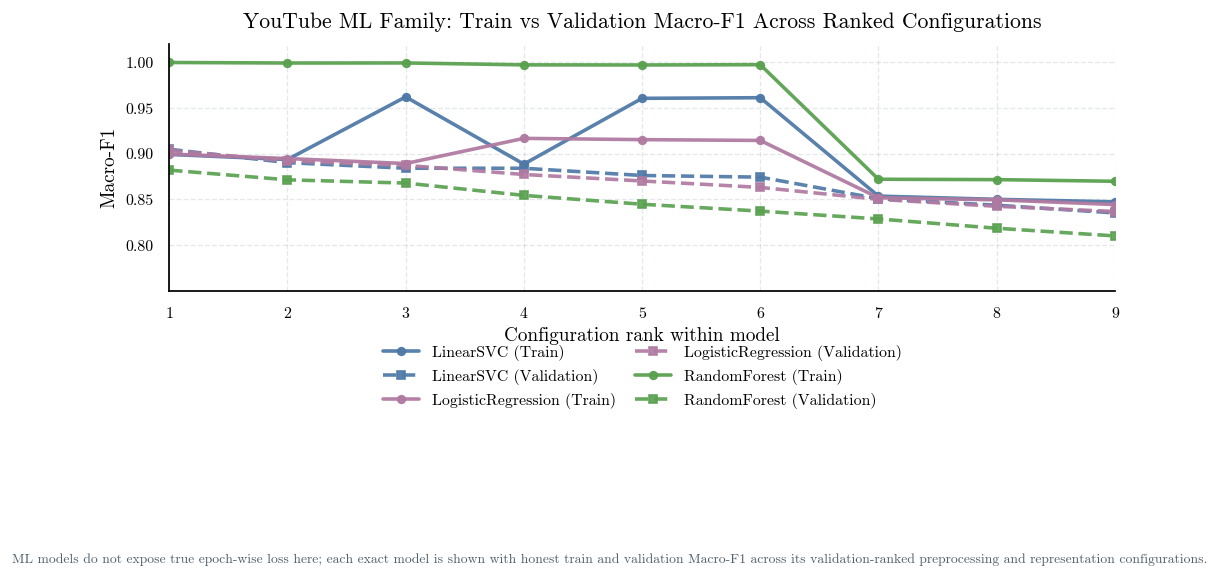

In [77]:
ml_training_performance_df, ml_family_curve_df = build_ml_family_curve_source(globals().get("ml_results", {}))
if not ml_training_performance_df.empty:
    ml_training_performance_df.to_csv(TABLE_DIR / "ml_train_validation_performance.csv", index=False)


if not ml_family_curve_df.empty:
    family_curve_saved_paths["ML"] = plot_family_curve_figure(
        ml_family_curve_df,
        title=f"{DISPLAY_NAME} ML Family: Train vs Validation Macro-F1 Across Ranked Configurations",
        ylabel="Macro-F1",
        xlabel="Configuration rank within model",
        stem=FAMILY_CURVE_EXPORT_STEMS["ML"],
        metric_name="macro_f1",
        note="ML models do not expose true epoch-wise loss here; each exact model is shown with honest train and validation Macro-F1 across its validation-ranked preprocessing and representation configurations.",
    )
else:
    print("ML family figure skipped because train/validation ML performance data are unavailable.")


### Sequence Family-Level Training and Validation Curves


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_sequence_train_val_loss.{png,pdf}
Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_sequence_train_val_loss.csv


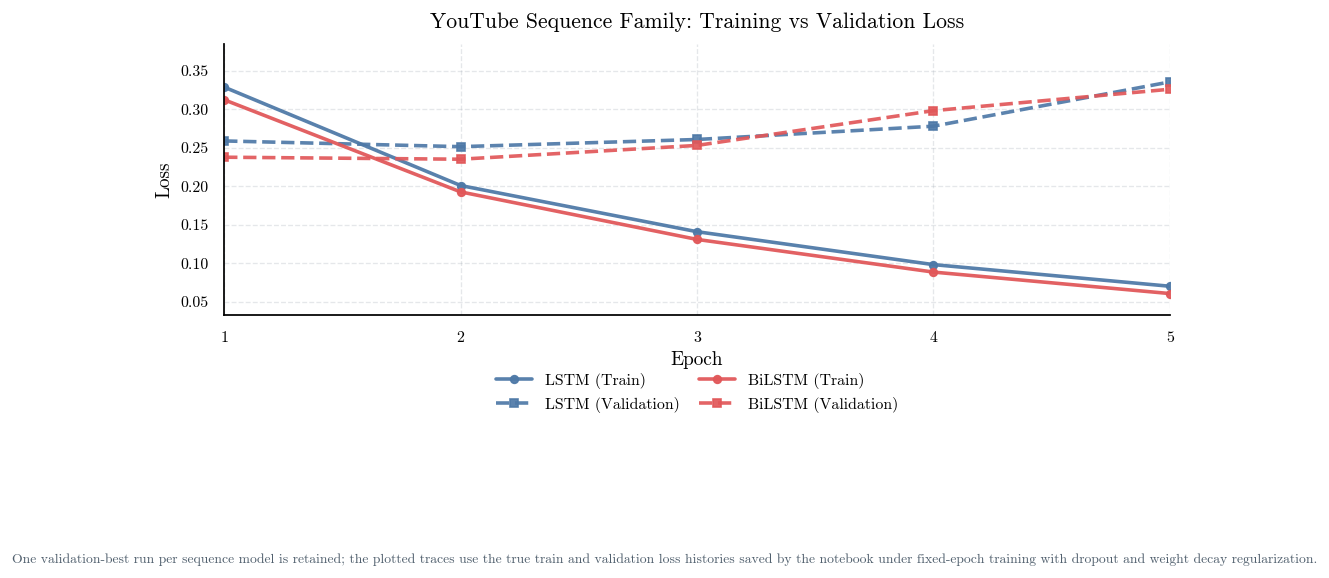

In [78]:
sequence_history_source = globals().get("sequence_history_df", pd.DataFrame())
selected_sequence_runs = _select_best_sequence_run_per_model(sequence_history_source)

removed_sequence_curve_exports = _remove_redundant_curve_exports(
    [SEQUENCE_PLOTS_DIR / f"{architecture}_training_validation_history" for architecture in ["lstm", "bilstm"]]
)
family_curve_cleanup_actions["Sequence"] = removed_sequence_curve_exports
if removed_sequence_curve_exports:
    print("Removed redundant per-architecture sequence curve exports:")
    for path in removed_sequence_curve_exports:
        print(f"  - {path}")

sequence_family_curve_df = build_loss_family_curve_source(
    selected_sequence_runs,
    model_family="Sequence",
    figure_name=FAMILY_CURVE_EXPORT_STEMS["Sequence"],
)
if not sequence_family_curve_df.empty:
    family_curve_saved_paths["Sequence"] = plot_family_curve_figure(
        sequence_family_curve_df,
        title=f"{DISPLAY_NAME} Sequence Family: Training vs Validation Loss",
        ylabel="Loss",
        xlabel="Epoch",
        stem=FAMILY_CURVE_EXPORT_STEMS["Sequence"],
        metric_name="loss",
        max_x=FAMILY_HISTORY_MAX_EPOCHS,
        note="One validation-best run per sequence model is retained; the plotted traces use the true train and validation loss histories saved by the notebook under fixed-epoch training with dropout and weight decay regularization.",
    )
else:
    print("Sequence family figure skipped because no sequence loss histories were found.")


### Transformer Family-Level Training and Validation Curves


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_transformer_train_val_loss.{png,pdf}
Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_transformer_train_val_loss.csv


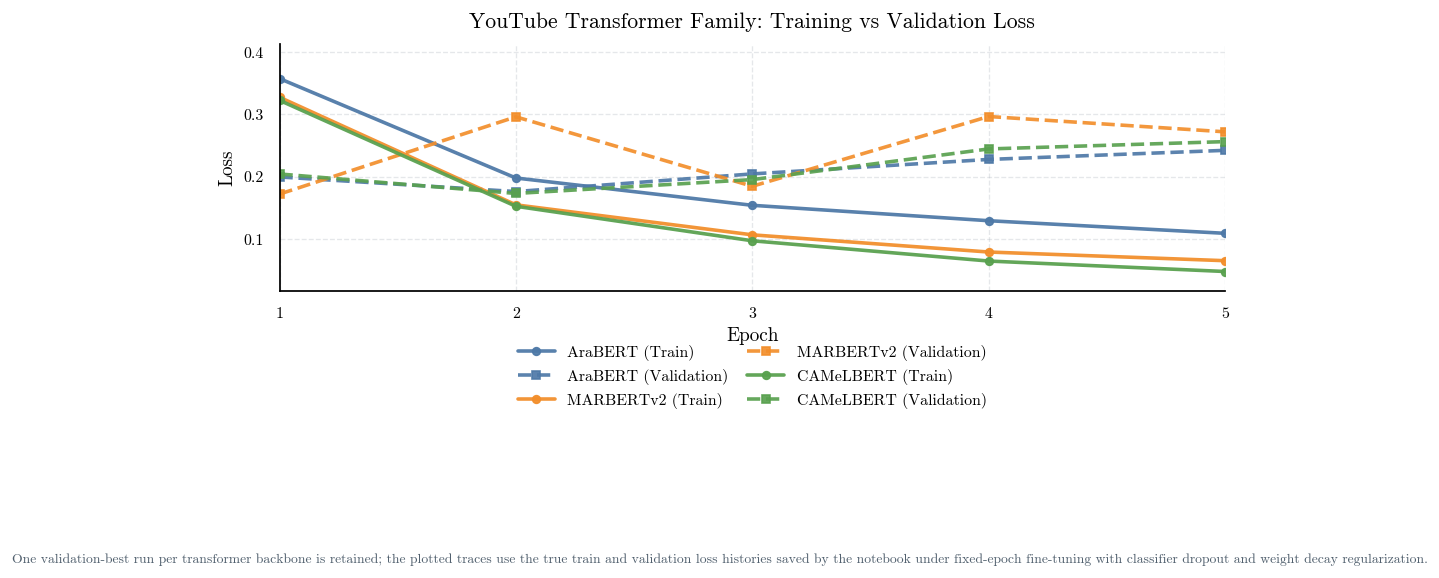

Saved family-curve cleanup audit CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_family_curve_cleanup_actions.csv
Unified family-level curve exports:
  - ML: {'figure_stem': PosixPath('/content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_ml_train_val_curves'), 'csv_path': PosixPath('/content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_ml_train_val_curves.csv'), 'figure_width': 8.8, 'figure_height': 4.8, 'width_exception_used': False}
  - Sequence: {'figure_stem': PosixPath('/content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_sequence_train_val_loss'), 'csv_path': PosixPath('/content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_sequence_train_val_loss.csv'), 'figure_width': 8.8, 'figure_height': 4.8, 'width_exception_used': False}
  - Transformer: {'figure_stem': PosixPath('/content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtub

In [79]:
transformer_history_sources = {
    "arabert": globals().get("arabert_histories", {}),
    "marbert": globals().get("marbert_histories", {}),
    "camelbert": globals().get("camelbert_histories", {}),
}
transformer_history_frames = []
for model_shortname, history_map in transformer_history_sources.items():
    for (preprocessing, max_len), history_df in history_map.items():
        hist = _safe_history_frame(history_df)
        if hist.empty:
            continue
        hist = hist.copy()
        hist.insert(0, "model_shortname", model_shortname)
        hist.insert(1, "preprocessing", preprocessing)
        if "max_len" not in hist.columns:
            hist.insert(2, "max_len", max_len)
        else:
            hist["max_len"] = pd.to_numeric(hist["max_len"], errors="coerce").fillna(max_len).astype(int)
        transformer_history_frames.append(hist)

if transformer_history_frames:
    transformer_history_df = pd.concat(transformer_history_frames, ignore_index=True)
    transformer_history_df.to_csv(TABLE_DIR / "transformer_training_history.csv", index=False)
else:
    transformer_history_df = pd.DataFrame()
    print("Transformer history export skipped because no histories were found.")

removed_transformer_curve_exports = _remove_redundant_curve_exports(
    [
        TRANSFORMER_PLOT_DIRS["arabert"] / "arabert_training_validation_history",
        TRANSFORMER_PLOT_DIRS["marbert"] / "marbert_training_validation_history",
        TRANSFORMER_PLOT_DIRS["camelbert"] / "camelbert_training_validation_history",
    ]
)
family_curve_cleanup_actions["Transformer"] = removed_transformer_curve_exports
if removed_transformer_curve_exports:
    print("Removed redundant per-transformer history exports:")
    for path in removed_transformer_curve_exports:
        print(f"  - {path}")

selected_transformer_runs = _select_best_transformer_run_per_model(transformer_history_df)
transformer_family_curve_df = build_loss_family_curve_source(
    selected_transformer_runs,
    model_family="Transformer",
    figure_name=FAMILY_CURVE_EXPORT_STEMS["Transformer"],
)
if not transformer_family_curve_df.empty:
    family_curve_saved_paths["Transformer"] = plot_family_curve_figure(
        transformer_family_curve_df,
        title=f"{DISPLAY_NAME} Transformer Family: Training vs Validation Loss",
        ylabel="Loss",
        xlabel="Epoch",
        stem=FAMILY_CURVE_EXPORT_STEMS["Transformer"],
        metric_name="loss",
        max_x=FAMILY_HISTORY_MAX_EPOCHS,
        note="One validation-best run per transformer backbone is retained; the plotted traces use the true train and validation loss histories saved by the notebook under fixed-epoch fine-tuning with classifier dropout and weight decay regularization.",
    )
else:
    print("Transformer family figure skipped because no transformer loss histories were found.")

cleanup_rows = [
    {"platform": PIPELINE_NAME, "model_family": family_label, "removed_path": removed_path}
    for family_label, removed_paths in family_curve_cleanup_actions.items()
    for removed_path in removed_paths
]
cleanup_df = pd.DataFrame(cleanup_rows, columns=["platform", "model_family", "removed_path"])
cleanup_df.to_csv(TABLE_DIR / f"{PIPELINE_NAME}_family_curve_cleanup_actions.csv", index=False)
print(f"Saved family-curve cleanup audit CSV: {TABLE_DIR / f'{PIPELINE_NAME}_family_curve_cleanup_actions.csv'}")
if family_curve_saved_paths:
    print("Unified family-level curve exports:")
    for family_label, export_info in family_curve_saved_paths.items():
        print(f"  - {family_label}: {export_info}")

### Evaluation Protocol Summary


In [80]:
# Evaluation Summary: Combined Transformer + ML + Sequence Metrics
if "ml_results_df" not in globals() or ml_results_df.empty:
    raise NameError("ml_results_df not defined. Run the ML baseline section first.")
if "sequence_eval_summary" not in globals() or sequence_eval_summary.empty:
    raise NameError("sequence_eval_summary not defined. Run the sequence evaluation cell first.")
if "transformer_eval_summary" not in globals() or transformer_eval_summary.empty:
    raise NameError("transformer_eval_summary not defined. Run the transformer evaluation cell first.")

ml_long = ml_results_df.copy()
sequence_long = sequence_eval_summary.copy()
transformer_long = transformer_eval_summary.copy()

# This long-format table becomes the canonical macro-F1 ranking artifact for the report notebook.
EXPERIMENT_RESULTS_LONG = pd.concat([ml_long, sequence_long, transformer_long], ignore_index=True, sort=False)
EXPERIMENT_RESULTS_LONG["platform"] = PIPELINE_NAME
for col, default in {
    "evaluation_scope": "in_domain",
    "source_platform": PIPELINE_NAME,
    "target_platform": PIPELINE_NAME,
    "seed": SEED,
}.items():
    if col not in EXPERIMENT_RESULTS_LONG.columns:
        EXPERIMENT_RESULTS_LONG[col] = default
    else:
        EXPERIMENT_RESULTS_LONG[col] = EXPERIMENT_RESULTS_LONG[col].fillna(default)
if "training_time" not in EXPERIMENT_RESULTS_LONG.columns:
    EXPERIMENT_RESULTS_LONG["training_time"] = np.nan
if "notes" not in EXPERIMENT_RESULTS_LONG.columns:
    EXPERIMENT_RESULTS_LONG["notes"] = np.nan
EXPERIMENT_RESULTS_LONG["training_time"] = pd.to_numeric(EXPERIMENT_RESULTS_LONG["training_time"], errors="coerce")
EXPERIMENT_RESULTS_LONG["notes"] = EXPERIMENT_RESULTS_LONG["notes"].apply(lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, dict) else x)
EXPERIMENT_RESULTS_LONG = EXPERIMENT_RESULTS_LONG.sort_values(["model_family", "embedding_name", "model_name", "preprocessing"]).reset_index(drop=True)

EXPERIMENT_RESULTS_LONG.to_csv(TABLE_DIR / "experiment_results_long.csv", index=False)
EXPERIMENT_RESULTS_LONG.to_csv(TABLE_DIR / "eval_summary_all_metrics_long.csv", index=False)


evaluation_protocol_summary = pd.DataFrame(
    [
        {
            "branch": "ML",
            "selection_metric": "fixed_estimator_no_checkpoint_selection",
            "reporting_metric_primary": "macro_f1",
            "reporting_metric_secondary": "accuracy, weighted_f1",
            "uses_saved_row_predictions": True,
            "early_stopping_used": False,
            "notes": "Classical baselines are reported with macro-F1 as the primary study metric.",
        },
        {
            "branch": "Sequence",
            "selection_metric": "validation_macro_f1",
            "reporting_metric_primary": "macro_f1",
            "reporting_metric_secondary": "accuracy, weighted_f1",
            "uses_saved_row_predictions": True,
            "early_stopping_used": False,
            "notes": "Fixed-epoch sequence training uses dropout + weight decay regularization; validation macro-F1 selects the checkpoint used for test evaluation.",
        },
        {
            "branch": "Transformer",
            "selection_metric": "validation_macro_f1",
            "reporting_metric_primary": "macro_f1",
            "reporting_metric_secondary": "accuracy, weighted_f1",
            "uses_saved_row_predictions": True,
            "early_stopping_used": False,
            "notes": "All transformer branches use fixed-epoch fine-tuning with classifier dropout + weight decay, and validation macro-F1 selects the checkpoint used for test evaluation.",
        },
    ]
)
evaluation_protocol_summary_csv_path = TABLE_DIR / f"evaluation_protocol_summary_{PIPELINE_NAME}.csv"
evaluation_protocol_summary_md_path = TABLE_DIR / f"evaluation_protocol_summary_{PIPELINE_NAME}.md"
write_dataframe_with_markdown(
    evaluation_protocol_summary,
    evaluation_protocol_summary_csv_path,
    evaluation_protocol_summary_md_path,
)

print(f"Saved evaluation protocol summary CSV: {evaluation_protocol_summary_csv_path}")


Saved evaluation protocol summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/evaluation_protocol_summary_youtube.csv


### Canonical Experiment Tables and Comparison Summaries


Saved evaluation protocol summary markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/evaluation_protocol_summary_youtube.md


,branch,selection_metric,reporting_metric_primary,reporting_metric_secondary,uses_saved_row_predictions,early_stopping_used,notes
0,ML,fixed_estimator_no_checkpoint_selection,macro_f1,"accuracy, weighted_f1",True,False,Classical baselines are reported with macro-F1...
1,Sequence,validation_macro_f1,macro_f1,"accuracy, weighted_f1",True,False,Fixed-epoch sequence training uses dropout + w...
2,Transformer,validation_macro_f1,macro_f1,"accuracy, weighted_f1",True,False,All transformer branches use fixed-epoch fine-...


Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_exact_models_original_preprocessing_macro_f1_ci.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_exact_models_original_preprocessing_macro_f1_ci.{png,pdf}


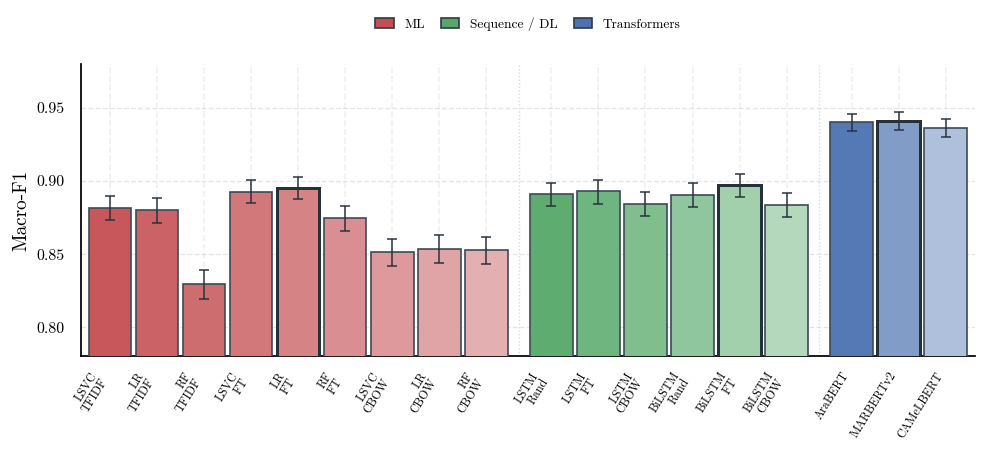

Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_exact_models_manual_preprocessing_macro_f1_ci.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_exact_models_manual_preprocessing_macro_f1_ci.{png,pdf}


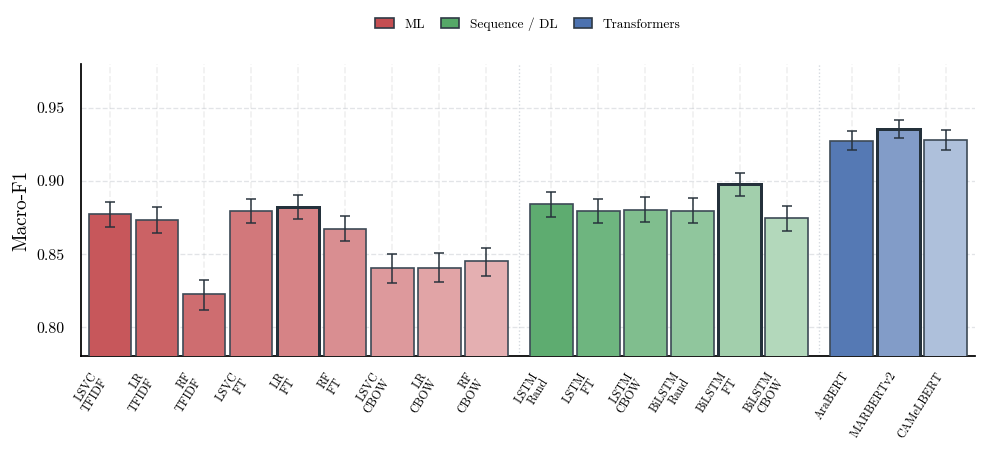

Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_exact_models_deepfake_aware_preprocessing_macro_f1_ci.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_exact_models_deepfake_aware_preprocessing_macro_f1_ci.{png,pdf}


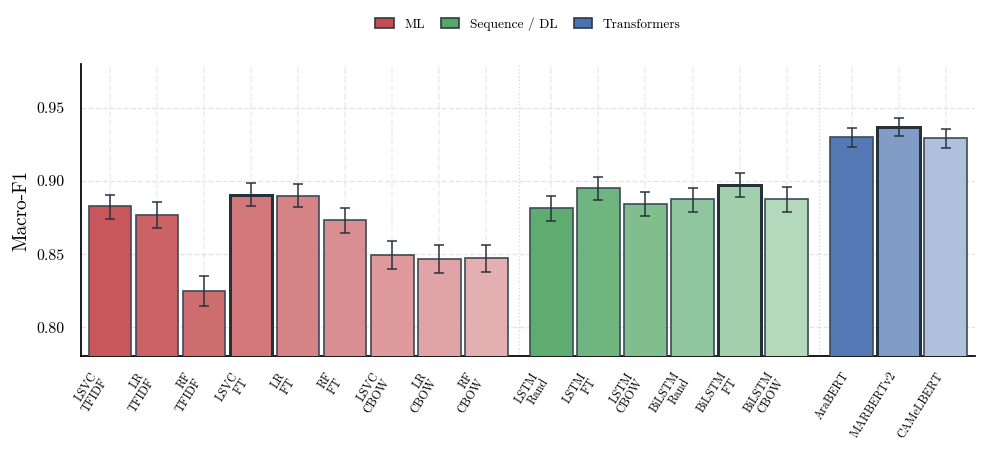

In [81]:
print(f"Saved evaluation protocol summary markdown: {evaluation_protocol_summary_md_path}")
display(evaluation_protocol_summary)


best_model_per_preprocessing = (
    EXPERIMENT_RESULTS_LONG.sort_values(["macro_f1", "accuracy"], ascending=False)
    .groupby("preprocessing", as_index=False)
    .first()
)
best_model_per_preprocessing.to_csv(TABLE_DIR / "best_model_per_preprocessing.csv", index=False)

best_preprocessing_per_family = (
    EXPERIMENT_RESULTS_LONG.groupby(["model_family", "preprocessing"], as_index=False)["macro_f1"]
    .mean()
    .sort_values(["model_family", "macro_f1"], ascending=[True, False])
    .groupby("model_family", as_index=False)
    .first()
)
best_preprocessing_per_family.to_csv(TABLE_DIR / "best_preprocessing_per_model_family.csv", index=False)

best_embedding_per_family = (
    EXPERIMENT_RESULTS_LONG.groupby(["model_family", "embedding_name", "embedding_family"], as_index=False)["macro_f1"]
    .mean()
    .sort_values(["model_family", "macro_f1"], ascending=[True, False])
    .groupby("model_family", as_index=False)
    .first()
)
best_embedding_per_family.to_csv(TABLE_DIR / "best_embedding_per_model_family.csv", index=False)

best_embedding_per_preprocessing = (
    EXPERIMENT_RESULTS_LONG.groupby(["preprocessing", "embedding_name", "embedding_family"], as_index=False)["macro_f1"]
    .mean()
    .sort_values(["preprocessing", "macro_f1"], ascending=[True, False])
    .groupby("preprocessing", as_index=False)
    .first()
)
best_embedding_per_preprocessing.to_csv(TABLE_DIR / "best_embedding_per_preprocessing.csv", index=False)

embedding_comparison_summary = (
    EXPERIMENT_RESULTS_LONG.groupby(["model_family", "embedding_family", "embedding_name"], as_index=False)
    .agg(mean_macro_f1=("macro_f1", "mean"), best_macro_f1=("macro_f1", "max"), mean_accuracy=("accuracy", "mean"))
    .sort_values(["model_family", "best_macro_f1"], ascending=[True, False])
)
embedding_comparison_summary.to_csv(TABLE_DIR / "embedding_comparison_summary.csv", index=False)

preprocessing_embedding_interaction = (
    EXPERIMENT_RESULTS_LONG.groupby(["embedding_family", "embedding_name", "preprocessing"], as_index=False)["macro_f1"]
    .mean()
    .pivot_table(index=["embedding_family", "embedding_name"], columns="preprocessing", values="macro_f1")
    .reindex(columns=PREPROCESSING_ORDER)
    .reset_index()
)
preprocessing_embedding_interaction.to_csv(TABLE_DIR / "preprocessing_embedding_interaction.csv", index=False)

f1_pivot = (
    EXPERIMENT_RESULTS_LONG.pivot_table(index="config_name", columns="preprocessing", values="macro_f1", aggfunc="max")
    .reindex(columns=PREPROCESSING_ORDER)
)
f1_pivot.to_csv(TABLE_DIR / "eval_summary_f1_models_by_preprocessing.csv")

exact_model_context = FigureRenderContext(
    preprocessing_order=PREPROCESSING_ORDER,
    pipeline_name=PIPELINE_NAME,
    display_name=DISPLAY_NAME,
    table_dir=TABLE_DIR,
    fig_dir=FIG_DIR,
    save_bundle=save_paper_plot_bundle,
    export_csv=export_paper_plot_csv,
    apply_axis_style=apply_paper_axis_style,
    preprocessing_label=paper_preprocessing_label,
    significance_stars=significance_stars,
    family_labels=PAPER_FAMILY_LABELS,
    rc_params=PAPER_RCPARAMS,
    seed=SEED,
    default_max_len=DEFAULT_MAX_LEN if 'DEFAULT_MAX_LEN' in globals() else 128,
    figure_size=(8.6, 6.0),
)
exact_model_render_inputs = {
    'results_df': EXPERIMENT_RESULTS_LONG,
    'eval_results': globals().get('eval_results', {}),
    'ml_results': globals().get('ml_results', {}),
    'sequence_model_runs': globals().get('sequence_model_runs', {}),
    'datasets_by_prep': globals().get('DS_YTB_BY_PREP', globals().get('DS_TWT_BY_PREP', {})),
    'context': exact_model_context,
}
_exact_model_preview = render_exact_model_preprocessing_figure_set(**exact_model_render_inputs)
EXACT_MODEL_COMPARISON_ROSTER = _exact_model_preview['roster'].copy()
exact_model_embedding_selection = _exact_model_preview['embedding_rank'].copy()
exact_model_figure_manifest = _exact_model_preview['manifest'].copy()
EXACT_MODEL_COMPARISON_ROSTER.to_csv(TABLE_DIR / 'exact_model_comparison_roster.csv', index=False)
exact_model_embedding_selection.to_csv(TABLE_DIR / 'exact_model_embedding_selection.csv', index=False)
exact_model_roster_summary = EXACT_MODEL_COMPARISON_ROSTER[['platform','preprocessing','model_family','model_name','embedding_name','exact_label','selection_note','selection_embedding_rank','selection_embedding_pool']].copy()
exact_model_roster_summary.to_csv(TABLE_DIR / 'exact_model_roster_summary.csv', index=False)
if not exact_model_figure_manifest.empty:
    exact_model_figure_manifest.to_csv(TABLE_DIR / f'{PIPELINE_NAME}_exact_model_preprocessing_figure_manifest.csv', index=False)


#### Paper Figure 1 - Exact-Model Preprocessing Comparison Figure Set

In [82]:
if not globals().get('exact_model_figure_manifest', pd.DataFrame()).empty:
    display(exact_model_figure_manifest)
else:
    print('Exact-model preprocessing figure manifest is empty; check whether the evaluation artifacts were available in this run.')


,platform,preprocessing,stem,n_bars,figure_bar_count_target,shared_embedding_pool
0,youtube,original,youtube_exact_models_original_preprocessing_ma...,18,18,"fasttext,word2vec_cbow"
1,youtube,manual,youtube_exact_models_manual_preprocessing_macr...,18,18,"fasttext,word2vec_cbow"
2,youtube,deepfake_aware,youtube_exact_models_deepfake_aware_preprocess...,18,18,"fasttext,word2vec_cbow"


### PR and ROC Curves - Combined Multi-Family Analysis

This section generates combined PR and ROC curves for the full exact study roster across ML, Sequence/DL, and Transformer models, preserving all study embeddings/model variants. For each exact model-definition, the best executed in-domain configuration is selected by Macro-F1 from the notebook's actual held-out test results. Positive class is class `1` (`Real`); `predict_proba(... )[:, 1]` is used when available, raw `decision_function` scores are used only when needed, and no artificial sigmoid transformation is applied.


In [83]:
# PR AND ROC CURVES - Combined Multi-Family Analysis

from sklearn.metrics import average_precision_score, auc, precision_recall_curve, roc_curve

def get_positive_class_scores(scores):
    scores = np.asarray(scores)
    if scores.ndim == 2:
        if scores.shape[1] < 2:
            raise ValueError(f"Unexpected score shape: {scores.shape}")
        return scores[:, 1].astype(float)
    if scores.ndim == 1:
        return scores.astype(float)
    raise ValueError(f"Unexpected score shape: {scores.shape}")

def extract_ml_scores(estimator, X_test, *, config_name):
    if hasattr(estimator, "predict_proba"):
        return get_positive_class_scores(estimator.predict_proba(X_test)), "predict_proba"
    if hasattr(estimator, "decision_function"):
        return get_positive_class_scores(np.asarray(estimator.decision_function(X_test))), "decision_function"
    raise ValueError(f"Estimator for {config_name} exposes neither predict_proba nor decision_function")

def _validated_curve_entry(entry):
    y_true = np.asarray(entry["y_true"], dtype=int)
    y_score = np.asarray(entry["y_score"], dtype=float)
    if y_true.shape[0] == 0 or y_score.shape[0] == 0 or y_true.shape[0] != y_score.shape[0]:
        return None
    labels = set(np.unique(y_true).tolist())
    if labels - {0, 1} or len(labels) < 2:
        return None
    entry = entry.copy()
    entry["y_true"] = y_true
    entry["y_score"] = y_score
    return entry

def collect_model_scores_and_labels():
    all_configs = []
    for (model_shortname, preprocessing, max_len), metrics in eval_results.items():
        probs = metrics.get("probabilities")
        labels = metrics.get("labels")
        if probs is None or labels is None:
            continue
        entry = _validated_curve_entry({
            "model_family": "Transformer",
            "model_name": metrics.get("model_name", model_shortname),
            "embedding_family": "contextual_transformer",
            "embedding_name": metrics.get("model_name", model_shortname),
            "representation_type": "contextual_transformer",
            "preprocessing": preprocessing,
            "max_len": max_len,
            "y_true": labels,
            "y_score": get_positive_class_scores(probs),
            "macro_f1": metrics.get("macro_f1", 0.0),
            "accuracy": metrics.get("accuracy", 0.0),
            "config_name": metrics.get("model_name", model_shortname),
            "score_source": "predict_proba",
        })
        if entry is not None:
            all_configs.append(entry)
    for preprocessing, config_dict in sequence_model_runs.items():
        for config_name, run_data in config_dict.items():
            probs = run_data.get("test_probabilities")
            labels = run_data.get("y_test")
            if probs is None or labels is None:
                continue
            tm = run_data.get("test_metrics", {})
            entry = _validated_curve_entry({
                "model_family": "Sequence",
                "model_name": run_data.get("model_name", "sequence"),
                "embedding_family": run_data.get("embedding_family", "sequence_embedding"),
                "embedding_name": run_data.get("embedding_name", "unknown"),
                "representation_type": run_data.get("representation_type", "dense_embedding"),
                "preprocessing": preprocessing,
                "max_len": run_data.get("max_len", np.nan),
                "y_true": labels,
                "y_score": get_positive_class_scores(probs),
                "macro_f1": tm.get("macro_f1", 0.0),
                "accuracy": tm.get("accuracy", 0.0),
                "config_name": config_name,
                "score_source": "predict_proba",
            })
            if entry is not None:
                all_configs.append(entry)
    for preprocessing, config_dict in ml_results.items():
        y_true_ml = np.asarray(ml_feature_sets[preprocessing]["y_test"])
        for config_name, result in config_dict.items():
            estimator = result.get("estimator")
            if estimator is None:
                continue
            embedding_name = result.get("embedding_name", "tfidf")
            feature_branch = result.get("feature_branch", "lexical")
            X_test = ml_feature_sets[preprocessing]["lexical"]["X_test"] if feature_branch == "lexical" else ml_feature_sets[preprocessing]["dense"].get(embedding_name, {}).get("X_test")
            if X_test is None:
                continue
            try:
                y_score, score_source = extract_ml_scores(estimator, X_test, config_name=config_name)
            except Exception as exc:
                print(f"Warning: Could not get held-out scores for {config_name}: {exc}")
                continue
            tm = result.get("test_metrics", {})
            entry = _validated_curve_entry({
                "model_family": "ML",
                "model_name": result.get("model_name", "ml"),
                "embedding_family": result.get("embedding_family", feature_branch),
                "embedding_name": embedding_name,
                "representation_type": result.get("representation_type", feature_branch),
                "preprocessing": preprocessing,
                "max_len": np.nan,
                "y_true": y_true_ml,
                "y_score": y_score,
                "macro_f1": tm.get("macro_f1", 0.0),
                "accuracy": tm.get("accuracy", 0.0),
                "config_name": config_name,
                "score_source": score_source,
            })
            if entry is not None:
                all_configs.append(entry)
    return all_configs

def select_exact_model_configs_for_curves(all_configs):
    curve_df = pd.DataFrame(all_configs)
    if curve_df.empty:
        return {}, pd.DataFrame()
    curve_df = exact_model_preprocessing_figures_helpers.attach_config_uid(curve_df)

    exact_model_roster = globals().get("EXACT_MODEL_COMPARISON_ROSTER", pd.DataFrame()).copy()
    if exact_model_roster.empty:
        exact_model_roster, _ = exact_model_preprocessing_figures_helpers.build_exact_model_comparison_roster(
            EXPERIMENT_RESULTS_LONG,
            preprocessing_order=PREPROCESSING_ORDER,
            pipeline_name=PIPELINE_NAME,
        )

    if exact_model_roster.empty:
        return {}, pd.DataFrame()

    best_roster = (
        exact_model_roster.sort_values(["macro_f1", "accuracy", "config_uid"], ascending=[False, False, True])
        .drop_duplicates("template_key")
        .sort_values(["family_order", "base_plot_order", "exact_label"])
        .reset_index(drop=True)
    )

    merged = best_roster.merge(
        curve_df[[
            "config_uid",
            "y_true",
            "y_score",
            "score_source",
            "model_family",
            "model_name",
            "embedding_name",
            "preprocessing",
            "config_name",
            "macro_f1",
            "accuracy",
        ]],
        on="config_uid",
        how="left",
        suffixes=("_roster", ""),
    )

    missing = merged[merged["y_true"].isna()][["exact_label", "config_uid"]].drop_duplicates()
    if not missing.empty:
        print("Warning: PR/ROC scores missing for these exact-model items:")
        display(missing)

    merged = merged[merged["y_true"].notna()].copy()
    selected = {}
    rows = []
    selection_rule = "best_macro_f1_per_exact_study_roster_item"
    for row in merged.itertuples(index=False):
        label = row.exact_label
        selected[label] = {
            "model_family": row.model_family,
            "model_name": row.model_name,
            "embedding_name": row.embedding_name,
            "preprocessing": row.preprocessing,
            "config_name": row.config_name,
            "macro_f1": row.macro_f1,
            "accuracy": row.accuracy,
            "y_true": row.y_true,
            "y_score": row.y_score,
            "score_source": row.score_source,
            "display_label": label,
            "template_key": row.template_key,
            "base_plot_order": row.base_plot_order,
            "family_order": row.family_order,
        }
        rows.append({
            "model_family": row.model_family,
            "model_name": row.model_name,
            "embedding_name": row.embedding_name,
            "preprocessing": row.preprocessing,
            "macro_f1": row.macro_f1,
            "accuracy": row.accuracy,
            "score_source": row.score_source,
            "selection_rule": selection_rule,
            "display_label": label,
            "exact_label": row.exact_label,
            "template_key": row.template_key,
            "config_name": row.config_name,
            "base_plot_order": row.base_plot_order,
            "family_order": row.family_order,
        })
    selection_summary = pd.DataFrame(rows).sort_values(["family_order", "base_plot_order", "display_label"]).reset_index(drop=True)
    return selected, selection_summary

PR_ROC_FAMILY_COLORS = {"Transformer": ["#1f77b4", "#aec7e8", "#17becf"], "Sequence": ["#2ca02c", "#98df8a", "#006400", "#228B22", "#66C2A5", "#4DAF4A"], "ML": ["#d62728", "#ff9896", "#8b0000", "#ff7f0e", "#ffbb78", "#c44e52", "#dd8452", "#937860", "#b07aa1"]}

def get_curve_color_palette(selected_configs):
    colors, counters = {}, {"Transformer": 0, "Sequence": 0, "ML": 0}
    for label, cfg in sorted(selected_configs.items(), key=lambda item: (item[1].get("family_order", 99), item[1].get("base_plot_order", 999), item[0])):
        fam = cfg["model_family"]
        palette = PR_ROC_FAMILY_COLORS.get(fam, ["#333333"])
        colors[label] = palette[counters[fam] % len(palette)]
        counters[fam] += 1
    return colors

def _plot_curve(selected_configs, *, curve_type, output_stem, title_suffix=""):
    if not selected_configs:
        return None, None
    colors = get_curve_color_palette(selected_configs)
    rows = []
    with plt.rc_context(PAPER_RCPARAMS):
        fig, ax = plt.subplots(figsize=(10.5, 7.5))
        if curve_type == "ROC":
            ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1.5, label="Random (AUC=0.500)")
        for label, cfg in sorted(selected_configs.items(), key=lambda item: (item[1].get("family_order", 99), item[1].get("base_plot_order", 999), -float(item[1]["macro_f1"]))):
            if curve_type == "PR":
                x, y, _ = precision_recall_curve(cfg["y_true"], cfg["y_score"])
                metric = average_precision_score(cfg["y_true"], cfg["y_score"])
                tag = "AP"
                xl, yl = "Recall", "Precision"
            else:
                x, y, _ = roc_curve(cfg["y_true"], cfg["y_score"])
                metric = auc(x, y)
                tag = "AUC"
                xl, yl = "False Positive Rate", "True Positive Rate"
            ax.plot(x, y, color=colors.get(label, "#333333"), linewidth=1.9, label=f"{label} ({tag}={metric:.3f})")
            for idx, (xv, yv) in enumerate(zip(x, y)):
                rows.append({
                    "platform": PIPELINE_NAME,
                    "model_family": cfg["model_family"],
                    "model_name": cfg["model_name"],
                    "embedding_name": cfg["embedding_name"],
                    "preprocessing": cfg["preprocessing"],
                    "curve_type": curve_type,
                    "x_value": float(xv),
                    "y_value": float(yv),
                    "score_summary": f"{tag}={metric:.4f}",
                    "score_source": cfg.get("score_source", "unknown"),
                    "selection_rule": "best_macro_f1_per_exact_study_roster_item",
                    "display_label": label,
                    "point_index": idx,
                })
        ax.set_xlabel(xl, fontweight="semibold", fontsize=11)
        ax.set_ylabel(yl, fontweight="semibold", fontsize=11)
        ax.set_title(f"{curve_type} Curves{title_suffix}" if curve_type == "ROC" else f"Precision-Recall Curves{title_suffix}", fontweight="semibold", fontsize=13, pad=12)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8.0, frameon=True, framealpha=0.95, edgecolor="#cccccc", ncol=1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()
        save_figure(fig, output_stem, formats=("png", "pdf"), dpi=300)
        plt.show()
        plt.close(fig)
    return fig, pd.DataFrame(rows)

def plot_combined_pr_curve(selected_configs, output_stem, title_suffix=""):
    return _plot_curve(selected_configs, curve_type="PR", output_stem=output_stem, title_suffix=title_suffix)

def plot_combined_roc_curve(selected_configs, output_stem, title_suffix=""):
    return _plot_curve(selected_configs, curve_type="ROC", output_stem=output_stem, title_suffix=title_suffix)


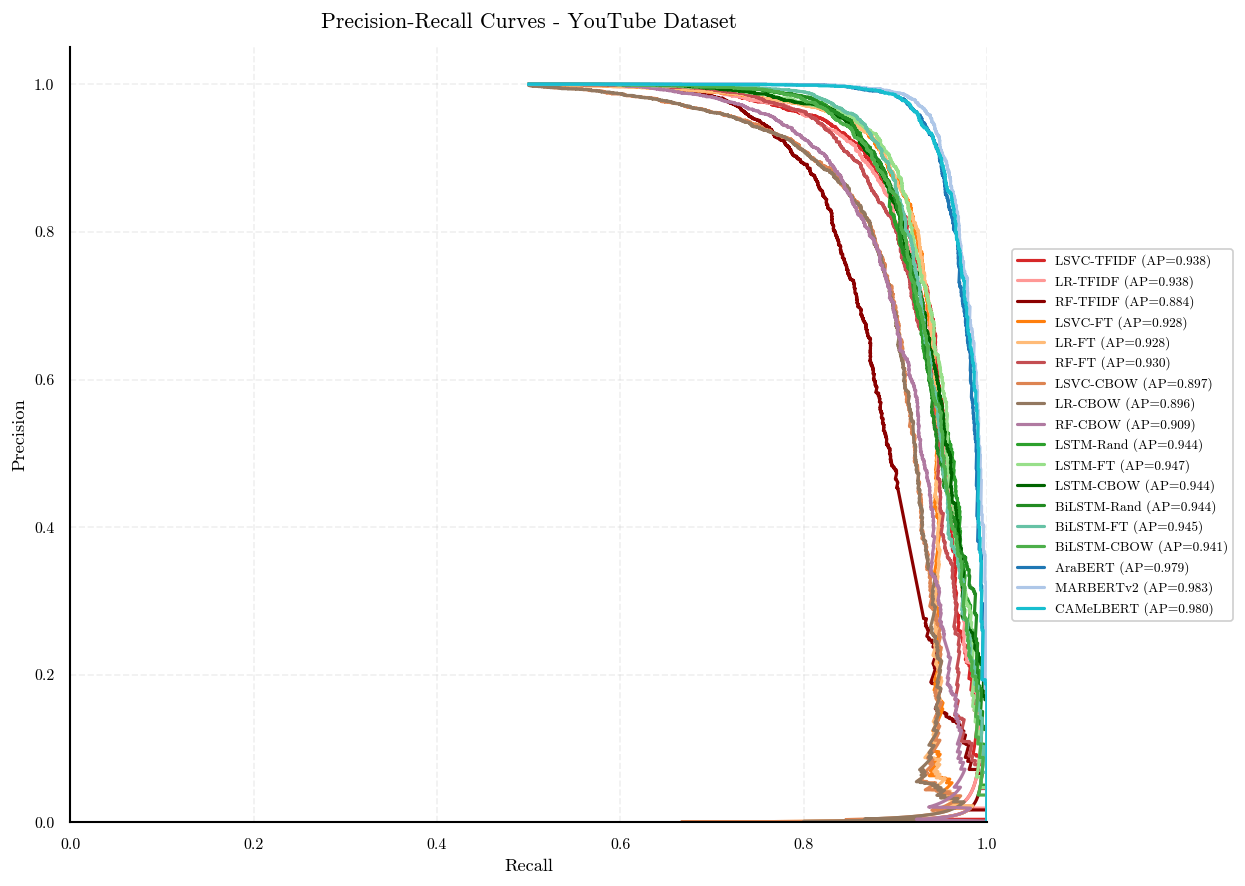

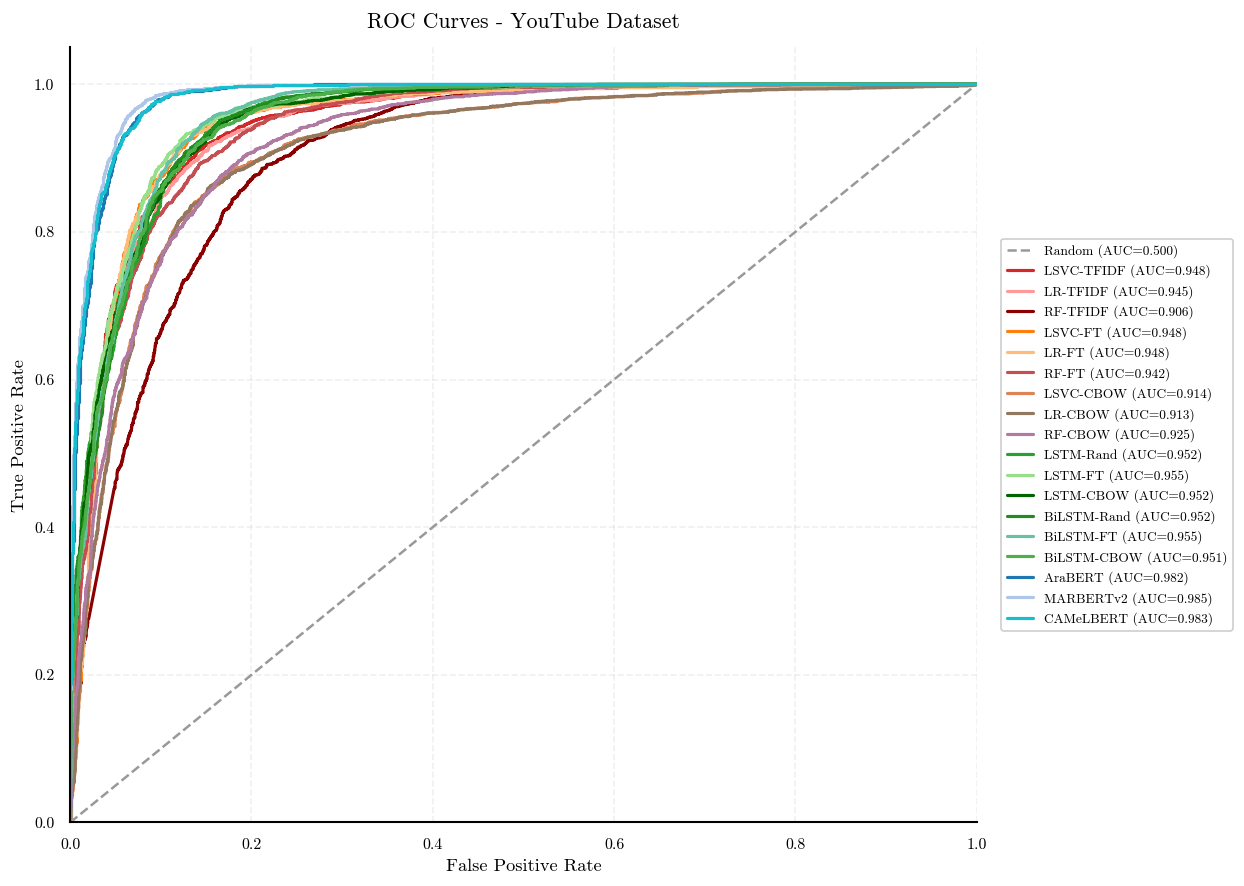

,Model,Family,ROC-AUC,Avg Precision,Macro-F1,Accuracy,Preprocessing,Embedding,Score Source
7,LR-CBOW,ML,0.913213,0.896091,0.853544,0.853555,original,word2vec_cbow,predict_proba
4,LR-FT,ML,0.948464,0.927744,0.895110,0.895119,original,fasttext,predict_proba
1,LR-TFIDF,ML,0.945408,0.937503,0.880062,0.880262,original,tfidf,predict_proba
6,LSVC-CBOW,ML,0.913790,0.896578,0.851077,0.851079,original,word2vec_cbow,predict_proba
3,LSVC-FT,ML,0.948244,0.927646,0.892288,0.892289,original,fasttext,predict_proba
0,LSVC-TFIDF,ML,0.947731,0.938124,0.882517,0.882561,deepfake_aware,tfidf,predict_proba
8,RF-CBOW,ML,0.924954,0.908736,0.852470,0.852494,original,word2vec_cbow,predict_proba
5,RF-FT,ML,0.941949,0.930085,0.874379,0.874425,original,fasttext,predict_proba
2,RF-TFIDF,ML,0.906021,0.884492,0.829719,0.830916,original,tfidf,predict_proba
14,BiLSTM-CBOW,Sequence,0.951217,0.941325,0.887796,0.887867,deepfake_aware,word2vec_cbow,predict_proba


Selection uses the full exact study roster with one held-out Macro-F1-leading configuration per exact model-definition; positive class is class 1 = Real; no sigmoid transformation is applied.
Selected PR/ROC curves by family: {'ML': 9, 'Sequence': 6, 'Transformer': 3}


In [84]:
# Generate PR and ROC Curves
all_model_configs = collect_model_scores_and_labels()
selected_configs, selection_summary = select_exact_model_configs_for_curves(all_model_configs)
selection_summary.to_csv(TABLE_DIR / f"{PIPELINE_NAME}_pr_roc_selection_summary.csv", index=False)
_, pr_curve_df = plot_combined_pr_curve(selected_configs, FIG_DIR / f"{PIPELINE_NAME}_combined_pr_curve", title_suffix=f" - {DISPLAY_NAME} Dataset")
if pr_curve_df is not None and not pr_curve_df.empty:
    pr_curve_df.to_csv(TABLE_DIR / f"{PIPELINE_NAME}_combined_pr_curve.csv", index=False)
_, roc_curve_df = plot_combined_roc_curve(selected_configs, FIG_DIR / f"{PIPELINE_NAME}_combined_roc_curve", title_suffix=f" - {DISPLAY_NAME} Dataset")
if roc_curve_df is not None and not roc_curve_df.empty:
    roc_curve_df.to_csv(TABLE_DIR / f"{PIPELINE_NAME}_combined_roc_curve.csv", index=False)
perf = []
for label, cfg in selected_configs.items():
    fpr, tpr, _ = roc_curve(cfg["y_true"], cfg["y_score"])
    perf.append({
        "Model": label,
        "Family": cfg["model_family"],
        "ROC-AUC": auc(fpr, tpr),
        "Avg Precision": average_precision_score(cfg["y_true"], cfg["y_score"]),
        "Macro-F1": cfg["macro_f1"],
        "Accuracy": cfg.get("accuracy", np.nan),
        "Preprocessing": cfg["preprocessing"],
        "Embedding": cfg["embedding_name"],
        "Score Source": cfg.get("score_source", "unknown"),
    })
perf_df = pd.DataFrame(perf).sort_values(["Family", "Model"])
display(perf_df)
perf_df.to_csv(TABLE_DIR / f"{PIPELINE_NAME}_pr_roc_performance_summary.csv", index=False)
family_counts = selection_summary.groupby("model_family").size().to_dict() if not selection_summary.empty else {}
print("Selection uses the full exact study roster with one held-out Macro-F1-leading configuration per exact model-definition; positive class is class 1 = Real; no sigmoid transformation is applied.")
print(f"Selected PR/ROC curves by family: {family_counts}")


## Statistical Testing


### Statistical Helper Functions


In [85]:
# Statistical helper definitions consolidated into the earlier shared utility block.


### Paired Validation and Preprocessing Effect Tests


In [86]:
# Prediction-frame and config-UID helpers consolidated into the earlier shared utility block.


Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_family_preprocessing_comparison.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_family_preprocessing_comparison.{png,pdf}


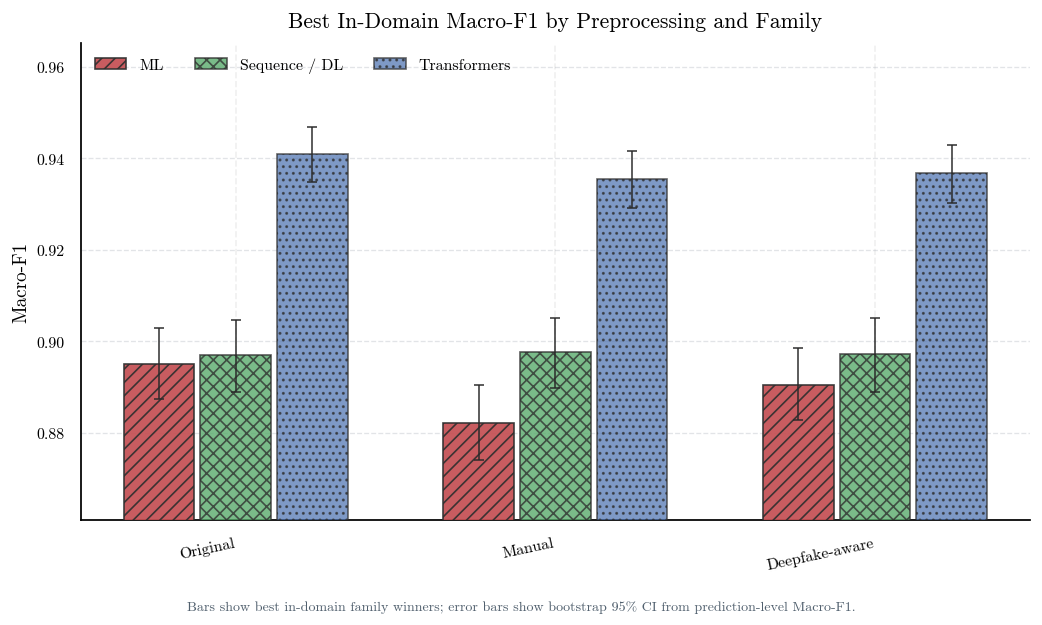

,platform,model_family,model_name,config_name,preprocessing,embedding_family,embedding_name,representation_type,max_len,config_uid,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,training_time,seed,notes
0,youtube,ML,linearsvc,linearsvc__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.890520,0.890524,0.890520,0.890520,0.890524,0.890520,0.890520,0.789653,42,Dense document vectors with mean pooling
1,youtube,ML,linearsvc,linearsvc__tfidf,deepfake_aware,lexical,tfidf,lexical_tfidf,NaN,model_family=ML||model_name=linearsvc||config_...,0.882561,0.883141,0.882561,0.882517,0.883141,0.882561,0.882517,0.236018,42,Lexical TF-IDF baseline
2,youtube,ML,linearsvc,linearsvc__word2vec_cbow,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.849487,0.849514,0.849487,0.849484,0.849514,0.849487,0.849484,4.557292,42,Dense document vectors with mean pooling
3,youtube,ML,logisticregression,logisticregression__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=logisticregression...,0.889636,0.889686,0.889636,0.889632,0.889686,0.889636,0.889632,0.489313,42,Dense document vectors with mean pooling
4,youtube,ML,logisticregression,logisticregression__tfidf,deepfake_aware,lexical,tfidf,lexical_tfidf,NaN,model_family=ML||model_name=logisticregression...,0.876724,0.879126,0.876724,0.876529,0.879126,0.876724,0.876529,0.128422,42,Lexical TF-IDF baseline
5,youtube,ML,logisticregression,logisticregression__word2vec_cbow,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,model_family=ML||model_name=logisticregression...,0.846834,0.846918,0.846834,0.846825,0.846918,0.846834,0.846825,1.737017,42,Dense document vectors with mean pooling
6,youtube,ML,randomforest,randomforest__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=randomforest||conf...,0.873187,0.873664,0.873187,0.873147,0.873664,0.873187,0.873147,6.955462,42,Dense document vectors with mean pooling
7,youtube,ML,randomforest,randomforest__tfidf,deepfake_aware,lexical,tfidf,lexical_tfidf,NaN,model_family=ML||model_name=randomforest||conf...,0.826141,0.834892,0.826141,0.824997,0.834892,0.826141,0.824997,0.889869,42,Lexical TF-IDF baseline
8,youtube,ML,randomforest,randomforest__word2vec_cbow,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,model_family=ML||model_name=randomforest||conf...,0.847011,0.847162,0.847011,0.846994,0.847162,0.847011,0.846994,6.735944,42,Dense document vectors with mean pooling
9,youtube,Sequence,bilstm,bilstm__fasttext,deepfake_aware,static_embedding,fasttext,sequence_embedding_init,128.0,model_family=Sequence||model_name=bilstm||conf...,0.897595,0.901794,0.897595,0.897326,0.901794,0.897595,0.897326,18.119361,42,"{""covered_words"": 24998, ""total_words"": 24998,..."


,platform,evaluation_scope,source_platform,target_platform,preprocessing,embedding_family,embedding_name,representation_type,model_family,model_name,...,early_stopping_used,notes,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,max_len
0,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,ML,linearsvc,...,False,Dense document vectors with mean pooling,0.890520,0.890524,0.890520,0.890520,0.890524,0.890520,0.890520,NaN
1,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,static_embedding_mean_pool,ML,linearsvc,...,False,Dense document vectors with mean pooling,0.879377,0.879426,0.879377,0.879374,0.879426,0.879377,0.879374,NaN
2,youtube,in_domain,youtube,youtube,original,static_embedding,fasttext,static_embedding_mean_pool,ML,linearsvc,...,False,Dense document vectors with mean pooling,0.892289,0.892297,0.892289,0.892288,0.892297,0.892289,0.892288,NaN
3,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,ML,logisticregression,...,False,Dense document vectors with mean pooling,0.889636,0.889686,0.889636,0.889632,0.889686,0.889636,0.889632,NaN
4,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,static_embedding_mean_pool,ML,logisticregression,...,False,Dense document vectors with mean pooling,0.882207,0.882223,0.882207,0.882206,0.882223,0.882207,0.882206,NaN
5,youtube,in_domain,youtube,youtube,original,static_embedding,fasttext,static_embedding_mean_pool,ML,logisticregression,...,False,Dense document vectors with mean pooling,0.895119,0.895247,0.895119,0.895110,0.895247,0.895119,0.895110,NaN
6,youtube,in_domain,youtube,youtube,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,ML,randomforest,...,False,Dense document vectors with mean pooling,0.873187,0.873664,0.873187,0.873147,0.873664,0.873187,0.873147,NaN
7,youtube,in_domain,youtube,youtube,manual,static_embedding,fasttext,static_embedding_mean_pool,ML,randomforest,...,False,Dense document vectors with mean pooling,0.867174,0.867681,0.867174,0.867128,0.867681,0.867174,0.867128,NaN
8,youtube,in_domain,youtube,youtube,original,static_embedding,fasttext,static_embedding_mean_pool,ML,randomforest,...,False,Dense document vectors with mean pooling,0.874425,0.874972,0.874425,0.874379,0.874972,0.874425,0.874379,NaN
9,youtube,in_domain,youtube,youtube,deepfake_aware,lexical,tfidf,lexical_tfidf,ML,linearsvc,...,False,Lexical TF-IDF baseline,0.882561,0.883141,0.882561,0.882517,0.883141,0.882561,0.882517,NaN


In [87]:
in_domain_results = EXPERIMENT_RESULTS_LONG[EXPERIMENT_RESULTS_LONG["evaluation_scope"] == "in_domain"].copy()
in_domain_results = _attach_config_uid_local(in_domain_results)
family_order = ["Transformer", "Sequence", "ML"]
family_color_map = FIXED_FAMILY_COLOR_MAP.copy()

all_models_preprocessing_columns = [
    col
    for col in [
        "platform",
        "model_family",
        "model_name",
        "config_name",
        "preprocessing",
        "embedding_family",
        "embedding_name",
        "representation_type",
        "max_len",
        "config_uid",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_precision",
        "weighted_recall",
        "weighted_f1",
        "training_time",
        "seed",
        "notes",
    ]
    if col in in_domain_results.columns
]
all_models_preprocessing_summary = in_domain_results[all_models_preprocessing_columns].copy()
all_models_preprocessing_sort_cols = [
    col for col in ["preprocessing", "model_family", "model_name", "embedding_name", "macro_f1", "accuracy", "config_name"]
    if col in all_models_preprocessing_summary.columns
]
if all_models_preprocessing_sort_cols:
    all_models_preprocessing_summary = all_models_preprocessing_summary.sort_values(
        all_models_preprocessing_sort_cols,
        ascending=[
            True if col in {"preprocessing", "model_family", "model_name", "embedding_name", "config_name"} else False
            for col in all_models_preprocessing_sort_cols
        ],
    ).reset_index(drop=True)
all_models_preprocessing_summary.to_csv(TABLE_DIR / "all_models_preprocessing_summary.csv", index=False)

best_family_preprocessing_summary = (
    in_domain_results.sort_values(["macro_f1", "accuracy", "config_name"], ascending=[False, False, True])
    .groupby(["model_family", "preprocessing"], as_index=False)
    .first()
)
baseline_by_family = (
    best_family_preprocessing_summary[best_family_preprocessing_summary["preprocessing"] == "original"][["model_family", "macro_f1"]]
    .rename(columns={"macro_f1": "macro_f1_original"})
)
best_family_preprocessing_summary = best_family_preprocessing_summary.merge(baseline_by_family, on="model_family", how="left")
best_family_preprocessing_summary["delta_vs_original"] = best_family_preprocessing_summary["macro_f1"] - best_family_preprocessing_summary["macro_f1_original"]
best_family_preprocessing_summary["preprocessing_label"] = best_family_preprocessing_summary["preprocessing"].map(to_paper_label)
best_family_preprocessing_summary.to_csv(TABLE_DIR / "best_family_preprocessing_summary.csv", index=False)
(TABLE_DIR / "best_family_preprocessing_summary.md").write_text(
    best_family_preprocessing_summary[
        ["model_family", "preprocessing", "model_name", "embedding_name", "macro_f1", "delta_vs_original", "config_name"]
    ].to_markdown(index=False)
    + "\n",
    encoding="utf-8",
)



stat_predictions = _attach_config_uid_local(
    build_in_domain_prediction_frame(
        eval_results=globals().get("eval_results", {}),
        ml_results=globals().get("ml_results", {}),
        sequence_model_runs=globals().get("sequence_model_runs", {}),
        datasets_by_prep=globals().get("DS_TWT_BY_PREP", globals().get("DS_YTB_BY_PREP", {})),
    )
)

family_comparison_source = build_best_family_bar_source(best_family_preprocessing_summary, stat_predictions)
if family_comparison_source.empty:
    print("Best-family preprocessing summary is empty; skipping preprocessing summary figure.")
else:
    family_comparison_export = family_comparison_source.rename(columns={"bar_value": "metric_value"}).copy()
    family_comparison_grid = pd.MultiIndex.from_product(
        [PREPROCESSING_ORDER, PAPER_FAMILY_ORDER],
        names=["preprocessing", "model_family"],
    ).to_frame(index=False)
    family_comparison_export = family_comparison_grid.merge(
        family_comparison_export,
        on=["preprocessing", "model_family"],
        how="left",
    )
    family_comparison_export["platform"] = family_comparison_export["platform"].fillna(PIPELINE_NAME)
    family_comparison_export["metric_name"] = family_comparison_export["metric_name"].fillna("Macro-F1")
    family_comparison_export["preprocessing"] = pd.Categorical(
        family_comparison_export["preprocessing"],
        PREPROCESSING_ORDER,
        ordered=True,
    )
    family_comparison_export["model_family"] = pd.Categorical(
        family_comparison_export["model_family"],
        PAPER_FAMILY_ORDER,
        ordered=True,
    )
    family_comparison_export = family_comparison_export.sort_values(
        ["preprocessing", "model_family"]
    ).reset_index(drop=True)
    family_comparison_export = family_comparison_export[
        [
            "platform",
            "preprocessing",
            "model_family",
            "metric_name",
            "metric_value",
            "ci_lower",
            "ci_upper",
            "n_samples",
            "config_uid",
            "model_name",
            "config_name",
            "embedding_name",
        ]
    ]

    comparison_stem = f"{PIPELINE_NAME}_family_preprocessing_comparison"
    export_paper_plot_csv(family_comparison_export, comparison_stem)
    plot_family_metric_grouped_bars(
        family_comparison_export,
        value_col="metric_value",
        ci_lower_col="ci_lower",
        ci_upper_col="ci_upper",
        ylabel="Macro-F1",
        title="Best In-Domain Macro-F1 by Preprocessing and Family",
        stem=comparison_stem,
        subtitle="Bars show best in-domain family winners; error bars show bootstrap 95% CI from prediction-level Macro-F1.",
    )

    # Preserve legacy report paths with the upgraded grouped-CI figure content.
    import shutil
    for suffix in (".png", ".pdf"):
        src_path = FIG_DIR / f"{comparison_stem}{suffix}"
        legacy_path = FIG_DIR / f"preprocessing_family_macro_f1{suffix}"
        if src_path.exists():
            shutil.copy2(src_path, legacy_path)
display(all_models_preprocessing_summary.head(20))
display(EXPERIMENT_RESULTS_LONG.head(15))


In [88]:
family_order = ["Transformer", "Sequence", "ML"]
family_color_map = FIXED_FAMILY_COLOR_MAP.copy()

stat_rows = []
best_family_macro_f1_rows = []
all_model_macro_f1_rows = []
preprocessing_effect_rows = []
preprocessing_effect_summary_rows = []
exact_model_roster = globals().get("EXACT_MODEL_COMPARISON_ROSTER", pd.DataFrame()).copy()
if exact_model_roster is None:
    exact_model_roster = pd.DataFrame()
EXACT_MODEL_COMPARISON_ROSTER = exact_model_roster.copy()

if "EXPERIMENT_RESULTS_LONG" in globals() and not EXPERIMENT_RESULTS_LONG.empty and not stat_predictions.empty:
    in_domain_ranked = EXPERIMENT_RESULTS_LONG.copy()
    in_domain_ranked = in_domain_ranked[in_domain_ranked["evaluation_scope"].fillna("in_domain") == "in_domain"]
    in_domain_ranked = in_domain_ranked.sort_values(["macro_f1", "accuracy", "config_name"], ascending=[False, False, True]).reset_index(drop=True)
    in_domain_ranked = attach_model_pair_key(in_domain_ranked)
    in_domain_ranked = _attach_config_uid_local(in_domain_ranked)
    best_by_family = in_domain_ranked.groupby("model_family", as_index=False).first()
    family_rows = {row["model_family"]: row for _, row in best_by_family.iterrows()}

    if exact_model_roster.empty:
        exact_model_counts = {"ML": 3, "Sequence": 1, "Transformer": 3}
        exact_model_family_order = ["ML", "Sequence", "Transformer"]
        roster_frames = []
        for family_label in exact_model_family_order:
            family_df = in_domain_ranked[in_domain_ranked["model_family"] == family_label].copy()
            if family_df.empty:
                continue
            best_per_model = family_df.groupby("model_name", as_index=False).first()
            best_per_model = best_per_model.sort_values(["macro_f1", "accuracy", "config_uid"], ascending=[False, False, True]).head(exact_model_counts[family_label]).copy()
            roster_frames.append(best_per_model)
        exact_model_roster = pd.concat(roster_frames, ignore_index=True) if roster_frames else pd.DataFrame()
        exact_model_roster = exact_model_roster.reset_index(drop=True)
        exact_model_roster["plot_order"] = np.arange(len(exact_model_roster)) if not exact_model_roster.empty else pd.Series(dtype=int)
        EXACT_MODEL_COMPARISON_ROSTER = exact_model_roster.copy()

    prediction_groups = {
        str(config_uid): group.sort_values("sample_idx").reset_index(drop=True)
        for config_uid, group in stat_predictions.groupby("config_uid", dropna=False)
    }

    for _, row in in_domain_ranked.drop_duplicates(subset=["config_uid"]).iterrows():
        pred_df = prediction_groups.get(str(row["config_uid"]))
        if pred_df is None or pred_df.empty:
            continue
        macro_f1 = float(precision_recall_fscore_support(pred_df["y_true"], pred_df["y_pred"], average="macro", zero_division=0)[2])
        ci = bootstrap_macro_f1_ci(pred_df["y_true"], pred_df["y_pred"])
        all_model_macro_f1_rows.append({
            "platform": PIPELINE_NAME,
            "config_uid": row["config_uid"],
            "model_family": row["model_family"],
            "model_name": row["model_name"],
            "config_name": row["config_name"],
            "preprocessing": row["preprocessing"],
            "embedding_family": row.get("embedding_family", np.nan),
            "embedding_name": row.get("embedding_name", np.nan),
            "representation_type": row.get("representation_type", np.nan),
            "max_len": row.get("max_len", np.nan),
            "accuracy": row.get("accuracy", np.nan),
            "macro_precision": row.get("macro_precision", np.nan),
            "macro_recall": row.get("macro_recall", np.nan),
            "macro_f1": macro_f1,
            "weighted_precision": row.get("weighted_precision", np.nan),
            "weighted_recall": row.get("weighted_recall", np.nan),
            "weighted_f1": row.get("weighted_f1", np.nan),
            "ci_lower": ci["ci_lower"],
            "ci_upper": ci["ci_upper"],
            "n_samples": int(len(pred_df)),
        })

    for _, row in best_by_family.iterrows():
        pred_df = prediction_groups.get(str(row["config_uid"]))
        if pred_df is None or pred_df.empty:
            continue
        macro_f1 = float(precision_recall_fscore_support(pred_df["y_true"], pred_df["y_pred"], average="macro", zero_division=0)[2])
        ci = bootstrap_macro_f1_ci(pred_df["y_true"], pred_df["y_pred"])
        best_family_macro_f1_rows.append({
            "platform": PIPELINE_NAME,
            "config_uid": row["config_uid"],
            "model_family": row["model_family"],
            "model_name": row["model_name"],
            "config_name": row["config_name"],
            "preprocessing": row["preprocessing"],
            "embedding_family": row.get("embedding_family", np.nan),
            "embedding_name": row.get("embedding_name", np.nan),
            "representation_type": row.get("representation_type", np.nan),
            "max_len": row.get("max_len", np.nan),
            "accuracy": row.get("accuracy", np.nan),
            "macro_precision": row.get("macro_precision", np.nan),
            "macro_recall": row.get("macro_recall", np.nan),
            "macro_f1": macro_f1,
            "weighted_precision": row.get("weighted_precision", np.nan),
            "weighted_recall": row.get("weighted_recall", np.nan),
            "weighted_f1": row.get("weighted_f1", np.nan),
            "ci_lower": ci["ci_lower"],
            "ci_upper": ci["ci_upper"],
            "n_samples": int(len(pred_df)),
        })

    for family_a, family_b in combinations(family_order, 2):
        row_a = family_rows.get(family_a)
        row_b = family_rows.get(family_b)
        if row_a is None or row_b is None:
            continue
        pred_a = stat_predictions[(stat_predictions["model_family"] == family_a) & (stat_predictions["config_name"] == row_a["config_name"]) & (stat_predictions["preprocessing"] == row_a["preprocessing"]) & (stat_predictions["embedding_name"].fillna("__NA__") == str(row_a.get("embedding_name", np.nan)))].sort_values("sample_idx")
        pred_b = stat_predictions[(stat_predictions["model_family"] == family_b) & (stat_predictions["config_name"] == row_b["config_name"]) & (stat_predictions["preprocessing"] == row_b["preprocessing"]) & (stat_predictions["embedding_name"].fillna("__NA__") == str(row_b.get("embedding_name", np.nan)))].sort_values("sample_idx")
        if pred_a.empty or pred_b.empty:
            continue
        paired = pred_a[["sample_idx", "y_true", "y_pred", "correct"]].merge(pred_b[["sample_idx", "y_pred", "correct"]], on="sample_idx", suffixes=("_a", "_b"))
        if paired.empty:
            continue
        mcnemar = mcnemar_exact_test(paired["correct_a"], paired["correct_b"])
        boot = bootstrap_macro_f1_difference(paired["y_true"], paired["y_pred_a"], paired["y_pred_b"])
        macro_delta = float(precision_recall_fscore_support(paired["y_true"], paired["y_pred_a"], average="macro", zero_division=0)[2] - precision_recall_fscore_support(paired["y_true"], paired["y_pred_b"], average="macro", zero_division=0)[2])
        favors = family_a if macro_delta > 0 else (family_b if macro_delta < 0 else "Tie")
        stat_rows.append({"platform": PIPELINE_NAME, "comparison_scope": "best_family_pair_in_domain", "family_a": family_a, "model_a": row_a["model_name"], "config_a": row_a["config_name"], "preprocessing_a": row_a["preprocessing"], "family_b": family_b, "model_b": row_b["model_name"], "config_b": row_b["config_name"], "preprocessing_b": row_b["preprocessing"], "test_name": "McNemar exact", "statistic": np.nan, "p_value": mcnemar["p_value"], "macro_f1_delta": macro_delta, "bootstrap_ci_lower": boot["ci_lower"], "bootstrap_ci_upper": boot["ci_upper"], "discordant_a_only": mcnemar["discordant_a_only"], "discordant_b_only": mcnemar["discordant_b_only"], "n_samples": int(len(paired)), "effect_size_or_note": f"macro_f1_delta={macro_delta:.6f}; 95% bootstrap CI=[{boot['ci_lower']:.6f}, {boot['ci_upper']:.6f}]", "favors": favors, "significance_flag": np.nan, "notes": "Best in-domain configuration per family ranked by macro-F1 then accuracy."})
    for family_label in family_order:
        family_df = in_domain_ranked[in_domain_ranked["model_family"] == family_label].copy()
        original_df = family_df[family_df["preprocessing"] == "original"][["model_pair_key", "macro_f1"]].rename(columns={"macro_f1": "macro_f1_original"})
        if original_df.empty:
            continue
        for preprocessing in METHODS_NO_ORIGINAL:
            variant_df = family_df[family_df["preprocessing"] == preprocessing][["model_pair_key", "macro_f1"]].rename(columns={"macro_f1": "macro_f1_variant"})
            paired_cfg = original_df.merge(variant_df, on="model_pair_key", how="inner")
            if paired_cfg.empty:
                continue
            valid = (paired_cfg["macro_f1_variant"] - paired_cfg["macro_f1_original"]).dropna().to_numpy(dtype=float)
            if len(valid) == 0:
                continue
            preprocessing_effect_summary_rows.append({"platform": PIPELINE_NAME, "model_family": family_label, "reference_preprocessing": "original", "variant_preprocessing": preprocessing, "n_pairs": int(len(valid)), "mean_macro_f1_delta": float(np.mean(valid)), "median_macro_f1_delta": float(np.median(valid)), "improved_configs": int(np.sum(valid > 0)), "hurt_configs": int(np.sum(valid < 0)), "ties": int(np.sum(valid == 0)), "min_delta": float(np.min(valid)), "max_delta": float(np.max(valid))})
            test_stat = np.nan
            p_value = np.nan
            effect_size = np.nan
            if len(valid) >= 2 and np.any(valid != 0):
                test = wilcoxon(valid, zero_method="wilcox", alternative="two-sided")
                test_stat = float(test.statistic)
                p_value = float(test.pvalue)
                effect_size = rank_biserial_from_diffs(valid)
            preprocessing_effect_rows.append({"platform": PIPELINE_NAME, "comparison_scope": "preprocessing_vs_original_by_family", "model_family": family_label, "reference_preprocessing": "original", "variant_preprocessing": preprocessing, "test_name": "Wilcoxon signed-rank", "statistic": test_stat, "p_value": p_value, "mean_macro_f1_delta": float(np.mean(valid)), "median_macro_f1_delta": float(np.median(valid)), "bootstrap_ci_lower": np.nan, "bootstrap_ci_upper": np.nan, "rank_biserial_correlation": effect_size, "n_pairs": int(len(valid)), "favors": preprocessing if float(np.mean(valid)) > 0 else ("original" if float(np.mean(valid)) < 0 else "Tie"), "notes": "Matched configuration comparison within family using model/embedding/max_len keys; positive deltas favor the variant preprocessing."})


In [89]:

mldl_keys = exact_model_roster[exact_model_roster["model_family"].isin(["ML", "Sequence"])][["model_family", "model_name"]].drop_duplicates()
transformer_keys = exact_model_roster[exact_model_roster["model_family"] == "Transformer"][["model_family", "model_name"]].drop_duplicates()
full_in_domain_results = _attach_config_uid_local(EXPERIMENT_RESULTS_LONG.copy())
full_in_domain_results = full_in_domain_results[full_in_domain_results["evaluation_scope"].fillna("in_domain") == "in_domain"].copy()

f1_embedding_table_mldl = full_in_domain_results.merge(mldl_keys, on=["model_family", "model_name"], how="inner")
f1_embedding_table_mldl["embedding_or_representation"] = f1_embedding_table_mldl["embedding_name"]
f1_embedding_table_mldl = f1_embedding_table_mldl[["platform", "model_family", "model_name", "config_name", "preprocessing", "embedding_or_representation", "macro_f1"]].sort_values(["model_family", "model_name", "preprocessing", "macro_f1", "config_name"], ascending=[True, True, True, False, True]).reset_index(drop=True)
f1_embedding_table_mldl.to_csv(TABLE_DIR / "f1_embedding_table_mldl.csv", index=False)
(TABLE_DIR / "f1_embedding_table_mldl.md").write_text(("_No rows available._\n" if f1_embedding_table_mldl.empty else f1_embedding_table_mldl.to_markdown(index=False) + "\n"), encoding="utf-8")

all_models_f1_embedding_table_mldl = full_in_domain_results[full_in_domain_results["model_family"].isin(["ML", "Sequence"])].copy()
all_models_f1_embedding_table_mldl["embedding_or_representation"] = all_models_f1_embedding_table_mldl["embedding_name"]
all_models_f1_embedding_table_mldl = all_models_f1_embedding_table_mldl[[col for col in ["platform", "model_family", "model_name", "config_name", "preprocessing", "embedding_family", "embedding_or_representation", "representation_type", "max_len", "config_uid", "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"] if col in all_models_f1_embedding_table_mldl.columns]].sort_values([col for col in ["model_family", "model_name", "preprocessing", "macro_f1", "config_name"] if col in all_models_f1_embedding_table_mldl.columns], ascending=[True, True, True, False, True]).reset_index(drop=True)
all_models_f1_embedding_table_mldl.to_csv(TABLE_DIR / "all_models_f1_embedding_table_mldl.csv", index=False)

f1_embedding_table_transformers = full_in_domain_results.merge(transformer_keys, on=["model_family", "model_name"], how="inner")
f1_embedding_table_transformers["backbone_or_representation"] = f1_embedding_table_transformers["embedding_name"]
f1_embedding_table_transformers = f1_embedding_table_transformers[["platform", "model_family", "model_name", "config_name", "preprocessing", "backbone_or_representation", "macro_f1"]].sort_values(["model_family", "model_name", "preprocessing", "macro_f1", "config_name"], ascending=[True, True, True, False, True]).reset_index(drop=True)
f1_embedding_table_transformers.to_csv(TABLE_DIR / "f1_embedding_table_transformers.csv", index=False)
(TABLE_DIR / "f1_embedding_table_transformers.md").write_text(("_No rows available._\n" if f1_embedding_table_transformers.empty else f1_embedding_table_transformers.to_markdown(index=False) + "\n"), encoding="utf-8")

all_models_f1_embedding_table_transformers = full_in_domain_results[full_in_domain_results["model_family"] == "Transformer"].copy()
all_models_f1_embedding_table_transformers["backbone_or_representation"] = all_models_f1_embedding_table_transformers["embedding_name"]
all_models_f1_embedding_table_transformers = all_models_f1_embedding_table_transformers[[col for col in ["platform", "model_family", "model_name", "config_name", "preprocessing", "embedding_family", "backbone_or_representation", "representation_type", "max_len", "config_uid", "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"] if col in all_models_f1_embedding_table_transformers.columns]].sort_values([col for col in ["model_family", "model_name", "preprocessing", "macro_f1", "config_name"] if col in all_models_f1_embedding_table_transformers.columns], ascending=[True, True, True, False, True]).reset_index(drop=True)
all_models_f1_embedding_table_transformers.to_csv(TABLE_DIR / "all_models_f1_embedding_table_transformers.csv", index=False)

best_family_macro_f1_ci_df = pd.DataFrame(best_family_macro_f1_rows)
if not best_family_macro_f1_ci_df.empty:
    best_family_macro_f1_ci_df = best_family_macro_f1_ci_df.sort_values(["model_family", "macro_f1", "accuracy", "config_name"], ascending=[True, False, False, True]).reset_index(drop=True)
best_family_macro_f1_ci_df.to_csv(TABLE_DIR / "best_family_macro_f1_ci.csv", index=False)

all_models_macro_f1_ci_df = pd.DataFrame(all_model_macro_f1_rows)
if not all_models_macro_f1_ci_df.empty:
    all_models_macro_f1_ci_df = all_models_macro_f1_ci_df.sort_values(["model_family", "model_name", "preprocessing", "macro_f1", "accuracy", "config_name"], ascending=[True, True, True, False, False, True]).reset_index(drop=True)
all_models_macro_f1_ci_df.to_csv(TABLE_DIR / "all_models_macro_f1_ci.csv", index=False)

if not f1_embedding_table_mldl.empty:
    display(Markdown("### ML + DL F1 / representation table"))
    display(f1_embedding_table_mldl)
if not all_models_f1_embedding_table_mldl.empty:
    display(Markdown("### All evaluated ML + DL F1 / representation rows"))
    display(all_models_f1_embedding_table_mldl.head(20))
if not f1_embedding_table_transformers.empty:
    display(Markdown("### Transformer F1 / backbone table"))
    display(f1_embedding_table_transformers)
if not all_models_f1_embedding_table_transformers.empty:
    display(Markdown("### All evaluated transformer F1 / backbone rows"))
    display(all_models_f1_embedding_table_transformers.head(20))
if not best_family_macro_f1_ci_df.empty:
    display(Markdown("### Best-family macro-F1 confidence intervals"))
    display(best_family_macro_f1_ci_df)
if not all_models_macro_f1_ci_df.empty:
    display(Markdown("### All-model macro-F1 confidence intervals"))
    display(all_models_macro_f1_ci_df.head(20))

statistical_validation_df = pd.DataFrame(stat_rows)
if not statistical_validation_df.empty:
    statistical_validation_df["p_adjusted"] = bh_adjust(statistical_validation_df["p_value"].to_numpy(dtype=float))
    statistical_validation_df["adjustment_method"] = "BH-FDR"
    statistical_validation_df["significance_flag"] = statistical_validation_df["p_adjusted"] < 0.05
else:
    statistical_validation_df = pd.DataFrame(columns=["platform", "comparison_scope", "family_a", "model_a", "config_a", "preprocessing_a", "family_b", "model_b", "config_b", "preprocessing_b", "test_name", "statistic", "p_value", "p_adjusted", "adjustment_method", "macro_f1_delta", "bootstrap_ci_lower", "bootstrap_ci_upper", "discordant_a_only", "discordant_b_only", "n_samples", "effect_size_or_note", "favors", "significance_flag", "notes"])

preprocessing_effect_summary_df = pd.DataFrame(preprocessing_effect_summary_rows)
preprocessing_effect_summary_df.to_csv(TABLE_DIR / "preprocessing_effect_summary.csv", index=False)
if not preprocessing_effect_summary_df.empty:
    (TABLE_DIR / "preprocessing_effect_summary.md").write_text(preprocessing_effect_summary_df.to_markdown(index=False) + "\n", encoding="utf-8")

preprocessing_effect_tests_df = pd.DataFrame(preprocessing_effect_rows)
if not preprocessing_effect_tests_df.empty:
    preprocessing_effect_tests_df["p_adjusted"] = bh_adjust(preprocessing_effect_tests_df["p_value"].to_numpy(dtype=float))
    preprocessing_effect_tests_df["adjustment_method"] = "BH-FDR"
    preprocessing_effect_tests_df["significance_flag"] = preprocessing_effect_tests_df["p_adjusted"] < 0.05
else:
    preprocessing_effect_tests_df = pd.DataFrame(columns=["platform", "comparison_scope", "model_family", "reference_preprocessing", "variant_preprocessing", "test_name", "statistic", "p_value", "p_adjusted", "adjustment_method", "mean_macro_f1_delta", "median_macro_f1_delta", "bootstrap_ci_lower", "bootstrap_ci_upper", "rank_biserial_correlation", "n_pairs", "favors", "significance_flag", "notes"])
preprocessing_effect_tests_df.to_csv(preprocessing_effect_paths()["csv"], index=False)
preprocessing_effect_paths()["md"].write_text(render_stats_md(preprocessing_effect_tests_df), encoding="utf-8")

paths = statistical_validation_paths()
statistical_validation_df.to_csv(paths["csv"], index=False)
paths["json"].write_text(statistical_validation_df.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
paths["md"].write_text(render_stats_md(statistical_validation_df), encoding="utf-8")

print(f"Saved statistical validation CSV: {paths['csv']}")
print(f"Saved statistical validation JSON: {paths['json']}")
print(f"Saved statistical validation markdown: {paths['md']}")
print(f"Saved preprocessing effect summary CSV: {TABLE_DIR / 'preprocessing_effect_summary.csv'}")
print(f"Saved preprocessing effect tests CSV: {preprocessing_effect_paths()['csv']}")
print(f"Saved preprocessing effect tests markdown: {preprocessing_effect_paths()['md']}")
print(f"Saved best-family macro-F1 CI CSV: {TABLE_DIR / 'best_family_macro_f1_ci.csv'}")
print(f"Saved all-model macro-F1 CI CSV: {TABLE_DIR / 'all_models_macro_f1_ci.csv'}")
print(f"Saved all-model ML + DL F1 table CSV: {TABLE_DIR / 'all_models_f1_embedding_table_mldl.csv'}")
print(f"Saved all-model transformer F1 table CSV: {TABLE_DIR / 'all_models_f1_embedding_table_transformers.csv'}")

display(statistical_validation_df)
if not preprocessing_effect_summary_df.empty:
    display(preprocessing_effect_summary_df)
if not preprocessing_effect_tests_df.empty:
    display(preprocessing_effect_tests_df)


### ML + DL F1 / representation table

,platform,model_family,model_name,config_name,preprocessing,embedding_or_representation,macro_f1
0,youtube,ML,linearsvc,linearsvc__fasttext,deepfake_aware,fasttext,0.890520
1,youtube,ML,linearsvc,linearsvc__tfidf,deepfake_aware,tfidf,0.882517
2,youtube,ML,linearsvc,linearsvc__word2vec_cbow,deepfake_aware,word2vec_cbow,0.849484
3,youtube,ML,linearsvc,linearsvc__fasttext,manual,fasttext,0.879374
4,youtube,ML,linearsvc,linearsvc__tfidf,manual,tfidf,0.877394
5,youtube,ML,linearsvc,linearsvc__word2vec_cbow,manual,word2vec_cbow,0.840467
6,youtube,ML,linearsvc,linearsvc__fasttext,original,fasttext,0.892288
7,youtube,ML,linearsvc,linearsvc__tfidf,original,tfidf,0.881284
8,youtube,ML,linearsvc,linearsvc__word2vec_cbow,original,word2vec_cbow,0.851077
9,youtube,ML,logisticregression,logisticregression__fasttext,deepfake_aware,fasttext,0.889632


### All evaluated ML + DL F1 / representation rows

,platform,model_family,model_name,config_name,preprocessing,embedding_family,embedding_or_representation,representation_type,max_len,config_uid,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,youtube,ML,linearsvc,linearsvc__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.890520,0.890524,0.890520,0.890520,0.890524,0.890520,0.890520
1,youtube,ML,linearsvc,linearsvc__tfidf,deepfake_aware,lexical,tfidf,lexical_tfidf,NaN,model_family=ML||model_name=linearsvc||config_...,0.882561,0.883141,0.882561,0.882517,0.883141,0.882561,0.882517
2,youtube,ML,linearsvc,linearsvc__word2vec_cbow,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.849487,0.849514,0.849487,0.849484,0.849514,0.849487,0.849484
3,youtube,ML,linearsvc,linearsvc__fasttext,manual,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.879377,0.879426,0.879377,0.879374,0.879426,0.879377,0.879374
4,youtube,ML,linearsvc,linearsvc__tfidf,manual,lexical,tfidf,lexical_tfidf,NaN,model_family=ML||model_name=linearsvc||config_...,0.877432,0.877895,0.877432,0.877394,0.877895,0.877432,0.877394
5,youtube,ML,linearsvc,linearsvc__word2vec_cbow,manual,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.840467,0.840468,0.840467,0.840467,0.840468,0.840467,0.840467
6,youtube,ML,linearsvc,linearsvc__fasttext,original,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.892289,0.892297,0.892289,0.892288,0.892297,0.892289,0.892288
7,youtube,ML,linearsvc,linearsvc__tfidf,original,lexical,tfidf,lexical_tfidf,NaN,model_family=ML||model_name=linearsvc||config_...,0.881323,0.881830,0.881323,0.881284,0.881830,0.881323,0.881284
8,youtube,ML,linearsvc,linearsvc__word2vec_cbow,original,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,model_family=ML||model_name=linearsvc||config_...,0.851079,0.851100,0.851079,0.851077,0.851100,0.851079,0.851077
9,youtube,ML,logisticregression,logisticregression__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=logisticregression...,0.889636,0.889686,0.889636,0.889632,0.889686,0.889636,0.889632


### Transformer F1 / backbone table

...

,platform,config_uid,model_family,model_name,config_name,preprocessing,embedding_family,embedding_name,representation_type,max_len,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,ci_lower,ci_upper,n_samples
0,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.890520,0.890524,0.890520,0.890520,0.890524,0.890520,0.890520,0.882736,0.898479,5654
1,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__tfidf,deepfake_aware,lexical,tfidf,lexical_tfidf,NaN,0.882561,0.883141,0.882561,0.882517,0.883141,0.882561,0.882517,0.873886,0.890522,5654
2,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__word2vec_cbow,deepfake_aware,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,0.849487,0.849514,0.849487,0.849484,0.849514,0.849487,0.849484,0.839936,0.858849,5654
3,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__fasttext,manual,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.879377,0.879426,0.879377,0.879374,0.879426,0.879377,0.879374,0.871207,0.887626,5654
4,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__tfidf,manual,lexical,tfidf,lexical_tfidf,NaN,0.877432,0.877895,0.877432,0.877394,0.877895,0.877432,0.877394,0.868393,0.885549,5654
5,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__word2vec_cbow,manual,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,0.840467,0.840468,0.840467,0.840467,0.840468,0.840467,0.840467,0.830369,0.850304,5654
6,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__fasttext,original,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.892289,0.892297,0.892289,0.892288,0.892297,0.892289,0.892288,0.884506,0.900246,5654
7,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__tfidf,original,lexical,tfidf,lexical_tfidf,NaN,0.881323,0.881830,0.881323,0.881284,0.881830,0.881323,0.881284,0.872874,0.889454,5654
8,youtube,model_family=ML||model_name=linearsvc||config_...,ML,linearsvc,linearsvc__word2vec_cbow,original,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,0.851079,0.851100,0.851079,0.851077,0.851100,0.851079,0.851077,0.841705,0.860280,5654
9,youtube,model_family=ML||model_name=logisticregression...,ML,logisticregression,logisticregression__fasttext,deepfake_aware,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.889636,0.889686,0.889636,0.889632,0.889686,0.889636,0.889632,0.881822,0.897761,5654


Saved statistical validation CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/statistical_validation_youtube.csv
Saved statistical validation JSON: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/statistical_validation_youtube.json
Saved statistical validation markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/statistical_validation_youtube.md
Saved preprocessing effect summary CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/preprocessing_effect_summary.csv
Saved preprocessing effect tests CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/preprocessing_effect_tests.csv
Saved preprocessing effect tests markdown: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/preprocessing_effect_tests.md
Saved best-family macro-F1 CI CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/best_family_macro_f1_ci.cs

,platform,comparison_scope,family_a,model_a,config_a,preprocessing_a,family_b,model_b,config_b,preprocessing_b,...,bootstrap_ci_upper,discordant_a_only,discordant_b_only,n_samples,effect_size_or_note,favors,significance_flag,notes,p_adjusted,adjustment_method
0,youtube,best_family_pair_in_domain,Transformer,marbertv2,marbertv2,original,Sequence,bilstm,bilstm__fasttext,manual,...,0.051249,404,160,5654,macro_f1_delta=0.043263; 95% bootstrap CI=[0.0...,Transformer,True,Best in-domain configuration per family ranked...,3.699233e-25,BH-FDR
1,youtube,best_family_pair_in_domain,Transformer,marbertv2,marbertv2,original,ML,logisticregression,logisticregression__fasttext,original,...,0.053866,420,161,5654,macro_f1_delta=0.045816; 95% bootstrap CI=[0.0...,Transformer,True,Best in-domain configuration per family ranked...,3.784536e-27,BH-FDR
2,youtube,best_family_pair_in_domain,Sequence,bilstm,bilstm__fasttext,manual,ML,logisticregression,logisticregression__fasttext,original,...,0.009615,232,217,5654,macro_f1_delta=0.002553; 95% bootstrap CI=[-0....,Sequence,False,Best in-domain configuration per family ranked...,5.088488e-01,BH-FDR


,platform,model_family,reference_preprocessing,variant_preprocessing,n_pairs,mean_macro_f1_delta,median_macro_f1_delta,improved_configs,hurt_configs,ties,min_delta,max_delta
0,youtube,Transformer,original,manual,3,-0.008785,-0.008139,0,3,0,-0.012733,-0.005482
1,youtube,Transformer,original,deepfake_aware,3,-0.007196,-0.007088,0,3,0,-0.010427,-0.004074
2,youtube,Sequence,original,manual,6,-0.007180,-0.007818,1,5,0,-0.013310,0.000600
3,youtube,Sequence,original,deepfake_aware,6,-0.001010,-0.000049,3,3,0,-0.009783,0.004344
4,youtube,ML,original,manual,9,-0.009099,-0.007418,0,9,0,-0.012915,-0.003889
5,youtube,ML,original,deepfake_aware,9,-0.003254,-0.003533,1,8,0,-0.006720,0.001233


,platform,comparison_scope,model_family,reference_preprocessing,variant_preprocessing,test_name,statistic,p_value,mean_macro_f1_delta,median_macro_f1_delta,bootstrap_ci_lower,bootstrap_ci_upper,rank_biserial_correlation,n_pairs,favors,notes,p_adjusted,adjustment_method,significance_flag
0,youtube,preprocessing_vs_original_by_family,Transformer,original,manual,Wilcoxon signed-rank,0.0,0.250000,-0.008785,-0.008139,NaN,NaN,-1.000000,3,original,Matched configuration comparison within family...,0.300000,BH-FDR,False
1,youtube,preprocessing_vs_original_by_family,Transformer,original,deepfake_aware,Wilcoxon signed-rank,0.0,0.250000,-0.007196,-0.007088,NaN,NaN,-1.000000,3,original,Matched configuration comparison within family...,0.300000,BH-FDR,False
2,youtube,preprocessing_vs_original_by_family,Sequence,original,manual,Wilcoxon signed-rank,1.0,0.062500,-0.007180,-0.007818,NaN,NaN,-0.904762,6,original,Matched configuration comparison within family...,0.125000,BH-FDR,False
3,youtube,preprocessing_vs_original_by_family,Sequence,original,deepfake_aware,Wilcoxon signed-rank,9.0,0.843750,-0.001010,-0.000049,NaN,NaN,-0.142857,6,original,Matched configuration comparison within family...,0.843750,BH-FDR,False
4,youtube,preprocessing_vs_original_by_family,ML,original,manual,Wilcoxon signed-rank,0.0,0.003906,-0.009099,-0.007418,NaN,NaN,-1.000000,9,original,Matched configuration comparison within family...,0.023438,BH-FDR,True
5,youtube,preprocessing_vs_original_by_family,ML,original,deepfake_aware,Wilcoxon signed-rank,2.0,0.011719,-0.003254,-0.003533,NaN,NaN,-0.911111,9,original,Matched configuration comparison within family...,0.035156,BH-FDR,True


#### Paper Figure 3 - Exact-Model Significance and 95% CIs by Preprocessing

Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_exact_models_original_preprocessing_macro_f1_ci.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_exact_models_original_preprocessing_macro_f1_ci.{png,pdf}


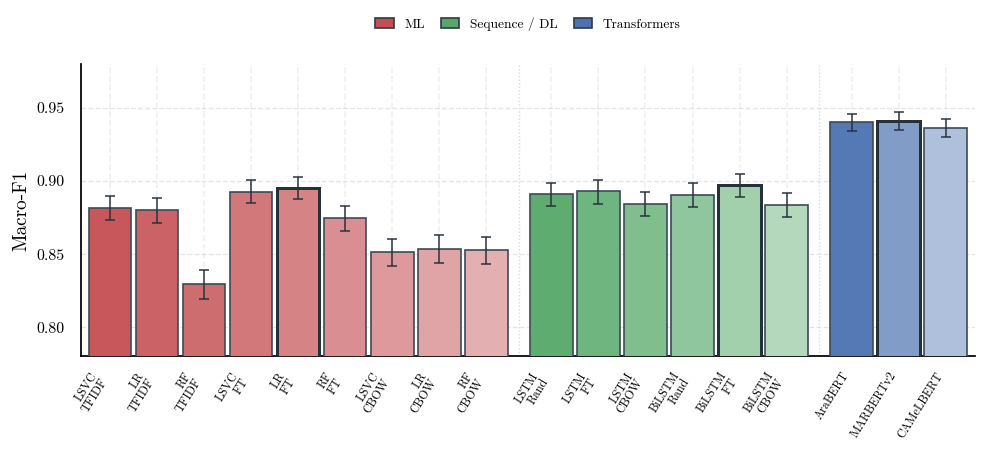

Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_exact_models_manual_preprocessing_macro_f1_ci.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_exact_models_manual_preprocessing_macro_f1_ci.{png,pdf}


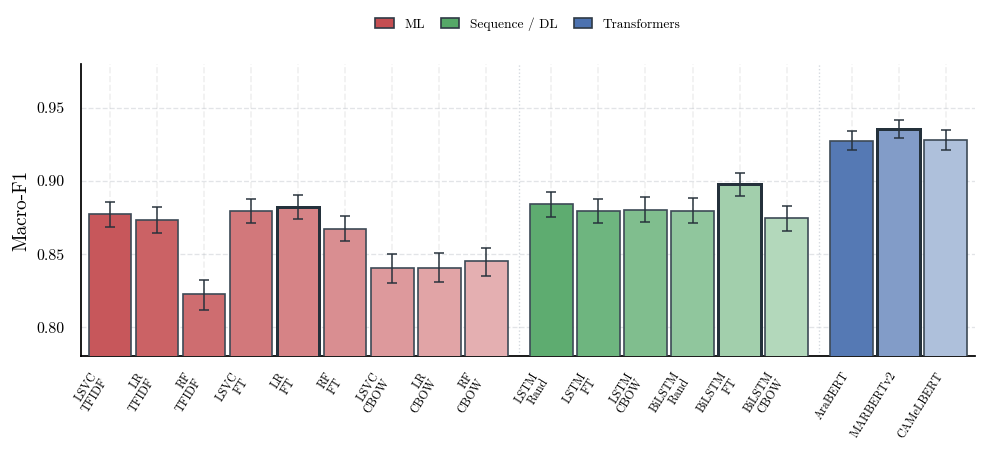

Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/youtube_exact_models_deepfake_aware_preprocessing_macro_f1_ci.csv


Saved figure bundle: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/figures/youtube_exact_models_deepfake_aware_preprocessing_macro_f1_ci.{png,pdf}


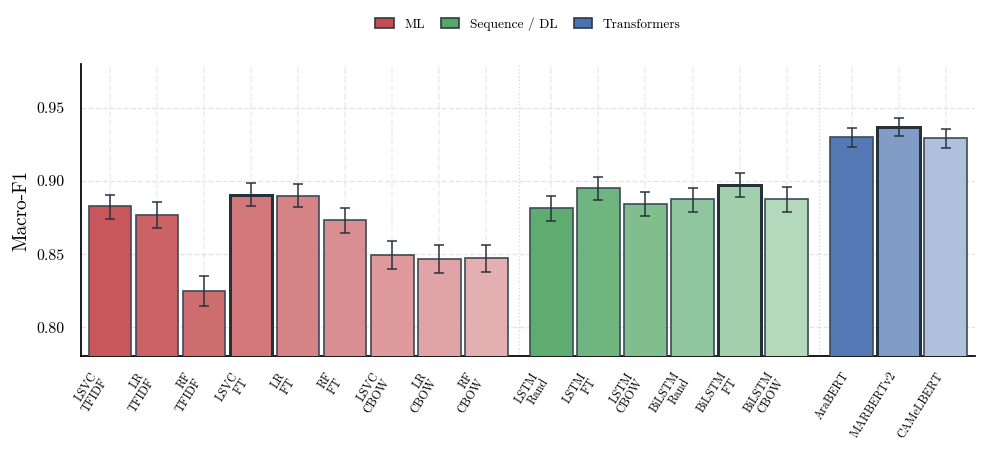

,platform,preprocessing,stem,n_bars,figure_bar_count_target,shared_embedding_pool
0,youtube,original,youtube_exact_models_original_preprocessing_ma...,18,18,"fasttext,word2vec_cbow"
1,youtube,manual,youtube_exact_models_manual_preprocessing_macr...,18,18,"fasttext,word2vec_cbow"
2,youtube,deepfake_aware,youtube_exact_models_deepfake_aware_preprocess...,18,18,"fasttext,word2vec_cbow"


In [90]:

# PAPER FIGURE 3: PREPROCESSING-SPECIFIC EXACT-MODEL SIGNIFICANCE FIGURE SET
exact_model_refresh = render_exact_model_preprocessing_figure_set(**exact_model_render_inputs)
exact_model_figure_manifest = exact_model_refresh['manifest'].copy()
if not exact_model_figure_manifest.empty:
    exact_model_figure_manifest.to_csv(TABLE_DIR / f'{PIPELINE_NAME}_exact_model_preprocessing_figure_manifest.csv', index=False)
    display(exact_model_figure_manifest)
else:
    print('Exact-model preprocessing figures could not be refreshed because the selected roster or prediction cache is empty.')


## Error Analysis


### Prediction Frames with Metadata


In [91]:
# MISCLASSIFICATION ANALYSIS: SETUP & DATAFRAME CONSTRUCTION

import scipy.stats as stats
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=RuntimeWarning)

print("=" * 80)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 80)

def _resolve_metadata_alias(meta_df, direct_candidates, token_groups=None):
    normalized_cols = {str(col).strip().lower(): col for col in meta_df.columns}
    for candidate in direct_candidates:
        candidate_key = str(candidate).strip().lower()
        if candidate_key in normalized_cols:
            return normalized_cols[candidate_key]
    for tokens in token_groups or []:
        for col in meta_df.columns:
            col_key = str(col).strip().lower()
            if all(token in col_key for token in tokens):
                return col
    return None

def _normalize_deception_type_label(value):
    if pd.isna(value):
        return np.nan
    cleaned = " ".join(str(value).strip().lower().replace("_", " ").split())
    return {"none": "original", "orginal": "original"}.get(cleaned, cleaned)

def load_test_metadata():
    meta_df = pd.read_csv(P_YTB["test_meta"], encoding="utf-8")
    meta_df.columns = [c.strip() for c in meta_df.columns]
    if meta_df["label"].dtype == "object":
        label_map = {"fake": 0, "deepfake": 0, "0": 0, 0: 0, "real": 1, "true": 1, "1": 1, 1: 1}
        meta_df["label_norm"] = meta_df["label"].map(label_map).fillna(meta_df["label"]).astype(int)
    else:
        meta_df["label_norm"] = meta_df["label"].astype(int)
    deception_col = _resolve_metadata_alias(meta_df, ["deception_type", "deceptive_type", "deception category", "deceptive category"], token_groups=[("deception", "type"), ("deceptive", "type")])
    if deception_col is None:
        meta_df["deception_type"] = np.nan
        print("Deceptive-type metadata column not found; proceeding with empty 'deception_type'.")
    elif deception_col != "deception_type":
        meta_df["deception_type"] = meta_df[deception_col]
        print(f"Using deceptive-type metadata column: {deception_col} -> deception_type")
    else:
        print(f"Using deceptive-type metadata column: {deception_col}")
    meta_df["deception_type"] = meta_df["deception_type"].map(_normalize_deception_type_label)
    return meta_df[["text", "label_norm", "dialect", "sector", "deception_type"]].reset_index(drop=True)

def build_transformer_misclass_df(transformer_eval_dict, metadata_df):
    rows = []
    for key, eval_data in transformer_eval_dict.items():
        prep, model_name, max_len = (key + (128,))[:3] if len(key) == 2 else key
        preds, gold = eval_data["preds"], eval_data["gold"]
        for idx in range(len(preds)):
            rows.append({"platform": PIPELINE_NAME, "evaluation_scope": "in_domain", "source_platform": PIPELINE_NAME, "target_platform": PIPELINE_NAME, "sample_idx": idx, "text": metadata_df.loc[idx, "text"], "y_true": gold[idx], "y_pred": preds[idx], "correct": int(gold[idx] == preds[idx]), "model": model_name, "model_name": model_name, "config_name": model_name, "model_family": "Transformer", "preprocessing": prep, "max_len": max_len, "embedding_family": "contextual_transformer", "embedding_name": model_name, "representation_type": "contextual_transformer", "dialect": metadata_df.loc[idx, "dialect"], "sector": metadata_df.loc[idx, "sector"], "deception_type": metadata_df.loc[idx, "deception_type"]})
    df = pd.DataFrame(rows)
    df["error"] = 1 - df["correct"]
    return df


MISCLASSIFICATION ANALYSIS


### Model-Family Misclassification Tables


In [92]:
def build_ml_misclass_df(ml_results_dict, ml_feature_sets_dict, metadata_df):
    rows = []
    for method in ml_results_dict.keys():
        y_test = ml_feature_sets_dict[method]["y_test"]
        for config_name, results in ml_results_dict[method].items():
            preds = results["test_predictions"]
            for idx in range(len(preds)):
                rows.append(
                    {
                        "platform": PIPELINE_NAME,
                        "evaluation_scope": "in_domain",
                        "source_platform": PIPELINE_NAME,
                        "target_platform": PIPELINE_NAME,
                        "sample_idx": idx,
                        "text": metadata_df.loc[idx, "text"],
                        "y_true": y_test[idx],
                        "y_pred": preds[idx],
                        "correct": int(y_test[idx] == preds[idx]),
                        "classifier": results["model_name"],
                        "model_name": results["model_name"],
                        "config_name": config_name,
                        "model_family": "ML",
                        "preprocessing": method,
                        "embedding_family": results["embedding_family"],
                        "embedding_name": results["embedding_name"],
                        "representation_type": results["representation_type"],
                        "dialect": metadata_df.loc[idx, "dialect"],
                        "sector": metadata_df.loc[idx, "sector"],
                        "deception_type": metadata_df.loc[idx, "deception_type"],
                    }
                )
    df = pd.DataFrame(rows)
    df["error"] = 1 - df["correct"]
    return df


In [93]:
def build_sequence_misclass_df(sequence_eval_dict, metadata_df):
    rows = []
    for key, eval_data in sequence_eval_dict.items():
        prep, config_name, max_len = (key + (128,))[:3] if len(key) == 2 else key
        preds, gold = eval_data["preds"], eval_data["gold"]
        for idx in range(len(preds)):
            rows.append(
                {
                    "platform": PIPELINE_NAME,
                    "evaluation_scope": "in_domain",
                    "source_platform": PIPELINE_NAME,
                    "target_platform": PIPELINE_NAME,
                    "sample_idx": idx,
                    "text": metadata_df.loc[idx, "text"],
                    "y_true": gold[idx],
                    "y_pred": preds[idx],
                    "correct": int(gold[idx] == preds[idx]),
                    "model": eval_data["model_name"],
                    "model_name": eval_data["model_name"],
                    "config_name": config_name,
                    "model_family": "Sequence",
                    "preprocessing": prep,
                    "max_len": max_len,
                    "embedding_family": eval_data["embedding_family"],
                    "embedding_name": eval_data["embedding_name"],
                    "representation_type": eval_data["representation_type"],
                    "dialect": metadata_df.loc[idx, "dialect"],
                    "sector": metadata_df.loc[idx, "sector"],
                    "deception_type": metadata_df.loc[idx, "deception_type"],
                }
            )
    df = pd.DataFrame(rows)
    df["error"] = 1 - df["correct"]
    return df


test_meta = load_test_metadata()
df_trans = build_transformer_misclass_df(TRANSFORMER_EVAL, test_meta)
df_ml = build_ml_misclass_df(ml_results, ml_feature_sets, test_meta)
df_sequence = build_sequence_misclass_df(SEQUENCE_EVAL, test_meta) if "SEQUENCE_EVAL" in globals() and SEQUENCE_EVAL else pd.DataFrame()

df_trans.to_csv(MISCLASS_BASE / "transformer_misclass_raw.csv", index=False, encoding="utf-8")
df_ml.to_csv(MISCLASS_BASE / "ml_misclass_raw.csv", index=False, encoding="utf-8")
df_sequence.to_csv(MISCLASS_BASE / "sequence_misclass_raw.csv", index=False, encoding="utf-8")

prediction_frames = [df_trans, df_ml]
if not df_sequence.empty:
    prediction_frames.append(df_sequence)
in_domain_predictions = pd.concat(prediction_frames, ignore_index=True, sort=False)
in_domain_predictions["evaluation_scope"] = "in_domain"
in_domain_predictions["source_platform"] = PIPELINE_NAME
in_domain_predictions["target_platform"] = PIPELINE_NAME
in_domain_predictions.to_csv(TABLE_DIR / "in_domain_predictions_long.csv", index=False, encoding="utf-8")
print(f"Unified in-domain prediction export: {TABLE_DIR / 'in_domain_predictions_long.csv'}")


Using deceptive-type metadata column: deception_type
Unified in-domain prediction export: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/in_domain_predictions_long.csv


### Error-Rate Statistical Helpers


In [94]:
# STATISTICAL ANALYSIS FUNCTIONS

CONFIG_ID_COLUMNS = [
    "model_family",
    "model_name",
    "config_name",
    "preprocessing",
    "embedding_family",
    "embedding_name",
    "representation_type",
    "max_len",
]


# Wilson intervals and paired tests keep the statistical read more cautious than raw error counts alone.
def compute_error_rate_with_ci(df, group_cols, ci_level=0.95):
    grouped = df.groupby(group_cols).agg(n_total=("error", "count"), n_errors=("error", "sum")).reset_index()
    grouped["error_rate"] = grouped["n_errors"] / grouped["n_total"]

    _, z = 1 - ci_level, stats.norm.ppf(1 - (1 - ci_level) / 2)

    def wilson_interval(n_errors, n_total):
        if n_total == 0:
            return 0.0, 0.0
        p = n_errors / n_total
        denom = 1 + z**2 / n_total
        center = (p + z**2 / (2 * n_total)) / denom
        margin = z * np.sqrt((p * (1 - p) / n_total + z**2 / (4 * n_total**2))) / denom
        return max(0, center - margin), min(1, center + margin)

    ci_results = [wilson_interval(row["n_errors"], row["n_total"]) for _, row in grouped.iterrows()]
    grouped["ci_lower"], grouped["ci_upper"] = [ci[0] for ci in ci_results], [ci[1] for ci in ci_results]
    return grouped


def chi_square_test(df, group_col):
    contingency = pd.crosstab(df[group_col], df["error"])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return None
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    return {
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "contingency": contingency,
        "significant": p_value < 0.05,
    }


In [95]:
def compute_odds_ratios(df, reference_group, group_col="deception_type"):
    results = []
    ref_df = df[df[group_col] == reference_group]
    ref_errors, ref_correct = ref_df["error"].sum(), (1 - ref_df["error"]).sum()
    if ref_errors == 0 or ref_correct == 0:
        return None

    for group in df[group_col].unique():
        if group == reference_group:
            continue
        grp_df = df[df[group_col] == group]
        grp_errors, grp_correct = grp_df["error"].sum(), (1 - grp_df["error"]).sum()
        if grp_errors == 0 or grp_correct == 0:
            continue

        or_value = (grp_errors / grp_correct) / (ref_errors / ref_correct)
        se_log_or = np.sqrt(1 / grp_errors + 1 / grp_correct + 1 / ref_errors + 1 / ref_correct)
        ci_lower = np.exp(np.log(or_value) - 1.96 * se_log_or)
        ci_upper = np.exp(np.log(or_value) + 1.96 * se_log_or)
        results.append(
            {
                "group": group,
                "odds_ratio": or_value,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "n_errors": int(grp_errors),
                "n_total": len(grp_df),
            }
        )
    return pd.DataFrame(results)


def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    if n == 0 or min_dim <= 0:
        return np.nan
    return np.sqrt(chi2 / (n * min_dim))


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan, dtype=float)
    valid_mask = ~np.isnan(p_values)
    if not valid_mask.any():
        return adjusted

    valid_p = p_values[valid_mask]
    m = len(valid_p)
    order = np.argsort(valid_p)
    ranked_p = valid_p[order]
    adjusted_sorted = ranked_p * m / np.arange(1, m + 1)
    adjusted_sorted = np.minimum.accumulate(adjusted_sorted[::-1])[::-1]
    adjusted_sorted = np.clip(adjusted_sorted, 0, 1)
    adjusted_valid = np.empty(m, dtype=float)
    adjusted_valid[order] = adjusted_sorted
    adjusted[valid_mask] = adjusted_valid
    return adjusted


### Config Alignment Helpers


In [96]:
# Stable config identifiers let us align in-domain, transfer, and error-analysis artifacts.
def normalize_config_value(value):
    if pd.isna(value):
        return "__NA__"
    if isinstance(value, (np.integer, int)):
        return str(int(value))
    if isinstance(value, (np.floating, float)) and float(value).is_integer():
        return str(int(value))
    return str(value)


def config_uid_from_row(row, columns=None):
    cols = [col for col in (columns or CONFIG_ID_COLUMNS) if col in row.index]
    return "||".join(f"{col}={normalize_config_value(row[col])}" for col in cols)


def attach_config_uid(df, columns=None):
    out = df.copy()
    cols = [col for col in (columns or CONFIG_ID_COLUMNS) if col in out.columns]
    if "config_uid" in out.columns:
        return out
    if out.empty:
        out["config_uid"] = pd.Series(dtype="object")
        return out
    out["config_uid"] = out[cols].apply(
        lambda row: "||".join(f"{col}={normalize_config_value(row[col])}" for col in cols),
        axis=1,
    )
    return out


def filter_df_to_config(df, config_row):
    if df is None:
        return pd.DataFrame()
    if config_row is None or (isinstance(config_row, pd.Series) and config_row.empty):
        return df.iloc[0:0].copy()
    mask = pd.Series(True, index=df.index)
    for col in CONFIG_ID_COLUMNS:
        if col not in df.columns or col not in config_row.index:
            continue
        value = config_row[col]
        if pd.isna(value):
            mask &= df[col].isna()
        else:
            mask &= df[col] == value
    return df[mask].copy()


In [97]:
def select_best_config_for_family(family_label, model_name=None):
    if "EXPERIMENT_RESULTS_LONG" not in globals() or EXPERIMENT_RESULTS_LONG.empty:
        return None
    ranked = EXPERIMENT_RESULTS_LONG.copy()
    ranked = ranked[ranked["evaluation_scope"].fillna("in_domain") == "in_domain"]
    ranked = ranked[ranked["model_family"] == family_label]
    if model_name is not None:
        ranked = ranked[ranked["model_name"] == model_name]
    if ranked.empty:
        return None
    ranked = attach_config_uid(ranked)
    ranked = ranked.sort_values(["macro_f1", "accuracy", "config_uid"], ascending=[False, False, True]).reset_index(drop=True)
    return ranked.iloc[0].copy()


def summarize_best_family_error(subset_df, config_row):
    if subset_df.empty:
        return None
    summary = compute_error_rate_with_ci(subset_df.assign(model_family=config_row["model_family"]), ["model_family"]).iloc[0].to_dict()
    for col in CONFIG_ID_COLUMNS:
        if col in config_row.index:
            summary[col] = config_row[col]
    return summary


def bootstrap_macro_f1_delta(in_domain_df, cross_df, n_boot=1000, seed=SEED):
    if in_domain_df.empty or cross_df.empty:
        return None

    y_true_in = in_domain_df["y_true"].to_numpy(dtype=int)
    y_pred_in = in_domain_df["y_pred"].to_numpy(dtype=int)
    y_true_cross = cross_df["y_true"].to_numpy(dtype=int)
    y_pred_cross = cross_df["y_pred"].to_numpy(dtype=int)

    observed = compute_binary_classification_metrics(y_true_in, y_pred_in)["macro_f1"] - compute_binary_classification_metrics(y_true_cross, y_pred_cross)["macro_f1"]
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx_in = rng.integers(0, len(y_true_in), size=len(y_true_in))
        idx_cross = rng.integers(0, len(y_true_cross), size=len(y_true_cross))
        boot_in = compute_binary_classification_metrics(y_true_in[idx_in], y_pred_in[idx_in])["macro_f1"]
        boot_cross = compute_binary_classification_metrics(y_true_cross[idx_cross], y_pred_cross[idx_cross])["macro_f1"]
        diffs.append(boot_in - boot_cross)
    diffs = np.asarray(diffs, dtype=float)
    return {
        "macro_f1_delta": float(observed),
        "bootstrap_mean": float(diffs.mean()),
        "ci_lower": float(np.quantile(diffs, 0.025)),
        "ci_upper": float(np.quantile(diffs, 0.975)),
        "n_boot": int(n_boot),
        "n_in_domain": int(len(y_true_in)),
        "n_cross_platform": int(len(y_true_cross)),
        "ci_excludes_zero": bool(np.quantile(diffs, 0.025) > 0 or np.quantile(diffs, 0.975) < 0),
    }


def save_matplotlib_figure(fig, path_stem):
    out_path = Path(str(path_stem))
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")


print("Statistical helper functions defined")


Statistical helper functions defined


### Metadata Aggregation and FP/FN Exports


In [98]:
# ===========================================================================
# AGGREGATE ERROR ANALYSIS BY METADATA
# ===========================================================================

# Start from family-level best configurations so the metadata summaries stay tied to the main ranking table.
print("\\n" + "=" * 80)
print("ERROR RATE ANALYSIS")
print("=" * 80)

TOPIC_COL = "sector"
META_AXES = [col for col in ["deception_type", "dialect", TOPIC_COL] if col]
FAMILY_ORDER = ["Transformer", "Sequence", "ML"]
FAMILY_COLOR_MAP = {"Transformer": "#4C72B0", "Sequence": "#55A868", "ML": "#C44E52"}
RAW_FAMILY_DFS = {"Transformer": df_trans, "Sequence": df_sequence, "ML": df_ml}


def _display_overall_error_table(df, family_label):
    if df is None or df.empty:
        print(f"{family_label}: no rows available for overall error summary.")
        return pd.DataFrame()
    group_cols = [col for col in ["model_name", "config_name", "preprocessing", "embedding_family", "embedding_name", "representation_type", "max_len"] if col in df.columns]
    overall = compute_error_rate_with_ci(df, group_cols).sort_values(["error_rate", "n_errors", "config_name"]).reset_index(drop=True)
    display_cols = [col for col in ["model_name", "config_name", "preprocessing", "embedding_name", "max_len", "error_rate", "n_total"] if col in overall.columns]
    print(f"\\n{family_label} Overall Error Rates (Top 10):")
    print(overall[display_cols].head(10).to_string(index=False))
    return overall


def _metadata_test_rows(df, config_row, metadata_cols):
    rows = []
    for group_col in metadata_cols:
        if group_col not in df.columns:
            continue
        subset = df.dropna(subset=[group_col]).copy()
        test = chi_square_test(subset, group_col) if not subset.empty else None
        contingency = test["contingency"] if test else None
        rows.append(
            {
                "model_family": config_row["model_family"],
                "model_name": config_row["model_name"],
                "config_name": config_row["config_name"],
                "preprocessing": config_row["preprocessing"],
                "embedding_family": config_row.get("embedding_family", np.nan),
                "embedding_name": config_row.get("embedding_name", np.nan),
                "representation_type": config_row.get("representation_type", np.nan),
                "max_len": config_row.get("max_len", np.nan),
                "comparison_unit": "platform test examples for one selected configuration",
                "metadata_group": group_col,
                "null_hypothesis": f"Error status is independent of {group_col}.",
                "chi2": float(test["chi2"]) if test else np.nan,
                "dof": float(test["dof"]) if test else np.nan,
                "p_value": float(test["p_value"]) if test else np.nan,
                "cramers_v": float(cramers_v(contingency)) if contingency is not None else np.nan,
                "n_samples": int(len(subset)),
            }
        )
    return rows


def _error_table_for_axis(df, axis_name):
    usable = df.dropna(subset=[axis_name]).copy()
    if usable.empty:
        return pd.DataFrame()
    group_cols = [col for col in ["model_name", "config_name", "preprocessing", "embedding_family", "embedding_name", "representation_type", "max_len", axis_name] if col in usable.columns]
    return compute_error_rate_with_ci(usable, group_cols)

DECEPTIVE_TYPE_PREPROCESSING_ORDER = [prep for prep in PREPROCESSING_ORDER if prep in {"original", "manual", "deepfake_aware"}]
DECEPTIVE_TYPE_COLOR_MAP = {
    "original": "#4C72B0",
    "manual": "#55A868",
    "deepfake_aware": "#8172B2",
}


def resolve_deception_type_column(df):
    candidate_priority = ["deception_type", "deceptive_type", "deception category", "deceptive category"]
    normalized = {str(col).strip().lower(): col for col in df.columns}
    for candidate in candidate_priority:
        if candidate in normalized:
            return normalized[candidate]
    for col in df.columns:
        col_key = str(col).strip().lower()
        if ("deception" in col_key or "deceptive" in col_key) and "type" in col_key:
            return col
    return None


def select_best_config_for_preprocessing(preprocessing):
    if "EXPERIMENT_RESULTS_LONG" not in globals() or EXPERIMENT_RESULTS_LONG.empty:
        return None
    ranked = EXPERIMENT_RESULTS_LONG.copy()
    ranked = ranked[ranked["evaluation_scope"].fillna("in_domain") == "in_domain"]
    ranked = ranked[ranked["preprocessing"] == preprocessing]
    if ranked.empty:
        return None
    ranked = attach_config_uid(ranked)
    ranked = ranked.sort_values(["macro_f1", "accuracy", "config_uid"], ascending=[False, False, True]).reset_index(drop=True)
    return ranked.iloc[0].copy()


def summarize_deceptive_type_error_rates(subset_df, config_row, deception_col):
    if subset_df.empty or deception_col not in subset_df.columns:
        return pd.DataFrame()
    working = subset_df.dropna(subset=[deception_col]).copy()
    if working.empty:
        return pd.DataFrame()
    working["deceptive_type"] = working[deception_col].astype(str).str.strip()
    working = working[working["deceptive_type"].ne("")].copy()
    if working.empty:
        return pd.DataFrame()
    working["false_positive_count"] = ((working["y_true"] == 1) & (working["y_pred"] == 0)).astype(int)
    working["false_negative_count"] = ((working["y_true"] == 0) & (working["y_pred"] == 1)).astype(int)
    grouped = (
        working.groupby("deceptive_type", as_index=False)
        .agg(
            total_samples=("sample_idx", "count"),
            error_count=("error", "sum"),
            false_positive_count=("false_positive_count", "sum"),
            false_negative_count=("false_negative_count", "sum"),
        )
        .sort_values(["error_count", "total_samples", "deceptive_type"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    grouped["error_rate"] = grouped["error_count"] / grouped["total_samples"]
    grouped["platform"] = PIPELINE_NAME
    grouped["preprocessing"] = config_row["preprocessing"]
    grouped["model_family"] = config_row["model_family"]
    grouped["model_name"] = config_row["model_name"]
    grouped["config_name"] = config_row["config_name"]
    grouped["embedding_name"] = config_row.get("embedding_name", np.nan)
    grouped["config_uid"] = config_row.get("config_uid", config_uid_from_row(config_row))
    grouped["deception_type_field"] = deception_col
    grouped = grouped[
        [
            "platform",
            "preprocessing",
            "deceptive_type",
            "total_samples",
            "error_count",
            "error_rate",
            "false_positive_count",
            "false_negative_count",
            "model_family",
            "model_name",
            "config_name",
            "embedding_name",
            "config_uid",
            "deception_type_field",
        ]
    ]
    return grouped.sort_values(["error_rate", "error_count", "total_samples", "deceptive_type"], ascending=[False, False, False, True]).reset_index(drop=True)


def plot_deceptive_type_error_rates(summary_df, config_row, stem):
    if summary_df.empty:
        return None
    ordered = summary_df.copy().reset_index(drop=True)
    x_positions = np.arange(len(ordered))
    bar_color = DECEPTIVE_TYPE_COLOR_MAP.get(str(config_row["preprocessing"]), "#4C72B0")
    labels = ordered["deceptive_type"].astype(str).str.replace("_", " ", regex=False)
    max_label_len = int(labels.str.len().max()) if len(labels) else 0
    rotation = 18 if len(ordered) > 5 or max_label_len > 14 else 0
    with plt.rc_context(PAPER_RCPARAMS):
        fig, ax = plt.subplots(figsize=(max(7.8, 0.95 * len(ordered) + 2.0), 4.8))
        bars = ax.bar(
            x_positions,
            ordered["error_rate"].to_numpy(dtype=float),
            width=0.72,
            color=bar_color,
            edgecolor="#284B63",
            linewidth=1.0,
            alpha=0.9,
            zorder=3,
        )
        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            labels,
            rotation=rotation,
            ha="right" if rotation else "center",
        )
        ax.tick_params(axis="x", labelsize=8.6, pad=4)
        ax.tick_params(axis="y", labelsize=9.0)
        ax.set_xlabel("Deceptive type")
        ax.set_ylabel("Error rate")
        ax.set_title(
            f"{PIPELINE_NAME}: {paper_preprocessing_label(config_row['preprocessing'])} deceptive-type error rate",
            fontweight="semibold",
            pad=10,
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25, color="#8C96A3", zorder=1)
        ax.margins(x=0.02)
        y_max = float(ordered["error_rate"].max()) if not ordered.empty else 0.0
        ax.set_ylim(0.0, max(0.08, y_max * 1.18 if y_max > 0 else 0.08))
        if len(ordered) <= 6:
            for bar, error_count, total_samples in zip(bars, ordered["error_count"], ordered["total_samples"]):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    f"{int(error_count)}/{int(total_samples)}",
                    ha="center",
                    va="bottom",
                    fontsize=7.8,
                    color="#284B63",
                )
        fig.tight_layout(rect=(0.02, 0.02, 0.98, 0.98))
        save_matplotlib_figure(fig, FIG_DIR / stem)
        plt.show()
    return FIG_DIR / f"{stem}.png"


\n================================================================================
ERROR RATE ANALYSIS


In [99]:
def _compute_fp_fn_tables(df, config_row):
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()
    working = df.copy()
    working["error_type"] = np.select(
        [
            (working["y_true"] == 1) & (working["y_pred"] == 0),
            (working["y_true"] == 0) & (working["y_pred"] == 1),
        ],
        ["FP_real_pred_fake", "FN_fake_pred_real"],
        default="correct",
    )
    errors_only = working[working["error_type"] != "correct"].copy()
    total = len(working)
    fp_count = int((working["error_type"] == "FP_real_pred_fake").sum())
    fn_count = int((working["error_type"] == "FN_fake_pred_real").sum())
    rows = []
    for error_type, error_count in [("FP_real_pred_fake", fp_count), ("FN_fake_pred_real", fn_count)]:
        rows.append(
            {
                "model_family": config_row["model_family"],
                "model_name": config_row["model_name"],
                "config_name": config_row["config_name"],
                "preprocessing": config_row["preprocessing"],
                "embedding_family": config_row.get("embedding_family", np.nan),
                "embedding_name": config_row.get("embedding_name", np.nan),
                "representation_type": config_row.get("representation_type", np.nan),
                "max_len": config_row.get("max_len", np.nan),
                "error_type": error_type,
                "error_count": error_count,
                "error_rate": error_count / total if total else np.nan,
                "fp_count": fp_count,
                "fn_count": fn_count,
                "fp_rate": fp_count / total if total else np.nan,
                "fn_rate": fn_count / total if total else np.nan,
                "n_total": total,
            }
        )

    metadata_rows = []
    for axis_name in META_AXES:
        if axis_name not in working.columns:
            continue
        grouped = (
            errors_only.dropna(subset=[axis_name])
            .groupby([axis_name, "error_type"], as_index=False)
            .size()
            .rename(columns={"size": "error_count"})
        )
        if grouped.empty:
            continue
        totals = working.dropna(subset=[axis_name]).groupby(axis_name).size().rename("n_total").reset_index()
        grouped = grouped.merge(totals, on=axis_name, how="left")
        grouped["error_rate"] = grouped["error_count"] / grouped["n_total"]
        grouped.insert(0, "model_family", config_row["model_family"])
        grouped.insert(1, "model_name", config_row["model_name"])
        grouped.insert(2, "config_name", config_row["config_name"])
        grouped.insert(3, "preprocessing", config_row["preprocessing"])
        grouped.insert(4, "metadata_group", axis_name)
        metadata_rows.append(grouped)
    metadata_df = pd.concat(metadata_rows, ignore_index=True) if metadata_rows else pd.DataFrame()
    return pd.DataFrame(rows), metadata_df


def _build_consensus_table(best_subsets):
    merge_frames = []
    base_meta = None
    for family_label, subset in best_subsets.items():
        if subset.empty:
            continue
        flag_col = f"misclassified_{family_label.lower()}"
        family_flags = subset[["sample_idx", "error"]].copy()
        family_flags[flag_col] = family_flags["error"].astype(int)
        merge_frames.append(family_flags[["sample_idx", flag_col]])
        if base_meta is None:
            keep_cols = [col for col in ["sample_idx", "text", "y_true", "deception_type", "dialect", TOPIC_COL] if col in subset.columns]
            base_meta = subset[keep_cols].drop_duplicates(subset=["sample_idx"]).copy()
    if base_meta is None:
        return pd.DataFrame()
    consensus = base_meta.copy()
    for frame in merge_frames:
        consensus = consensus.merge(frame, on="sample_idx", how="left")
    flag_cols = [col for col in consensus.columns if col.startswith("misclassified_")]
    consensus[flag_cols] = consensus[flag_cols].fillna(0).astype(int)
    consensus["misclassified_by_family_count"] = consensus[flag_cols].sum(axis=1)
    consensus["families_misclassifying"] = consensus[flag_cols].apply(
        lambda row: ", ".join(col.replace("misclassified_", "").title() for col, val in row.items() if val == 1),
        axis=1,
    )
    consensus["true_label"] = consensus["y_true"].map({0: "Fake", 1: "Real"})
    if "text" in consensus.columns:
        consensus["text_short"] = consensus["text"].astype(str).str[:160]
    order_cols = [col for col in ["sample_idx", "text_short", "true_label", "deception_type", "dialect", TOPIC_COL] if col in consensus.columns]
    order_cols += flag_cols + ["misclassified_by_family_count", "families_misclassifying"]
    consensus = consensus[order_cols].sort_values(["misclassified_by_family_count", "sample_idx"], ascending=[False, True]).reset_index(drop=True)
    return consensus


In [100]:
# Pick one macro-F1-leading configuration per family before comparing metadata-linked error patterns.
transformer_overall = _display_overall_error_table(df_trans, "Transformer")
sequence_overall = _display_overall_error_table(df_sequence, "Sequence")
ml_overall = _display_overall_error_table(df_ml, "ML")

best_transformer_config = select_best_config_for_family("Transformer")
best_sequence_config = select_best_config_for_family("Sequence")
best_ml_config = select_best_config_for_family("ML")
best_config = best_transformer_config

BEST_FAMILY_CONFIGS = {
    family: cfg
    for family, cfg in {
        "Transformer": best_transformer_config,
        "Sequence": best_sequence_config,
        "ML": best_ml_config,
    }.items()
    if cfg is not None
}
BEST_FAMILY_SUBSETS = {
    family: filter_df_to_config(RAW_FAMILY_DFS[family], config_row)
    for family, config_row in BEST_FAMILY_CONFIGS.items()
}

print("\\nSelected best configuration per family (macro-F1 first):")
for family_label in FAMILY_ORDER:
    config_row = BEST_FAMILY_CONFIGS.get(family_label)
    if config_row is None:
        print(f"- {family_label}: no valid in-domain configuration found.")
        continue
    max_len_display = config_row["max_len"] if "max_len" in config_row.index else np.nan
    print(
        f"- {family_label}: {config_row['config_name']} | prep={config_row['preprocessing']} | "
        f"macro_f1={config_row['macro_f1']:.4f} | max_len={max_len_display}"
    )

print("\\nComputing stratified error rates...")
error_artifacts = []
for family_label, prefix, family_df in [
    ("Transformer", "trans", df_trans),
    ("Sequence", "seq", df_sequence),
    ("ML", "ml", df_ml),
]:
    if family_df is None or family_df.empty:
        print(f"Skipping {family_label} stratified exports: no rows available.")
        continue
    for axis_name in META_AXES:
        if axis_name not in family_df.columns:
            continue
        table = _error_table_for_axis(family_df, axis_name)
        out_name = f"{prefix}_error_by_{axis_name}.csv"
        out_path = MISCLASS_BASE / "comparative" / out_name
        table.to_csv(out_path, index=False)
        error_artifacts.append(out_name)


\nTransformer Overall Error Rates (Top 10):
model_name config_name  preprocessing embedding_name  max_len  error_rate  n_total
 marbertv2   marbertv2       original      marbertv2      128    0.059073     5654
 arabertv2   arabertv2       original      arabertv2      128    0.059958     5654
 marbertv2   marbertv2 deepfake_aware      marbertv2      128    0.063141     5654
 camelbert   camelbert       original      camelbert      128    0.063849     5654
 marbertv2   marbertv2         manual      marbertv2      128    0.064556     5654
 arabertv2   arabertv2 deepfake_aware      arabertv2      128    0.070393     5654
 camelbert   camelbert deepfake_aware      camelbert      128    0.070923     5654
 camelbert   camelbert         manual      camelbert      128    0.071984     5654
 arabertv2   arabertv2         manual      arabertv2      128    0.072692     5654
\nSequence Overall Error Rates (Top 10):
model_name           config_name  preprocessing embedding_name  max_len  error_rate  

In [101]:
# Apply BH-FDR so this metadata scan stays descriptive rather than overclaiming significance.
metadata_test_rows = []
for family_label in FAMILY_ORDER:
    config_row = BEST_FAMILY_CONFIGS.get(family_label)
    subset_df = BEST_FAMILY_SUBSETS.get(family_label, pd.DataFrame())
    if config_row is None or subset_df.empty:
        continue
    metadata_test_rows.extend(_metadata_test_rows(subset_df, config_row, META_AXES))

metadata_error_tests = pd.DataFrame(metadata_test_rows)
if not metadata_error_tests.empty:
    metadata_error_tests["p_adjusted"] = benjamini_hochberg(metadata_error_tests["p_value"].to_numpy(dtype=float))
    metadata_error_tests["adjustment_method"] = "BH-FDR"
    metadata_error_tests["significant_adjusted"] = metadata_error_tests["p_adjusted"] < 0.05
else:
    metadata_error_tests = pd.DataFrame(
        columns=[
            "model_family", "model_name", "config_name", "preprocessing", "embedding_family", "embedding_name",
            "representation_type", "max_len", "comparison_unit", "metadata_group", "null_hypothesis", "chi2",
            "dof", "p_value", "cramers_v", "n_samples", "p_adjusted", "adjustment_method", "significant_adjusted",
        ]
    )
write_dataframe_with_markdown(metadata_error_tests, TABLE_DIR / "metadata_error_tests.csv", TABLE_DIR / "metadata_error_tests.md")

print("\\nMetadata chi-square diagnostics:")
display(metadata_error_tests[["model_family", "model_name", "preprocessing", "metadata_group", "p_value", "p_adjusted", "cramers_v", "significant_adjusted"]])

odds_ratio_frames = []
for family_label in FAMILY_ORDER:
    config_row = BEST_FAMILY_CONFIGS.get(family_label)
    subset_df = BEST_FAMILY_SUBSETS.get(family_label, pd.DataFrame())
    if config_row is None or subset_df.empty or "deception_type" not in subset_df.columns:
        continue
    observed_groups = sorted(set(subset_df["deception_type"].dropna().astype(str)))
    if not observed_groups:
        continue
    reference_group = "original" if "original" in observed_groups else observed_groups[0]
    odds_df = compute_odds_ratios(subset_df.assign(deception_type=subset_df["deception_type"].astype(str)), reference_group=reference_group, group_col="deception_type")
    if odds_df is None or odds_df.empty:
        continue
    odds_df.insert(0, "family", family_label)
    odds_df.insert(1, "model_name", config_row["model_name"])
    odds_df.insert(2, "config_name", config_row["config_name"])
    odds_df.insert(3, "preprocessing", config_row["preprocessing"])
    odds_df.insert(4, "reference_group", reference_group)
    odds_ratio_frames.append(odds_df)

odds_ratios_deception_type = pd.concat(odds_ratio_frames, ignore_index=True) if odds_ratio_frames else pd.DataFrame()
odds_ratios_deception_type.to_csv(MISCLASS_BASE / "comparative" / "odds_ratios_deception_type.csv", index=False)
if not odds_ratios_deception_type.empty:
    print("\\nOdds ratios by deception type:")
    display(odds_ratios_deception_type[["family", "model_name", "group", "odds_ratio", "ci_lower", "ci_upper"]])
else:
    print("\\nOdds ratios could not be estimated for the selected configurations.")


\nMetadata chi-square diagnostics:


,model_family,model_name,preprocessing,metadata_group,p_value,p_adjusted,cramers_v,significant_adjusted
0,Transformer,marbertv2,original,deception_type,1.969412e-28,5.908237e-28,0.159241,True
1,Transformer,marbertv2,original,dialect,5.464347e-01,6.147391e-01,0.023296,False
2,Transformer,marbertv2,original,sector,4.769740e-06,7.154611e-06,0.069660,True
3,Sequence,bilstm,manual,deception_type,1.237740e-61,1.113966e-60,0.230045,True
4,Sequence,bilstm,manual,dialect,4.655958e-01,5.986231e-01,0.025168,False
5,Sequence,bilstm,manual,sector,2.827605e-09,6.362112e-09,0.086919,True
6,ML,logisticregression,original,deception_type,1.834993e-44,8.257470e-44,0.196756,True
7,ML,logisticregression,original,dialect,6.246559e-01,6.246559e-01,0.021495,False
8,ML,logisticregression,original,sector,2.840203e-07,5.112365e-07,0.076696,True


\nOdds ratios by deception type:


,family,model_name,group,odds_ratio,ci_lower,ci_upper
0,Transformer,marbertv2,exaggeration,0.252621,0.123554,0.516514
1,Transformer,marbertv2,omission,2.075119,1.515818,2.840789
2,Transformer,marbertv2,contradiction,2.390271,1.759317,3.247508
3,Transformer,marbertv2,mixed truths,0.617597,0.376308,1.013601
4,Transformer,marbertv2,satirical tone,0.355553,0.191832,0.659003
5,Sequence,bilstm,exaggeration,1.006449,0.690030,1.467965
6,Sequence,bilstm,omission,4.562272,3.548070,5.866379
7,Sequence,bilstm,clickbait phrasing,0.321341,0.173677,0.594553
8,Sequence,bilstm,contradiction,4.296633,3.321257,5.558455
9,Sequence,bilstm,mixed truths,2.095483,1.545585,2.841027


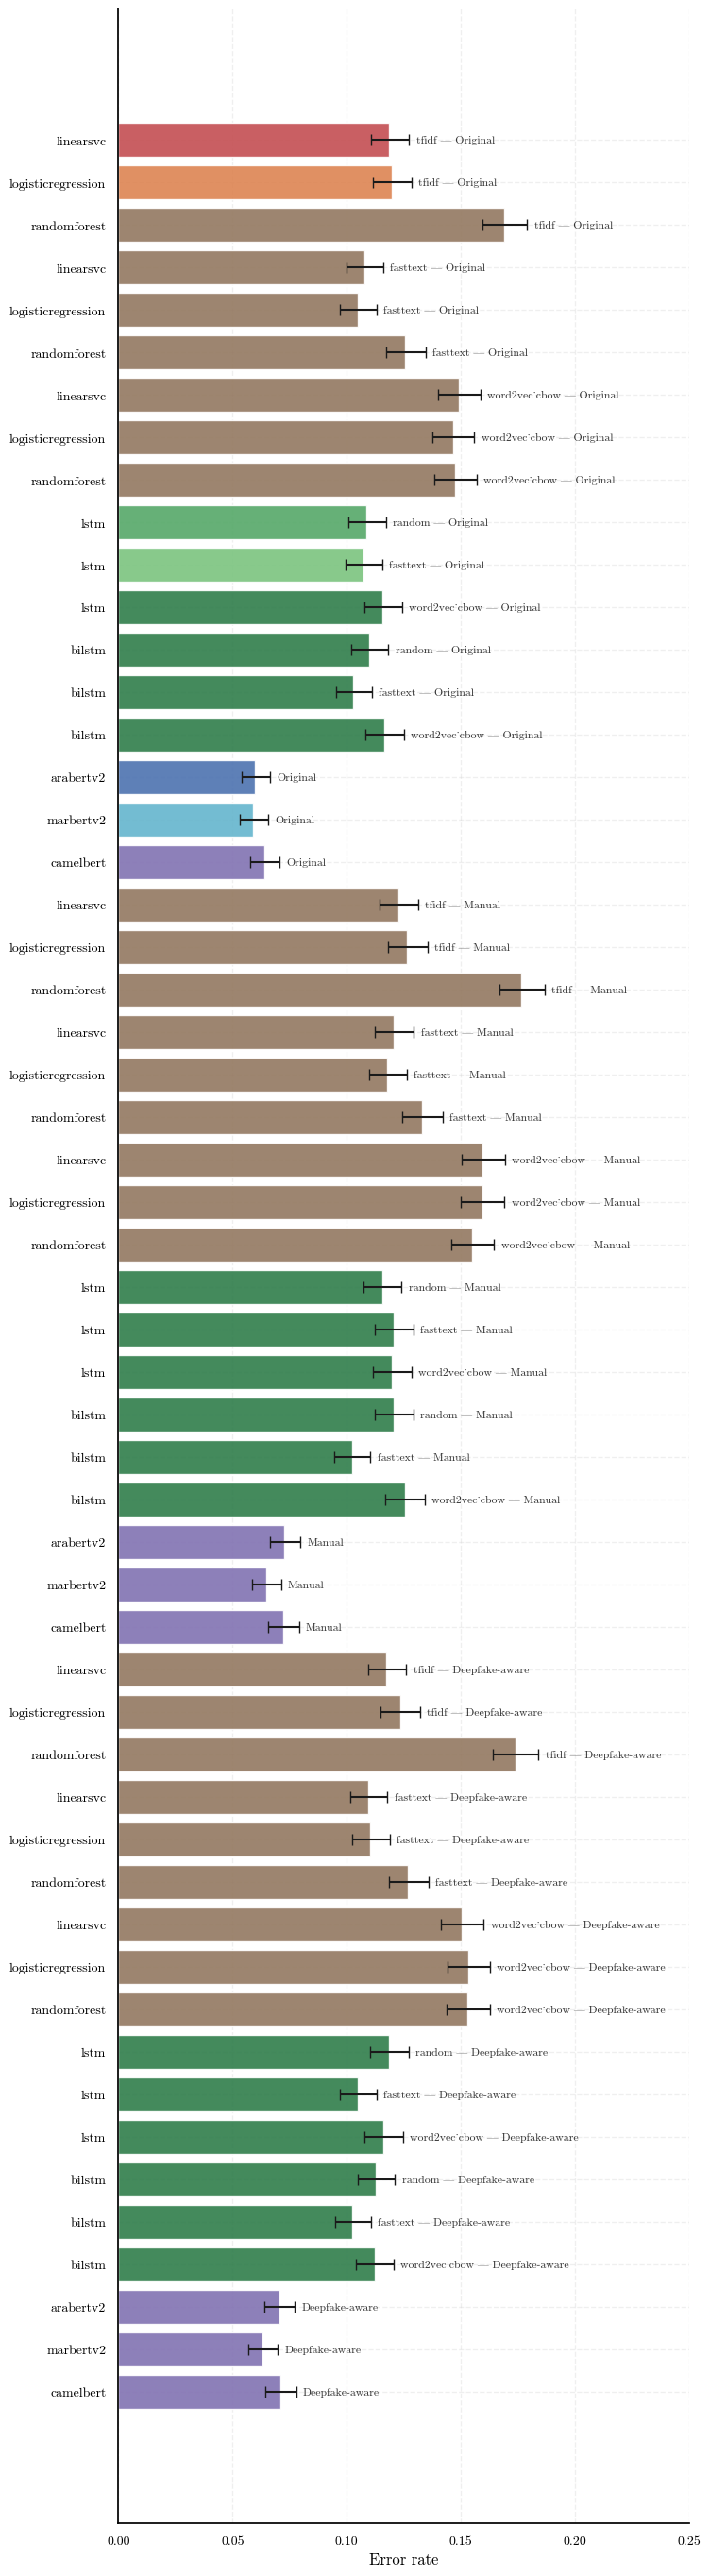

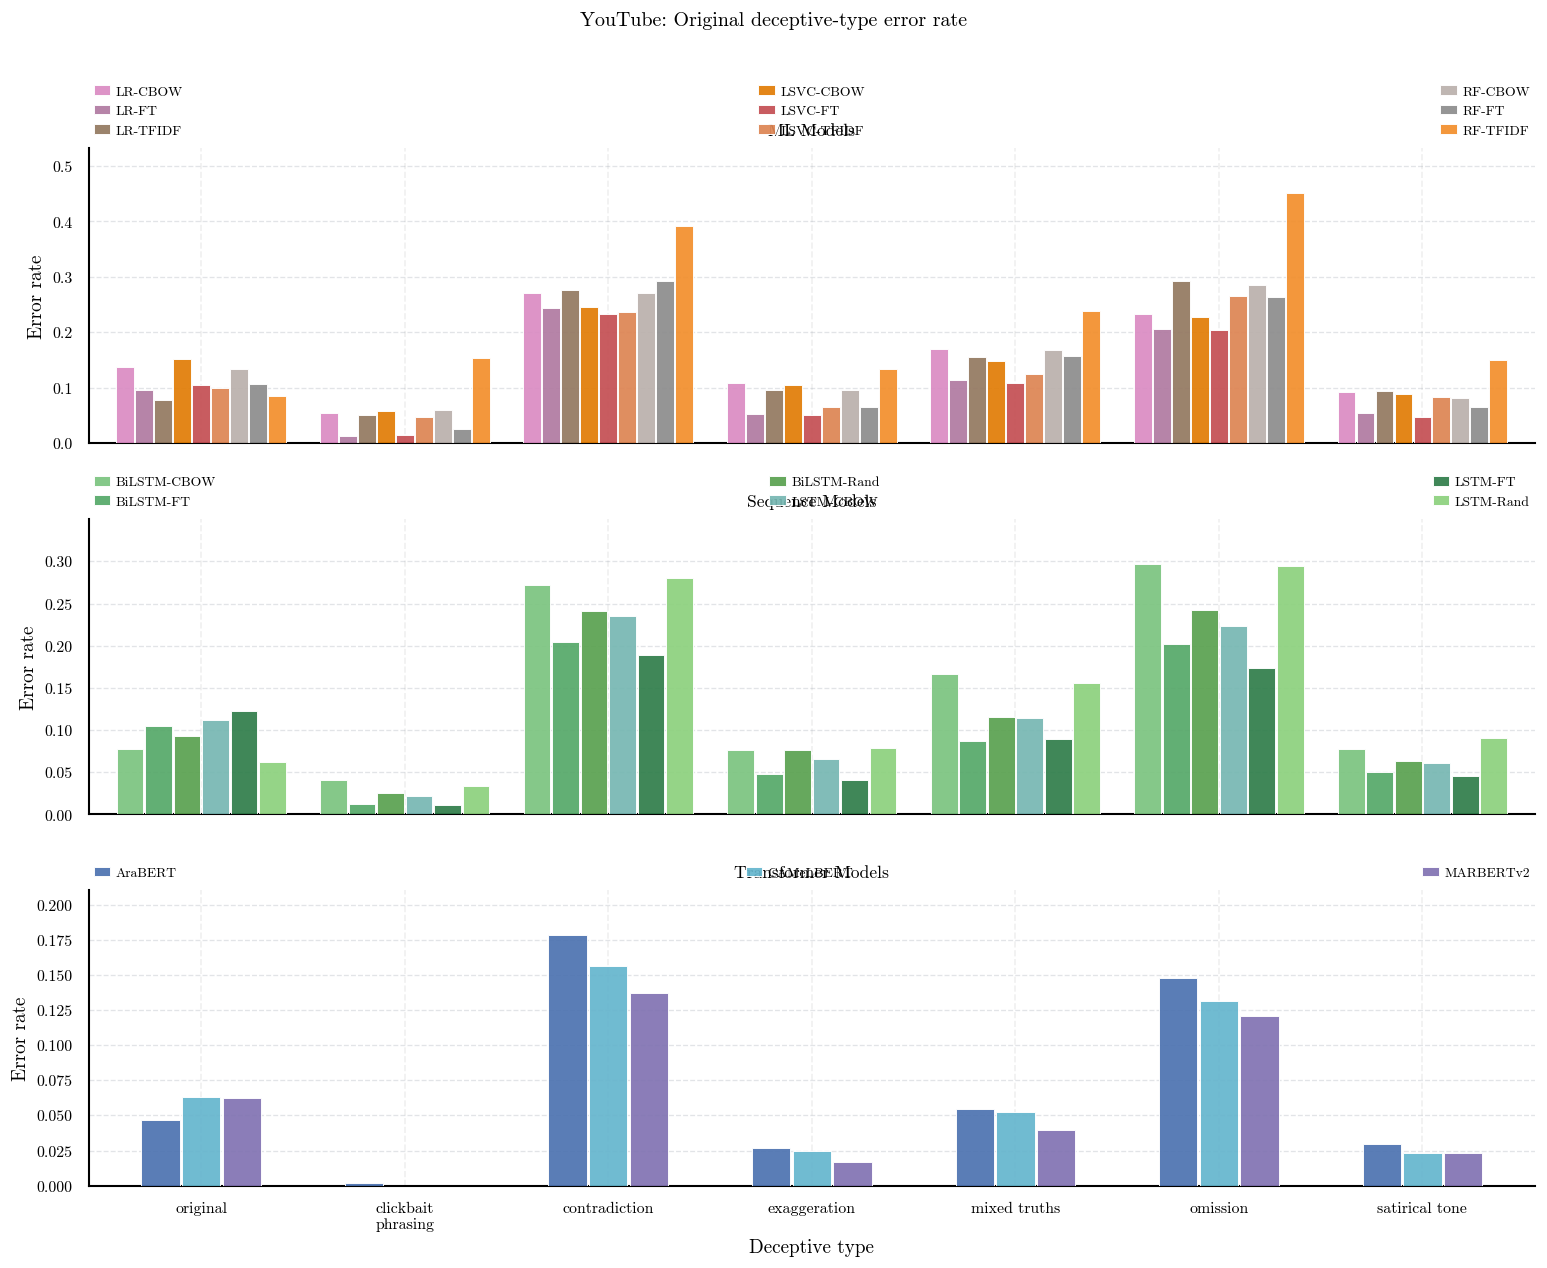

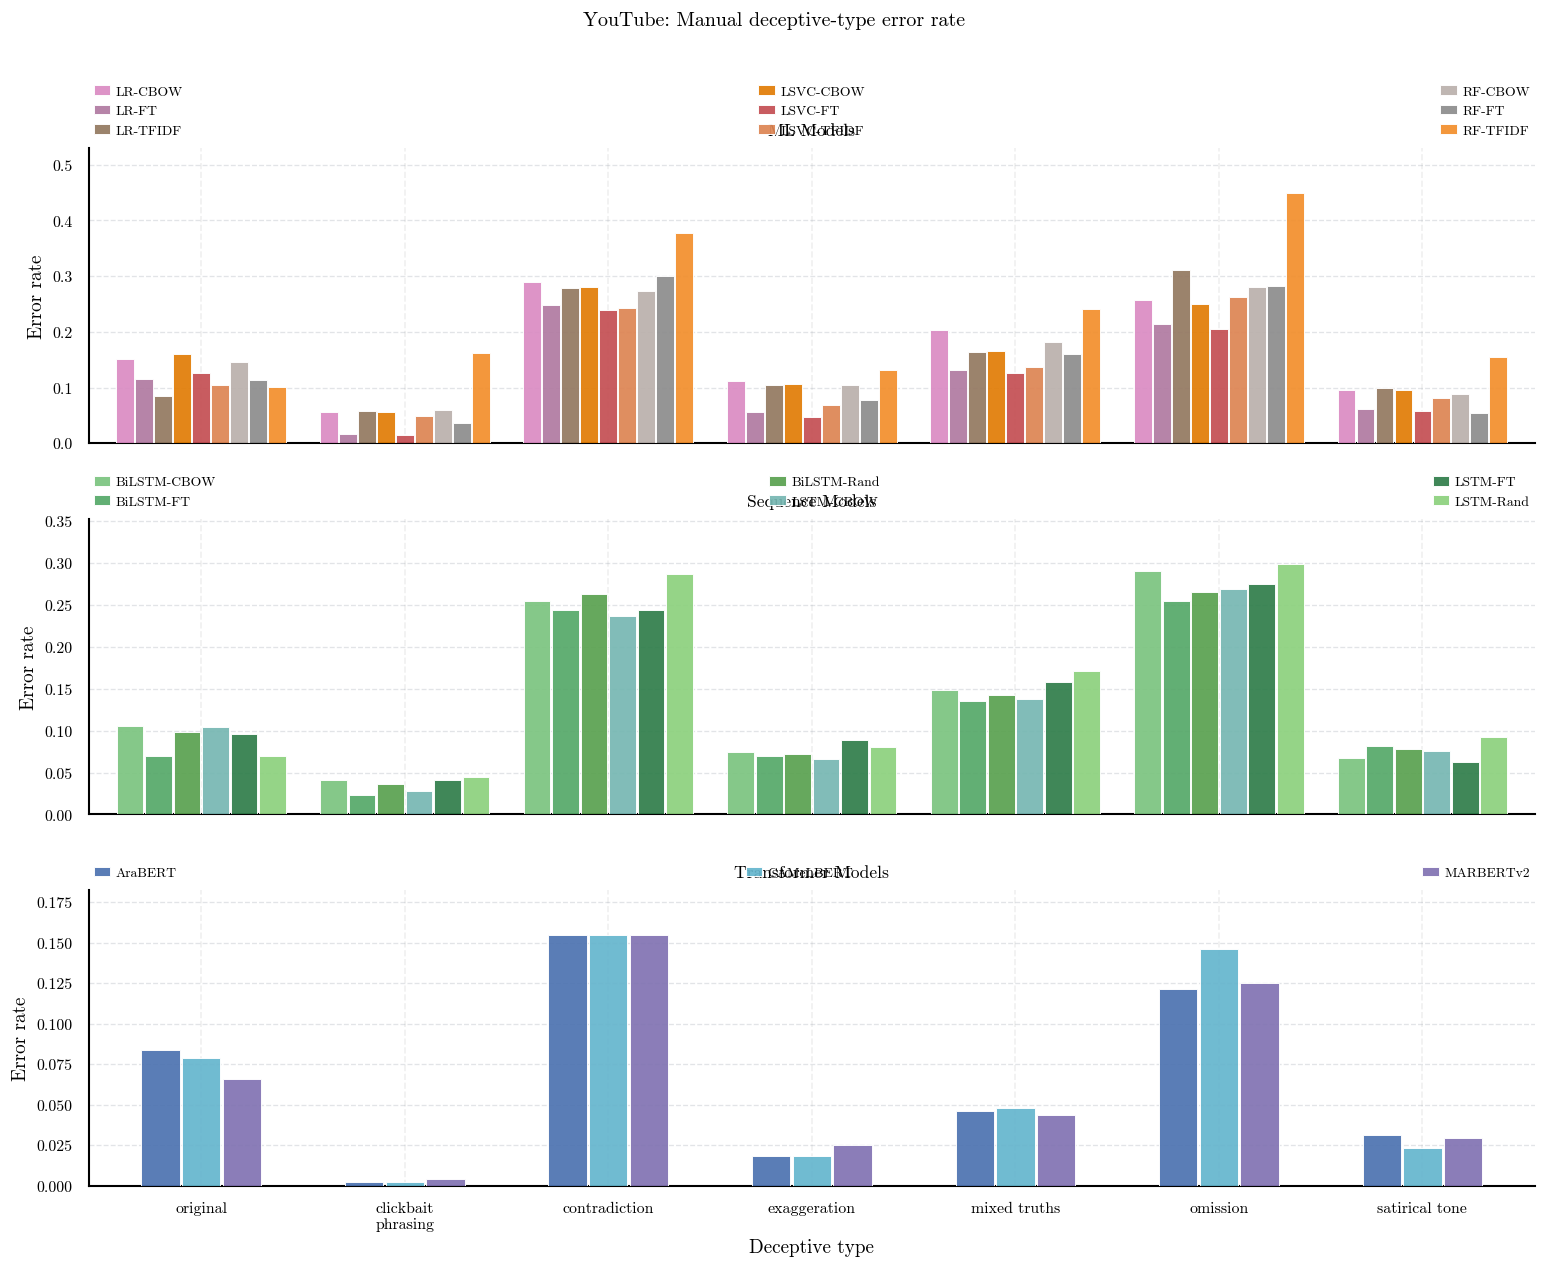

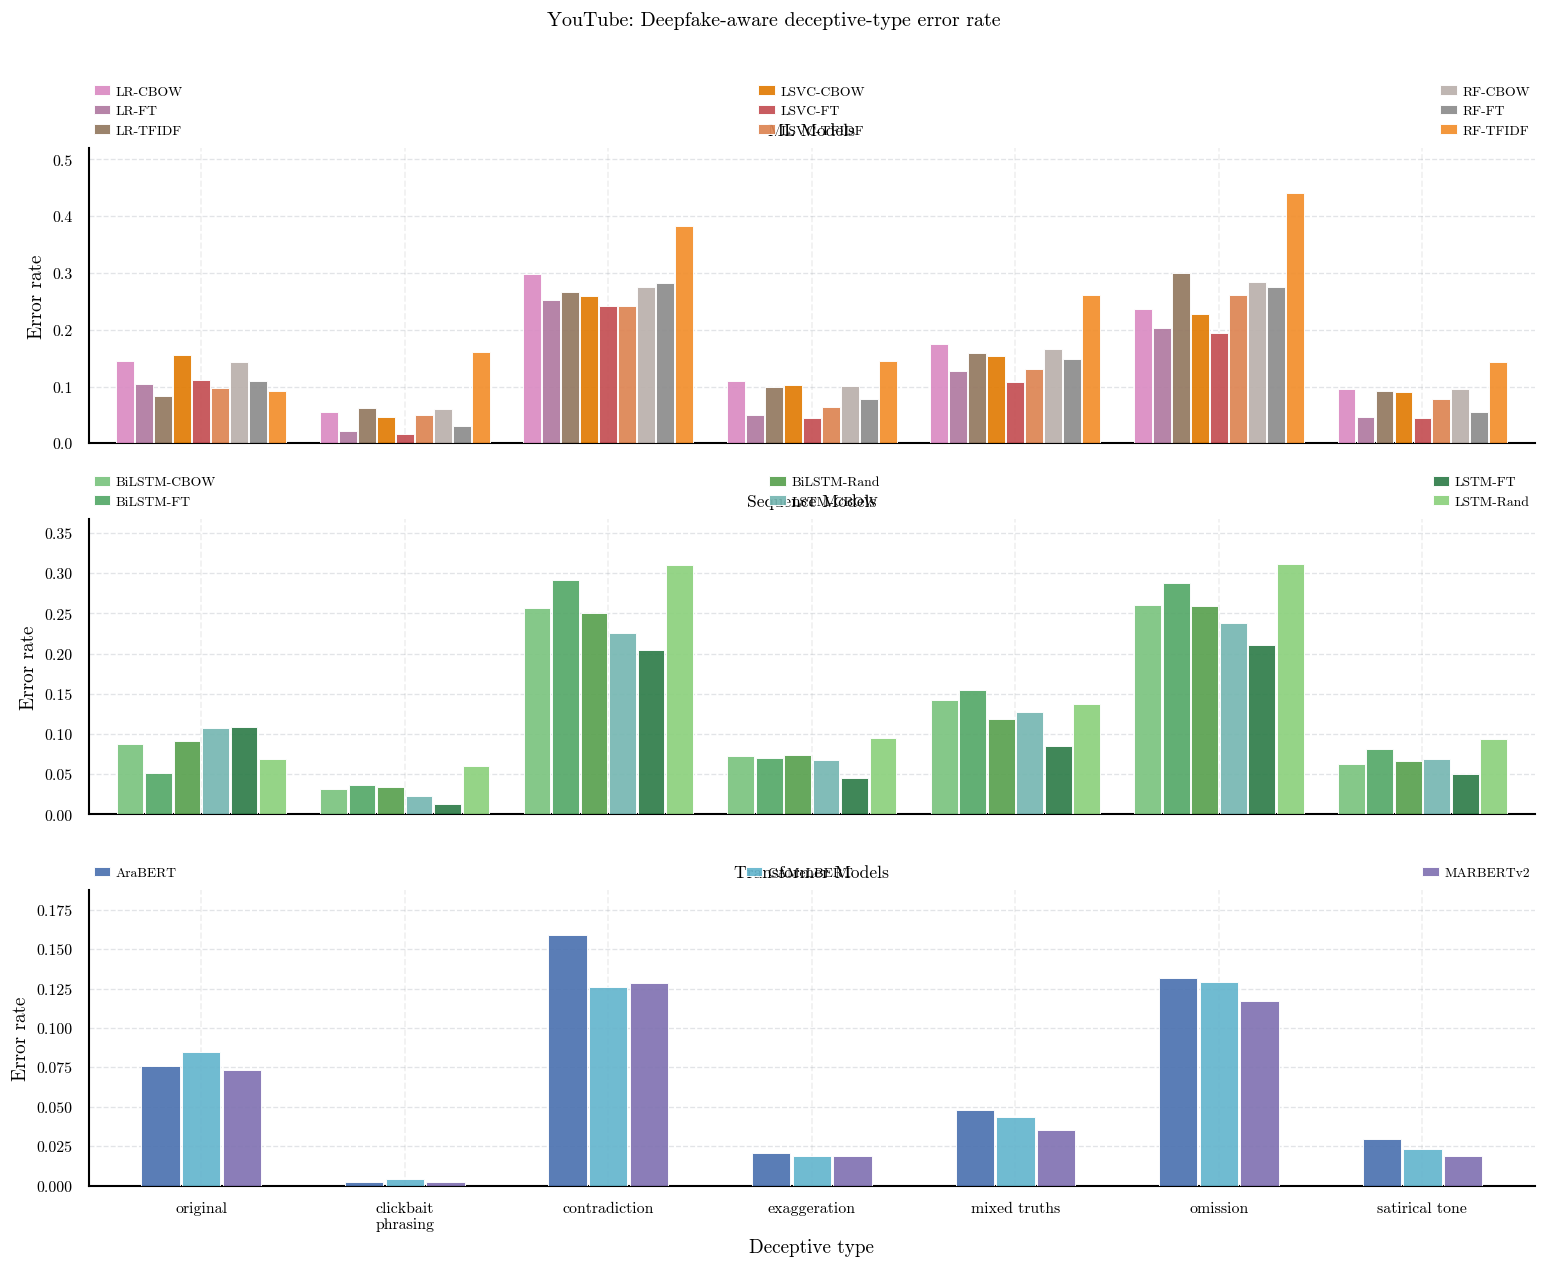

Using deceptive-type field for comprehensive exports: deception_type

Saved deceptive-type comprehensive tables:
- youtube_deceptive_type_error_rate_exact_model_roster.csv
- youtube_deceptive_type_error_rate_exact_model_selection.csv

Exact-model deceptive-type selection preview:


,platform,preprocessing,model_family,model_name,config_name,embedding_family,embedding_name,representation_type,max_len,accuracy,...,exact_label,tick_label,family_order,base_plot_order,plot_order,selection_note,selection_embedding_rank,selection_embedding_pool,figure_bar_count_target,selection_rule
0,youtube,deepfake_aware,ML,linearsvc,linearsvc__tfidf,lexical,tfidf,lexical_tfidf,NaN,0.882561,...,LSVC-TFIDF,LSVC\nTFIDF,0,0,36,tfidf_lexical_baseline,NaN,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
1,youtube,deepfake_aware,ML,logisticregression,logisticregression__tfidf,lexical,tfidf,lexical_tfidf,NaN,0.876724,...,LR-TFIDF,LR\nTFIDF,0,1,37,tfidf_lexical_baseline,NaN,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
2,youtube,deepfake_aware,ML,randomforest,randomforest__tfidf,lexical,tfidf,lexical_tfidf,NaN,0.826141,...,RF-TFIDF,RF\nTFIDF,0,2,38,tfidf_lexical_baseline,NaN,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
3,youtube,deepfake_aware,ML,linearsvc,linearsvc__fasttext,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.890520,...,LSVC-FT,LSVC\nFT,0,3,39,shared_top_embedding,1.0,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
4,youtube,deepfake_aware,ML,logisticregression,logisticregression__fasttext,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.889636,...,LR-FT,LR\nFT,0,4,40,shared_top_embedding,1.0,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
5,youtube,deepfake_aware,ML,randomforest,randomforest__fasttext,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.873187,...,RF-FT,RF\nFT,0,5,41,shared_top_embedding,1.0,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
6,youtube,deepfake_aware,ML,linearsvc,linearsvc__word2vec_cbow,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,0.849487,...,LSVC-CBOW,LSVC\nCBOW,0,6,42,shared_top_embedding,2.0,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
7,youtube,deepfake_aware,ML,logisticregression,logisticregression__word2vec_cbow,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,0.846834,...,LR-CBOW,LR\nCBOW,0,7,43,shared_top_embedding,2.0,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
8,youtube,deepfake_aware,ML,randomforest,randomforest__word2vec_cbow,static_embedding,word2vec_cbow,static_embedding_mean_pool,NaN,0.847011,...,RF-CBOW,RF\nCBOW,0,8,44,shared_top_embedding,2.0,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."
9,youtube,deepfake_aware,Sequence,lstm,lstm__random,random_init,random,sequence_random_init,128.0,0.881500,...,LSTM-Rand,LSTM\nRand,1,9,45,sequence_baseline_or_shared_top_embedding,NaN,"fasttext,word2vec_cbow",18,"Within each preprocessing, the best in-domain ..."



Deceptive-type error-rate summary:


,platform,preprocessing,model_family,model_name,config_name,embedding_name,deceptive_type,total_samples,error_count,error_rate,false_positive_count,false_negative_count,config_uid,deception_type_field,selection_rule,selection_note,plot_order,exact_label,tick_label,analysis_group
0,youtube,deepfake_aware,ML,linearsvc,linearsvc__tfidf,tfidf,clickbait phrasing,468,23,0.049145,23,0,model_family=ML||model_name=linearsvc||config_...,deception_type,"Within each preprocessing, the best in-domain ...",tfidf_lexical_baseline,36,LSVC-TFIDF,LSVC\nTFIDF,exact_model_roster
1,youtube,deepfake_aware,ML,linearsvc,linearsvc__tfidf,tfidf,contradiction,460,111,0.241304,111,0,model_family=ML||model_name=linearsvc||config_...,deception_type,"Within each preprocessing, the best in-domain ...",tfidf_lexical_baseline,36,LSVC-TFIDF,LSVC\nTFIDF,exact_model_roster
2,youtube,deepfake_aware,ML,linearsvc,linearsvc__tfidf,tfidf,exaggeration,485,31,0.063918,31,0,model_family=ML||model_name=linearsvc||config_...,deception_type,"Within each preprocessing, the best in-domain ...",tfidf_lexical_baseline,36,LSVC-TFIDF,LSVC\nTFIDF,exact_model_roster
3,youtube,deepfake_aware,ML,linearsvc,linearsvc__tfidf,tfidf,mixed truths,457,60,0.131291,60,0,model_family=ML||model_name=linearsvc||config_...,deception_type,"Within each preprocessing, the best in-domain ...",tfidf_lexical_baseline,36,LSVC-TFIDF,LSVC\nTFIDF,exact_model_roster
4,youtube,deepfake_aware,ML,linearsvc,linearsvc__tfidf,tfidf,omission,479,125,0.260960,125,0,model_family=ML||model_name=linearsvc||config_...,deception_type,"Within each preprocessing, the best in-domain ...",tfidf_lexical_baseline,36,LSVC-TFIDF,LSVC\nTFIDF,exact_model_roster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,youtube,original,Transformer,camelbert,camelbert,camelbert,exaggeration,485,12,0.024742,12,0,model_family=Transformer||model_name=camelbert...,deception_type,"Within each preprocessing, the best in-domain ...",contextual_transformer_full_set,17,CAMeLBERT,CAMeLBERT,exact_model_roster
374,youtube,original,Transformer,camelbert,camelbert,camelbert,mixed truths,457,24,0.052516,24,0,model_family=Transformer||model_name=camelbert...,deception_type,"Within each preprocessing, the best in-domain ...",contextual_transformer_full_set,17,CAMeLBERT,CAMeLBERT,exact_model_roster
375,youtube,original,Transformer,camelbert,camelbert,camelbert,omission,479,63,0.131524,63,0,model_family=Transformer||model_name=camelbert...,deception_type,"Within each preprocessing, the best in-domain ...",contextual_transformer_full_set,17,CAMeLBERT,CAMeLBERT,exact_model_roster
376,youtube,original,Transformer,camelbert,camelbert,camelbert,original,2827,179,0.063318,0,179,model_family=Transformer||model_name=camelbert...,deception_type,"Within each preprocessing, the best in-domain ...",contextual_transformer_full_set,17,CAMeLBERT,CAMeLBERT,exact_model_roster



Deceptive-type error-rate figure manifest:


,platform,preprocessing,analysis_group,deception_type_field,figure_filename,figure_pdf_filename,csv_filename,figure_output_path,csv_output_path,section_name,purpose,n_deceptive_types,n_series,selection_rule
0,youtube,original,exact_model_roster,deception_type,youtube_deceptive_type_error_rate_original_exa...,youtube_deceptive_type_error_rate_original_exa...,youtube_deceptive_type_error_rate_original_exa...,/content/drive/MyDrive/GADD_Project/Final_Pipe...,/content/drive/MyDrive/GADD_Project/Final_Pipe...,Error Analysis / Deceptive-Type Error Rates,Faceted deceptive-type error-rate comparison o...,7,18,"Within each preprocessing, the best in-domain ..."
1,youtube,manual,exact_model_roster,deception_type,youtube_deceptive_type_error_rate_manual_exact...,youtube_deceptive_type_error_rate_manual_exact...,youtube_deceptive_type_error_rate_manual_exact...,/content/drive/MyDrive/GADD_Project/Final_Pipe...,/content/drive/MyDrive/GADD_Project/Final_Pipe...,Error Analysis / Deceptive-Type Error Rates,Faceted deceptive-type error-rate comparison o...,7,18,"Within each preprocessing, the best in-domain ..."
2,youtube,deepfake_aware,exact_model_roster,deception_type,youtube_deceptive_type_error_rate_deepfake_awa...,youtube_deceptive_type_error_rate_deepfake_awa...,youtube_deceptive_type_error_rate_deepfake_awa...,/content/drive/MyDrive/GADD_Project/Final_Pipe...,/content/drive/MyDrive/GADD_Project/Final_Pipe...,Error Analysis / Deceptive-Type Error Rates,Faceted deceptive-type error-rate comparison o...,7,18,"Within each preprocessing, the best in-domain ..."


\nSaved error-analysis artifacts:
- all_model_error_rates.csv
- best_family_error_rates.csv
- best_family_error_rates.pdf
- best_family_error_rates.png
- best_models_fp_fn_summary.csv
- consensus_hard_samples.csv
- deceptive_type_error_rate_figures_manifest.csv
- deceptive_type_error_rate_summary.csv
- deceptive_type_error_rate_summary.md
- exact_model_error_rates.csv
- fp_fn_by_metadata.csv
- metadata_error_tests.csv
- metadata_error_tests.md
- ml_error_by_deception_type.csv
- ml_error_by_dialect.csv
- ml_error_by_sector.csv
- odds_ratios_deception_type.csv
- seq_error_by_deception_type.csv
- seq_error_by_dialect.csv
- seq_error_by_sector.csv
- trans_error_by_deception_type.csv
- trans_error_by_dialect.csv
- trans_error_by_sector.csv
- youtube_deceptive_type_error_rate_deepfake_aware_exact_model_roster.csv
- youtube_deceptive_type_error_rate_deepfake_aware_exact_model_roster.pdf
- youtube_deceptive_type_error_rate_deepfake_aware_exact_model_roster.png
- youtube_deceptive_type_error_ra

In [102]:
# Export both family-level and metadata-level FP/FN summaries for the discussion section.
fp_fn_frames = []
fp_fn_meta_frames = []
for family_label in FAMILY_ORDER:
    config_row = BEST_FAMILY_CONFIGS.get(family_label)
    subset_df = BEST_FAMILY_SUBSETS.get(family_label, pd.DataFrame())
    if config_row is None or subset_df.empty:
        continue
    summary_df, metadata_df = _compute_fp_fn_tables(subset_df, config_row)
    if not summary_df.empty:
        fp_fn_frames.append(summary_df)
    if not metadata_df.empty:
        fp_fn_meta_frames.append(metadata_df)

best_models_fp_fn_summary = pd.concat(fp_fn_frames, ignore_index=True) if fp_fn_frames else pd.DataFrame()
best_models_fp_fn_summary.to_csv(TABLE_DIR / "best_models_fp_fn_summary.csv", index=False)

fp_fn_by_metadata = pd.concat(fp_fn_meta_frames, ignore_index=True) if fp_fn_meta_frames else pd.DataFrame()
fp_fn_by_metadata.to_csv(TABLE_DIR / "fp_fn_by_metadata.csv", index=False)


exact_model_roster = globals().get("EXACT_MODEL_COMPARISON_ROSTER", pd.DataFrame())
if exact_model_roster is None:
    exact_model_roster = pd.DataFrame()
if exact_model_roster.empty:
    exact_model_roster, _ = exact_model_preprocessing_figures_helpers.build_exact_model_comparison_roster(EXPERIMENT_RESULTS_LONG, preprocessing_order=PREPROCESSING_ORDER, pipeline_name=PIPELINE_NAME)

palette = FIXED_EXACT_MODEL_PALETTES.copy()
color_map = {}
for family_label, colors in palette.items():
    family_rows = exact_model_roster[exact_model_roster["model_family"] == family_label].copy().sort_values("plot_order")
    for idx, row in enumerate(family_rows.itertuples(index=False)):
        color_map[row.config_uid] = colors[min(idx, len(colors) - 1)]

all_model_error_rows = []
all_model_error_ranked = attach_config_uid(EXPERIMENT_RESULTS_LONG.copy())
if "evaluation_scope" not in all_model_error_ranked.columns:
    all_model_error_ranked["evaluation_scope"] = "in_domain"
else:
    all_model_error_ranked["evaluation_scope"] = all_model_error_ranked["evaluation_scope"].fillna("in_domain")
all_model_error_ranked = all_model_error_ranked[all_model_error_ranked["evaluation_scope"] == "in_domain"]
all_model_error_ranked = all_model_error_ranked.drop_duplicates(subset=["config_uid"]).sort_values(["model_family", "model_name", "preprocessing", "macro_f1", "accuracy", "config_uid"], ascending=[True, True, True, False, False, True]).reset_index(drop=True)
for _, config_row in all_model_error_ranked.iterrows():
    family_df = RAW_FAMILY_DFS.get(config_row["model_family"], pd.DataFrame())
    subset_df = filter_df_to_config(family_df, config_row)
    if subset_df.empty:
        continue
    summary_df = compute_error_rate_with_ci(subset_df.assign(config_uid=config_row["config_uid"]), ["config_uid"])
    if summary_df.empty:
        continue
    summary_row = summary_df.iloc[0].to_dict()
    for col in ["config_uid", *CONFIG_ID_COLUMNS]:
        if col in config_row.index:
            summary_row[col] = config_row[col]
    all_model_error_rows.append(summary_row)
all_model_error_rates = pd.DataFrame(all_model_error_rows)
if not all_model_error_rates.empty:
    all_model_error_rates = all_model_error_rates.sort_values(["model_family", "model_name", "preprocessing", "error_rate", "config_name"], ascending=[True, True, True, False, True]).reset_index(drop=True)
all_model_error_rates.to_csv(TABLE_DIR / "all_model_error_rates.csv", index=False)

best_family_error_rows = []
for _, config_row in exact_model_roster.iterrows():
    family_df = RAW_FAMILY_DFS.get(config_row["model_family"], pd.DataFrame())
    subset_df = filter_df_to_config(family_df, config_row)
    if subset_df.empty:
        continue
    summary_df = compute_error_rate_with_ci(subset_df.assign(config_uid=config_row["config_uid"]), ["config_uid"])
    if summary_df.empty:
        continue
    summary_row = summary_df.iloc[0].to_dict()
    for col in ["config_uid", *CONFIG_ID_COLUMNS]:
        if col in config_row.index:
            summary_row[col] = config_row[col]
    best_family_error_rows.append(summary_row)
best_family_error_rates = pd.DataFrame(best_family_error_rows)
best_family_error_rates.to_csv(TABLE_DIR / "exact_model_error_rates.csv", index=False)
# Legacy export name retained for report compatibility; rows come from the exact-model roster.
best_family_error_rates.to_csv(TABLE_DIR / "best_family_error_rates.csv", index=False)
if not best_family_error_rates.empty:
    split_families = {"combined": ["ML", "Sequence", "Transformer"], "mldl": ["ML", "Sequence"], "transformers": ["Transformer"]}
    split_stems = {"combined": "best_family_error_rates", "mldl": "best_family_error_rates_mldl", "transformers": "best_family_error_rates_transformers"}
    split_titles = {"combined": "Exact-Model Error Rate Comparison", "mldl": "ML + DL Error Rate Comparison", "transformers": "Transformer Error Rate Comparison"}
    for split_key, keep_families in split_families.items():
        split_roster = exact_model_roster[exact_model_roster["model_family"].isin(keep_families)].copy().sort_values("plot_order").reset_index(drop=True)
        split_df = best_family_error_rates.merge(split_roster[["config_uid", "plot_order"]], on="config_uid", how="inner").sort_values("plot_order").reset_index(drop=True)
        if split_df.empty:
            continue
        split_df["detail_label"] = split_df.apply(lambda row: PREPROCESSING_SHORT_LABELS.get(row["preprocessing"], row["preprocessing"]) if row["model_family"] == "Transformer" or pd.isna(row.get("embedding_name", np.nan)) or str(row.get("embedding_name", "")) in {"", str(row["model_name"])} else f"{row['embedding_name']} | {PREPROCESSING_SHORT_LABELS.get(row['preprocessing'], row['preprocessing'])}", axis=1)
        fig, ax = plt.subplots(figsize=(7.8, max(3.6, 0.62 * len(split_df) + 1.1)))
        y_positions = np.arange(len(split_df))
        xerr = np.vstack([split_df["error_rate"].to_numpy(dtype=float) - split_df["ci_lower"].to_numpy(dtype=float), split_df["ci_upper"].to_numpy(dtype=float) - split_df["error_rate"].to_numpy(dtype=float)])
        ax.barh(y_positions, split_df["error_rate"], xerr=xerr, capsize=4, color=[color_map.get(uid, "#666666") for uid in split_df["config_uid"]], alpha=0.9)
        for idx, row in enumerate(split_df.itertuples(index=False)):
            ax.text(row.ci_upper + 0.003, idx, row.detail_label, va="center", fontsize=8.5, color="#333333")
        ax.set_yticks(y_positions)
        ax.set_yticklabels(split_df["model_name"])
        ax.invert_yaxis()
        ax.set_xlabel("Error rate")
        ax.set_xlim(0, max(0.25, float(split_df["ci_upper"].max()) * 1.2))
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        save_matplotlib_figure(fig, FIG_DIR / split_stems[split_key])
        if split_key == "combined":
            plt.show()
        else:
            plt.close(fig)

consensus_hard_samples = _build_consensus_table(BEST_FAMILY_SUBSETS)
consensus_hard_samples.to_csv(MISCLASS_BASE / "comparative" / "consensus_hard_samples.csv", index=False, encoding="utf-8")

deceptive_type_outputs = run_deceptive_type_analysis(
    experiment_results_long=EXPERIMENT_RESULTS_LONG,
    in_domain_predictions=in_domain_predictions,
    df_trans=df_trans,
    df_sequence=df_sequence,
    df_ml=df_ml,
    attach_config_uid=attach_config_uid,
    write_dataframe_with_markdown=write_dataframe_with_markdown,
    table_dir=TABLE_DIR,
    fig_dir=FIG_DIR,
    pipeline_name=PIPELINE_NAME,
    display_name=DISPLAY_NAME,
    preprocessing_order=PREPROCESSING_ORDER,
    paper_rcparams=PAPER_RCPARAMS,
    paper_preprocessing_label=paper_preprocessing_label,
    save_matplotlib_figure=save_matplotlib_figure,
)

deceptive_type_field = deceptive_type_outputs["deception_type_field"]
exact_model_deceptive_type_error_rates = deceptive_type_outputs["exact_model_table"]
deceptive_type_error_rate_summary = deceptive_type_outputs["summary"]
deceptive_type_error_rate_figures_manifest = deceptive_type_outputs["manifest"]
exact_model_deceptive_type_selection = deceptive_type_outputs["selection"]
error_artifacts.extend(deceptive_type_outputs["artifacts"])

if deceptive_type_field is not None:
    print(f"Using deceptive-type field for comprehensive exports: {deceptive_type_field}")
    print("\nSaved deceptive-type comprehensive tables:")
    print(f"- {PIPELINE_NAME}_deceptive_type_error_rate_exact_model_roster.csv")
    print(f"- {PIPELINE_NAME}_deceptive_type_error_rate_exact_model_selection.csv")
if not exact_model_deceptive_type_selection.empty:
    print("\nExact-model deceptive-type selection preview:")
    display(exact_model_deceptive_type_selection)
if not deceptive_type_error_rate_summary.empty:
    print("\nDeceptive-type error-rate summary:")
    display(deceptive_type_error_rate_summary)
if not deceptive_type_error_rate_figures_manifest.empty:
    print("\nDeceptive-type error-rate figure manifest:")
    display(deceptive_type_error_rate_figures_manifest)

print("\\nSaved error-analysis artifacts:")
for name in sorted(error_artifacts + ["metadata_error_tests.csv", "metadata_error_tests.md", "odds_ratios_deception_type.csv", "best_models_fp_fn_summary.csv", "fp_fn_by_metadata.csv", "exact_model_error_rates.csv", "all_model_error_rates.csv", "best_family_error_rates.csv", "best_family_error_rates.png", "best_family_error_rates.pdf", "consensus_hard_samples.csv"]):
    print(f"- {name}")
print("=" * 80)


## Cross-Platform Evaluation


### Transfer Setup


In [103]:
# Generalization Setup
import matplotlib.ticker as mtick

# Reapply the source-platform preprocessing functions to the target-platform test text for transfer analysis.
GEN_MAX_LEN = DEFAULT_MAX_LEN
GEN_BSZ = BSZ_TEST if "BSZ_TEST" in globals() else 64
if PIPELINE_NAME == "twitter":
    GENERALIZATION_PREP_FNS = {
        "original": lambda text: safe_str(text),
        "manual": preprocess_manual_twitter,
        "deepfake_aware": preprocess_deepfake_aware_twitter,
    }
else:
    GENERALIZATION_PREP_FNS = {
        "original": lambda text: safe_str(text),
        "manual": preprocess_manual_youtube,
        "deepfake_aware": preprocess_deepfake_aware_youtube,
    }


def load_external_test_frame(pipeline_name):
    split_paths = resolve_dataset_paths(pipeline_name)
    if not split_paths["test_meta"].exists():
        return None
    df = pd.read_csv(split_paths["test_meta"], encoding="utf-8", on_bad_lines="skip")
    df.columns = [str(c).strip() for c in df.columns]
    text_col = "text" if "text" in df.columns else next(c for c in df.columns if c.lower() in {"text", "content", "body"})
    label_col = "label" if "label" in df.columns else next(c for c in df.columns if c.lower() in {"label", "type", "class"})
    out = df.copy()
    out["text"] = out[text_col].fillna("").astype(str)
    out["label"] = out[label_col].map({"fake": 0, "deepfake": 0, "real": 1, "true": 1, "false": 0}).fillna(out[label_col])
    out["label"] = pd.to_numeric(out["label"], errors="coerce").astype(int)
    return out.reset_index(drop=True)


def summarize_prediction_bundle(y_true, y_pred):
    metrics = compute_binary_classification_metrics(np.asarray(y_true), np.asarray(y_pred))
    return {
        "accuracy": metrics["accuracy"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_f1": metrics["macro_f1"],
        "weighted_precision": metrics["weighted_precision"],
        "weighted_recall": metrics["weighted_recall"],
        "weighted_f1": metrics["weighted_f1"],
    }


OTHER_TEST_FRAME = load_external_test_frame(OTHER_PIPELINE_NAME)
if OTHER_TEST_FRAME is None:
    print(f"{OTHER_DISPLAY_NAME} test split not found. Cross-platform export will keep in-domain rows only.")
    OTHER_TEXTS_BY_PREP = {}
    OTHER_LABELS = np.array([], dtype=int)
else:
    OTHER_TEXTS_BY_PREP = {
        prep: [GENERALIZATION_PREP_FNS[prep](text) for text in OTHER_TEST_FRAME["text"].tolist()]
        for prep in PREPROCESSING_RUN
    }
    OTHER_LABELS = OTHER_TEST_FRAME["label"].to_numpy(dtype=int)


### Cross-Platform Evaluation Loops


In [104]:
# Cross-Platform Evaluation for ML, Sequence, and Transformer Branches
cross_summary_rows = []
cross_prediction_rows = []


def append_cross_rows(base_row, y_true, y_pred, texts):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    metrics = summarize_prediction_bundle(y_true, y_pred)
    cross_summary_rows.append({**base_row, **metrics})
    for idx, (gold, pred, text) in enumerate(zip(y_true, y_pred, texts)):
        cross_prediction_rows.append(
            {
                **base_row,
                "sample_idx": idx,
                "text": text,
                "y_true": int(gold),
                "y_pred": int(pred),
                "correct": int(gold == pred),
                "error": int(gold != pred),
            }
        )


In [105]:
# Keep the source-trained representations fixed here so transfer loss reflects robustness, not retuning.
if OTHER_TEST_FRAME is not None:
    for method in PREPROCESSING_RUN:
        source_texts = OTHER_TEXTS_BY_PREP[method]

        for config_name, result in ml_results[method].items():
            if result["feature_branch"] == "lexical":
                X_cross = result["vectorizer"].transform(source_texts)
            else:
                model = EMBEDDING_REGISTRY[method][result["embedding_name"]]
                tokenized = [tokenize_for_embedding(text) for text in source_texts]
                X_cross = vectorize_documents(tokenized, model, result["embedding_name"])
            preds = result["estimator"].predict(X_cross)
            append_cross_rows(
                {
                    "platform": PIPELINE_NAME,
                    "evaluation_scope": "cross_platform",
                    "source_platform": PIPELINE_NAME,
                    "target_platform": OTHER_PIPELINE_NAME,
                    "preprocessing": method,
                    "embedding_family": result["embedding_family"],
                    "embedding_name": result["embedding_name"],
                    "representation_type": result["representation_type"],
                    "model_family": "ML",
                    "model_name": result["model_name"],
                    "config_name": config_name,
                    "max_len": np.nan,
                    "training_time": result["training_time"],
                    "seed": SEED,
                    "notes": result["notes"],
                },
                OTHER_LABELS,
                preds,
                source_texts,
            )

        for config_name, run_data in sequence_model_runs.get(method, {}).items():
            model, _ = load_saved_sequence_model(run_data)
            model = model.to(DEVICE)
            tokenized = [tokenize_for_embedding(text) for text in source_texts]
            X_cross, lengths_cross = encode_tokenized_texts(tokenized, load_json(run_data["vocab_path"]), max_len=run_data["max_len"])
            loader = build_sequence_loader(X_cross, lengths_cross, OTHER_LABELS, shuffle=False)
            _, preds, gold, _ = evaluate_sequence_model(model, loader)
            append_cross_rows(
                {
                    "platform": PIPELINE_NAME,
                    "evaluation_scope": "cross_platform",
                    "source_platform": PIPELINE_NAME,
                    "target_platform": OTHER_PIPELINE_NAME,
                    "preprocessing": method,
                    "embedding_family": run_data["embedding_family"],
                    "embedding_name": run_data["embedding_name"],
                    "representation_type": run_data["representation_type"],
                    "model_family": "Sequence",
                    "model_name": run_data["model_name"],
                    "config_name": config_name,
                    "max_len": run_data.get("max_len", np.nan),
                    "training_time": run_data["training_time"],
                    "seed": SEED,
                    "notes": run_data["metadata"]["coverage"],
                },
                gold,
                preds,
                source_texts,
            )
            model.cpu()
        for model_shortname in ["arabert", "marbertv2", "camelbert"]:
            run_dir = get_model_run_dir(MODELS_DIR, model_shortname, method, GEN_MAX_LEN, SEED)
            if not run_dir.exists():
                continue
            model, tokenizer, metadata = load_model_and_tokenizer(run_dir)
            model = model.to(DEVICE)
            preds = []
            for start in range(0, len(source_texts), GEN_BSZ):
                enc = tokenizer(
                    source_texts[start : start + GEN_BSZ],
                    padding=True,
                    truncation=True,
                    max_length=GEN_MAX_LEN,
                    return_tensors="pt",
                )
                enc = {k: v.to(DEVICE) for k, v in enc.items()}
                with torch.no_grad():
                    logits = model(**enc).logits
                    preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
            model_name = {"arabert": "arabertv2", "marbertv2": "marbertv2", "camelbert": "camelbert"}[model_shortname]
            append_cross_rows(
                {
                    "platform": PIPELINE_NAME,
                    "evaluation_scope": "cross_platform",
                    "source_platform": PIPELINE_NAME,
                    "target_platform": OTHER_PIPELINE_NAME,
                    "preprocessing": method,
                    "embedding_family": "contextual_transformer",
                    "embedding_name": model_name,
                    "representation_type": "contextual_transformer",
                    "model_family": "Transformer",
                    "model_name": model_name,
                    "config_name": model_name,
                    "max_len": GEN_MAX_LEN,
                    "training_time": load_json(run_dir / "timing_summary.json", default={}).get("total_time_sec", np.nan),
                    "seed": SEED,
                    "notes": f"checkpoint={run_dir.name}",
                },
                OTHER_LABELS,
                np.asarray(preds),
                source_texts,
            )
            model.cpu()


cross_platform_only = attach_config_uid(pd.DataFrame(cross_summary_rows))
in_domain_summary = attach_config_uid(EXPERIMENT_RESULTS_LONG.copy())
cross_platform_results_long = pd.concat([in_domain_summary, cross_platform_only], ignore_index=True, sort=False)
cross_platform_results_long = cross_platform_results_long.sort_values(
    ["evaluation_scope", "preprocessing", "model_family", "model_name", "embedding_name", "macro_f1"],
    ascending=[True, True, True, True, True, False],
).reset_index(drop=True)
cross_platform_results_long.to_csv(TABLE_DIR / "cross_platform_results_long.csv", index=False)

cross_platform_predictions_long = pd.concat([
    attach_config_uid(in_domain_predictions.copy()),
    attach_config_uid(pd.DataFrame(cross_prediction_rows)),
], ignore_index=True, sort=False)
cross_platform_predictions_long.to_csv(TABLE_DIR / "cross_platform_predictions_long.csv", index=False)

transfer_summary = pd.DataFrame()
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"]
id_cols = [col for col in CONFIG_ID_COLUMNS if col in cross_platform_results_long.columns]

if not cross_platform_results_long.empty and not cross_platform_only.empty:
    in_domain_part = in_domain_summary[["config_uid"] + id_cols + metric_cols].rename(columns={metric: f"{metric}_in_domain" for metric in metric_cols})
    cross_part = cross_platform_only[["config_uid"] + id_cols + metric_cols].rename(columns={metric: f"{metric}_cross_platform" for metric in metric_cols})
    transfer_summary = in_domain_part.merge(cross_part, on="config_uid", how="inner", suffixes=("_in_domain", "_cross_platform"))
    for col in id_cols:
        in_col = f"{col}_in_domain"
        cross_col = f"{col}_cross_platform"
        if in_col in transfer_summary.columns:
            transfer_summary[col] = transfer_summary[in_col]
        elif cross_col in transfer_summary.columns:
            transfer_summary[col] = transfer_summary[cross_col]
    transfer_summary["macro_f1_delta"] = transfer_summary["macro_f1_in_domain"] - transfer_summary["macro_f1_cross_platform"]
    transfer_summary["accuracy_delta"] = transfer_summary["accuracy_in_domain"] - transfer_summary["accuracy_cross_platform"]
    preferred_cols = [
        "config_uid",
        *id_cols,
        *[f"{metric}_in_domain" for metric in metric_cols],
        *[f"{metric}_cross_platform" for metric in metric_cols],
        "macro_f1_delta",
        "accuracy_delta",
    ]
    preferred_cols = [col for col in preferred_cols if col in transfer_summary.columns]
    transfer_summary = transfer_summary[preferred_cols].sort_values(
        ["macro_f1_cross_platform", "weighted_f1_cross_platform", "macro_recall_cross_platform", "config_uid"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
transfer_summary.to_csv(TABLE_DIR / "cross_platform_transfer_summary.csv", index=False)

missing_transfer_configs = (
    in_domain_summary[["config_uid"] + id_cols].drop_duplicates()
    .merge(cross_platform_only[["config_uid"]].drop_duplicates(), on="config_uid", how="left", indicator=True)
)
missing_transfer_configs = missing_transfer_configs[missing_transfer_configs["_merge"] == "left_only"].drop(columns=["_merge"]).reset_index(drop=True)
missing_transfer_configs.to_csv(TABLE_DIR / "cross_platform_missing_configs.csv", index=False)
(TABLE_DIR / "cross_platform_missing_configs.md").write_text(
    "_No rows available._\n" if missing_transfer_configs.empty else missing_transfer_configs.to_markdown(index=False) + "\n",
    encoding="utf-8",
)
if not missing_transfer_configs.empty:
    print(f"WARNING: {len(missing_transfer_configs)} in-domain configs are missing cross-platform transfer rows.")

legacy_generalization = cross_platform_results_long[
    (cross_platform_results_long["model_family"] == "Transformer")
    & (cross_platform_results_long["evaluation_scope"] == "cross_platform")
].copy()
legacy_generalization.to_csv(TABLE_DIR / f"generalization_eval_transformers_{PIPELINE_NAME}.csv", index=False)
legacy_generalization.to_csv(TABLE_DIR / "generalization_eval_transformers.csv", index=False)


def _write_cross_md(df, md_path):
    if df.empty:
        md_path.write_text("_No rows available._\n", encoding="utf-8")
    else:
        md_path.write_text(df.to_markdown(index=False) + "\n", encoding="utf-8")


cross_only = cross_platform_results_long[cross_platform_results_long["evaluation_scope"] == "cross_platform"].copy()
cross_only = cross_only[cross_only["preprocessing"].isin(PREPROCESSING_ORDER)].copy()
if not cross_only.empty:
    cross_only["preprocessing"] = pd.Categorical(cross_only["preprocessing"], PREPROCESSING_ORDER, ordered=True)

all_models_cross_platform_results = pd.DataFrame()
best_family_cross_platform_results = pd.DataFrame()
cross_platform_family_macro_f1_summary = pd.DataFrame()

if not cross_only.empty:
    cross_only_ranked = cross_only.sort_values(
        ["macro_f1", "weighted_f1", "macro_recall", "macro_precision", "accuracy", "config_uid"],
        ascending=[False, False, False, False, False, True],
    ).reset_index(drop=True)

    all_cols = [
        "platform",
        "source_platform",
        "target_platform",
        "evaluation_scope",
        "preprocessing",
        "model_family",
        "model_name",
        "config_name",
        "embedding_family",
        "embedding_name",
        "representation_type",
        "max_len",
        "config_uid",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "accuracy",
    ]
    all_models_cross_platform_results = cross_only_ranked[[col for col in all_cols if col in cross_only_ranked.columns]].copy()
    all_models_cross_platform_results.to_csv(TABLE_DIR / "all_models_cross_platform_results.csv", index=False)
    _write_cross_md(all_models_cross_platform_results, TABLE_DIR / "all_models_cross_platform_results.md")

    best_family_cross_platform_results = (
        cross_only_ranked
        .groupby(["preprocessing", "model_family"], as_index=False)
        .first()
        .sort_values(["preprocessing", "macro_f1", "weighted_f1", "macro_recall"], ascending=[True, False, False, False])
        .reset_index(drop=True)
    )
    best_family_cross_platform_results.to_csv(TABLE_DIR / "best_family_cross_platform_results.csv", index=False)
    _write_cross_md(best_family_cross_platform_results, TABLE_DIR / "best_family_cross_platform_results.md")

    cross_platform_family_macro_f1_summary = (
        cross_only.groupby(["preprocessing", "model_family"], as_index=False)
        .agg(
            mean_macro_f1=("macro_f1", "mean"),
            max_macro_f1=("macro_f1", "max"),
            mean_weighted_f1=("weighted_f1", "mean"),
            mean_macro_precision=("macro_precision", "mean"),
            mean_macro_recall=("macro_recall", "mean"),
            mean_accuracy=("accuracy", "mean"),
            n_configs=("config_uid", "nunique"),
        )
        .sort_values(["preprocessing", "max_macro_f1", "mean_macro_f1"], ascending=[True, False, False])
        .reset_index(drop=True)
    )
    cross_platform_family_macro_f1_summary.to_csv(TABLE_DIR / "cross_platform_family_macro_f1_summary.csv", index=False)
    _write_cross_md(cross_platform_family_macro_f1_summary, TABLE_DIR / "cross_platform_family_macro_f1_summary.md")
else:
    all_models_cross_platform_results.to_csv(TABLE_DIR / "all_models_cross_platform_results.csv", index=False)
    best_family_cross_platform_results.to_csv(TABLE_DIR / "best_family_cross_platform_results.csv", index=False)
    cross_platform_family_macro_f1_summary.to_csv(TABLE_DIR / "cross_platform_family_macro_f1_summary.csv", index=False)
    _write_cross_md(all_models_cross_platform_results, TABLE_DIR / "all_models_cross_platform_results.md")
    _write_cross_md(best_family_cross_platform_results, TABLE_DIR / "best_family_cross_platform_results.md")
    _write_cross_md(cross_platform_family_macro_f1_summary, TABLE_DIR / "cross_platform_family_macro_f1_summary.md")

display(all_models_cross_platform_results.head(20))
display(best_family_cross_platform_results.head(20))
display(transfer_summary.head(15))


/tmp/ipykernel_29028/3276656006.py:228: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["preprocessing", "model_family"], as_index=False)
/tmp/ipykernel_29028/3276656006.py:237: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cross_only.groupby(["preprocessing", "model_family"], as_index=False)


,platform,source_platform,target_platform,evaluation_scope,preprocessing,model_family,model_name,config_name,embedding_family,embedding_name,representation_type,max_len,config_uid,macro_precision,macro_recall,macro_f1,weighted_f1,accuracy
0,youtube,youtube,twitter,cross_platform,original,Transformer,arabertv2,arabertv2,contextual_transformer,arabertv2,contextual_transformer,128.0,model_family=Transformer||model_name=arabertv2...,0.945082,0.943052,0.943346,0.943378,0.943443
1,youtube,youtube,twitter,cross_platform,deepfake_aware,Transformer,arabertv2,arabertv2,contextual_transformer,arabertv2,contextual_transformer,128.0,model_family=Transformer||model_name=arabertv2...,0.910062,0.910045,0.909862,0.909861,0.909862
2,youtube,youtube,twitter,cross_platform,deepfake_aware,Transformer,marbertv2,marbertv2,contextual_transformer,marbertv2,contextual_transformer,128.0,model_family=Transformer||model_name=marbertv2...,0.910330,0.909842,0.909496,0.909482,0.909509
3,youtube,youtube,twitter,cross_platform,original,Transformer,camelbert,camelbert,contextual_transformer,camelbert,contextual_transformer,128.0,model_family=Transformer||model_name=camelbert...,0.916052,0.908663,0.909012,0.909105,0.909509
4,youtube,youtube,twitter,cross_platform,original,Transformer,marbertv2,marbertv2,contextual_transformer,marbertv2,contextual_transformer,128.0,model_family=Transformer||model_name=marbertv2...,0.915667,0.907558,0.907901,0.907999,0.908448
5,youtube,youtube,twitter,cross_platform,manual,Transformer,arabertv2,arabertv2,contextual_transformer,arabertv2,contextual_transformer,128.0,model_family=Transformer||model_name=arabertv2...,0.907061,0.906973,0.907008,0.907029,0.907034
6,youtube,youtube,twitter,cross_platform,manual,Transformer,marbertv2,marbertv2,contextual_transformer,marbertv2,contextual_transformer,128.0,model_family=Transformer||model_name=marbertv2...,0.885815,0.882027,0.882263,0.882355,0.882644
7,youtube,youtube,twitter,cross_platform,manual,Transformer,camelbert,camelbert,contextual_transformer,camelbert,contextual_transformer,128.0,model_family=Transformer||model_name=camelbert...,0.880127,0.876340,0.875339,0.875264,0.875574
8,youtube,youtube,twitter,cross_platform,deepfake_aware,Transformer,camelbert,camelbert,contextual_transformer,camelbert,contextual_transformer,128.0,model_family=Transformer||model_name=camelbert...,0.860586,0.840846,0.837185,0.836938,0.839166
9,youtube,youtube,twitter,cross_platform,manual,ML,randomforest,randomforest__fasttext,static_embedding,fasttext,static_embedding_mean_pool,NaN,model_family=ML||model_name=randomforest||conf...,0.789150,0.772149,0.769985,0.770391,0.773772


,preprocessing,model_family,platform,evaluation_scope,source_platform,target_platform,embedding_family,embedding_name,representation_type,model_name,...,notes,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,max_len,config_uid
0,original,Transformer,youtube,cross_platform,youtube,twitter,contextual_transformer,arabertv2,contextual_transformer,arabertv2,...,checkpoint=prep=original__maxlen=128__seed=42,0.943443,0.945082,0.943052,0.943346,0.944755,0.943443,0.943378,128.0,model_family=Transformer||model_name=arabertv2...
1,original,ML,youtube,cross_platform,youtube,twitter,lexical,tfidf,lexical_tfidf,linearsvc,...,Lexical TF-IDF baseline,0.752209,0.777704,0.750081,0.745298,0.776591,0.752209,0.745877,NaN,model_family=ML||model_name=linearsvc||config_...
2,original,Sequence,youtube,cross_platform,youtube,twitter,random_init,random,sequence_random_init,bilstm,...,"{'covered_words': 0, 'total_words': 24998, 'co...",0.748321,0.798708,0.745456,0.735751,0.797064,0.748321,0.736546,128.0,model_family=Sequence||model_name=bilstm||conf...
3,manual,Transformer,youtube,cross_platform,youtube,twitter,contextual_transformer,arabertv2,contextual_transformer,arabertv2,...,checkpoint=prep=manual__maxlen=128__seed=42,0.907034,0.907061,0.906973,0.907008,0.907043,0.907034,0.907029,128.0,model_family=Transformer||model_name=arabertv2...
4,manual,ML,youtube,cross_platform,youtube,twitter,static_embedding,fasttext,static_embedding_mean_pool,randomforest,...,Dense document vectors with mean pooling,0.773772,0.789150,0.772149,0.769985,0.788277,0.773772,0.770391,NaN,model_family=ML||model_name=randomforest||conf...
5,manual,Sequence,youtube,cross_platform,youtube,twitter,random_init,random,sequence_random_init,bilstm,...,"{'covered_words': 0, 'total_words': 24998, 'co...",0.729940,0.792119,0.726721,0.712911,0.790308,0.729940,0.713875,128.0,model_family=Sequence||model_name=bilstm||conf...
6,deepfake_aware,Transformer,youtube,cross_platform,youtube,twitter,contextual_transformer,arabertv2,contextual_transformer,arabertv2,...,checkpoint=prep=deepfake_aware__maxlen=128__se...,0.909862,0.910062,0.910045,0.909862,0.910243,0.909862,0.909861,128.0,model_family=Transformer||model_name=arabertv2...
7,deepfake_aware,ML,youtube,cross_platform,youtube,twitter,lexical,tfidf,lexical_tfidf,linearsvc,...,Lexical TF-IDF baseline,0.760693,0.781763,0.758771,0.755194,0.780748,0.760693,0.755700,NaN,model_family=ML||model_name=linearsvc||config_...
8,deepfake_aware,Sequence,youtube,cross_platform,youtube,twitter,static_embedding,fasttext,sequence_embedding_init,lstm,...,"{'covered_words': 24998, 'total_words': 24998,...",0.721456,0.785067,0.718157,0.703013,0.783257,0.721456,0.704033,128.0,model_family=Sequence||model_name=lstm||config...


,config_uid,model_family,model_name,config_name,preprocessing,embedding_family,embedding_name,representation_type,max_len,accuracy_in_domain,...,weighted_f1_in_domain,accuracy_cross_platform,macro_precision_cross_platform,macro_recall_cross_platform,macro_f1_cross_platform,weighted_precision_cross_platform,weighted_recall_cross_platform,weighted_f1_cross_platform,macro_f1_delta,accuracy_delta
0,model_family=Transformer||model_name=arabertv2...,Transformer,arabertv2,arabertv2,original,contextual_transformer,arabertv2,contextual_transformer,128.0,0.940042,...,0.940032,0.943443,0.945082,0.943052,0.943346,0.944755,0.943443,0.943378,-0.003314,-0.003400
1,model_family=Transformer||model_name=arabertv2...,Transformer,arabertv2,arabertv2,deepfake_aware,contextual_transformer,arabertv2,contextual_transformer,128.0,0.929607,...,0.929605,0.909862,0.910062,0.910045,0.909862,0.910243,0.909862,0.909861,0.019743,0.019745
2,model_family=Transformer||model_name=marbertv2...,Transformer,marbertv2,marbertv2,deepfake_aware,contextual_transformer,marbertv2,contextual_transformer,128.0,0.936859,...,0.936852,0.909509,0.910330,0.909842,0.909496,0.910635,0.909509,0.909482,0.027356,0.027350
3,model_family=Transformer||model_name=camelbert...,Transformer,camelbert,camelbert,original,contextual_transformer,camelbert,contextual_transformer,128.0,0.936151,...,0.936151,0.909509,0.916052,0.908663,0.909012,0.915379,0.909509,0.909105,0.027139,0.026643
4,model_family=Transformer||model_name=marbertv2...,Transformer,marbertv2,marbertv2,original,contextual_transformer,marbertv2,contextual_transformer,128.0,0.940927,...,0.940926,0.908448,0.915667,0.907558,0.907901,0.914958,0.908448,0.907999,0.033025,0.032479
5,model_family=Transformer||model_name=arabertv2...,Transformer,arabertv2,arabertv2,manual,contextual_transformer,arabertv2,contextual_transformer,128.0,0.927308,...,0.927300,0.907034,0.907061,0.906973,0.907008,0.907043,0.907034,0.907029,0.020292,0.020274
6,model_family=Transformer||model_name=marbertv2...,Transformer,marbertv2,marbertv2,manual,contextual_transformer,marbertv2,contextual_transformer,128.0,0.935444,...,0.935444,0.882644,0.885815,0.882027,0.882263,0.885378,0.882644,0.882355,0.053181,0.052800
7,model_family=Transformer||model_name=camelbert...,Transformer,camelbert,camelbert,manual,contextual_transformer,camelbert,contextual_transformer,128.0,0.928016,...,0.928012,0.875574,0.880127,0.876340,0.875339,0.880750,0.875574,0.875264,0.052673,0.052441
8,model_family=Transformer||model_name=camelbert...,Transformer,camelbert,camelbert,deepfake_aware,contextual_transformer,camelbert,contextual_transformer,128.0,0.929077,...,0.929064,0.839166,0.860586,0.840846,0.837185,0.861846,0.839166,0.836938,0.091878,0.089911
9,model_family=ML||model_name=randomforest||conf...,ML,randomforest,randomforest__fasttext,manual,static_embedding,fasttext,static_embedding_mean_pool,NaN,0.867174,...,0.867128,0.773772,0.789150,0.772149,0.769985,0.788277,0.773772,0.770391,0.097143,0.093402


### Transfer Summaries and Significance


In [106]:

# Transfer summaries and significance (table-only, Macro-F1-first)
family_order = ["Transformer", "Sequence", "ML"]


def _best_transfer_row_for_family(family_label):
    if "transfer_summary" not in globals() or transfer_summary.empty:
        return None
    family_df = transfer_summary[transfer_summary["model_family"] == family_label].copy()
    if family_df.empty:
        return None
    family_df = family_df.sort_values(
        ["macro_f1_cross_platform", "weighted_f1_cross_platform", "config_uid"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
    return family_df.iloc[0].copy()


def _write_transfer_md(df, path):
    if df.empty:
        path.write_text("_No rows available._\n", encoding="utf-8")
    else:
        path.write_text(df.to_markdown(index=False) + "\n", encoding="utf-8")


transfer_delta_by_family = pd.DataFrame()
transfer_delta_by_preprocessing = pd.DataFrame()
transfer_macro_f1_by_preprocessing = pd.DataFrame()
transfer_delta_by_embedding_family = pd.DataFrame()
transfer_significance_tests = pd.DataFrame()
transfer_group_tests = pd.DataFrame()
cross_platform_significance_summary = pd.DataFrame()

if "transfer_summary" in globals() and not transfer_summary.empty:
    transfer_delta_by_family = (
        transfer_summary.groupby("model_family", as_index=False)
        .agg(
            mean_macro_f1_cross_platform=("macro_f1_cross_platform", "mean"),
            mean_macro_f1_in_domain=("macro_f1_in_domain", "mean"),
            mean_macro_f1_delta=("macro_f1_delta", "mean"),
            mean_weighted_f1_cross_platform=("weighted_f1_cross_platform", "mean"),
            mean_macro_precision_cross_platform=("macro_precision_cross_platform", "mean"),
            mean_macro_recall_cross_platform=("macro_recall_cross_platform", "mean"),
            mean_accuracy_cross_platform=("accuracy_cross_platform", "mean"),
            count=("macro_f1_delta", "count"),
        )
        .sort_values(["mean_macro_f1_cross_platform", "mean_macro_f1_delta", "model_family"], ascending=[False, True, True])
        .reset_index(drop=True)
    )
    transfer_delta_by_family.to_csv(TABLE_DIR / "transfer_delta_by_family.csv", index=False)

    transfer_delta_by_preprocessing = (
        transfer_summary.groupby(["preprocessing", "model_family"], as_index=False)
        .agg(
            mean_macro_f1_cross_platform=("macro_f1_cross_platform", "mean"),
            mean_macro_f1_in_domain=("macro_f1_in_domain", "mean"),
            mean_macro_f1_delta=("macro_f1_delta", "mean"),
            mean_weighted_f1_cross_platform=("weighted_f1_cross_platform", "mean"),
            mean_macro_precision_cross_platform=("macro_precision_cross_platform", "mean"),
            mean_macro_recall_cross_platform=("macro_recall_cross_platform", "mean"),
            count=("macro_f1_delta", "count"),
        )
        .sort_values(["preprocessing", "mean_macro_f1_cross_platform", "model_family"], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    transfer_delta_by_preprocessing.to_csv(TABLE_DIR / "transfer_delta_by_preprocessing.csv", index=False)

    transfer_macro_f1_by_preprocessing = (
        transfer_summary.groupby("preprocessing", as_index=False)
        .agg(
            mean_macro_f1_cross_platform=("macro_f1_cross_platform", "mean"),
            max_macro_f1_cross_platform=("macro_f1_cross_platform", "max"),
            mean_weighted_f1_cross_platform=("weighted_f1_cross_platform", "mean"),
            mean_macro_precision_cross_platform=("macro_precision_cross_platform", "mean"),
            mean_macro_recall_cross_platform=("macro_recall_cross_platform", "mean"),
            mean_macro_f1_delta=("macro_f1_delta", "mean"),
            n_configs=("config_uid", "nunique"),
        )
        .sort_values(["mean_macro_f1_cross_platform", "max_macro_f1_cross_platform", "preprocessing"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    transfer_macro_f1_by_preprocessing.to_csv(TABLE_DIR / "transfer_macro_f1_by_preprocessing.csv", index=False)
    _write_transfer_md(transfer_macro_f1_by_preprocessing, TABLE_DIR / "transfer_macro_f1_by_preprocessing.md")

    transfer_delta_by_embedding_family = (
        transfer_summary.dropna(subset=["embedding_family"])
        .groupby("embedding_family", as_index=False)
        .agg(
            mean_macro_f1_cross_platform=("macro_f1_cross_platform", "mean"),
            mean_macro_f1_delta=("macro_f1_delta", "mean"),
            mean_weighted_f1_cross_platform=("weighted_f1_cross_platform", "mean"),
            count=("macro_f1_delta", "count"),
        )
        .sort_values(["mean_macro_f1_cross_platform", "embedding_family"], ascending=[False, True])
        .reset_index(drop=True)
    )
    transfer_delta_by_embedding_family.to_csv(TABLE_DIR / "transfer_delta_by_embedding_family.csv", index=False)

    significance_rows = []
    for family_label in family_order:
        best_transfer_row = _best_transfer_row_for_family(family_label)
        if best_transfer_row is None:
            continue
        in_domain_df = cross_platform_predictions_long[
            (cross_platform_predictions_long["config_uid"] == best_transfer_row["config_uid"])
            & (cross_platform_predictions_long["evaluation_scope"] == "in_domain")
        ].copy()
        cross_df = cross_platform_predictions_long[
            (cross_platform_predictions_long["config_uid"] == best_transfer_row["config_uid"])
            & (cross_platform_predictions_long["evaluation_scope"] == "cross_platform")
        ].copy()
        stats_row = bootstrap_macro_f1_delta(in_domain_df, cross_df, n_boot=1000, seed=SEED)
        if stats_row is None:
            continue
        stats_row.update(
            {
                "model_family": family_label,
                "model_name": best_transfer_row["model_name"],
                "config_name": best_transfer_row["config_name"],
                "preprocessing": best_transfer_row["preprocessing"],
                "embedding_family": best_transfer_row.get("embedding_family", np.nan),
                "embedding_name": best_transfer_row.get("embedding_name", np.nan),
                "representation_type": best_transfer_row.get("representation_type", np.nan),
                "max_len": best_transfer_row.get("max_len", np.nan),
                "test_type": "independent_bootstrap_ci",
                "metric": "macro_f1_delta",
                "config_uid": best_transfer_row["config_uid"],
            }
        )
        significance_rows.append(stats_row)
    transfer_significance_tests = pd.DataFrame(significance_rows).sort_values(["model_family", "config_name"]).reset_index(drop=True)
    transfer_significance_tests.to_csv(TABLE_DIR / "transfer_significance_tests.csv", index=False)

    group_rows = []
    for group_scope, group_cols in [
        ("family", ["model_family"]),
        ("preprocessing", ["preprocessing"]),
        ("family_preprocessing", ["model_family", "preprocessing"]),
    ]:
        for keys, sub in transfer_summary.groupby(group_cols):
            key_tuple = keys if isinstance(keys, tuple) else (keys,)
            values = sub["macro_f1_delta"].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue
            stat = np.nan
            p_value = np.nan
            effect = np.nan
            if len(values) >= 2 and np.any(values != 0):
                test = wilcoxon(values, zero_method="wilcox", alternative="two-sided")
                stat = float(test.statistic)
                p_value = float(test.pvalue)
                effect = rank_biserial_from_diffs(values)
            row = {
                "platform": PIPELINE_NAME,
                "group_scope": group_scope,
                "test_name": "Wilcoxon signed-rank",
                "statistic": stat,
                "p_value": p_value,
                "mean_macro_f1_delta": float(np.mean(values)),
                "median_macro_f1_delta": float(np.median(values)),
                "n_pairs": int(len(values)),
                "rank_biserial_correlation": effect,
                "notes": "Positive macro-F1 deltas indicate in-domain performance exceeds cross-platform performance.",
            }
            for col_name, value in zip(group_cols, key_tuple):
                row[col_name] = value
            group_rows.append(row)
    transfer_group_tests = pd.DataFrame(group_rows)
    if not transfer_group_tests.empty:
        transfer_group_tests["p_adjusted"] = bh_adjust(transfer_group_tests["p_value"].to_numpy(dtype=float))
        transfer_group_tests["adjustment_method"] = "BH-FDR"
        transfer_group_tests["significance_flag"] = transfer_group_tests["p_adjusted"] < 0.05
    transfer_group_tests.to_csv(TABLE_DIR / "transfer_group_tests.csv", index=False)
    (TABLE_DIR / "transfer_group_tests.md").write_text(render_stats_md(transfer_group_tests), encoding="utf-8")

    cross_platform_significance_summary = transfer_group_tests.sort_values(
        ["p_adjusted", "mean_macro_f1_delta", "group_scope"],
        ascending=[True, False, True],
    ).reset_index(drop=True)
    cross_platform_significance_summary.to_csv(TABLE_DIR / "cross_platform_significance_summary.csv", index=False)
    _write_transfer_md(cross_platform_significance_summary, TABLE_DIR / "cross_platform_significance_summary.md")
else:
    transfer_delta_by_family.to_csv(TABLE_DIR / "transfer_delta_by_family.csv", index=False)
    transfer_delta_by_preprocessing.to_csv(TABLE_DIR / "transfer_delta_by_preprocessing.csv", index=False)
    transfer_macro_f1_by_preprocessing.to_csv(TABLE_DIR / "transfer_macro_f1_by_preprocessing.csv", index=False)
    transfer_delta_by_embedding_family.to_csv(TABLE_DIR / "transfer_delta_by_embedding_family.csv", index=False)
    transfer_significance_tests.to_csv(TABLE_DIR / "transfer_significance_tests.csv", index=False)
    transfer_group_tests.to_csv(TABLE_DIR / "transfer_group_tests.csv", index=False)
    cross_platform_significance_summary.to_csv(TABLE_DIR / "cross_platform_significance_summary.csv", index=False)
    (TABLE_DIR / "transfer_group_tests.md").write_text(render_stats_md(transfer_group_tests), encoding="utf-8")
    _write_transfer_md(transfer_macro_f1_by_preprocessing, TABLE_DIR / "transfer_macro_f1_by_preprocessing.md")
    _write_transfer_md(cross_platform_significance_summary, TABLE_DIR / "cross_platform_significance_summary.md")

print("\nSaved transfer-analysis table artifacts:")
for artifact_name in [
    "cross_platform_transfer_summary.csv",
    "all_models_cross_platform_results.csv",
    "all_models_cross_platform_results.md",
    "best_family_cross_platform_results.csv",
    "best_family_cross_platform_results.md",
    "cross_platform_family_macro_f1_summary.csv",
    "cross_platform_family_macro_f1_summary.md",
    "transfer_delta_by_family.csv",
    "transfer_delta_by_preprocessing.csv",
    "transfer_macro_f1_by_preprocessing.csv",
    "transfer_macro_f1_by_preprocessing.md",
    "transfer_delta_by_embedding_family.csv",
    "transfer_significance_tests.csv",
    "transfer_group_tests.csv",
    "transfer_group_tests.md",
    "cross_platform_significance_summary.csv",
    "cross_platform_significance_summary.md",
]:
    print(f"- {artifact_name}")

display(transfer_delta_by_preprocessing.head(20))
display(transfer_macro_f1_by_preprocessing.head(20))
display(cross_platform_significance_summary.head(20))



Saved transfer-analysis table artifacts:
- cross_platform_transfer_summary.csv
- all_models_cross_platform_results.csv
- all_models_cross_platform_results.md
- best_family_cross_platform_results.csv
- best_family_cross_platform_results.md
- cross_platform_family_macro_f1_summary.csv
- cross_platform_family_macro_f1_summary.md
- transfer_delta_by_family.csv
- transfer_delta_by_preprocessing.csv
- transfer_macro_f1_by_preprocessing.csv
- transfer_macro_f1_by_preprocessing.md
- transfer_delta_by_embedding_family.csv
- transfer_significance_tests.csv
- transfer_group_tests.csv
- transfer_group_tests.md
- cross_platform_significance_summary.csv
- cross_platform_significance_summary.md


,preprocessing,model_family,mean_macro_f1_cross_platform,mean_macro_f1_in_domain,mean_macro_f1_delta,mean_weighted_f1_cross_platform,mean_macro_precision_cross_platform,mean_macro_recall_cross_platform,count
0,deepfake_aware,Transformer,0.885515,0.931840,0.046326,0.885427,0.893659,0.886911,3
1,deepfake_aware,ML,0.645810,0.864516,0.218706,0.647171,0.741397,0.671567,9
2,deepfake_aware,Sequence,0.561700,0.888785,0.327085,0.563991,0.757726,0.621048,6
3,manual,Transformer,0.888203,0.930252,0.042049,0.888216,0.891001,0.888447,3
4,manual,ML,0.702729,0.858671,0.155942,0.703623,0.761221,0.714955,9
5,manual,Sequence,0.660158,0.882615,0.222457,0.661566,0.782496,0.687341,6
6,original,Transformer,0.920086,0.939037,0.018950,0.920161,0.925601,0.919758,3
7,original,ML,0.660958,0.867770,0.206812,0.662225,0.754837,0.683989,9
8,original,Sequence,0.618349,0.889794,0.271445,0.620153,0.780565,0.660365,6


,preprocessing,mean_macro_f1_cross_platform,max_macro_f1_cross_platform,mean_weighted_f1_cross_platform,mean_macro_precision_cross_platform,mean_macro_recall_cross_platform,mean_macro_f1_delta,n_configs
0,manual,0.719451,0.907008,0.720369,0.789943,0.734665,0.159131,18
1,original,0.689943,0.943346,0.691190,0.791874,0.715409,0.197046,18
2,deepfake_aware,0.657724,0.909862,0.659154,0.772217,0.690618,0.226102,18


,platform,group_scope,test_name,statistic,p_value,mean_macro_f1_delta,median_macro_f1_delta,n_pairs,rank_biserial_correlation,notes,model_family,preprocessing,p_adjusted,adjustment_method,significance_flag
0,youtube,family,Wilcoxon signed-rank,0.0,1.490116e-08,0.193820,0.189643,27,1.000000,Positive macro-F1 deltas indicate in-domain pe...,ML,NaN,2.235174e-07,BH-FDR,True
1,youtube,family,Wilcoxon signed-rank,0.0,7.629395e-06,0.273662,0.257702,18,1.000000,Positive macro-F1 deltas indicate in-domain pe...,Sequence,NaN,2.861023e-05,BH-FDR,True
2,youtube,preprocessing,Wilcoxon signed-rank,0.0,7.629395e-06,0.226102,0.221834,18,1.000000,Positive macro-F1 deltas indicate in-domain pe...,NaN,deepfake_aware,2.861023e-05,BH-FDR,True
3,youtube,preprocessing,Wilcoxon signed-rank,0.0,7.629395e-06,0.159131,0.174922,18,1.000000,Positive macro-F1 deltas indicate in-domain pe...,NaN,manual,2.861023e-05,BH-FDR,True
4,youtube,preprocessing,Wilcoxon signed-rank,1.0,1.525879e-05,0.197046,0.214582,18,0.988304,Positive macro-F1 deltas indicate in-domain pe...,NaN,original,4.577637e-05,BH-FDR,True
5,youtube,family_preprocessing,Wilcoxon signed-rank,0.0,3.906250e-03,0.218706,0.221124,9,1.000000,Positive macro-F1 deltas indicate in-domain pe...,ML,deepfake_aware,7.324219e-03,BH-FDR,True
6,youtube,family_preprocessing,Wilcoxon signed-rank,0.0,3.906250e-03,0.206812,0.206835,9,1.000000,Positive macro-F1 deltas indicate in-domain pe...,ML,original,7.324219e-03,BH-FDR,True
7,youtube,family_preprocessing,Wilcoxon signed-rank,0.0,3.906250e-03,0.155942,0.169935,9,1.000000,Positive macro-F1 deltas indicate in-domain pe...,ML,manual,7.324219e-03,BH-FDR,True
8,youtube,family,Wilcoxon signed-rank,1.0,7.812500e-03,0.035775,0.027356,9,0.955556,Positive macro-F1 deltas indicate in-domain pe...,Transformer,NaN,1.302083e-02,BH-FDR,True
9,youtube,family_preprocessing,Wilcoxon signed-rank,0.0,3.125000e-02,0.327085,0.339715,6,1.000000,Positive macro-F1 deltas indicate in-domain pe...,Sequence,deepfake_aware,3.906250e-02,BH-FDR,True


#### Cross-Platform Macro-F1 Summary Table


In [107]:
# CROSS-PLATFORM MACRO-F1 SUMMARY TABLE (TABLE-ONLY)
require_globals(["transfer_summary"], context="cross-platform macro-f1 summary table")

if transfer_summary.empty:
    print("Transfer summary is empty; skipping cross-platform macro-F1 summary table.")
else:
    cross_platform_macro_f1_summary_table = (
        transfer_summary.groupby(["preprocessing", "model_family"], as_index=False)
        .agg(
            mean_macro_f1_cross_platform=("macro_f1_cross_platform", "mean"),
            mean_macro_f1_in_domain=("macro_f1_in_domain", "mean"),
            mean_macro_f1_delta=("macro_f1_delta", "mean"),
            mean_weighted_f1_cross_platform=("weighted_f1_cross_platform", "mean"),
            mean_macro_precision_cross_platform=("macro_precision_cross_platform", "mean"),
            mean_macro_recall_cross_platform=("macro_recall_cross_platform", "mean"),
            n_configs=("config_uid", "nunique"),
        )
        .sort_values(["preprocessing", "mean_macro_f1_cross_platform", "model_family"], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    cross_platform_macro_f1_summary_table["platform"] = PIPELINE_NAME
    cross_platform_macro_f1_summary_table["source_platform"] = PIPELINE_NAME
    cross_platform_macro_f1_summary_table["target_platform"] = OTHER_PIPELINE_NAME

    table_stem = f"cross_platform_macro_f1_summary_table_{PIPELINE_NAME}_to_{OTHER_PIPELINE_NAME}"
    export_paper_plot_csv(cross_platform_macro_f1_summary_table, table_stem)
    (TABLE_DIR / f"{table_stem}.md").write_text(
        cross_platform_macro_f1_summary_table.to_markdown(index=False) + "\n",
        encoding="utf-8",
    )
    display(cross_platform_macro_f1_summary_table)


Saved plot CSV: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/cross_platform_macro_f1_summary_table_youtube_to_twitter.csv


,preprocessing,model_family,mean_macro_f1_cross_platform,mean_macro_f1_in_domain,mean_macro_f1_delta,mean_weighted_f1_cross_platform,mean_macro_precision_cross_platform,mean_macro_recall_cross_platform,n_configs,platform,source_platform,target_platform
0,deepfake_aware,Transformer,0.885515,0.931840,0.046326,0.885427,0.893659,0.886911,3,youtube,youtube,twitter
1,deepfake_aware,ML,0.645810,0.864516,0.218706,0.647171,0.741397,0.671567,9,youtube,youtube,twitter
2,deepfake_aware,Sequence,0.561700,0.888785,0.327085,0.563991,0.757726,0.621048,6,youtube,youtube,twitter
3,manual,Transformer,0.888203,0.930252,0.042049,0.888216,0.891001,0.888447,3,youtube,youtube,twitter
4,manual,ML,0.702729,0.858671,0.155942,0.703623,0.761221,0.714955,9,youtube,youtube,twitter
5,manual,Sequence,0.660158,0.882615,0.222457,0.661566,0.782496,0.687341,6,youtube,youtube,twitter
6,original,Transformer,0.920086,0.939037,0.018950,0.920161,0.925601,0.919758,3,youtube,youtube,twitter
7,original,ML,0.660958,0.867770,0.206812,0.662225,0.754837,0.683989,9,youtube,youtube,twitter
8,original,Sequence,0.618349,0.889794,0.271445,0.620153,0.780565,0.660365,6,youtube,youtube,twitter


## Final Exports and Artifact Audit


### Qualitative Error Examples


In [108]:
# Qualitative Error Examples
def extract_error_examples(df, config_row, n_per_type=2, max_total=20):
    if config_row is None or df.empty:
        return pd.DataFrame()
    df_err = filter_df_to_config(df, config_row)
    df_err = df_err[df_err["error"] == 1].copy()
    if df_err.empty:
        return pd.DataFrame()

    samples = []
    if "deception_type" in df_err.columns and df_err["deception_type"].notna().any():
        for dec_type in sorted(df_err["deception_type"].dropna().astype(str).unique()):
            sub = df_err[df_err["deception_type"].astype(str) == dec_type]
            samples.append(sub.sample(n=min(n_per_type, len(sub)), random_state=SEED))
    else:
        samples.append(df_err.sample(n=min(max_total, len(df_err)), random_state=SEED))

    result = pd.concat(samples, ignore_index=True).head(max_total).copy() if samples else pd.DataFrame()
    if result.empty:
        return result

    result["true_label"] = result["y_true"].map({0: "Fake", 1: "Real"})
    result["pred_label"] = result["y_pred"].map({0: "Fake", 1: "Real"})
    result["text_short"] = result["text"].astype(str).str[:180]
    result["model_family"] = config_row["model_family"]
    result["model_name"] = config_row["model_name"]
    result["config_name"] = config_row["config_name"]
    result["preprocessing"] = config_row["preprocessing"]
    result["embedding_name"] = config_row.get("embedding_name", np.nan)
    keep = [col for col in ["sample_idx", "text_short", "true_label", "pred_label", "deception_type", "dialect", TOPIC_COL, "model_family", "model_name", "config_name", "preprocessing", "embedding_name"] if col in result.columns]
    return result[keep].reset_index(drop=True)


# Keep a small reviewer-facing sample per family instead of overloading the notebook with raw errors.
qualitative_frames = []
for family_label, family_df in [("Transformer", df_trans), ("Sequence", df_sequence), ("ML", df_ml)]:
    config_row = BEST_FAMILY_CONFIGS.get(family_label)
    extracted = extract_error_examples(family_df, config_row, n_per_type=2, max_total=10)
    if not extracted.empty:
        qualitative_frames.append(extracted)

examples_combined = pd.concat(qualitative_frames, ignore_index=True) if qualitative_frames else pd.DataFrame()
out_path = MISCLASS_BASE / "comparative" / "misclass_examples_best_models.csv"
examples_combined.to_csv(out_path, index=False, encoding="utf-8")
print(f"Saved qualitative examples: {out_path}")
print(f"Rows exported: {len(examples_combined)} | Families included: {sorted(examples_combined['model_family'].unique().tolist()) if not examples_combined.empty else []}")

Saved qualitative examples: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/misclass_analysis/comparative/misclass_examples_best_models.csv
Rows exported: 30 | Families included: ['ML', 'Sequence', 'Transformer']


### Paper-Ready Summary


In [109]:
# Paper-Ready Summary
# Export a compact narrative summary for the report notebook and discussion draft.
summary_lines = [
    "## Cross-Platform Generalization\\n",
    "This execution notebook exports matched in-domain and cross-platform results for lexical, static-embedding, sequence, and contextual transformer configurations.\\n",
]

summary_payload = {
    "pipeline": PIPELINE_NAME,
    "source_platform": PIPELINE_NAME,
    "target_platform": OTHER_PIPELINE_NAME,
    "metric_focus": "macro_f1",
    "n_transfer_rows": int(len(transfer_summary)) if "transfer_summary" in globals() else 0,
}

if "transfer_summary" in globals() and not transfer_summary.empty:
    avg_delta = float(transfer_summary["macro_f1_delta"].mean())
    best_transfer = transfer_summary.sort_values(["macro_f1_delta", "config_uid"]).iloc[0]
    worst_transfer = transfer_summary.sort_values(["macro_f1_delta", "config_uid"], ascending=[False, True]).iloc[0]
    family_summary = transfer_delta_by_family.copy() if "transfer_delta_by_family" in globals() and not transfer_delta_by_family.empty else pd.DataFrame()
    best_family_row = family_summary.sort_values(["mean_macro_f1_delta", "model_family"]).iloc[0] if not family_summary.empty else None

    summary_lines.extend(
        [
            f"Average Macro-F1 drop under {DISPLAY_NAME}→{OTHER_DISPLAY_NAME} transfer: **{avg_delta:.4f}**.\\n",
            f"Most stable configuration: **{best_transfer['config_name']}** ({best_transfer['preprocessing']}) with Macro-F1 drop **{best_transfer['macro_f1_delta']:.4f}**.\\n",
            f"Largest drop: **{worst_transfer['config_name']}** ({worst_transfer['preprocessing']}) with Macro-F1 drop **{worst_transfer['macro_f1_delta']:.4f}**.\\n",
        ]
    )
    if best_family_row is not None:
        summary_lines.append(f"Most transfer-robust family on mean Macro-F1 drop: **{best_family_row['model_family']}** ({best_family_row['mean_macro_f1_delta']:.4f}).\\n")

    summary_payload.update(
        {
            "average_transfer_drop_macro_f1": avg_delta,
            "best_transfer_config": {
                "model_family": best_transfer["model_family"],
                "model_name": best_transfer["model_name"],
                "config_name": best_transfer["config_name"],
                "preprocessing": best_transfer["preprocessing"],
                "embedding_family": best_transfer.get("embedding_family", None),
                "embedding_name": best_transfer.get("embedding_name", None),
                "max_len": None if pd.isna(best_transfer.get("max_len", np.nan)) else int(best_transfer["max_len"]),
                "macro_f1_delta": float(best_transfer["macro_f1_delta"]),
            },
            "worst_transfer_config": {
                "model_family": worst_transfer["model_family"],
                "model_name": worst_transfer["model_name"],
                "config_name": worst_transfer["config_name"],
                "preprocessing": worst_transfer["preprocessing"],
                "embedding_family": worst_transfer.get("embedding_family", None),
                "embedding_name": worst_transfer.get("embedding_name", None),
                "max_len": None if pd.isna(worst_transfer.get("max_len", np.nan)) else int(worst_transfer["max_len"]),
                "macro_f1_delta": float(worst_transfer["macro_f1_delta"]),
            },
            "best_family_by_transfer_robustness": (
                {"model_family": best_family_row["model_family"], "mean_macro_f1_delta": float(best_family_row["mean_macro_f1_delta"]), "count": int(best_family_row["count"])}
                if best_family_row is not None
                else None
            ),
            "n_family_summary_rows": int(len(family_summary)),
        }
    )
else:
    summary_lines.append(f"Cross-platform predictions could not be produced because the {OTHER_DISPLAY_NAME} test split was unavailable in the current environment.\\n")
    summary_payload["status"] = "cross_platform_unavailable"

summary_md = "\\n".join(summary_lines)
print(summary_md)

for out_md in [TABLE_DIR / f"paper_generalization_summary_{PIPELINE_NAME}.md", TABLE_DIR / "paper_generalization_summary.md"]:
    out_md.write_text(summary_md, encoding="utf-8")

summary_json = json.dumps(summary_payload, ensure_ascii=False, indent=2)
for out_json in [TABLE_DIR / f"paper_generalization_summary_{PIPELINE_NAME}.json", TABLE_DIR / "paper_generalization_summary.json"]:
    out_json.write_text(summary_json, encoding="utf-8")

print("Saved paper-ready summary artifacts:")
for artifact_name in [f"paper_generalization_summary_{PIPELINE_NAME}.md", "paper_generalization_summary.md", f"paper_generalization_summary_{PIPELINE_NAME}.json", "paper_generalization_summary.json"]:
    print(f"- {artifact_name}")

## Cross-Platform Generalization\n\nThis execution notebook exports matched in-domain and cross-platform results for lexical, static-embedding, sequence, and contextual transformer configurations.\n\nAverage Macro-F1 drop under YouTube→Twitter transfer: **0.1941**.\n\nMost stable configuration: **arabertv2** (original) with Macro-F1 drop **-0.0033**.\n\nLargest drop: **lstm__random** (deepfake_aware) with Macro-F1 drop **0.4200**.\n\nMost transfer-robust family on mean Macro-F1 drop: **Transformer** (0.0358).\n
Saved paper-ready summary artifacts:
- paper_generalization_summary_youtube.md
- paper_generalization_summary.md
- paper_generalization_summary_youtube.json
- paper_generalization_summary.json


### Artifact Registry


In [110]:
# Shared figure-style contract export for the paired report notebooks
style_contract = {
    "platform": PIPELINE_NAME,
    "display_name": DISPLAY_NAME,
    "paired_platform": OTHER_PIPELINE_NAME,
    "shared_structure": True,
    "shared_visual_design": True,
    "publication_font": PUBLICATION_FONT["font_name"],
    "publication_font_family": PUBLICATION_FONT["family_label"],
    "font_fallback_used": PUBLICATION_FONT["fallback_used"],
    "default_width": float(DEFAULT_PAPER_FIGURE_WIDTH),
    "default_height": float(DEFAULT_PAPER_FIGURE_HEIGHT),
    "default_save_dpi": int(PAPER_RCPARAMS["savefig.dpi"]),
    "family_color_map": FIXED_FAMILY_COLOR_MAP,
    "exact_model_palettes": FIXED_EXACT_MODEL_PALETTES,
    "width_exception_rule": FAMILY_CURVE_WIDTH_EXCEPTION_RULE,
    "width_exception_used": bool(
        family_curve_saved_paths
        and any(bool(export_info.get("width_exception_used")) for export_info in family_curve_saved_paths.values() if isinstance(export_info, dict))
    ),
}
style_contract_json = TABLE_DIR / f"figure_style_contract_{PIPELINE_NAME}.json"
style_contract_md = TABLE_DIR / f"figure_style_contract_{PIPELINE_NAME}.md"
style_contract_json.write_text(json.dumps(style_contract, ensure_ascii=False, indent=2), encoding="utf-8")
style_contract_lines = [
    f"- Shared figure structure: {style_contract['shared_structure']}",
    f"- Shared visual design: {style_contract['shared_visual_design']}",
    f"- Publication font: {style_contract['publication_font']} ({style_contract['publication_font_family']})",
    f"- Font fallback used: {style_contract['font_fallback_used']}",
    f"- Default figure size: {style_contract['default_width']} x {style_contract['default_height']} in",
    f"- Default export DPI: {style_contract['default_save_dpi']}",
    f"- Fixed family color mapping: {style_contract['family_color_map']}",
    f"- Width exception used in this run: {style_contract['width_exception_used']}",
    f"- Width exception rule: {style_contract['width_exception_rule']}",
]
style_contract_md.write_text("\n".join(style_contract_lines) + "\n", encoding="utf-8")
print(f"Saved figure style contract: {style_contract_json}")
print(f"Saved figure style summary: {style_contract_md}")

Saved figure style contract: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/figure_style_contract_youtube.json
Saved figure style summary: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/figure_style_contract_youtube.md


In [111]:
from pathlib import Path
import re


LEGACY_MODEL_PATTERN = re.compile(r"^models/(arabert|marbertv2|camelbert)_(twitter|youtube)_")


def build_artifact_registry(output_root: Path):
    required_manifest = [
        {"artifact_name": "Research design", "absolute_path": RESEARCH_DESIGN_PATH, "relative_path": "../../docs/research_design.md", "producer": "docs", "consumer": "execution,report", "required": True},
        {"artifact_name": "Cached preprocessing manifest", "absolute_path": TABLE_DIR / "cached_preprocessed_splits_manifest.csv", "relative_path": "tables/cached_preprocessed_splits_manifest.csv", "producer": "execution", "consumer": "report", "required": True},

{"artifact_name": "Dataset split summary CSV", "absolute_path": TABLE_DIR / f"dataset_split_summary_{PIPELINE_NAME}.csv", "relative_path": f"tables/dataset_split_summary_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Dataset split summary markdown", "absolute_path": TABLE_DIR / f"dataset_split_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/dataset_split_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Embedding hyperparameter summary CSV", "absolute_path": TABLE_DIR / f"embedding_hyperparameter_summary_{PIPELINE_NAME}.csv", "relative_path": f"tables/embedding_hyperparameter_summary_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Embedding hyperparameter summary markdown", "absolute_path": TABLE_DIR / f"embedding_hyperparameter_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/embedding_hyperparameter_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Tokenizer strategy summary CSV", "absolute_path": TABLE_DIR / f"tokenizer_strategy_summary_{PIPELINE_NAME}.csv", "relative_path": f"tables/tokenizer_strategy_summary_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Tokenizer strategy summary markdown", "absolute_path": TABLE_DIR / f"tokenizer_strategy_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/tokenizer_strategy_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Transformer hyperparameter summary CSV", "absolute_path": TABLE_DIR / f"transformer_hyperparameter_summary_{PIPELINE_NAME}.csv", "relative_path": f"tables/transformer_hyperparameter_summary_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Transformer hyperparameter summary markdown", "absolute_path": TABLE_DIR / f"transformer_hyperparameter_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/transformer_hyperparameter_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Evaluation protocol summary CSV", "absolute_path": TABLE_DIR / f"evaluation_protocol_summary_{PIPELINE_NAME}.csv", "relative_path": f"tables/evaluation_protocol_summary_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
{"artifact_name": "Evaluation protocol summary markdown", "absolute_path": TABLE_DIR / f"evaluation_protocol_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/evaluation_protocol_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing examples CSV", "absolute_path": TABLE_DIR / "preprocessing_examples_table.csv", "relative_path": "tables/preprocessing_examples_table.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing examples markdown", "absolute_path": TABLE_DIR / "preprocessing_examples_table.md", "relative_path": "tables/preprocessing_examples_table.md", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Experiment results", "absolute_path": TABLE_DIR / "experiment_results_long.csv", "relative_path": "tables/experiment_results_long.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Embedding comparison", "absolute_path": TABLE_DIR / "embedding_comparison_summary.csv", "relative_path": "tables/embedding_comparison_summary.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing interaction", "absolute_path": TABLE_DIR / "preprocessing_embedding_interaction.csv", "relative_path": "tables/preprocessing_embedding_interaction.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Best family preprocessing summary", "absolute_path": TABLE_DIR / "best_family_preprocessing_summary.csv", "relative_path": "tables/best_family_preprocessing_summary.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing summary figure PNG", "absolute_path": FIG_DIR / "preprocessing_family_macro_f1.png", "relative_path": "figures/preprocessing_family_macro_f1.png", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing summary figure PDF", "absolute_path": FIG_DIR / "preprocessing_family_macro_f1.pdf", "relative_path": "figures/preprocessing_family_macro_f1.pdf", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Family preprocessing comparison figure PNG", "absolute_path": FIG_DIR / f"{PIPELINE_NAME}_family_preprocessing_comparison.png", "relative_path": f"figures/{PIPELINE_NAME}_family_preprocessing_comparison.png", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Family preprocessing comparison figure PDF", "absolute_path": FIG_DIR / f"{PIPELINE_NAME}_family_preprocessing_comparison.pdf", "relative_path": f"figures/{PIPELINE_NAME}_family_preprocessing_comparison.pdf", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Family preprocessing comparison CSV", "absolute_path": TABLE_DIR / f"{PIPELINE_NAME}_family_preprocessing_comparison.csv", "relative_path": f"tables/{PIPELINE_NAME}_family_preprocessing_comparison.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Best family macro-F1 CI CSV", "absolute_path": TABLE_DIR / "best_family_macro_f1_ci.csv", "relative_path": "tables/best_family_macro_f1_ci.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "All-model macro-F1 CI CSV", "absolute_path": TABLE_DIR / "all_models_macro_f1_ci.csv", "relative_path": "tables/all_models_macro_f1_ci.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "In-domain predictions", "absolute_path": TABLE_DIR / "in_domain_predictions_long.csv", "relative_path": "tables/in_domain_predictions_long.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Statistical validation CSV", "absolute_path": TABLE_DIR / f"statistical_validation_{PIPELINE_NAME}.csv", "relative_path": f"tables/statistical_validation_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Statistical validation markdown", "absolute_path": TABLE_DIR / f"statistical_validation_{PIPELINE_NAME}.md", "relative_path": f"tables/statistical_validation_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing effect summary CSV", "absolute_path": TABLE_DIR / "preprocessing_effect_summary.csv", "relative_path": "tables/preprocessing_effect_summary.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing effect tests CSV", "absolute_path": TABLE_DIR / "preprocessing_effect_tests.csv", "relative_path": "tables/preprocessing_effect_tests.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Preprocessing effect tests markdown", "absolute_path": TABLE_DIR / "preprocessing_effect_tests.md", "relative_path": "tables/preprocessing_effect_tests.md", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Cross-platform results", "absolute_path": TABLE_DIR / "cross_platform_results_long.csv", "relative_path": "tables/cross_platform_results_long.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Cross-platform predictions", "absolute_path": TABLE_DIR / "cross_platform_predictions_long.csv", "relative_path": "tables/cross_platform_predictions_long.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Transfer summary", "absolute_path": TABLE_DIR / "cross_platform_transfer_summary.csv", "relative_path": "tables/cross_platform_transfer_summary.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Transfer by family", "absolute_path": TABLE_DIR / "transfer_delta_by_family.csv", "relative_path": "tables/transfer_delta_by_family.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Transfer by preprocessing", "absolute_path": TABLE_DIR / "transfer_delta_by_preprocessing.csv", "relative_path": "tables/transfer_delta_by_preprocessing.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Transfer significance tests", "absolute_path": TABLE_DIR / "transfer_significance_tests.csv", "relative_path": "tables/transfer_significance_tests.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Transfer group tests CSV", "absolute_path": TABLE_DIR / "transfer_group_tests.csv", "relative_path": "tables/transfer_group_tests.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Transfer group tests markdown", "absolute_path": TABLE_DIR / "transfer_group_tests.md", "relative_path": "tables/transfer_group_tests.md", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Best family error rates CSV", "absolute_path": TABLE_DIR / "best_family_error_rates.csv", "relative_path": "tables/best_family_error_rates.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Best family error rates PNG", "absolute_path": FIG_DIR / "best_family_error_rates.png", "relative_path": "figures/best_family_error_rates.png", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Best family error rates PDF", "absolute_path": FIG_DIR / "best_family_error_rates.pdf", "relative_path": "figures/best_family_error_rates.pdf", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Metadata error tests CSV", "absolute_path": TABLE_DIR / "metadata_error_tests.csv", "relative_path": "tables/metadata_error_tests.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "FP/FN by metadata", "absolute_path": TABLE_DIR / "fp_fn_by_metadata.csv", "relative_path": "tables/fp_fn_by_metadata.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Qualitative error examples", "absolute_path": MISCLASS_BASE / "comparative" / "misclass_examples_best_models.csv", "relative_path": "misclass_analysis/comparative/misclass_examples_best_models.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Consensus hard samples", "absolute_path": MISCLASS_BASE / "comparative" / "consensus_hard_samples.csv", "relative_path": "misclass_analysis/comparative/consensus_hard_samples.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Paper summary markdown", "absolute_path": TABLE_DIR / f"paper_generalization_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/paper_generalization_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Paper summary JSON", "absolute_path": TABLE_DIR / f"paper_generalization_summary_{PIPELINE_NAME}.json", "relative_path": f"tables/paper_generalization_summary_{PIPELINE_NAME}.json", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": "Artifact registry", "absolute_path": TABLE_DIR / "artifact_index.csv", "relative_path": "tables/artifact_index.csv", "producer": "execution", "consumer": "report", "required": True},
    ]
    rows = []
    required_rel_paths = {item["relative_path"] for item in required_manifest if str(item["absolute_path"]).startswith(str(output_root))}
    for item in required_manifest:
        exists = Path(item["absolute_path"]).exists()
        rows.append({"artifact_name": item["artifact_name"], "relative_path": item["relative_path"], "producer": item["producer"], "consumer": item["consumer"], "required": item["required"], "exists": exists, "status": "required_present" if exists else "required_missing"})
    for path in sorted(output_root.rglob("*")):
        if not path.is_file():
            continue
        rel = path.relative_to(output_root).as_posix()
        if rel in required_rel_paths:
            continue
        rows.append({"artifact_name": path.name, "relative_path": rel, "producer": "execution", "consumer": "", "required": False, "exists": True, "status": "stale_legacy" if LEGACY_MODEL_PATTERN.search(rel) else "extra"})
    registry = pd.DataFrame(rows).sort_values(["status", "relative_path"]).reset_index(drop=True)
    registry.to_csv(TABLE_DIR / "artifact_index.csv", index=False)
    return registry


artifact_registry = build_artifact_registry(OUTPUT_DIR)
display(artifact_registry.head(25))
print(f"Saved artifact registry to: {TABLE_DIR / 'artifact_index.csv'}")

,artifact_name,relative_path,producer,consumer,required,exists,status
0,test.csv,cache/preprocessed/deepfake_aware/test.csv,execution,,False,True,extra
1,train.csv,cache/preprocessed/deepfake_aware/train.csv,execution,,False,True,extra
2,val.csv,cache/preprocessed/deepfake_aware/val.csv,execution,,False,True,extra
3,test.csv,cache/preprocessed/manual/test.csv,execution,,False,True,extra
4,train.csv,cache/preprocessed/manual/train.csv,execution,,False,True,extra
5,val.csv,cache/preprocessed/manual/val.csv,execution,,False,True,extra
6,test.csv,cache/preprocessed/original/test.csv,execution,,False,True,extra
7,train.csv,cache/preprocessed/original/train.csv,execution,,False,True,extra
8,val.csv,cache/preprocessed/original/val.csv,execution,,False,True,extra
9,manifest.json,embeddings/deepfake_aware/fasttext/manifest.json,execution,,False,True,extra


Saved artifact registry to: /content/drive/MyDrive/GADD_Project/Final_Pipeline/Output/youtube/tables/artifact_index.csv


### Expand Report-Facing Artifact Coverage


In [112]:
# Expand the report-facing artifact registry so the report notebook can audit every saved summary consistently.
ADDITIONAL_REPORT_ARTIFACTS = [
    {"artifact_name": "Preprocessing change audit", "absolute_path": TABLE_DIR / "preprocessing_change_audit.csv", "relative_path": "tables/preprocessing_change_audit.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Embedding manifest", "absolute_path": EMBEDDINGS_DIR / "embedding_manifest.csv", "relative_path": "embeddings/embedding_manifest.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Embedding coverage summary", "absolute_path": EMBEDDINGS_DIR / "embedding_coverage_summary.csv", "relative_path": "embeddings/embedding_coverage_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Embedding setup summary CSV", "absolute_path": TABLE_DIR / f"embedding_setup_summary_{PIPELINE_NAME}.csv", "relative_path": f"tables/embedding_setup_summary_{PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Embedding setup summary markdown", "absolute_path": TABLE_DIR / f"embedding_setup_summary_{PIPELINE_NAME}.md", "relative_path": f"tables/embedding_setup_summary_{PIPELINE_NAME}.md", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "ML feature overview", "absolute_path": TABLE_DIR / "ml_feature_overview.csv", "relative_path": "tables/ml_feature_overview.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "ML classifier summary", "absolute_path": TABLE_DIR / "ml_classifiers_results_by_preprocessing.csv", "relative_path": "tables/ml_classifiers_results_by_preprocessing.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Sequence model summary", "absolute_path": TABLE_DIR / "sequence_model_results_by_preprocessing.csv", "relative_path": "tables/sequence_model_results_by_preprocessing.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Sequence embedding initialization summary", "absolute_path": TABLE_DIR / "sequence_embedding_initialization_summary.csv", "relative_path": "tables/sequence_embedding_initialization_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Sequence training history", "absolute_path": TABLE_DIR / "sequence_training_history.csv", "relative_path": "tables/sequence_training_history.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Transformer evaluation summary", "absolute_path": TABLE_DIR / "transformer_eval_summary.csv", "relative_path": "tables/transformer_eval_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Sequence evaluation summary", "absolute_path": TABLE_DIR / "sequence_eval_summary.csv", "relative_path": "tables/sequence_eval_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best model per preprocessing", "absolute_path": TABLE_DIR / "best_model_per_preprocessing.csv", "relative_path": "tables/best_model_per_preprocessing.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best preprocessing per family", "absolute_path": TABLE_DIR / "best_preprocessing_per_model_family.csv", "relative_path": "tables/best_preprocessing_per_model_family.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best embedding per family", "absolute_path": TABLE_DIR / "best_embedding_per_model_family.csv", "relative_path": "tables/best_embedding_per_model_family.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best embedding per preprocessing", "absolute_path": TABLE_DIR / "best_embedding_per_preprocessing.csv", "relative_path": "tables/best_embedding_per_preprocessing.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "All-model preprocessing summary", "absolute_path": TABLE_DIR / "all_models_preprocessing_summary.csv", "relative_path": "tables/all_models_preprocessing_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best family preprocessing markdown", "absolute_path": TABLE_DIR / "best_family_preprocessing_summary.md", "relative_path": "tables/best_family_preprocessing_summary.md", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best family macro-F1 CI", "absolute_path": TABLE_DIR / "best_family_macro_f1_ci.csv", "relative_path": "tables/best_family_macro_f1_ci.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "All-model macro-F1 CI", "absolute_path": TABLE_DIR / "all_models_macro_f1_ci.csv", "relative_path": "tables/all_models_macro_f1_ci.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "ML + DL F1 table CSV", "absolute_path": TABLE_DIR / "f1_embedding_table_mldl.csv", "relative_path": "tables/f1_embedding_table_mldl.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "ML + DL F1 table markdown", "absolute_path": TABLE_DIR / "f1_embedding_table_mldl.md", "relative_path": "tables/f1_embedding_table_mldl.md", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "All-model ML + DL F1 table CSV", "absolute_path": TABLE_DIR / "all_models_f1_embedding_table_mldl.csv", "relative_path": "tables/all_models_f1_embedding_table_mldl.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Transformer F1 table CSV", "absolute_path": TABLE_DIR / "f1_embedding_table_transformers.csv", "relative_path": "tables/f1_embedding_table_transformers.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Transformer F1 table markdown", "absolute_path": TABLE_DIR / "f1_embedding_table_transformers.md", "relative_path": "tables/f1_embedding_table_transformers.md", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "All-model transformer F1 table CSV", "absolute_path": TABLE_DIR / "all_models_f1_embedding_table_transformers.csv", "relative_path": "tables/all_models_f1_embedding_table_transformers.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Best-model FP/FN summary", "absolute_path": TABLE_DIR / "best_models_fp_fn_summary.csv", "relative_path": "tables/best_models_fp_fn_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Exact-model error rates", "absolute_path": TABLE_DIR / "exact_model_error_rates.csv", "relative_path": "tables/exact_model_error_rates.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "All-model error rates", "absolute_path": TABLE_DIR / "all_model_error_rates.csv", "relative_path": "tables/all_model_error_rates.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Odds ratios by deception type", "absolute_path": MISCLASS_BASE / "comparative" / "odds_ratios_deception_type.csv", "relative_path": "misclass_analysis/comparative/odds_ratios_deception_type.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Transfer by embedding family", "absolute_path": TABLE_DIR / "transfer_delta_by_embedding_family.csv", "relative_path": "tables/transfer_delta_by_embedding_family.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Cross-platform Macro-F1 summary table CSV", "absolute_path": TABLE_DIR / f"cross_platform_macro_f1_summary_table_{PIPELINE_NAME}_to_{OTHER_PIPELINE_NAME}.csv", "relative_path": f"tables/cross_platform_macro_f1_summary_table_{PIPELINE_NAME}_to_{OTHER_PIPELINE_NAME}.csv", "producer": "execution", "consumer": "report", "required": True},
]

DECEPTIVE_TYPE_REPORT_ARTIFACTS = [
    {"artifact_name": "Deceptive-type error-rate summary CSV", "absolute_path": TABLE_DIR / "deceptive_type_error_rate_summary.csv", "relative_path": "tables/deceptive_type_error_rate_summary.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Deceptive-type error-rate summary markdown", "absolute_path": TABLE_DIR / "deceptive_type_error_rate_summary.md", "relative_path": "tables/deceptive_type_error_rate_summary.md", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Deceptive-type error-rate manifest CSV", "absolute_path": TABLE_DIR / "deceptive_type_error_rate_figures_manifest.csv", "relative_path": "tables/deceptive_type_error_rate_figures_manifest.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Exact-model deceptive-type table CSV", "absolute_path": TABLE_DIR / f"{PIPELINE_NAME}_deceptive_type_error_rate_exact_model_roster.csv", "relative_path": f"tables/{PIPELINE_NAME}_deceptive_type_error_rate_exact_model_roster.csv", "producer": "execution", "consumer": "report", "required": True},
    {"artifact_name": "Exact-model deceptive-type selection CSV", "absolute_path": TABLE_DIR / f"{PIPELINE_NAME}_deceptive_type_error_rate_exact_model_selection.csv", "relative_path": f"tables/{PIPELINE_NAME}_deceptive_type_error_rate_exact_model_selection.csv", "producer": "execution", "consumer": "report", "required": True},
]
for preprocessing in [prep for prep in PREPROCESSING_ORDER if prep in {"original", "manual", "deepfake_aware"}]:
    stem = f"{PIPELINE_NAME}_deceptive_type_error_rate_{preprocessing}_exact_model_roster"
    DECEPTIVE_TYPE_REPORT_ARTIFACTS.extend([
        {"artifact_name": f"Exact-model deceptive-type CSV ({preprocessing})", "absolute_path": TABLE_DIR / f"{stem}.csv", "relative_path": f"tables/{stem}.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": f"Exact-model deceptive-type PNG ({preprocessing})", "absolute_path": FIG_DIR / f"{stem}.png", "relative_path": f"figures/{stem}.png", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": f"Exact-model deceptive-type PDF ({preprocessing})", "absolute_path": FIG_DIR / f"{stem}.pdf", "relative_path": f"figures/{stem}.pdf", "producer": "execution", "consumer": "report", "required": True},
    ])

ADDITIONAL_REPORT_ARTIFACTS.extend(DECEPTIVE_TYPE_REPORT_ARTIFACTS)
FAMILY_CURVE_REPORT_ARTIFACTS = []
for stem, label in [
    (f"{PIPELINE_NAME}_ml_train_val_curves", "ML family train/validation curves"),
    (f"{PIPELINE_NAME}_sequence_train_val_loss", "Sequence family train/validation loss"),
    (f"{PIPELINE_NAME}_transformer_train_val_loss", "Transformer family train/validation loss"),
]:
    FAMILY_CURVE_REPORT_ARTIFACTS.extend([
        {"artifact_name": f"{label} CSV", "absolute_path": TABLE_DIR / f"{stem}.csv", "relative_path": f"tables/{stem}.csv", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": f"{label} PNG", "absolute_path": FIG_DIR / f"{stem}.png", "relative_path": f"figures/{stem}.png", "producer": "execution", "consumer": "report", "required": True},
        {"artifact_name": f"{label} PDF", "absolute_path": FIG_DIR / f"{stem}.pdf", "relative_path": f"figures/{stem}.pdf", "producer": "execution", "consumer": "report", "required": True},
    ])
FAMILY_CURVE_REPORT_ARTIFACTS.append(
    {"artifact_name": "Family curve cleanup audit CSV", "absolute_path": TABLE_DIR / f"{PIPELINE_NAME}_family_curve_cleanup_actions.csv", "relative_path": f"tables/{PIPELINE_NAME}_family_curve_cleanup_actions.csv", "producer": "execution", "consumer": "report", "required": True}
)
ADDITIONAL_REPORT_ARTIFACTS.extend(FAMILY_CURVE_REPORT_ARTIFACTS)


def refresh_artifact_registry_with_additions(registry_df, additions):
    if registry_df.empty:
        registry_df = pd.DataFrame(columns=["artifact_name", "relative_path", "producer", "consumer", "required", "exists", "status"])
    registry_df = registry_df.copy()
    existing = set(registry_df["relative_path"].astype(str)) if "relative_path" in registry_df.columns else set()
    extra_rows = []
    for item in additions:
        rel_path = item["relative_path"]
        if rel_path in existing:
            continue
        abs_path = Path(item["absolute_path"])
        extra_rows.append({
            "artifact_name": item["artifact_name"],
            "relative_path": rel_path,
            "producer": item["producer"],
            "consumer": item["consumer"],
            "required": item["required"],
            "exists": abs_path.exists(),
            "status": "required_present" if abs_path.exists() else "required_missing",
        })
    if extra_rows:
        registry_df = pd.concat([registry_df, pd.DataFrame(extra_rows)], ignore_index=True)
    registry_df = registry_df.sort_values(["status", "relative_path"]).reset_index(drop=True)
    registry_df.to_csv(TABLE_DIR / "artifact_index.csv", index=False)
    return registry_df


artifact_registry = refresh_artifact_registry_with_additions(artifact_registry, ADDITIONAL_REPORT_ARTIFACTS)
display(artifact_registry[artifact_registry["relative_path"].isin([item["relative_path"] for item in ADDITIONAL_REPORT_ARTIFACTS])].reset_index(drop=True))
print(f"Refreshed artifact registry with {len(ADDITIONAL_REPORT_ARTIFACTS)} report-facing additions for {PIPELINE_NAME}.")

,artifact_name,relative_path,producer,consumer,required,exists,status
0,embedding_coverage_summary.csv,embeddings/embedding_coverage_summary.csv,execution,,False,True,extra
1,embedding_manifest.csv,embeddings/embedding_manifest.csv,execution,,False,True,extra
2,youtube_deceptive_type_error_rate_deepfake_awa...,figures/youtube_deceptive_type_error_rate_deep...,execution,,False,True,extra
3,youtube_deceptive_type_error_rate_deepfake_awa...,figures/youtube_deceptive_type_error_rate_deep...,execution,,False,True,extra
4,youtube_deceptive_type_error_rate_manual_exact...,figures/youtube_deceptive_type_error_rate_manu...,execution,,False,True,extra
5,youtube_deceptive_type_error_rate_manual_exact...,figures/youtube_deceptive_type_error_rate_manu...,execution,,False,True,extra
6,youtube_deceptive_type_error_rate_original_exa...,figures/youtube_deceptive_type_error_rate_orig...,execution,,False,True,extra
7,youtube_deceptive_type_error_rate_original_exa...,figures/youtube_deceptive_type_error_rate_orig...,execution,,False,True,extra
8,youtube_ml_train_val_curves.pdf,figures/youtube_ml_train_val_curves.pdf,execution,,False,True,extra
9,youtube_ml_train_val_curves.png,figures/youtube_ml_train_val_curves.png,execution,,False,True,extra


Refreshed artifact registry with 56 report-facing additions for youtube.
